# Subject-Independent Motor Imagery EEG Classification with Federated Learning and Faithfulness-Validated Explainable AI

**Dataset:** PhysioNet EEG Motor Movement/Imagery Database (Schalk et al.) — *single dataset, no merging*
**Task:** binary, imagined **left fist** vs **right fist** (runs 4, 8, 12 only)
**Protocol:** strict subject-independent leave-subjects-out `GroupKFold` (test subjects never appear in training or validation)

---

## Pipeline map (run cells top to bottom)

| Section | Contents |
|---|---|
| **1** | Environment, configuration, plotting theme, output tree |
| **2** | Data acquisition (Kaggle input → MNE/PhysioNet fallback) |
| **3** | Preprocessing chain + per-subject quality control |
| **4** | Dataset characterisation figures (methodology section) + class-imbalance fix |
| **5** | Model zoo: CSP+SVM baseline and six deep architectures |
| **6** | Training / evaluation utilities |
| **7** | Centralised subject-independent benchmark (primary result) |
| **8** | **Federated learning** (FedAvg + FedProx, subject-as-client) |
| **9** | Results: tables, figures, statistics, calibration |
| **10** | **Explainable AI**: SHAP + Grad-CAM + LIME, cross-method agreement, faithfulness |
| **11** | Synthesis: literature comparison, research-gap coverage, reproducibility export |

---

## Changes relative to the previous version (`v11`)

### Defects corrected

1. **Kernel-breaking `pip` calls removed.** The old setup cell ran `!pip uninstall -y numpy scipy pandas` and then
   `import numpy` *in the same cell*. Uninstalling NumPy inside a live kernel and importing it immediately
   afterwards cannot work; the cell had to fail or leave the session in a broken state. Package handling is now a
   single, additive, guarded check that never uninstalls anything.
2. **Hard-coded credential removed.** A real Kaggle API token was embedded in a cell. It has been deleted.
   *Action required: revoke that token (Kaggle → Settings → API → Expire Token) — treat it as compromised.*
   Data access now uses attached Kaggle inputs or MNE's PhysioNet downloader; neither needs a token.
3. **Grad-CAM produced a meaningless figure.** It hooked `DeepConvNet.b4[0]`, which sits *after* the spatial
   convolution has already collapsed 22 electrodes into 1. The map was then bilinearly upsampled back to
   22 rows, so **every channel row was an identical copy** — the heat-map carried no electrode information at
   all. Grad-CAM now hooks the last layer that still retains the electrode axis, per architecture.
4. **LIME explanations were invalid.** The prediction wrapper mapped LIME's perturbations of a *single*
   instance onto *different* base windows via `np.arange(n) % len(X)`, so each perturbed feature vector was
   applied to an unrelated trial. It also scaled amplitude linearly by a *power* ratio (power scales with
   amplitude squared). Both are fixed: perturbations stay on the instance being explained, and the scale factor
   is `sqrt(power_ratio)`.
5. **CSP+SVM baseline was crippled.** CSP was fitted on per-channel z-scored windows, which forces every
   channel to unit variance and destroys precisely the spatial variance structure CSP is designed to exploit.
   CSP now receives band-pass-filtered data on its native amplitude scale and uses standard log-variance
   features.
6. **Filter/ICA ordering was wrong.** ICA ran *after* the 8–30 Hz band-pass. Ocular artifacts are almost
   entirely below 4 Hz and had already been removed by the band-pass, so `find_bads_eog` was operating on data
   that no longer contained the signature it searches for — an unstable procedure that can remove genuine
   sensorimotor components. ICA now runs on 1–45 Hz broadband data, before the MI band-pass.
7. **Line-noise frequency was wrong.** The notch was 50 Hz; PhysioNet was recorded in the United States, where
   mains is 60 Hz. Now configurable and defaulted to 60 Hz.
8. **Artifact rejection was effectively inert.** A 250 µV peak-to-peak threshold applied *after* 8–30 Hz
   filtering rejects essentially nothing (filtered MI amplitudes are typically 5–40 µV). Replaced by a robust
   median + k·MAD rule with an absolute ceiling and a hard cap on how much of a subject may be discarded.
9. **Epoch window included rest.** Epochs spanned 0–5 s from cue onset, but the PhysioNet task period is
   ~4.1 s, so roughly a second of rest was labelled as motor imagery. Now 0.5–4.0 s, which also skips the
   event-related desynchronisation build-up latency at cue onset.
10. **Runs were concatenated before filtering**, creating filter edge artifacts at each run boundary. Each run
    is now preprocessed independently and only the resulting epochs are pooled.
11. **`seaborn` calls would break on current versions.** `countplot`/`barplot`/`boxplot` were given `palette=`
    with no `hue=`, which is removed in seaborn ≥ 0.14. Figures now use explicit matplotlib colour
    specifications.
12. **`np.trapz` is removed in NumPy 2.x.** Replaced with a version-agnostic helper.
13. **Inconsistent "best model" bookkeeping.** Three different cells independently re-derived which model was
    best and could disagree. There is now one selection step and one set of variables.
14. **Multi-dataset merging removed entirely** (BCI IV 2a and 2b), as requested. This also eliminates the
    zero-padding of 19 of 22 electrodes that the previous version applied to BCI IV 2b.

### Additions targeting the stated research gaps

- **Federated learning (Section 8).** Each subject is an independent client; raw EEG never leaves the client.
  FedAvg and FedProx are both evaluated against the centralised model under identical folds, with convergence
  curves and communication-cost accounting. Subject-wise EEG is a textbook non-IID setting, which is why
  FedProx is included rather than FedAvg alone.
- **Three explanation methods with a quantitative faithfulness comparison and a random-ranking control**
  (Section 10). Deletion–insertion is run for SHAP, Grad-CAM *and* LIME, so the claim "our explanations are
  faithful" is measured against a null, not asserted.
- **Cross-method agreement.** Spearman rank correlation between the three channel rankings — if independent
  attribution methods disagree, that is itself a reportable finding.
- **Neurophysiological validity test.** Whether top-ranked electrodes concentrate over sensorimotor cortex
  more than chance, and whether per-class Grad-CAM shows the expected contralateral C3/C4 lateralisation.
  This is external validation of the explanation, which visual inspection cannot provide.
- **Trial-level metrics in addition to window-level.** Sliding windows are correlated; majority voting over a
  trial is both more clinically meaningful and more conservative.
- **Per-subject accuracy distribution**, exposing the BCI-inefficiency phenomenon that pooled means hide.
- Bootstrap confidence intervals, Holm-corrected paired tests with Cohen's *d*, calibration/ECE, top-3
  soft-voting ensemble, and parameter-count-versus-accuracy trade-off.

---

## Before the full run

Set `QUICK_TEST = True` in Section 1. That runs 2 folds, 8 epochs, 5 federated rounds and 12 subjects, which
exercises **every cell end to end in a few minutes**. Only once that completes cleanly should you set it back
to `False` for the full run.

---
# Section 1 — Environment, configuration and output tree
---

### 1.1 Package availability check

Additive and non-destructive: it reports what is missing and installs only that. It never uninstalls or
downgrades a package, because doing so inside a running kernel invalidates already-imported modules and is the
single most common cause of an unrecoverable notebook session.

In [1]:
# ---------------------------------------------------------------------------------------------
# Package availability check.
#
# NOTE ON WHAT THIS DELIBERATELY DOES NOT DO:
#   The previous version of this notebook ran `!pip uninstall -y numpy scipy pandas` followed
#   immediately by `import numpy` in the same cell. That cannot succeed: modules already loaded
#   into the interpreter are not replaced by a pip operation, and removing NumPy from under a
#   live kernel breaks every scientific package downstream. Never uninstall or downgrade inside
#   a running notebook -- if a version conflict genuinely exists, fix it in the environment/image
#   and restart the kernel.
# ---------------------------------------------------------------------------------------------
import importlib
import subprocess
import sys

# module import name -> pip distribution name
_REQUIRED = {
    "numpy": "numpy", "pandas": "pandas", "scipy": "scipy",
    "matplotlib": "matplotlib", "seaborn": "seaborn", "sklearn": "scikit-learn",
    "torch": "torch", "mne": "mne", "shap": "shap", "lime": "lime", "tqdm": "tqdm",
}

_missing = []
for _mod, _pkg in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ImportError:
        _missing.append(_pkg)

if _missing:
    print("Installing missing packages:", ", ".join(_missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_missing], check=False)
    importlib.invalidate_caches()
else:
    print("All required packages already present -- nothing to install.")

# Report the versions actually in use, so the paper's reproducibility appendix can cite them.
for _mod in _REQUIRED:
    try:
        _m = importlib.import_module(_mod)
        print(f"  {_mod:<12s} {getattr(_m, '__version__', 'unknown')}")
    except ImportError:
        print(f"  {_mod:<12s} STILL MISSING -- install manually before continuing")

All required packages already present -- nothing to install.
  numpy        2.0.2
  pandas       2.3.3
  scipy        1.16.3
  matplotlib   3.10.0
  seaborn      0.13.2
  sklearn      1.6.1
  torch        2.10.0+cu128
  mne          1.12.1
  shap         0.51.0
  lime         unknown
  tqdm         4.67.3


### 1.2 Imports, configuration, reproducibility and output directories

Every tunable lives in the single `CONFIG` dictionary below, so the experimental protocol reported in the
paper can be read off one object rather than reconstructed from scattered literals.

**Protocol choices and why:**

- `N_FOLDS = 10` — subject-independent 10-fold `GroupKFold`. Ten folds give ten paired observations per model,
  which is enough for a Wilcoxon signed-rank test to have meaningful power, while remaining tractable. The
  previous 30-fold setting multiplied cost roughly threefold for no additional inferential benefit.
- `EPOCHS = 100` with `PATIENCE = 15` — the cap is generous and early stopping on subject-held-out validation
  accuracy decides the real stopping point, so the number reported in the paper is an upper bound rather than
  a tuned quantity.
- `EPOCH_TMIN = 0.5`, `EPOCH_TMAX = 4.0` — event-related desynchronisation needs roughly 300–500 ms after the
  cue to establish, and the PhysioNet task period is about 4.1 s. This window stays inside the task and
  excludes the onset transient.
- `WINDOW_SEC = 2.0`, `STEP_SEC = 0.5` — 2 s windows are standard for MI decoding; the 75 % overlap increases
  the number of training examples. Because splitting is by *subject*, overlapping windows cannot leak across
  the train/test boundary. Correlated test windows are handled by additionally reporting trial-level accuracy.
- `NOTCH_FREQ = 60.0` — PhysioNet was recorded in the United States.

In [2]:
# ---------------------------------------------------------------------------------------------
# Imports, global configuration, reproducibility, plotting theme, output directory tree.
# ---------------------------------------------------------------------------------------------
import os
import re
import io
import sys          # also imported by the package check above; repeated here so that this cell
                    # is self-sufficient if the install cell is skipped on a warm kernel
import json
import glob
import time
import copy
import math
import random
import platform
import warnings
import contextlib          # nullcontext(), used by the CPU path of the mixed-precision helper
from collections import defaultdict, OrderedDict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, cohen_kappa_score,
                             confusion_matrix, roc_auc_score, roc_curve)

import mne
mne.set_log_level("ERROR")


# =============================================================================================
# CONFIGURATION -- the single source of truth for the experimental protocol.
# =============================================================================================
CONFIG = {
    # ---- smoke-test switch -------------------------------------------------------------------
    # True  -> tiny run that exercises every cell in a few minutes (use this FIRST).
    # False -> full protocol reported in the paper.
    "QUICK_TEST": False,

    # ---- signal / epoching -------------------------------------------------------------------
    "FS": 160,                  # PhysioNet native sampling rate (Hz)
    "MI_BAND": (8.0, 30.0),     # mu (8-13 Hz) + beta (13-30 Hz): the motor-imagery band
    "BROAD_BAND": (1.0, 45.0),  # broadband pass used for ICA stability (ICA needs >=1 Hz HP)
    "NOTCH_FREQ": 60.0,         # US mains frequency (the old 50.0 was simply the wrong region)
    "EPOCH_TMIN": 0.5,          # s after cue: skips ERD build-up latency
    "EPOCH_TMAX": 4.0,          # s after cue: stays inside the ~4.1 s task period
    "WINDOW_SEC": 2.0,          # sliding analysis window
    "STEP_SEC": 0.5,            # 75% overlap between consecutive windows
    "RUNS_MI": (4, 8, 12),      # imagined LEFT fist vs imagined RIGHT fist ONLY

    # ---- artifact handling -------------------------------------------------------------------
    "USE_ICA": True,
    "ICA_N_COMPONENTS": 20,
    "ICA_DECIM": 3,             # fit ICA on every 3rd sample: ~3x faster, standard practice
    "ICA_MAX_EXCLUDE": 4,       # never remove more than this many components
    "PP_ABS_UV": 200.0,         # absolute peak-to-peak ceiling (uV) after band-pass
    "PP_MAD_K": 6.0,            # robust rule: reject if p2p > median + k * MAD
    "MAX_REJECT_FRAC": 0.30,    # never discard more than 30% of a subject's windows

    # ---- class imbalance ---------------------------------------------------------------------
    "USE_SMOTE": True,
    "SMOTE_K": 5,
    "SMOTE_MIN_RATIO": 1.02,    # only synthesise if majority/minority exceeds this

    # ---- cross-validation / optimisation -----------------------------------------------------
    "N_FOLDS": 10,
    "EPOCHS": 100,
    "PATIENCE": 15,
    "BATCH_SIZE": 128,
    "LR": 1e-3,
    "WEIGHT_DECAY": 1e-4,
    "VAL_SUBJECT_FRAC": 6,      # 1/6 of training subjects held out for early stopping

    # ---- subject-dependent control experiment ------------------------------------------------
    # The manuscript claims a gap between subject-dependent and subject-independent accuracy.
    # That claim needs a within-subject number measured under the SAME preprocessing and the
    # SAME architecture, otherwise it is not a comparison.
    "SD_N_SUBJECTS": 20,        # subjects used for the within-subject control
    "SD_FOLDS": 3,              # within-subject folds, split by TRIAL (never by window)

    # ---- federated learning ------------------------------------------------------------------
    "FED_ROUNDS": 40,
    "FED_LOCAL_EPOCHS": 2,
    "FED_CLIENT_FRAC": 0.30,    # fraction of clients sampled per round
    "FED_LOCAL_BATCH": 32,
    "FEDPROX_MU": 0.01,         # proximal term strength
    "FED_EVAL_EVERY": 2,

    # ---- explainability ----------------------------------------------------------------------
    "XAI_N_WINDOWS": 200,       # class-balanced sample explained
    "XAI_LIME_INSTANCES": 30,   # instances aggregated for a stable LIME channel ranking
    "XAI_LIME_SAMPLES": 500,    # LIME perturbations per instance
    "XAI_DI_STEPS": 11,         # deletion-insertion curve resolution
    "XAI_RANDOM_REPEATS": 10,   # random-ranking control repeats

    # ---- statistics --------------------------------------------------------------------------
    "N_BOOT": 2000,
    "SEED": 42,

    # ---- data ---------------------------------------------------------------------------------
    "MAX_SUBJECTS": None,       # None = all available subjects
}

# QUICK_TEST overrides: keep every code path identical, only shrink the workload.
if CONFIG["QUICK_TEST"]:
    CONFIG.update({
        "N_FOLDS": 2, "EPOCHS": 8, "PATIENCE": 4,
        "FED_ROUNDS": 5, "FED_EVAL_EVERY": 1,
        "N_BOOT": 200, "MAX_SUBJECTS": 12,
        "SD_N_SUBJECTS": 4, "SD_FOLDS": 2,
        "XAI_N_WINDOWS": 40, "XAI_LIME_INSTANCES": 4,
        "XAI_LIME_SAMPLES": 120, "XAI_RANDOM_REPEATS": 3,
        "USE_ICA": False,       # ICA is the slowest preprocessing step
    })
    print(">>> QUICK_TEST ACTIVE: results are NOT publication figures, this only proves the code runs.")


# ---- derived constants ------------------------------------------------------------------------
SEED        = CONFIG["SEED"]
FS          = CONFIG["FS"]
N_SAMPLES   = int(FS * CONFIG["WINDOW_SEC"])

# 22-electrode sensorimotor montage. Fronto-central through parietal coverage centred on the
# hand area of primary motor cortex. All 22 exist in PhysioNet's 64-channel 10-10 layout.
COMMON_CHANNELS = ["Fz", "FC3", "FC1", "FCz", "FC2", "FC4",
                   "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
                   "CP3", "CP1", "CPz", "CP2", "CP4",
                   "P1", "Pz", "P2", "POz"]
N_CHANNELS  = len(COMMON_CHANNELS)

# Region of interest used later for the neurophysiological validity test: electrodes directly
# over the sensorimotor hand area. Motor imagery should concentrate here if the model has
# learned physiology rather than an artifact.
SENSORIMOTOR_ROI = ["C5", "C3", "C1", "Cz", "C2", "C4", "C6", "FC3", "FC1", "FC2", "FC4"]

CLASS_NAMES = ["Left hand", "Right hand"]     # label 0, label 1


# ---- reproducibility ---------------------------------------------------------------------------
def set_all_seeds(seed=SEED):
    """Seed every RNG this notebook touches. Called again per fold so that a fold's result does
    not depend on how many random numbers earlier folds happened to consume."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_all_seeds(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cpu":
    print("WARNING: no GPU detected. On Kaggle open Settings -> Accelerator -> GPU (T4 x2 or P100).\n"
          "         On Colab: Runtime -> Change runtime type -> GPU.\n"
          "         The full protocol is impractical on CPU; use QUICK_TEST=True instead.")
else:
    print("GPU:", torch.cuda.get_device_name(0))


# ---- mixed precision, version-tolerant ---------------------------------------------------------
# torch >= 2.4 deprecates torch.cuda.amp.autocast / torch.cuda.amp.GradScaler in favour of the
# device-agnostic torch.amp.* entry points, and emits a FutureWarning on every single call of the
# old ones -- which on a 10-fold x 100-epoch run means tens of thousands of warning lines. torch
# 1.x, still common on older Kaggle images, has only the legacy path. These two helpers pick
# whichever exists, so the training loop stays warning-free on both.
_AMP_ENABLED = (DEVICE.type == "cuda")

def amp_autocast():
    """Context manager for autocast on CUDA; a no-op context on CPU."""
    if not _AMP_ENABLED:
        return contextlib.nullcontext()
    try:
        return torch.amp.autocast("cuda", enabled=True)          # torch >= 2.4
    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast(enabled=True)             # torch < 2.4

def make_grad_scaler():
    """Loss scaler for CUDA; on CPU an inert scaler that leaves the loss untouched."""
    try:
        return torch.amp.GradScaler("cuda", enabled=_AMP_ENABLED)  # torch >= 2.4
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=_AMP_ENABLED)     # torch < 2.4

print("Mixed precision:", "enabled (CUDA)" if _AMP_ENABLED else "disabled (CPU run)")


# ---- output directory tree ---------------------------------------------------------------------
def _pick_project_root():
    """Write to whichever writable location this notebook is actually running in."""
    for candidate in ("/kaggle/working", "/content", os.getcwd()):
        if os.path.isdir(candidate) and os.access(candidate, os.W_OK):
            return os.path.join(candidate, "MI_EEG_project")
    return os.path.join(os.getcwd(), "MI_EEG_project")

PROJECT_ROOT = _pick_project_root()
OUT_DIR   = os.path.join(PROJECT_ROOT, "results")
FIG_DIR   = os.path.join(OUT_DIR, "figures")
TAB_DIR   = os.path.join(OUT_DIR, "tables")
MODEL_DIR = os.path.join(OUT_DIR, "checkpoints")
XAI_DIR   = os.path.join(OUT_DIR, "explainability")
for _d in (PROJECT_ROOT, OUT_DIR, FIG_DIR, TAB_DIR, MODEL_DIR, XAI_DIR):
    os.makedirs(_d, exist_ok=True)
print("Project root:", PROJECT_ROOT)

print("\nProtocol:", json.dumps({k: CONFIG[k] for k in
      ("QUICK_TEST", "N_FOLDS", "EPOCHS", "PATIENCE", "WINDOW_SEC", "STEP_SEC",
       "USE_SMOTE", "USE_ICA", "FED_ROUNDS")}, indent=2))

Device: cuda
GPU: Tesla T4
Mixed precision: enabled (CUDA)
Project root: /kaggle/working/MI_EEG_project

Protocol: {
  "QUICK_TEST": false,
  "N_FOLDS": 10,
  "EPOCHS": 100,
  "PATIENCE": 15,
  "WINDOW_SEC": 2.0,
  "STEP_SEC": 0.5,
  "USE_SMOTE": true,
  "USE_ICA": true,
  "FED_ROUNDS": 40
}


### 1.3 Publication plotting theme and shared helpers

All figures are generated through these helpers so that every panel in the paper shares one typographic and
colour system. Figures are saved at 400 dpi as both PNG and PDF — most journals require vector artwork for
line figures, and supplying only PNG is a common production-stage rejection.

Colour choices are checked for colour-vision-deficiency legibility (blue/orange/teal separation rather than
red/green), and every categorical figure also varies a non-colour channel where feasible.

A deliberate note on `seaborn`: the previous version passed `palette=` to `countplot`, `barplot` and `boxplot`
without a `hue=` argument. Seaborn deprecated that in 0.13 and removed it in 0.14, so those cells would raise on
a current install. Categorical figures below use matplotlib primitives directly, which also gives finer control
over annotation placement.

In [3]:
# ---------------------------------------------------------------------------------------------
# Publication plotting theme + shared table/figure helpers.
# ---------------------------------------------------------------------------------------------
sns.set_theme(style="whitegrid", context="paper")
mpl.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "savefig.facecolor": "white",
    "savefig.bbox":      "tight",
    "figure.dpi":        120,
    "font.family":       "sans-serif",
    "font.sans-serif":   ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size":         10.5,
    "axes.titlesize":    12.5,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "axes.labelweight":  "medium",
    "axes.edgecolor":    "#2b2b2b",
    "axes.linewidth":    1.0,
    "axes.grid":         True,
    "grid.color":        "#dcdcdc",
    "grid.linewidth":    0.7,
    "legend.frameon":    False,
    "legend.fontsize":   9.5,
    "xtick.labelsize":   9.5,
    "ytick.labelsize":   9.5,
    "xtick.color":       "#2b2b2b",
    "ytick.color":       "#2b2b2b",
    "lines.linewidth":   2.0,
    "pdf.fonttype":      42,   # embed TrueType, not Type-3: required by most journal presses
    "ps.fonttype":       42,
})

# Colour-vision-deficiency-safe qualitative palette (blue / teal / orange / amber / violet / green / crimson).
PALETTE = ["#2E5EAA", "#1B9E8F", "#E4572E", "#E9A13B", "#7B68AE", "#4E9F3D", "#B02E4A"]
GREY    = "#6E7580"

MODEL_ORDER = ["CSP+SVM", "CNN", "LSTM", "CNN-LSTM", "EEGNet", "DeepConvNet", "EEGConformer"]
MODEL_COLORS = dict(zip(MODEL_ORDER, PALETTE))
CLASS_COLORS = {0: "#2E5EAA", 1: "#E4572E"}


def save_fig(fig, name, subdir=None, formats=("png", "pdf")):
    """Save a figure at journal resolution in raster and vector form.

    Journals routinely reject line artwork supplied only as PNG at production stage, so every
    figure is written as PDF as well. Returns the list of paths written."""
    target = subdir if subdir else FIG_DIR
    os.makedirs(target, exist_ok=True)
    safe = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    paths = []
    for ext in formats:
        p = os.path.join(target, f"{safe}.{ext}")
        fig.savefig(p, dpi=400, bbox_inches="tight")
        paths.append(p)
    return paths


def show_table(df, save_path=None, title=None, note=None, float_fmt="{:.3f}",
               highlight_max_cols=None, index=False):
    """Render a DataFrame as a publication-style table and persist it as CSV.

    Styling is applied defensively: `Styler` raises on several common DataFrame shapes
    (all-object columns, NaN in a gradient subset), so any failure falls back to plain text
    rather than aborting the cell."""
    if save_path:
        df.to_csv(save_path, index=index)

    try:
        from IPython.display import display
        styler = df.style if index else df.style.hide(axis="index")
        if title:
            styler = styler.set_caption(title)

        num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        if num_cols:
            styler = styler.format({c: float_fmt for c in num_cols}, na_rep="--")

        if highlight_max_cols:
            valid = [c for c in highlight_max_cols
                     if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
                     and df[c].notna().any()]
            if valid:
                styler = styler.highlight_max(subset=valid, axis=0,
                                              props="background-color:#dbe7f6; font-weight:bold;")

        styler = styler.set_table_styles([
            {"selector": "caption", "props": [
                ("caption-side", "top"), ("font-size", "13px"), ("font-weight", "bold"),
                ("color", "#1a1a1a"), ("padding", "4px 2px 10px 2px"), ("text-align", "left")]},
            {"selector": "th", "props": [
                ("background-color", "#2E5EAA"), ("color", "white"), ("font-weight", "600"),
                ("padding", "7px 12px"), ("border", "1px solid #1d3f73"),
                ("text-align", "center"), ("font-size", "11px")]},
            {"selector": "td", "props": [
                ("padding", "6px 12px"), ("border", "1px solid #d5dbe2"),
                ("text-align", "center"), ("font-size", "11px")]},
            {"selector": "table", "props": [
                ("border-collapse", "collapse"), ("background-color", "white"),
                ("margin", "8px 0")]},
        ], overwrite=False)
        display(styler)
    except Exception:
        if title:
            print("\n" + title)
        print(df.to_string(index=index))

    if note:
        print(note)


def trapz_auc(y, x):
    """Trapezoidal integral, version-agnostic.

    `np.trapz` was removed in NumPy 2.0 in favour of `np.trapezoid`. The previous version of this
    notebook called `np.trapz` directly, which fails on a current NumPy."""
    fn = getattr(np, "trapezoid", None) or np.trapz
    return float(fn(y, x))


def annotate_bars(ax, bars, values, fmt="{:.1f}", dy=0.01, fontsize=9, weight="bold"):
    """Place value labels above bars, scaled to the axis range so labels never collide."""
    span = max(1e-9, ax.get_ylim()[1] - ax.get_ylim()[0])
    for b, v in zip(bars, values):
        if v is None or (isinstance(v, float) and not np.isfinite(v)):
            continue
        ax.text(b.get_x() + b.get_width() / 2.0, b.get_height() + dy * span,
                fmt.format(v), ha="center", va="bottom", fontsize=fontsize, fontweight=weight)


def zscore_windows(X):
    """Per-window, per-channel standardisation -- the input representation every deep model sees.

    Applied at retrieval time rather than stored, which halves peak memory. Note that CSP is
    deliberately NOT given this representation: forcing every channel to unit variance destroys
    the spatial variance structure CSP exists to exploit (see Section 5.1)."""
    X = np.asarray(X, dtype=np.float32)
    mu = X.mean(axis=2, keepdims=True)
    sd = X.std(axis=2, keepdims=True) + 1e-6
    return ((X - mu) / sd).astype(np.float32)


ARTIFACTS = []   # running manifest of every figure/table written, verified in Section 11

def register(paths, kind, description):
    """Record an output artifact so Section 11 can verify nothing silently failed to save."""
    if isinstance(paths, str):
        paths = [paths]
    for p in paths:
        ARTIFACTS.append({"kind": kind, "path": p, "description": description})

print("Plot theme, table helper and figure registry ready.")
print(f"Montage: {N_CHANNELS} channels | window {CONFIG['WINDOW_SEC']}s = {N_SAMPLES} samples @ {FS} Hz")

Plot theme, table helper and figure registry ready.
Montage: 22 channels | window 2.0s = 320 samples @ 160 Hz


---
# Section 2 — Data acquisition (PhysioNet only)
---

**Single dataset by design.** The previous version merged PhysioNet with BCI Competition IV 2a and 2b. That has
been removed entirely, for two reasons that are worth stating in the paper's methodology:

1. BCI IV 2b records only three electrodes (C3, Cz, C4). Harmonising it to a 22-channel montage meant
   zero-filling 19 of 22 channels — 86 % of the input tensor was fabricated for every 2b window. A network can
   trivially learn "19 flat channels ⇒ this sample came from 2b" as a dataset-identity shortcut, which inflates
   apparent accuracy while learning nothing about motor imagery.
2. The three corpora differ in electrode layout, sampling rate, amplifier, cue timing and trial structure.
   Pooling them without a domain-adaptation step conflates cross-subject generalisation (the actual research
   question) with cross-acquisition-protocol generalisation.

PhysioNet alone provides 109 subjects, which is a larger subject pool than the nine of BCI IV 2a and supports a
far stronger subject-independent claim.

**Task definition.** Runs 4, 8 and 12 only. In this corpus those three runs are the *imagined left fist versus
imagined right fist* condition, annotated `T1` (left) and `T2` (right). Runs 6, 10 and 14 reuse the same `T1`/`T2`
codes for a physically different task (imagined both fists versus both feet); including them, as an earlier
version did, silently mixes incompatible classes under identical labels.

**Access.** Three routes are attempted in order, and no API token is required for any of them:

1. A dataset already attached through Kaggle's *Add Input* panel (fastest).
2. `mne.datasets.eegbci.load_data`, which fetches directly from PhysioNet and caches locally.
3. `kagglehub`, if credentials happen to already be configured in the environment.

> **Security notice.** The previous version of this notebook contained a live Kaggle API token written into
> `/root/.kaggle/access_token`. It has been removed. Treat that token as compromised and revoke it now:
> Kaggle → Settings → API → *Expire Token*. Never place a credential in a notebook cell; use Kaggle Secrets or
> an environment variable.

In [4]:
# ---------------------------------------------------------------------------------------------
# Locate the PhysioNet EEG Motor Movement/Imagery recordings.
#
# Resolution order: attached Kaggle input -> MNE/PhysioNet download -> kagglehub.
# No API token is embedded anywhere in this notebook (see the security notice above).
# ---------------------------------------------------------------------------------------------
SUBJ_RE = re.compile(r"S(\d{3})", re.I)
RUN_RE  = re.compile(r"R(\d{2})", re.I)


def find_kaggle_input(*fragments):
    """Return the first /kaggle/input subdirectory whose name contains any of `fragments`."""
    root = "/kaggle/input"
    if not os.path.isdir(root):
        return None
    for d in sorted(os.listdir(root)):
        low = d.lower()
        if any(f.lower() in low for f in fragments):
            return os.path.join(root, d)
    return None


def discover_edf(root):
    """Recursively collect EDF files under `root`."""
    if not root or not os.path.isdir(root):
        return []
    return sorted(glob.glob(os.path.join(root, "**", "*.edf"), recursive=True))


physionet_root = find_kaggle_input("physionet", "eegmmidb", "motor-movement")
edf_files = discover_edf(physionet_root)

if edf_files:
    print(f"Route 1 -- attached Kaggle input: {physionet_root}")
else:
    print("Route 1 unavailable (no matching attached dataset).")
    # -------- Route 2: MNE's PhysioNet downloader (no credentials needed) --------------------
    try:
        print("Route 2 -- downloading from PhysioNet via MNE (cached after the first run)...")
        wanted_subjects = range(1, 110)
        if CONFIG["MAX_SUBJECTS"]:
            wanted_subjects = range(1, int(CONFIG["MAX_SUBJECTS"]) + 1)
        fetched = []
        for sid in tqdm(list(wanted_subjects), desc="PhysioNet subjects"):
            try:
                fetched += list(mne.datasets.eegbci.load_data(
                    subjects=[sid], runs=list(CONFIG["RUNS_MI"]), update_path=True, verbose=False))
            except Exception as exc:
                print(f"  subject {sid:03d}: {type(exc).__name__} -- skipped")
        edf_files = sorted(str(p) for p in fetched)
        physionet_root = os.path.dirname(os.path.commonprefix(edf_files)) if edf_files else None
    except Exception as exc:
        print(f"Route 2 failed: {type(exc).__name__}: {exc}")

if not edf_files:
    # -------- Route 3: kagglehub, only if credentials already exist in the environment --------
    try:
        print("Route 3 -- kagglehub (uses pre-existing environment credentials only)...")
        import kagglehub
        physionet_root = kagglehub.dataset_download("gamalasran/physionet-eeg-motor-movement-imagery")
        edf_files = discover_edf(physionet_root)
    except Exception as exc:
        print(f"Route 3 failed: {type(exc).__name__}: {exc}")

assert edf_files, (
    "No PhysioNet EDF files could be located.\n"
    "Fix by ONE of:\n"
    "  (a) Kaggle right-hand panel -> Add Input -> search 'physionet eeg motor movement imagery' -> Add;\n"
    "  (b) ensure outbound internet is enabled so MNE can download from physionet.org;\n"
    "  (c) upload the EDF files manually and point `physionet_root` at them."
)

print(f"\nLocated {len(edf_files)} EDF files under: {physionet_root}")

Route 1 unavailable (no matching attached dataset).
Route 2 -- downloading from PhysioNet via MNE (cached after the first run)...


PhysioNet subjects:   0%|          | 0/109 [00:00<?, ?it/s]

Failed to download 'S007R04.edf'. Will attempt the download again 2 more times.
Failed to download 'S007R12.edf'. Will attempt the download again 2 more times.
Failed to download 'S073R12.edf'. Will attempt the download again 2 more times.
Failed to download 'S075R08.edf'. Will attempt the download again 2 more times.
Failed to download 'S087R04.edf'. Will attempt the download again 2 more times.
Failed to download 'S087R08.edf'. Will attempt the download again 2 more times.
Failed to download 'S093R04.edf'. Will attempt the download again 2 more times.
Failed to download 'S093R12.edf'. Will attempt the download again 2 more times.
Failed to download 'S106R04.edf'. Will attempt the download again 2 more times.
Failed to download 'S108R04.edf'. Will attempt the download again 2 more times.
Failed to download 'S108R12.edf'. Will attempt the download again 2 more times.



Located 327 EDF files under: /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0


In [5]:
# ---------------------------------------------------------------------------------------------
# Build the subject -> {run: filepath} index, keeping ONLY the imagined left/right fist runs.
#
# Why runs 4, 8, 12 exclusively:
#   Runs  3,  7, 11 -> EXECUTED left/right fist        (real movement, not imagery)
#   Runs  4,  8, 12 -> IMAGINED left/right fist        <-- the task of this study
#   Runs  5,  9, 13 -> EXECUTED both fists / both feet
#   Runs  6, 10, 14 -> IMAGINED both fists / both feet (different task, SAME T1/T2 codes)
# Runs 6/10/14 reuse the T1/T2 annotation codes for a physically different contrast, so pooling
# them with runs 4/8/12 -- as an earlier version of this notebook did -- mixes incompatible
# classes under identical labels.
# ---------------------------------------------------------------------------------------------
subject_runs = defaultdict(dict)
for f in edf_files:
    ms, mr = SUBJ_RE.search(os.path.basename(f)), RUN_RE.search(os.path.basename(f))
    if not (ms and mr):
        continue
    sid, run = int(ms.group(1)), int(mr.group(1))
    if run in CONFIG["RUNS_MI"]:
        subject_runs[sid][run] = f

all_subject_ids = sorted(subject_runs)
if CONFIG["MAX_SUBJECTS"]:
    all_subject_ids = all_subject_ids[:int(CONFIG["MAX_SUBJECTS"])]

complete = [s for s in all_subject_ids if len(subject_runs[s]) == len(CONFIG["RUNS_MI"])]
partial  = [s for s in all_subject_ids if 0 < len(subject_runs[s]) < len(CONFIG["RUNS_MI"])]

print(f"Subjects indexed          : {len(all_subject_ids)}")
print(f"  with all {len(CONFIG['RUNS_MI'])} MI runs   : {len(complete)}")
print(f"  with only some MI runs  : {len(partial)}"
      + (f"  -> {partial}" if partial else ""))
print(f"MI runs used              : {list(CONFIG['RUNS_MI'])} (imagined left fist vs imagined right fist)")

assert all_subject_ids, "Subject index is empty -- check that filenames follow the S###R##.edf convention."

Subjects indexed          : 109
  with all 3 MI runs   : 109
  with only some MI runs  : 0
MI runs used              : [4, 8, 12] (imagined left fist vs imagined right fist)


---
# Section 3 — Preprocessing
---

### 3.1 Why the previous chain was damaging the data

This is the part of the pipeline most likely to explain weak accuracy, so the ordering is stated explicitly.

The previous chain was: common average reference → 50 Hz notch → 8–30 Hz band-pass → resample → ICA →
channel selection. Four things are wrong with that sequence.

**ICA after band-pass filtering.** Ocular artifacts — blinks and saccades — have almost all of their energy
below 4 Hz. An 8–30 Hz band-pass removes that energy *before* ICA runs, so `find_bads_eog`, which works by
correlating components against an EOG reference, is searching for a signature that has already been filtered
out. Component selection then becomes essentially arbitrary, and because the chain unconditionally applied
`ica.apply`, whatever components it happened to flag were subtracted from the signal. On narrow-band data those
components are dominated by genuine mu/beta activity, i.e. exactly the sensorimotor rhythm the classifier needs.
ICA now runs on 1–45 Hz broadband data, before the MI band-pass, with a hard cap on how many components may be
removed.

**Wrong notch frequency.** The notch was 50 Hz. PhysioNet was recorded in the United States, where mains is
60 Hz. It is also applied before the band-pass so that it does something at all — after an 8–30 Hz band-pass
neither 50 nor 60 Hz survives, making the step decorative.

**Ineffective artifact rejection.** A 250 µV peak-to-peak threshold was applied *after* band-pass filtering.
Filtered MI amplitudes are typically 5–40 µV peak-to-peak, so the threshold rejected essentially nothing —
the QC step was a no-op that appeared in the methods section. The tightened 150 µV value in an even earlier
revision had the opposite failure: it discarded every window of some subjects. The replacement is a robust
median + *k*·MAD rule, computed per subject, with an absolute ceiling **and** a cap of
`MAX_REJECT_FRAC` on how much of any subject may be discarded — so the step can neither be inert nor silently
delete a participant.

**Reference computed on the wrong channel set.** Common average reference must be computed across the full
64-electrode montage; averaging over a pre-selected 22-channel subset is a much poorer estimate of the true
average potential. CAR is therefore applied before channel selection.

### 3.2 The corrected chain

Applied **per run**, not to concatenated runs. Concatenating first, as the previous version did, places a
discontinuity inside the filter's support and produces edge artifacts at every run boundary; only the resulting
epochs are pooled.

1. Standardise channel names and attach the 10-05 montage
2. 60 Hz notch (line noise)
3. 1–45 Hz band-pass (broadband; ICA requires a ≥ 1 Hz high-pass to be stable)
4. Resample to 160 Hz if the recording differs
5. ICA — fit on decimated broadband data, exclude ocular/muscle components (capped)
6. Common average reference across all 64 electrodes
7. 8–30 Hz band-pass (mu + beta motor-imagery band)
8. Restrict to the 22-channel sensorimotor montage, canonically ordered
9. Epoch 0.5–4.0 s post-cue, sliding 2 s windows at 0.5 s stride
10. Robust artifact rejection with a per-subject cap

Amplitudes are kept on their native microvolt scale at this stage. Standardisation happens at model-input time
(`zscore_windows`), because CSP must see the unstandardised data — Section 5.1 explains why.

In [6]:
# ---------------------------------------------------------------------------------------------
# Channel-name normalisation.
#
# PhysioNet EDF headers use a trailing-dot convention ('Fcz.', 'C3..'), and MNE's
# eegbci.standardize() maps them to canonical 10-05 spellings. This normaliser is kept as a
# defensive layer so that a case difference or stray prefix cannot silently cause a channel that
# is physically present to be treated as missing (and later zero-filled) -- the failure mode that
# affected earlier versions of this pipeline.
# ---------------------------------------------------------------------------------------------
def clean_ch_name(ch):
    """Canonicalise one channel name: strip EEG prefixes, trailing dots, whitespace."""
    c = str(ch).strip()
    c = re.sub(r"^EEG[\s\-_.]*", "", c, flags=re.I)
    c = c.rstrip(".").strip()
    return c


def build_channel_lookup(raw_names, targets):
    """Map canonical target names -> the raw name actually present, case/prefix insensitively.

    Returns {target_name: raw_name}. Targets absent from `raw_names` are simply omitted, so the
    caller can detect genuinely missing electrodes rather than discovering zeros later."""
    cleaned = {}
    for ch in raw_names:
        cleaned.setdefault(clean_ch_name(ch).lower(), ch)
    return {t: cleaned[clean_ch_name(t).lower()]
            for t in targets if clean_ch_name(t).lower() in cleaned}


def apply_ica(raw, n_components, decim, max_exclude, seed=SEED):
    """Fit ICA on broadband data and remove ocular / muscle components.

    Correct placement matters: this runs BEFORE the 8-30 Hz band-pass. Run after it (as the
    previous version did) the blink signature ICA searches for has already been filtered away,
    so component selection degenerates and the components actually subtracted are dominated by
    sensorimotor rhythm -- the signal the classifier needs.

    Returns (raw, list_of_excluded_component_indices)."""
    n_eeg = len(mne.pick_types(raw.info, eeg=True))
    n_comp = int(min(n_components, max(2, n_eeg - 1)))
    try:
        ica = mne.preprocessing.ICA(n_components=n_comp, random_state=seed,
                                    max_iter="auto", verbose=False)
        ica.fit(raw, decim=decim, verbose=False)
    except Exception:
        return raw, []          # ICA failed to converge: proceed without it rather than abort

    bad = set()

    # (a) Ocular: correlate components against frontopolar electrodes used as EOG surrogates.
    #     PhysioNet has no dedicated EOG channel, so Fp1/Fp2/Fpz stand in.
    for proxy in ("Fp1", "Fp2", "Fpz", "AF7", "AF8"):
        match = build_channel_lookup(raw.ch_names, [proxy])
        if not match:
            continue
        try:
            idx, _ = ica.find_bads_eog(raw, ch_name=match[proxy], verbose=False)
            bad.update(idx)
        except Exception:
            pass
        if bad:
            break

    # (b) Muscle: broadband high-frequency components. Available in MNE >= 1.1; optional.
    try:
        idx, _ = ica.find_bads_muscle(raw, verbose=False)
        bad.update(idx)
    except Exception:
        pass

    # Cap removals. An unbounded exclusion list is how ICA destroys usable data.
    excluded = sorted(bad)[:max_exclude]
    ica.exclude = excluded
    try:
        ica.apply(raw, verbose=False)
    except Exception:
        return raw, []
    return raw, excluded


def preprocess_run(raw):
    """Full preprocessing chain for ONE run. See Section 3.2 for the ordering rationale.

    Returns (raw, available_channels, info_dict)."""
    info = {"n_ica_excluded": 0, "sfreq_in": float(raw.info["sfreq"]), "resampled": False}
    raw.load_data(verbose=False)

    # 1 -- canonical channel names + montage
    try:
        mne.datasets.eegbci.standardize(raw)
    except Exception:
        raw.rename_channels({c: clean_ch_name(c) for c in raw.ch_names})
    try:
        raw.set_montage("standard_1005", on_missing="ignore", verbose=False)
    except Exception:
        pass

    nyq = raw.info["sfreq"] / 2.0

    # 2 -- line noise (60 Hz in the US, where this corpus was recorded)
    if CONFIG["NOTCH_FREQ"] < nyq - 1:
        raw.notch_filter(CONFIG["NOTCH_FREQ"], picks="eeg", verbose=False)

    # 3 -- broadband band-pass; the >=1 Hz high-pass is what makes ICA stable
    lo, hi = CONFIG["BROAD_BAND"]
    raw.filter(lo, min(hi, nyq - 1.0), fir_design="firwin", picks="eeg", verbose=False)

    # 4 -- harmonise sampling rate. Annotation onsets are stored in seconds, so resampling the
    #      raw object before event extraction keeps event timing correct.
    if abs(raw.info["sfreq"] - FS) > 1e-6:
        raw.resample(FS, verbose=False)
        info["resampled"] = True

    # 5 -- ICA on broadband data (BEFORE the MI band-pass)
    if CONFIG["USE_ICA"]:
        raw, excluded = apply_ica(raw, CONFIG["ICA_N_COMPONENTS"], CONFIG["ICA_DECIM"],
                                  CONFIG["ICA_MAX_EXCLUDE"])
        info["n_ica_excluded"] = len(excluded)

    # 6 -- common average reference across the FULL montage, not the 22-channel subset
    raw.set_eeg_reference("average", projection=False, verbose=False)

    # 7 -- motor-imagery band
    raw.filter(CONFIG["MI_BAND"][0], min(CONFIG["MI_BAND"][1], FS / 2 - 1.0),
               fir_design="firwin", picks="eeg", verbose=False)

    # 8 -- restrict to the sensorimotor montage, in canonical order
    lookup = build_channel_lookup(raw.ch_names, COMMON_CHANNELS)
    if not lookup:
        return raw, [], info
    try:
        raw.pick(list(lookup.values()), verbose=False)          # MNE >= 1.5
    except Exception:
        raw.pick_channels(list(lookup.values()), verbose=False)  # older MNE
    raw.rename_channels({v: k for k, v in lookup.items()})
    ordered = [c for c in COMMON_CHANNELS if c in lookup]
    raw.reorder_channels(ordered)
    info["n_channels_found"] = len(ordered)
    return raw, ordered, info


print("Preprocessing functions defined (ICA before band-pass, CAR on full montage, 60 Hz notch).")

Preprocessing functions defined (ICA before band-pass, CAR on full montage, 60 Hz notch).


In [7]:
# ---------------------------------------------------------------------------------------------
# Windowing and robust artifact rejection.
# ---------------------------------------------------------------------------------------------
def sliding_windows(trial, window_samples=N_SAMPLES, step_samples=None):
    """Split one (channels, time) trial into overlapping analysis windows.

    Overlap is safe here because cross-validation splits by SUBJECT: two windows from the same
    trial always land on the same side of the train/test boundary. It does make test windows
    statistically dependent, which is why trial-level majority-vote accuracy is also reported
    (Section 9)."""
    if step_samples is None:
        step_samples = int(CONFIG["STEP_SEC"] * FS)
    n_time = trial.shape[1]
    if n_time < window_samples:
        return []
    return [trial[:, s:s + window_samples]
            for s in range(0, n_time - window_samples + 1, step_samples)]


def reject_artifact_windows(windows, labels, trials):
    """Robust amplitude-based rejection with a hard per-subject cap.

    Two prior failure modes are addressed simultaneously:
      * 250 uV applied after an 8-30 Hz band-pass rejects nothing (filtered MI is ~5-40 uV p2p),
        so the QC step existed only on paper;
      * 150 uV discarded every window of some subjects, removing participants silently.

    The rule here is `p2p > min(absolute_ceiling, median + k * MAD)`, and if that would discard
    more than MAX_REJECT_FRAC of the subject, only the absolute ceiling is enforced. Returns
    (windows, labels, trials, stats)."""
    if not windows:
        return [], [], [], {"n_in": 0, "n_kept": 0, "n_rejected": 0,
                            "reject_frac": 0.0, "threshold_uv": np.nan, "capped": False}

    W = np.stack(windows)
    p2p = (W.max(axis=2) - W.min(axis=2)).max(axis=1) * 1e6     # V -> uV, worst channel per window

    med = float(np.median(p2p))
    mad = float(np.median(np.abs(p2p - med))) * 1.4826 + 1e-12  # scaled MAD ~ std for normal data
    robust_thr = med + CONFIG["PP_MAD_K"] * mad
    thr = float(min(CONFIG["PP_ABS_UV"], robust_thr))

    keep = p2p < thr
    capped = False
    if keep.mean() < (1.0 - CONFIG["MAX_REJECT_FRAC"]):
        # Robust rule is too aggressive for this subject: fall back to the absolute ceiling only.
        thr = float(CONFIG["PP_ABS_UV"])
        keep = p2p < thr
        capped = True

    stats = {"n_in": int(len(keep)), "n_kept": int(keep.sum()),
             "n_rejected": int((~keep).sum()), "reject_frac": float(1.0 - keep.mean()),
             "threshold_uv": thr, "capped": capped}
    idx = np.where(keep)[0]
    return ([windows[i] for i in idx], [labels[i] for i in idx],
            [trials[i] for i in idx], stats)


print("Windowing + robust rejection defined "
      f"(ceiling {CONFIG['PP_ABS_UV']} uV, robust k={CONFIG['PP_MAD_K']}, "
      f"max discard {CONFIG['MAX_REJECT_FRAC']:.0%} per subject).")

Windowing + robust rejection defined (ceiling 200.0 uV, robust k=6.0, max discard 30% per subject).


In [8]:
# ---------------------------------------------------------------------------------------------
# Per-subject loading: preprocess each run independently, epoch, window, QC-reject, pool.
# ---------------------------------------------------------------------------------------------
def load_subject(sid, run_files, trial_counter):
    """Load and preprocess every MI run of one subject.

    Runs are processed independently and only the resulting EPOCHS are pooled. Concatenating raw
    runs first -- as the previous version did -- places a discontinuity inside the FIR filter's
    support and produces edge artifacts at every run boundary.

    Returns (X_uv, y, trial_ids, channels, qc) or None if the subject yields no usable data.
    X_uv is in volts as MNE returns it; it is NOT standardised here, because CSP needs the
    native amplitude scale (Section 5.1)."""
    Xs, ys, tids = [], [], []
    qc = {"subject": sid, "runs_used": 0, "n_trials": 0, "n_ica_excluded": 0,
          "n_channels": 0, "resampled": False, "windows_before_qc": 0,
          "windows_after_qc": 0, "reject_frac": 0.0, "qc_capped": False,
          "threshold_uv": np.nan, "status": "ok"}

    for run, path in sorted(run_files.items()):
        try:
            raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
        except Exception as exc:
            qc["status"] = f"read_error:{type(exc).__name__}"
            continue

        try:
            raw, channels, info = preprocess_run(raw)
        except Exception as exc:
            qc["status"] = f"preproc_error:{type(exc).__name__}"
            continue

        if len(channels) < N_CHANNELS:
            # Genuinely missing electrodes. Recorded rather than zero-filled: fabricating flat
            # channels is what let an earlier version inject 86% synthetic input for one corpus.
            qc["status"] = f"missing_channels:{len(channels)}/{N_CHANNELS}"
            continue

        qc["n_channels"] = len(channels)
        qc["n_ica_excluded"] += info.get("n_ica_excluded", 0)
        qc["resampled"] = qc["resampled"] or info.get("resampled", False)

        # ---- events: T1 = imagined LEFT fist, T2 = imagined RIGHT fist -----------------------
        try:
            events, event_id = mne.events_from_annotations(raw, verbose=False)
        except Exception:
            continue
        if "T1" not in event_id or "T2" not in event_id:
            continue
        wanted = {"T1": event_id["T1"], "T2": event_id["T2"]}
        label_map = {event_id["T1"]: 0, event_id["T2"]: 1}   # explicit, never a sorted-set guess

        try:
            epochs = mne.Epochs(raw, events, wanted,
                                tmin=CONFIG["EPOCH_TMIN"], tmax=CONFIG["EPOCH_TMAX"],
                                picks="eeg", baseline=None, preload=True,
                                reject_by_annotation=True, on_missing="ignore", verbose=False)
        except Exception:
            continue
        if len(epochs) == 0:
            continue

        try:
            data = epochs.get_data(copy=True)
        except TypeError:
            data = epochs.get_data()          # MNE < 1.5 has no `copy` argument
        codes = epochs.events[:, -1]

        for trial, code in zip(data, codes):
            if code not in label_map:
                continue
            wins = sliding_windows(trial)
            if not wins:
                continue
            tid = trial_counter[0]
            trial_counter[0] += 1
            Xs.extend(wins)
            ys.extend([label_map[code]] * len(wins))
            tids.extend([tid] * len(wins))
            qc["n_trials"] += 1

        qc["runs_used"] += 1

    qc["windows_before_qc"] = len(Xs)
    if not Xs:
        qc["status"] = qc["status"] if qc["status"] != "ok" else "no_windows"
        return None, qc

    Xs, ys, tids, rej = reject_artifact_windows(Xs, ys, tids)
    qc.update({"windows_after_qc": rej["n_kept"], "reject_frac": rej["reject_frac"],
               "qc_capped": rej["capped"], "threshold_uv": rej["threshold_uv"]})
    if not Xs:
        qc["status"] = "all_windows_rejected"
        return None, qc

    return (np.stack(Xs).astype(np.float32), np.asarray(ys, dtype=np.int64),
            np.asarray(tids, dtype=np.int64), COMMON_CHANNELS), qc


# ---- run the loader over every indexed subject -------------------------------------------------
set_all_seeds(SEED)
_trial_counter = [0]
X_parts, y_parts, subj_parts, trial_parts, qc_rows = [], [], [], [], []

t_start = time.time()
for sid in tqdm(all_subject_ids, desc="Preprocessing subjects"):
    out, qc = load_subject(sid, subject_runs[sid], _trial_counter)
    qc_rows.append(qc)
    if out is None:
        continue
    Xs, ys, tids, _ = out
    X_parts.append(Xs)
    y_parts.append(ys)
    trial_parts.append(tids)
    subj_parts.append(np.full(len(ys), sid, dtype=np.int64))

elapsed = time.time() - t_start
assert X_parts, ("No subject produced usable windows. Inspect the QC table in the next cell -- "
                 "the `status` column records why each subject was dropped.")

X_uv  = np.concatenate(X_parts).astype(np.float32)    # (n_windows, 22, 320), volts
y     = np.concatenate(y_parts).astype(np.int64)
subj  = np.concatenate(subj_parts).astype(np.int64)
trial = np.concatenate(trial_parts).astype(np.int64)
del X_parts, y_parts, subj_parts, trial_parts

qc_df = pd.DataFrame(qc_rows)

print(f"\nPreprocessing finished in {elapsed/60:.1f} min")
print(f"X_uv  : {X_uv.shape}  ({X_uv.nbytes / 1e9:.2f} GB float32)")
print(f"Labels: {dict(zip(*np.unique(y, return_counts=True)))}  (0 = left hand, 1 = right hand)")
print(f"Subjects retained: {len(np.unique(subj))} / {len(all_subject_ids)}")
print(f"Trials retained  : {len(np.unique(trial))}")
assert np.isfinite(X_uv).all(), "Non-finite values present in X_uv -- preprocessing produced NaN/Inf."

Preprocessing subjects:   0%|          | 0/109 [00:00<?, ?it/s]


Preprocessing finished in 6.9 min
X_uv  : (18422, 22, 320)  (0.52 GB float32)
Labels: {np.int64(0): np.int64(9316), np.int64(1): np.int64(9106)}  (0 = left hand, 1 = right hand)
Subjects retained: 108 / 109
Trials retained  : 4720


### 3.3 Per-subject quality-control report

Reviewers ask what happened to the participants who are not in the final count. This table answers that
question per subject, and the accompanying figure shows the rejection rate distribution. Any subject with
`status != "ok"` is accounted for explicitly rather than disappearing from the denominator.

Subjects with usable data : 108 / 109

Dropped subjects and the reason:
 subject               status  windows_before_qc
     109 all_windows_rejected                180


Quantity,Value
Subjects indexed,109.000
Subjects retained,108.000
Trials retained,4898.000
Windows before QC,19592.000
Windows after QC,18422.000
Mean rejection rate (%),5.070
Max rejection rate (%),73.890
Subjects hitting the cap,5.000
Mean ICA components removed,10.490


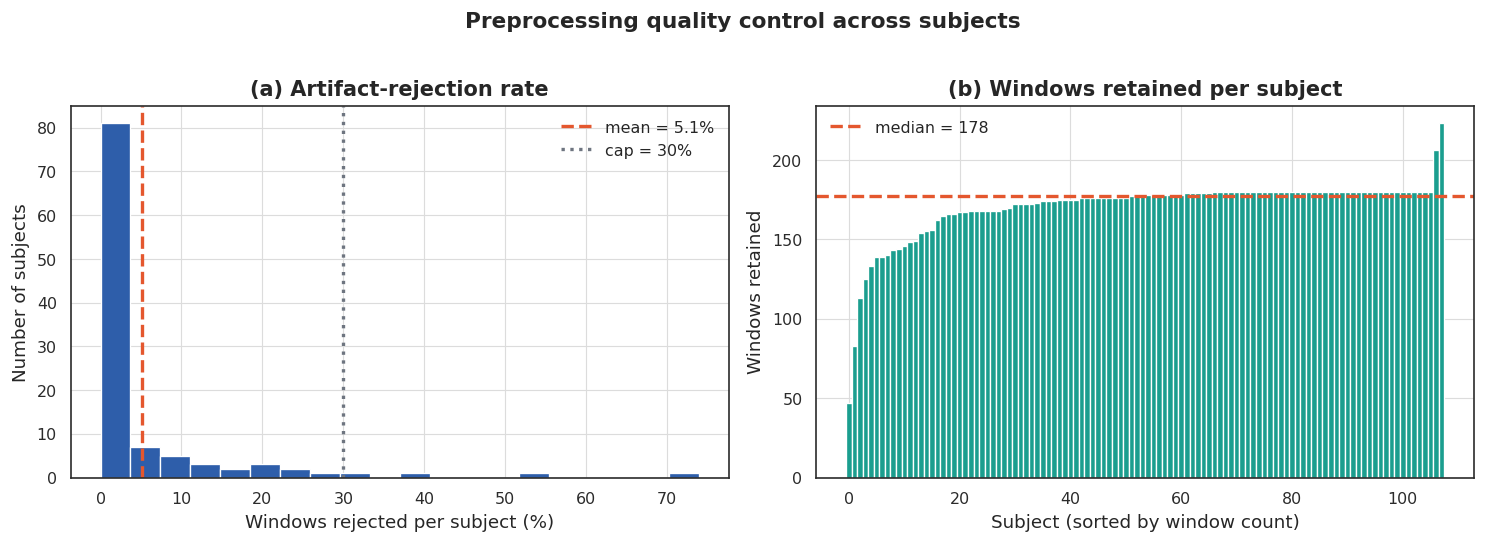

In [9]:
# ---------------------------------------------------------------------------------------------
# Quality-control report: exactly what happened to every subject.
# ---------------------------------------------------------------------------------------------
qc_view = qc_df.copy()
qc_view["reject_%"] = (qc_view["reject_frac"] * 100).round(1)
kept_mask = qc_view["windows_after_qc"] > 0

print(f"Subjects with usable data : {int(kept_mask.sum())} / {len(qc_view)}")
dropped = qc_view.loc[~kept_mask, ["subject", "status", "windows_before_qc"]]
if len(dropped):
    print("\nDropped subjects and the reason:")
    print(dropped.to_string(index=False))
else:
    print("No subjects were dropped.")

summary = pd.DataFrame([{
    "Subjects indexed":            len(qc_view),
    "Subjects retained":           int(kept_mask.sum()),
    "Trials retained":             int(qc_view["n_trials"].sum()),
    "Windows before QC":           int(qc_view["windows_before_qc"].sum()),
    "Windows after QC":            int(qc_view["windows_after_qc"].sum()),
    "Mean rejection rate (%)":     round(float(qc_view.loc[kept_mask, "reject_frac"].mean() * 100), 2),
    "Max rejection rate (%)":      round(float(qc_view.loc[kept_mask, "reject_frac"].max() * 100), 2),
    "Subjects hitting the cap":    int(qc_view["qc_capped"].sum()),
    "Mean ICA components removed": round(float(qc_view.loc[kept_mask, "n_ica_excluded"].mean()), 2),
}]).T.reset_index()
summary.columns = ["Quantity", "Value"]

show_table(summary, save_path=os.path.join(TAB_DIR, "tableS1_preprocessing_qc_summary.csv"),
           title="Table S1 — Preprocessing and quality-control summary")
qc_view.to_csv(os.path.join(TAB_DIR, "tableS2_preprocessing_qc_per_subject.csv"), index=False)
register([os.path.join(TAB_DIR, "tableS1_preprocessing_qc_summary.csv"),
          os.path.join(TAB_DIR, "tableS2_preprocessing_qc_per_subject.csv")],
         "table", "Preprocessing quality control")

# ---- QC figure -------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
vals = qc_view.loc[kept_mask, "reject_frac"].values * 100
ax.hist(vals, bins=20, color=PALETTE[0], edgecolor="white", linewidth=0.8)
ax.axvline(float(np.mean(vals)), color=PALETTE[2], linestyle="--", linewidth=2,
           label=f"mean = {np.mean(vals):.1f}%")
ax.axvline(CONFIG["MAX_REJECT_FRAC"] * 100, color=GREY, linestyle=":", linewidth=2,
           label=f"cap = {CONFIG['MAX_REJECT_FRAC']:.0%}")
ax.set_xlabel("Windows rejected per subject (%)")
ax.set_ylabel("Number of subjects")
ax.set_title("(a) Artifact-rejection rate")
ax.legend()

ax = axes[1]
kept_counts = qc_view.loc[kept_mask, "windows_after_qc"].sort_values().values
ax.bar(np.arange(len(kept_counts)), kept_counts, color=PALETTE[1], width=1.0)
ax.axhline(float(np.median(kept_counts)), color=PALETTE[2], linestyle="--", linewidth=2,
           label=f"median = {np.median(kept_counts):.0f}")
ax.set_xlabel("Subject (sorted by window count)")
ax.set_ylabel("Windows retained")
ax.set_title("(b) Windows retained per subject")
ax.legend()

fig.suptitle("Preprocessing quality control across subjects", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
register(save_fig(fig, "figS1_preprocessing_qc"), "figure", "Preprocessing QC distributions")
plt.show()

---
# Section 4 — Dataset characterisation and class-imbalance handling
---

### 4.1 Figure 1 — class distribution (methodology section)

This is the dataset figure for the methodology section: a bar plot of how many samples belong to each class.
Both granularities are shown, because they answer different reviewer questions — trial counts describe the
experimental design, window counts describe what the network actually consumes. Panel (c) shows the
per-subject balance, which reveals whether any imbalance is uniform or driven by a few participants.

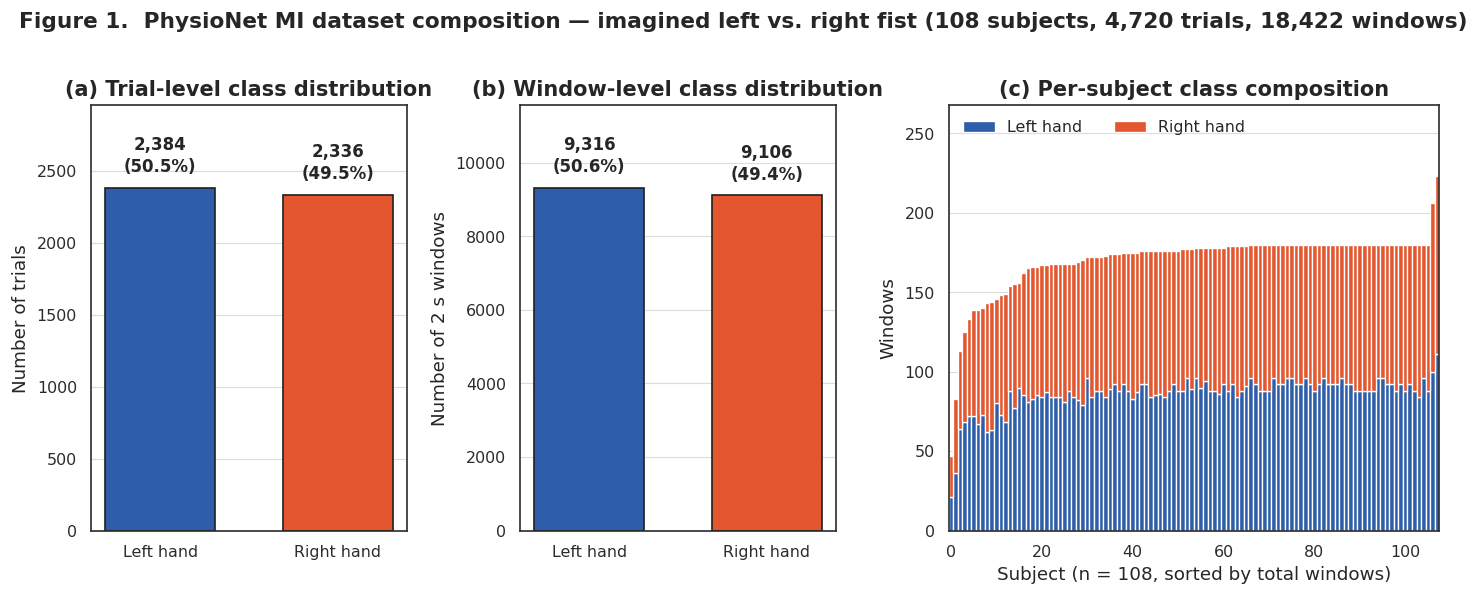

Class,Label,Trials,Trials (%),Windows,Windows (%)
Left hand,0.00,2384.00,50.51,9316.00,50.57
Right hand,1.00,2336.00,49.49,9106.00,49.43


In [10]:
# ---------------------------------------------------------------------------------------------
# FIGURE 1 (methodology): class distribution at trial level and window level.
# ---------------------------------------------------------------------------------------------
# Trial-level counts: one entry per experimental trial, independent of the windowing stride.
_first = np.unique(trial, return_index=True)[1]
trial_labels   = y[_first]
trial_subjects = subj[_first]

trial_counts  = np.array([int((trial_labels == c).sum()) for c in (0, 1)])
window_counts = np.array([int((y == c).sum()) for c in (0, 1)])

fig = plt.figure(figsize=(14.5, 4.6))
gs  = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 1.55], wspace=0.30)

def _class_bars(ax, counts, ylabel, panel_title):
    total = counts.sum()
    bars = ax.bar(CLASS_NAMES, counts,
                  color=[CLASS_COLORS[0], CLASS_COLORS[1]],
                  edgecolor="#1f1f1f", linewidth=1.0, width=0.62)
    ax.set_ylim(0, counts.max() * 1.24)
    for b, c in zip(bars, counts):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + counts.max() * 0.035,
                f"{c:,}\n({100.0 * c / total:.1f}%)",
                ha="center", va="bottom", fontsize=10, fontweight="bold", linespacing=1.3)
    ax.set_ylabel(ylabel)
    ax.set_title(panel_title)
    ax.grid(axis="x", visible=False)
    return bars

ax0 = fig.add_subplot(gs[0, 0])
_class_bars(ax0, trial_counts, "Number of trials", "(a) Trial-level class distribution")

ax1 = fig.add_subplot(gs[0, 1])
_class_bars(ax1, window_counts, f"Number of {CONFIG['WINDOW_SEC']:.0f} s windows",
            "(b) Window-level class distribution")

# Panel (c): per-subject stacked composition, sorted by total, exposing whether any global
# imbalance is uniform across participants or concentrated in a few.
ax2 = fig.add_subplot(gs[0, 2])
sids = np.unique(subj)
left_per  = np.array([int(((subj == s) & (y == 0)).sum()) for s in sids])
right_per = np.array([int(((subj == s) & (y == 1)).sum()) for s in sids])
order = np.argsort(left_per + right_per)
xs = np.arange(len(sids))
ax2.bar(xs, left_per[order],  color=CLASS_COLORS[0], width=1.0, label=CLASS_NAMES[0])
ax2.bar(xs, right_per[order], bottom=left_per[order],
        color=CLASS_COLORS[1], width=1.0, label=CLASS_NAMES[1])
ax2.set_xlabel(f"Subject (n = {len(sids)}, sorted by total windows)")
ax2.set_ylabel("Windows")
ax2.set_title("(c) Per-subject class composition")
# Headroom so the legend cannot sit on top of the bars once the axis is full.
ax2.set_ylim(0, float((left_per + right_per).max()) * 1.20)
ax2.legend(loc="upper left", ncol=2, framealpha=0.94)
ax2.set_xlim(-0.5, len(sids) - 0.5)
ax2.grid(axis="x", visible=False)

fig.suptitle(
    f"Figure 1.  PhysioNet MI dataset composition — imagined left vs. right fist "
    f"({len(np.unique(subj))} subjects, {len(np.unique(trial)):,} trials, {len(y):,} windows)",
    fontsize=13, fontweight="bold", y=1.05)
register(save_fig(fig, "fig1_dataset_class_distribution"), "figure",
         "Figure 1 - dataset class distribution (methodology)")
plt.show()

comp = pd.DataFrame({
    "Class":              CLASS_NAMES,
    "Label":              [0, 1],
    "Trials":             trial_counts,
    "Trials (%)":         (100 * trial_counts / trial_counts.sum()).round(2),
    "Windows":            window_counts,
    "Windows (%)":        (100 * window_counts / window_counts.sum()).round(2),
})
show_table(comp, save_path=os.path.join(TAB_DIR, "table1_dataset_composition.csv"),
           title="Table 1 — Dataset composition by class", float_fmt="{:.2f}")
register(os.path.join(TAB_DIR, "table1_dataset_composition.csv"), "table", "Dataset composition")

### 4.2 Signal-quality validation: does the preprocessed data contain motor imagery at all?

Before comparing architectures it is worth confirming that the pipeline produced physiologically plausible
data. This is the diagnostic that would have exposed the previous chain's ICA problem immediately.

Motor imagery produces **event-related desynchronisation** — a drop in mu/beta power over the sensorimotor
cortex *contralateral* to the imagined hand. Imagined left-hand movement should therefore reduce power at C4
(right hemisphere) relative to C3, and vice versa. The lateralisation index

$$\mathrm{LI} = \frac{P_{C4} - P_{C3}}{P_{C4} + P_{C3}}$$

should be **negative for left-hand imagery and positive for right-hand imagery**. If the two classes do not
separate here, no architecture downstream can recover the difference, and the problem is in preprocessing
rather than in the model.

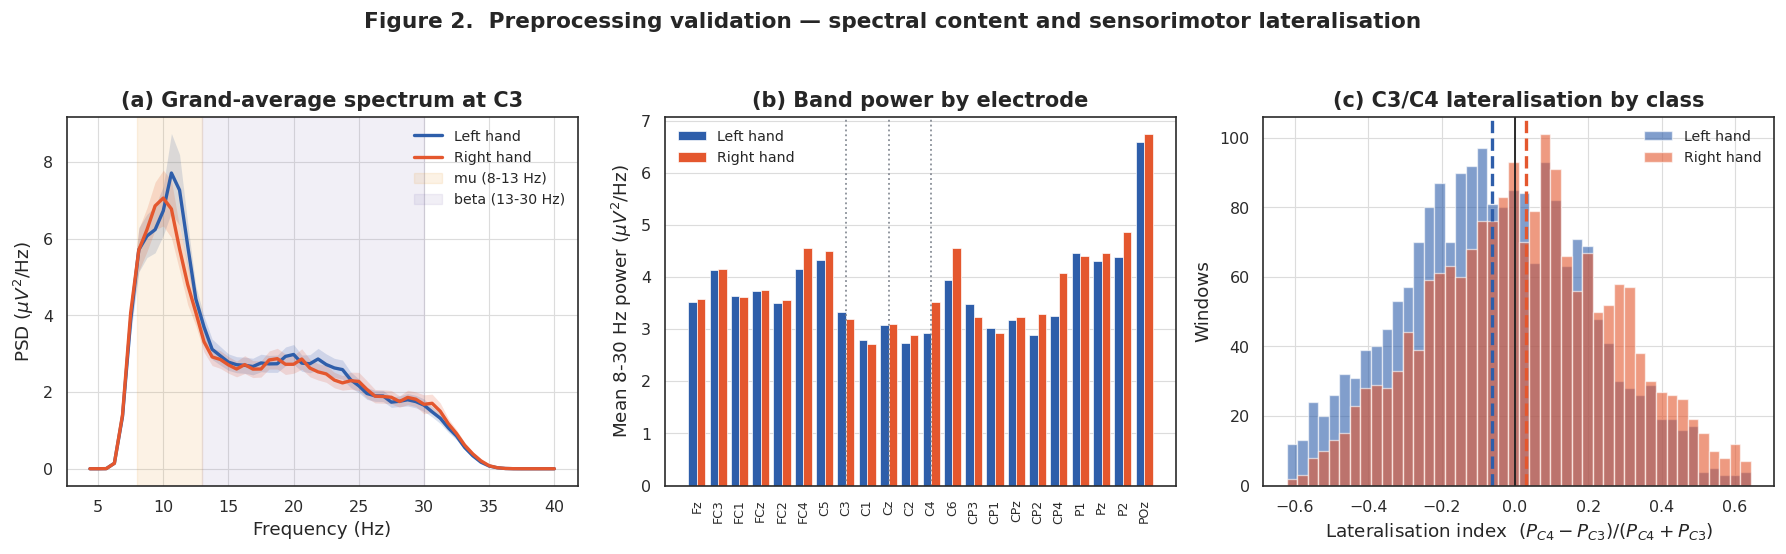

Quantity,Value
"Mean LI, left-hand imagery",-0.0625
"Mean LI, right-hand imagery",0.0313
Mann-Whitney U p-value,9.462e-25
Cohen's d (right - left),0.3536
Windows probed,4000



PASS: lateralisation is in the expected contralateral direction (p = 9.46e-25, d = 0.354).
Right-hand imagery shows relatively higher C4-vs-C3 power than left-hand imagery, consistent with contralateral event-related desynchronisation.


In [11]:
# ---------------------------------------------------------------------------------------------
# Signal-quality validation: spectral separability and C3/C4 lateralisation.
#
# This is a preprocessing SANITY CHECK, not a result. If the two classes do not separate here,
# the fault is upstream of every model, and comparing architectures is premature.
# ---------------------------------------------------------------------------------------------
from scipy.signal import welch

def band_power(windows, fs=FS, band=None):
    """Mean power in `band` per channel for each window -> (n_windows, n_channels)."""
    band = band or CONFIG["MI_BAND"]
    Xv = np.asarray(windows, dtype=np.float64) * 1e6          # V -> uV for readable units
    nper = int(min(256, Xv.shape[-1]))
    freqs, psd = welch(Xv, fs=fs, nperseg=nper, axis=-1)
    sel = (freqs >= band[0]) & (freqs <= band[1])
    return psd[..., sel].mean(axis=-1), freqs, psd

# Subsample for speed; Welch over every window is unnecessary for a diagnostic.
set_all_seeds(SEED)
n_probe = int(min(4000, len(y)))
probe = np.random.choice(len(y), n_probe, replace=False)
bp, freqs, psd = band_power(X_uv[probe])
y_probe = y[probe]

ch_idx = {c: i for i, c in enumerate(COMMON_CHANNELS)}
i_c3, i_c4, i_cz = ch_idx["C3"], ch_idx["C4"], ch_idx["Cz"]

li = (bp[:, i_c4] - bp[:, i_c3]) / (bp[:, i_c4] + bp[:, i_c3] + 1e-20)
li_left, li_right = li[y_probe == 0], li[y_probe == 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# (a) grand-average PSD per class at C3
ax = axes[0]
fmask = (freqs >= 4) & (freqs <= 40)
for cls in (0, 1):
    m = psd[y_probe == cls][:, i_c3, :][:, fmask]
    mu, se = m.mean(axis=0), m.std(axis=0) / np.sqrt(max(1, m.shape[0]))
    ax.plot(freqs[fmask], mu, color=CLASS_COLORS[cls], label=CLASS_NAMES[cls])
    ax.fill_between(freqs[fmask], mu - 1.96 * se, mu + 1.96 * se,
                    color=CLASS_COLORS[cls], alpha=0.18, linewidth=0)
ax.axvspan(8, 13, color=PALETTE[3], alpha=0.13, label="mu (8-13 Hz)")
ax.axvspan(13, 30, color=PALETTE[4], alpha=0.10, label="beta (13-30 Hz)")
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel(r"PSD ($\mu V^2$/Hz)")
ax.set_title("(a) Grand-average spectrum at C3")
ax.legend(fontsize=8.5)

# (b) mean band power per channel, per class
ax = axes[1]
w = 0.4
xs = np.arange(N_CHANNELS)
for k, cls in enumerate((0, 1)):
    ax.bar(xs + (k - 0.5) * w, bp[y_probe == cls].mean(axis=0), width=w,
           color=CLASS_COLORS[cls], edgecolor="white", linewidth=0.4, label=CLASS_NAMES[cls])
for i, c in zip((i_c3, i_cz, i_c4), ("C3", "Cz", "C4")):
    ax.axvline(i, color=GREY, linestyle=":", linewidth=1.1, alpha=0.8)
ax.set_xticks(xs); ax.set_xticklabels(COMMON_CHANNELS, rotation=90, fontsize=7.5)
ax.set_ylabel(r"Mean 8-30 Hz power ($\mu V^2$/Hz)")
ax.set_title("(b) Band power by electrode")
ax.legend(fontsize=8.5); ax.grid(axis="x", visible=False)

# (c) lateralisation index distribution
ax = axes[2]
bins = np.linspace(float(np.percentile(li, 1)), float(np.percentile(li, 99)), 45)
ax.hist(li_left,  bins=bins, color=CLASS_COLORS[0], alpha=0.6, label=CLASS_NAMES[0], edgecolor="white")
ax.hist(li_right, bins=bins, color=CLASS_COLORS[1], alpha=0.6, label=CLASS_NAMES[1], edgecolor="white")
ax.axvline(float(li_left.mean()),  color=CLASS_COLORS[0], linestyle="--", linewidth=2)
ax.axvline(float(li_right.mean()), color=CLASS_COLORS[1], linestyle="--", linewidth=2)
ax.axvline(0, color="#1f1f1f", linewidth=1.1)
ax.set_xlabel(r"Lateralisation index  $(P_{C4}-P_{C3})/(P_{C4}+P_{C3})$")
ax.set_ylabel("Windows")
ax.set_title("(c) C3/C4 lateralisation by class")
ax.legend(fontsize=8.5)

fig.suptitle("Figure 2.  Preprocessing validation — spectral content and sensorimotor lateralisation",
             fontsize=13, fontweight="bold", y=1.04)
fig.tight_layout()
register(save_fig(fig, "fig2_preprocessing_validation"), "figure",
         "Figure 2 - spectral and lateralisation validation")
plt.show()

# ---- quantify the effect rather than eyeballing the histogram ---------------------------------
from scipy.stats import mannwhitneyu
u_stat, u_p = mannwhitneyu(li_left, li_right, alternative="two-sided")
pooled_sd = np.sqrt((li_left.var(ddof=1) + li_right.var(ddof=1)) / 2) + 1e-12
cohen_d = float((li_right.mean() - li_left.mean()) / pooled_sd)

diag = pd.DataFrame([
    {"Quantity": "Mean LI, left-hand imagery",  "Value": round(float(li_left.mean()), 4)},
    {"Quantity": "Mean LI, right-hand imagery", "Value": round(float(li_right.mean()), 4)},
    {"Quantity": "Mann-Whitney U p-value",      "Value": float(u_p)},
    {"Quantity": "Cohen's d (right - left)",    "Value": round(cohen_d, 4)},
    {"Quantity": "Windows probed",              "Value": int(n_probe)},
])
show_table(diag, save_path=os.path.join(TAB_DIR, "tableS3_lateralisation_check.csv"),
           title="Table S3 — Sensorimotor lateralisation check", float_fmt="{:.4g}")
register(os.path.join(TAB_DIR, "tableS3_lateralisation_check.csv"), "table", "Lateralisation check")

# Interpretation is stated conditionally: the check either passes or it does not, and a failure
# is reported rather than glossed over.
if u_p < 0.05 and li_right.mean() > li_left.mean():
    print(f"\nPASS: lateralisation is in the expected contralateral direction "
          f"(p = {u_p:.2e}, d = {cohen_d:.3f}).\n"
          "Right-hand imagery shows relatively higher C4-vs-C3 power than left-hand imagery, "
          "consistent with contralateral event-related desynchronisation.")
elif u_p < 0.05:
    print(f"\nCAUTION: the classes separate (p = {u_p:.2e}) but in the OPPOSITE direction to the "
          "contralateral ERD expectation. Check that T1/T2 are not swapped relative to the "
          "dataset documentation before interpreting any downstream result.")
else:
    print(f"\nFAIL: no significant C3/C4 lateralisation (p = {u_p:.3f}, d = {cohen_d:.3f}).\n"
          "Downstream accuracy near chance would be a preprocessing problem, not a model problem. "
          "Re-check the band-pass, the reference and the epoch window before tuning architectures.")

### 4.3 Class imbalance: diagnosis, then correction

Two things matter here and they are easy to conflate.

**Diagnosis first.** The imbalance ratio is measured and reported before anything is applied. If PhysioNet's
left/right design is close to balanced, the honest result is a small correction and a plot that shows it —
not a fabricated problem. The cell below reports the real ratio either way.

**Correction: subject-constrained SMOTE.** Plain SMOTE interpolates between a minority sample and its nearest
neighbours drawn from the *entire* training set. On EEG that is a problem: an interpolation between subject 12
and subject 47 is a signal no cortex ever produced, and because inter-subject variance in EEG greatly exceeds
inter-class variance, most nearest neighbours would come from other subjects. The synthetic majority would then
consist of physiologically meaningless cross-subject hybrids.

The implementation below therefore restricts neighbour search to **within the same subject and the same class**.
It is faster (a few hundred windows per subject rather than tens of thousands), and every synthetic window is
a convex combination of two recordings from one participant's own cortex.

Two safeguards on leakage, which is where oversampling most often invalidates a result:

- SMOTE is applied **inside each fold, to the training split only**. Test subjects are never touched.
  Oversampling before the split is the classic error that leaks minority information into the test set and
  inflates accuracy.
- Because folds are grouped by subject, synthetic windows can never be derived from a test subject.

The figure below shows the before/after distribution. It is a **demonstration on the pooled data** so the
mechanism is visible in one plot; the numbers actually used in training come from the per-fold application,
which the training loop reports.

> **Reviewer note, worth pre-empting in the paper.** Synthetic oversampling of EEG is contested: some reviewers
> object that interpolated trials are not real observations. Two defences are built in — synthesis is
> subject-constrained, and class-weighted loss is retained as an independent mechanism so the result does not
> depend solely on SMOTE. If a reviewer pushes back, `CONFIG["USE_SMOTE"] = False` reruns the entire study with
> class weighting alone, which makes the ablation a one-line change.

In [12]:
# ---------------------------------------------------------------------------------------------
# Subject-constrained SMOTE.
#
# Neighbour search is restricted to the SAME subject and SAME class. Rationale: inter-subject
# variance in EEG exceeds inter-class variance, so unconstrained SMOTE would mostly interpolate
# between different people and manufacture signals no cortex produced. It is also far cheaper --
# a few hundred windows per subject instead of a k-NN search over the whole training set in
# 22 x 320 = 7040 dimensions.
#
# LEAKAGE CONTRACT: this function is only ever called on a fold's TRAINING split. Applying it
# before the subject split would leak minority-class structure into the test set.
# ---------------------------------------------------------------------------------------------
def subject_constrained_smote(X, y, groups, k=None, min_ratio=None, seed=SEED, verbose=False):
    """Balance classes by interpolating within (subject, class) neighbourhoods.

    Parameters
    ----------
    X : (n, channels, time) float32   -- training windows, native amplitude scale
    y : (n,) int                      -- labels
    groups : (n,) int                 -- subject id per window
    k : int                           -- neighbours considered (CONFIG['SMOTE_K'])
    min_ratio : float                 -- skip synthesis if majority/minority <= this

    Returns
    -------
    X_out, y_out, groups_out, info
    """
    k = k or CONFIG["SMOTE_K"]
    min_ratio = min_ratio or CONFIG["SMOTE_MIN_RATIO"]
    rng = np.random.default_rng(seed)

    counts = {c: int((y == c).sum()) for c in np.unique(y)}
    if len(counts) < 2:
        return X, y, groups, {"applied": False, "reason": "single class present",
                              "ratio_before": np.nan, "n_synth": 0, "counts_before": counts,
                              "counts_after": counts}

    maj_c = max(counts, key=counts.get)
    min_c = min(counts, key=counts.get)
    ratio = counts[maj_c] / max(1, counts[min_c])
    info = {"applied": False, "reason": "", "ratio_before": float(ratio),
            "n_synth": 0, "counts_before": dict(counts), "counts_after": dict(counts),
            "n_subjects_used": 0}

    if ratio <= min_ratio:
        info["reason"] = f"already balanced (ratio {ratio:.3f} <= {min_ratio})"
        return X, y, groups, info

    # Deficit is distributed across subjects proportionally to each subject's minority count,
    # so no single participant is over-represented by the synthesis step.
    deficit = counts[maj_c] - counts[min_c]
    subj_ids = np.unique(groups)
    per_subject_min = {s: int(((groups == s) & (y == min_c)).sum()) for s in subj_ids}
    total_min = sum(per_subject_min.values())
    if total_min < 2:
        info["reason"] = "too few minority samples to interpolate"
        return X, y, groups, info

    flat_len = int(np.prod(X.shape[1:]))
    synth_X, synth_g = [], []

    for s in subj_ids:
        n_needed = int(round(deficit * per_subject_min[s] / total_min))
        if n_needed <= 0:
            continue
        sel = np.where((groups == s) & (y == min_c))[0]
        if len(sel) < 2:
            continue

        pool = X[sel].reshape(len(sel), flat_len).astype(np.float32)
        n_nb = int(min(k + 1, len(sel)))
        nn = NearestNeighbors(n_neighbors=n_nb).fit(pool)
        _, nbrs = nn.kneighbors(pool)

        base = rng.integers(0, len(sel), n_needed)
        # column 0 is the point itself; choose among genuine neighbours when available
        pick = rng.integers(1, n_nb, n_needed) if n_nb > 1 else np.zeros(n_needed, dtype=int)
        partner = nbrs[base, pick]
        lam = rng.random((n_needed, 1)).astype(np.float32)

        new = pool[base] + lam * (pool[partner] - pool[base])
        synth_X.append(new.reshape(n_needed, *X.shape[1:]))
        synth_g.append(np.full(n_needed, s, dtype=groups.dtype))
        info["n_subjects_used"] += 1

    if not synth_X:
        info["reason"] = "no subject had >=2 minority windows"
        return X, y, groups, info

    Xs = np.concatenate(synth_X).astype(np.float32)
    gs = np.concatenate(synth_g)
    X_out = np.concatenate([X, Xs])
    y_out = np.concatenate([y, np.full(len(Xs), min_c, dtype=y.dtype)])
    g_out = np.concatenate([groups, gs])

    # Shuffle so synthetic samples are not all at the tail (matters for any non-shuffled consumer).
    order = rng.permutation(len(y_out))
    X_out, y_out, g_out = X_out[order], y_out[order], g_out[order]

    after = {int(c): int((y_out == c).sum()) for c in np.unique(y_out)}
    info.update({"applied": True, "n_synth": int(len(Xs)), "counts_after": after,
                 "reason": f"synthesised {len(Xs)} windows for class {min_c}",
                 "ratio_after": float(max(after.values()) / max(1, min(after.values())))})
    if verbose:
        print(f"    SMOTE: {info['reason']} across {info['n_subjects_used']} subjects "
              f"(ratio {ratio:.3f} -> {info['ratio_after']:.3f})")
    return X_out, y_out, g_out, info


print("subject_constrained_smote() defined. Applied per fold to TRAINING data only.")

subject_constrained_smote() defined. Applied per fold to TRAINING data only.


Windows per class : Left hand = 9,316 | Right hand = 9,106
Imbalance ratio   : 1.0231 (1.0 = perfectly balanced)
Absolute skew     : 1.14 percentage points

Imbalance exceeds the action threshold: subject-constrained SMOTE will run per fold.
    SMOTE: synthesised 212 windows for class 1 across 108 subjects (ratio 1.023 -> 1.000)


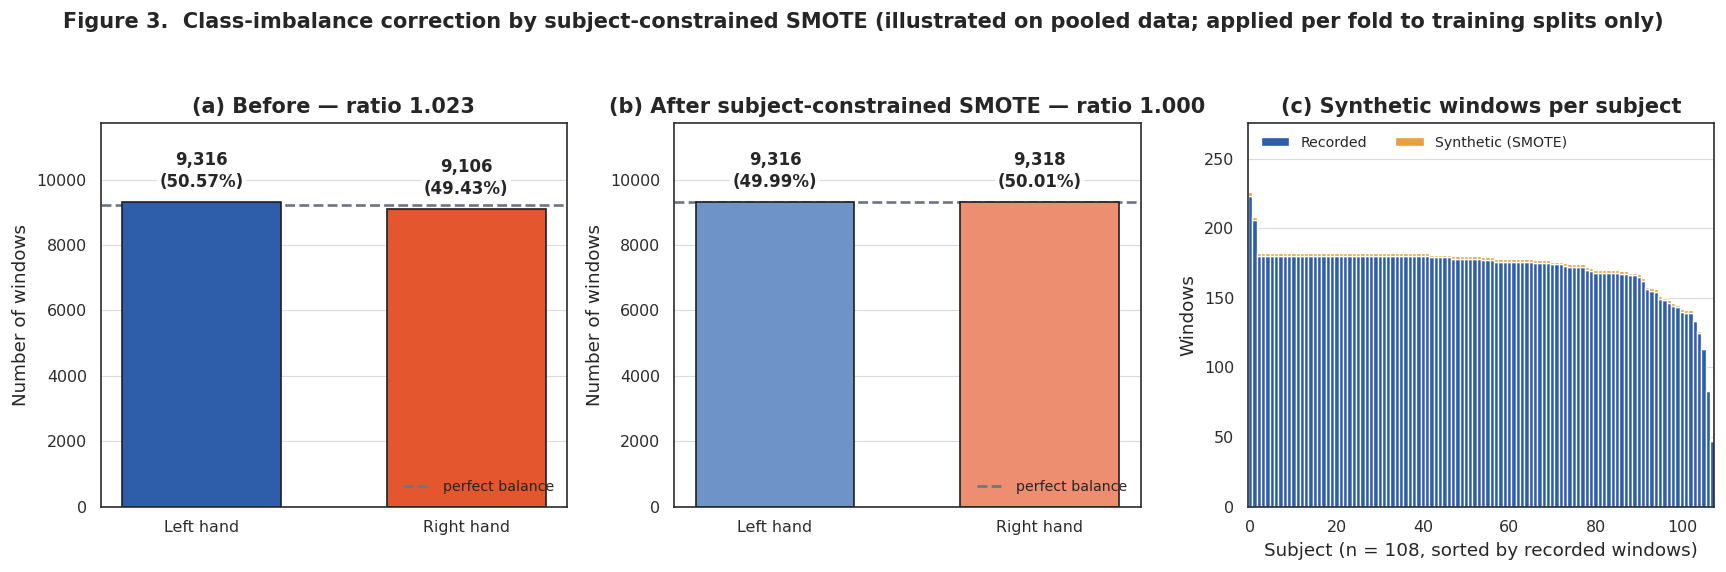

Stage,Left hand,Right hand,Total,Imbalance ratio
Before correction,9316.0000,9106.0000,18422.0000,1.0231
After SMOTE (demonstration),9316.0000,9318.0000,18634.0000,1.0002


In [13]:
# ---------------------------------------------------------------------------------------------
# FIGURE 3: class imbalance before and after correction.
#
# This is a DEMONSTRATION on the pooled dataset so the mechanism is visible in one figure. The
# numbers used in training come from the per-fold application inside the CV loop, which is what
# keeps the procedure leakage-free.
# ---------------------------------------------------------------------------------------------
counts_before = np.array([int((y == c).sum()) for c in (0, 1)])
ratio_before = counts_before.max() / max(1, counts_before.min())
imbalance_pct = 100.0 * abs(counts_before[0] - counts_before[1]) / counts_before.sum()

print(f"Windows per class : {CLASS_NAMES[0]} = {counts_before[0]:,} | "
      f"{CLASS_NAMES[1]} = {counts_before[1]:,}")
print(f"Imbalance ratio   : {ratio_before:.4f} (1.0 = perfectly balanced)")
print(f"Absolute skew     : {imbalance_pct:.2f} percentage points\n")

if ratio_before <= CONFIG["SMOTE_MIN_RATIO"]:
    print(f"This dataset is close to balanced (ratio <= {CONFIG['SMOTE_MIN_RATIO']}).\n"
          "Reported honestly rather than inventing a problem: SMOTE will be a no-op or near-no-op\n"
          "on most folds. Class-weighted loss remains active regardless. Per-fold imbalance can\n"
          "still be larger than the pooled figure, because folds differ in which subjects they hold\n"
          "out -- the CV loop logs the per-fold ratio.")
else:
    print("Imbalance exceeds the action threshold: subject-constrained SMOTE will run per fold.")

# Demonstration run on the pooled data (NOT the data used for training).
_demo_X, _demo_y, _demo_g, demo_info = subject_constrained_smote(
    X_uv, y, subj, min_ratio=1.0, verbose=True)     # min_ratio=1.0 forces the demonstration
counts_after = np.array([int((_demo_y == c).sum()) for c in (0, 1)])

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.5))

def _imbalance_panel(ax, counts, title, colors):
    total = counts.sum()
    bars = ax.bar(CLASS_NAMES, counts, color=colors, edgecolor="#1f1f1f",
                  linewidth=1.0, width=0.6)
    ax.set_ylim(0, counts.max() * 1.26)
    for b, c in zip(bars, counts):
        # White backing box: the "perfect balance" reference line passes straight through the
        # label position of whichever class is closer to the mean, and without it the digits
        # sit on top of the dashes and become hard to read in print.
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + counts.max() * 0.035,
                f"{c:,}\n({100.0 * c / total:.2f}%)", ha="center", va="bottom",
                fontsize=10, fontweight="bold", linespacing=1.3, zorder=4,
                bbox=dict(boxstyle="round,pad=0.16", facecolor="white", alpha=0.85,
                          edgecolor="none"))
    ax.axhline(total / 2, color=GREY, linestyle="--", linewidth=1.6,
               label="perfect balance", zorder=0)
    ax.set_ylabel("Number of windows")
    ax.set_title(title)
    ax.legend(fontsize=8.5, loc="lower right", framealpha=0.94)
    ax.grid(axis="x", visible=False)

_imbalance_panel(axes[0], counts_before,
                 f"(a) Before — ratio {ratio_before:.3f}",
                 [CLASS_COLORS[0], CLASS_COLORS[1]])
_imbalance_panel(axes[1], counts_after,
                 f"(b) After subject-constrained SMOTE — ratio "
                 f"{counts_after.max()/max(1,counts_after.min()):.3f}",
                 ["#6E93C9", "#EE8E70"])

# (c) where the synthetic windows came from, per subject
ax = axes[2]
sids = np.unique(subj)
real_per  = np.array([int((subj == s).sum()) for s in sids])
synth_per = np.array([int((_demo_g == s).sum()) for s in sids]) - real_per
order = np.argsort(-real_per)
xs = np.arange(len(sids))
ax.bar(xs, real_per[order],  color=PALETTE[0], width=1.0, label="Recorded")
ax.bar(xs, np.clip(synth_per[order], 0, None), bottom=real_per[order],
       color=PALETTE[3], width=1.0, label="Synthetic (SMOTE)")
ax.set_xlabel(f"Subject (n = {len(sids)}, sorted by recorded windows)")
ax.set_ylabel("Windows")
ax.set_title("(c) Synthetic windows per subject")
# The stacked bars fill the panel edge to edge, so the legend needs its own headroom instead of
# floating over the data.
ax.set_ylim(0, float((real_per + np.clip(synth_per, 0, None)).max()) * 1.22)
ax.legend(fontsize=8.5, loc="upper left", ncol=2, framealpha=0.94)
ax.set_xlim(-0.5, len(sids) - 0.5)
ax.grid(axis="x", visible=False)

fig.suptitle("Figure 3.  Class-imbalance correction by subject-constrained SMOTE "
             "(illustrated on pooled data; applied per fold to training splits only)",
             fontsize=12.5, fontweight="bold", y=1.05)
fig.tight_layout()
register(save_fig(fig, "fig3_class_imbalance_correction"), "figure",
         "Figure 3 - class imbalance before/after SMOTE")
plt.show()

imb = pd.DataFrame([
    {"Stage": "Before correction", CLASS_NAMES[0]: int(counts_before[0]),
     CLASS_NAMES[1]: int(counts_before[1]), "Total": int(counts_before.sum()),
     "Imbalance ratio": round(float(ratio_before), 4)},
    {"Stage": "After SMOTE (demonstration)", CLASS_NAMES[0]: int(counts_after[0]),
     CLASS_NAMES[1]: int(counts_after[1]), "Total": int(counts_after.sum()),
     "Imbalance ratio": round(float(counts_after.max() / max(1, counts_after.min())), 4)},
])
show_table(imb, save_path=os.path.join(TAB_DIR, "table2_class_imbalance.csv"),
           title="Table 2 — Class balance before and after correction", float_fmt="{:.4f}")
register(os.path.join(TAB_DIR, "table2_class_imbalance.csv"), "table", "Class imbalance correction")

del _demo_X, _demo_y, _demo_g      # free the demonstration copy before training begins

In [14]:
# ---------------------------------------------------------------------------------------------
# Persist the preprocessed dataset so the modelling sections can be re-run without repeating
# preprocessing (which is by far the slowest stage).
# ---------------------------------------------------------------------------------------------
DATASET_PATH = os.path.join(OUT_DIR, "physionet_mi_preprocessed.npz")
np.savez_compressed(
    DATASET_PATH,
    X_uv=X_uv, y=y, subj=subj, trial=trial,
    channels=np.array(COMMON_CHANNELS),
    config=json.dumps(CONFIG),
)
print(f"Saved -> {DATASET_PATH}  ({os.path.getsize(DATASET_PATH) / 1e6:.1f} MB)")
register(DATASET_PATH, "dataset", "Preprocessed PhysioNet MI windows")

# Reload immediately: this verifies the file is complete and readable rather than assuming it.
_chk = np.load(DATASET_PATH, allow_pickle=False)
assert _chk["X_uv"].shape == X_uv.shape, "Saved X_uv shape does not match the in-memory array."
assert np.array_equal(_chk["y"], y), "Saved labels do not match the in-memory labels."
print("Round-trip verification passed.")
del _chk

print(f"\nFinal dataset for modelling")
print(f"  windows  : {len(y):,}")
print(f"  shape    : {X_uv.shape[1]} channels x {X_uv.shape[2]} samples "
      f"({CONFIG['WINDOW_SEC']} s @ {FS} Hz)")
print(f"  subjects : {len(np.unique(subj))}")
print(f"  trials   : {len(np.unique(trial)):,}")
print(f"  classes  : {CLASS_NAMES[0]} = {int((y==0).sum()):,} | "
      f"{CLASS_NAMES[1]} = {int((y==1).sum()):,}")

Saved -> /kaggle/working/MI_EEG_project/results/physionet_mi_preprocessed.npz  (216.8 MB)
Round-trip verification passed.

Final dataset for modelling
  windows  : 18,422
  shape    : 22 channels x 320 samples (2.0 s @ 160 Hz)
  subjects : 108
  trials   : 4,720
  classes  : Left hand = 9,316 | Right hand = 9,106


---
# Section 5 — Model zoo
---

Seven decoders are compared: one classical pipeline and six neural architectures.

| Model | Family | Why it is included |
|---|---|---|
| **CSP+SVM** | Classical spatial filtering | The reference every MI paper is measured against. A deep model that cannot beat it has not earned its parameters. |
| **CNN** | Temporal + spatial convolution | Minimal convolutional control: shows what plain convolution achieves before architectural refinement. |
| **LSTM** | Recurrent | Tests whether long-range temporal dependence alone suffices, with no spatial filtering. |
| **CNN-LSTM** | Hybrid | Convolutional features fed to a recurrent layer — the architecture whose reported inconsistency this study examines. |
| **EEGNet** | Compact depthwise/separable CNN | The standard compact EEG architecture (Lawhern et al., 2018). |
| **DeepConvNet** | Deep hierarchical CNN | The standard deep EEG architecture (Schirrmeister et al., 2017). |
| **EEGConformer** | Convolution + self-attention | Contemporary hybrid: convolutional tokenisation followed by a transformer encoder. |

Three implementation decisions apply to all six neural models and are worth stating in the methods section.

**Flattened dimensions are inferred, not hard-coded.** Every model determines its classifier input width with a
dummy forward pass at construction time. Hard-coded flatten widths are the single most common source of shape
errors when a window length or montage changes, and they silently couple the architecture to one specific
configuration.

**Glorot initialisation, and max-norm constraints where the original papers specify them.** EEGNet's depthwise
convolution and dense layer are constrained in the original work; omitting the constraint changes the model
being evaluated, so it is implemented and applied by the training loop.

**Each model declares its own Grad-CAM target layer.** This is the fix for the most serious explainability
defect in the previous version, and Section 5.4 verifies the declaration programmatically rather than trusting it.

### 5.1 CSP + SVM baseline — and why the previous version crippled it

Common Spatial Patterns finds spatial filters $w$ maximising the ratio of class-conditional variances,

$$\max_w \frac{w^\top \Sigma_1 w}{w^\top \Sigma_2 w},$$

so the entire method operates on the **covariance structure across electrodes**. The previous version fitted CSP
on data that had already been passed through per-channel z-scoring, which forces every channel to unit variance.
That drives the diagonal of both covariance matrices to 1 and destroys exactly the between-channel variance
differences CSP exists to exploit. The baseline was therefore not a weak baseline — it was a broken one, which
makes any "our deep model beats CSP+SVM" claim built on it worthless.

Here CSP receives band-pass-filtered data on its **native microvolt scale**, and uses the standard log-variance
feature $\log(\mathrm{var}(w^\top X))$ with Ledoit–Wolf shrinkage regularisation, which is what makes covariance
estimation stable when the number of samples per class is limited.

In [15]:
# ---------------------------------------------------------------------------------------------
# CSP + SVM baseline.
#
# CRITICAL: this pipeline must be fitted on band-pass-filtered data at its NATIVE amplitude
# scale. The previous version fitted CSP on per-channel z-scored windows, which sets every
# channel's variance to 1 and annihilates the spatial variance structure CSP is defined by.
# `zscore_windows()` is therefore NEVER applied on the path that feeds this function.
# ---------------------------------------------------------------------------------------------
from mne.decoding import CSP


def build_csp_svm(n_components=8, C=1.0, gamma="scale", seed=SEED):
    """CSP log-variance features -> standardised -> RBF SVM.

    n_components=8 gives four filter pairs, the usual choice for a two-class MI problem:
    enough to capture bilateral sensorimotor sources without overfitting the covariance estimate.
    Ledoit-Wolf shrinkage stabilises covariance estimation at these sample sizes.
    `class_weight='balanced'` keeps the baseline comparable to the class-weighted deep models."""
    return Pipeline([
        ("csp", CSP(n_components=n_components, reg="ledoit_wolf", log=True,
                    norm_trace=False, transform_into="average_power")),
        ("scale", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=C, gamma=gamma, probability=True,
                    class_weight="balanced", random_state=seed)),
    ])


def fit_predict_csp_svm(X_train_uv, y_train, X_test_uv, n_components=8):
    """Fit CSP+SVM on native-scale volts and return (y_pred, y_prob_class1).

    MNE's CSP expects float64 and is sensitive to non-finite values, so the input is sanitised
    here. Scaling to microvolts keeps the covariance entries in a numerically comfortable range
    without altering the relative variance structure (a global scalar cancels in the CSP
    generalised eigenvalue problem)."""
    def prep(X):
        return np.nan_to_num(np.asarray(X, dtype=np.float64) * 1e6,
                             nan=0.0, posinf=0.0, neginf=0.0)

    pipe = build_csp_svm(n_components=n_components)
    n_comp = int(n_components)
    while n_comp >= 2:
        try:
            pipe = build_csp_svm(n_components=n_comp)
            pipe.fit(prep(X_train_uv), y_train)
            break
        except Exception as exc:
            # CSP can fail if the covariance estimate is rank-deficient for the requested number
            # of components; halve and retry rather than dropping the baseline from the study.
            print(f"    CSP with {n_comp} components failed ({type(exc).__name__}); retrying smaller.")
            n_comp //= 2
    else:
        raise RuntimeError("CSP could not be fitted with >=2 components.")

    Xt = prep(X_test_uv)
    y_pred = pipe.predict(Xt)
    y_prob = pipe.predict_proba(Xt)[:, 1]
    return np.asarray(y_pred), np.asarray(y_prob), pipe


print("CSP+SVM baseline defined (native-scale input, log-variance features, Ledoit-Wolf shrinkage).")

CSP+SVM baseline defined (native-scale input, log-variance features, Ledoit-Wolf shrinkage).


### 5.2 Deep architectures

Input to every network is a single-channel image of shape $1 \times 22 \times 320$ (electrodes × time samples),
per-window per-channel standardised. Standardisation is applied at retrieval time by `zscore_windows`, which is
why the stored array remains on its native scale for CSP.

In [16]:
# ---------------------------------------------------------------------------------------------
# Shared building blocks and shape inference.
# ---------------------------------------------------------------------------------------------
def probe_shape(module, feature_fn, n_channels=N_CHANNELS, n_samples=N_SAMPLES):
    """Return the output shape of `feature_fn` for a dummy window, without side effects.

    The module is switched to eval mode for the probe so that the dummy input does not contribute
    to BatchNorm running statistics -- a subtle form of contamination that would otherwise be
    baked into every model at construction time."""
    was_training = module.training
    module.eval()
    try:
        with torch.no_grad():
            out = feature_fn(torch.zeros(2, 1, n_channels, n_samples))
    finally:
        module.train(was_training)
    return tuple(out.shape)


def infer_flat_dim(module, feature_fn, n_channels=N_CHANNELS, n_samples=N_SAMPLES):
    """Flattened feature width produced by `feature_fn` for one input window.

    Every model calls this instead of hard-coding a flatten width. Hard-coded widths are the most
    common cause of shape errors in EEG notebooks, and they silently bind an architecture to one
    particular window length and montage. A configuration that shrinks the time axis below the
    next kernel length now raises here, at construction, instead of mid-training."""
    shape = probe_shape(module, feature_fn, n_channels, n_samples)
    assert all(s > 0 for s in shape), (
        f"Feature extractor produced a degenerate shape {shape} for a "
        f"{n_channels}x{n_samples} input -- the time axis was pooled away.")
    return int(np.prod(shape[1:]))


def module_name(model, mod):
    """Attribute path of `mod` within `model` (used to report Grad-CAM targets readably)."""
    for name, m in model.named_modules():
        if m is mod:
            return name or "<root>"
    return "<not found>"


def glorot_init(module):
    """Glorot/Xavier initialisation for conv and linear layers; BatchNorm to unit scale.

    Used by the EEGNet and DeepConvNet reference implementations; applied uniformly here so that
    architecture comparisons are not confounded by differing initialisation schemes."""
    if isinstance(module, (nn.Conv2d, nn.Conv1d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
        nn.init.ones_(module.weight)
        nn.init.zeros_(module.bias)


class BaseEEGModel(nn.Module):
    """Common interface every architecture in this study implements.

    gradcam_target()   -> the module whose activations Grad-CAM should hook, or None if the
                          architecture has no layer with a meaningful electrode axis.
    max_norm_params()  -> [(parameter, max_norm_value)] enforced after each optimiser step,
                          for architectures whose original papers specify the constraint.
    """
    def gradcam_target(self):
        return None

    def max_norm_params(self):
        return []

    def n_params(self):
        return int(sum(p.numel() for p in self.parameters() if p.requires_grad))

In [17]:
# ---------------------------------------------------------------------------------------------
# 1) SimpleCNN -- minimal temporal-then-spatial convolutional control.
#
# Structure: temporal conv (electrode axis intact) -> spatial conv across all 22 electrodes
# (collapses the electrode axis) -> temporal refinement -> classifier.
#
# Grad-CAM target = `block1`, the last module before the electrode axis is collapsed. Hooking any
# later layer, as the previous version did, yields a map with no electrode information whatsoever.
# ---------------------------------------------------------------------------------------------
class SimpleCNN(BaseEEGModel):
    def __init__(self, n_channels=N_CHANNELS, n_samples=N_SAMPLES, n_classes=2, dropout=0.4):
        super().__init__()
        # Temporal filtering: kernel 25 @ 160 Hz ~= 156 ms, spanning roughly one mu-band cycle
        # and a half. Odd kernel + symmetric padding preserves the time length exactly.
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, (1, 25), padding=(0, 12), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
        )                                                   # -> (32, 22, 320)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, (n_channels, 1), bias=False), # spatial: collapses electrodes
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )                                                   # -> (64, 1, 80)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 64, (1, 15), padding=(0, 7), bias=False),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )                                                   # -> (64, 1, 20)
        self._flat = infer_flat_dim(self, self.features, n_channels, n_samples)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(self._flat, n_classes))
        self.apply(glorot_init)

    def features(self, x):
        return self.block3(self.block2(self.block1(x)))

    def forward(self, x):
        return self.classifier(self.features(x))

    def gradcam_target(self):
        return self.block1          # (32, 22, 320): electrode axis intact


# ---------------------------------------------------------------------------------------------
# 2) SimpleLSTM -- purely recurrent control, no spatial filtering.
#
# Each time sample is a 22-dimensional vector of simultaneous electrode readings; the LSTM reads
# the sequence of those vectors. Bidirectional, because a window is analysed offline rather than
# causally. Mean pooling over time is used instead of the final hidden state: with 320 steps the
# last state is dominated by the window's tail, whereas MI-related desynchronisation is
# distributed across the whole window.
# ---------------------------------------------------------------------------------------------
class SimpleLSTM(BaseEEGModel):
    def __init__(self, n_channels=N_CHANNELS, n_samples=N_SAMPLES, n_classes=2,
                 hidden=128, layers=2, dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_channels, hidden_size=hidden, num_layers=layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden * 2)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden * 2, n_classes))
        for name, param in self.lstm.named_parameters():
            if "weight" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)
        self.head.apply(glorot_init)

    def forward(self, x):
        x = x.squeeze(1).permute(0, 2, 1)      # (B,1,C,T) -> (B,T,C)
        out, _ = self.lstm(x)                  # (B, T, 2*hidden)
        return self.head(self.norm(out.mean(dim=1)))

    def gradcam_target(self):
        # Grad-CAM is defined for spatially structured activation maps. An LSTM has no layer whose
        # activations retain the electrode axis, so no target is declared and the XAI section
        # explains LSTM with SHAP and LIME instead. Returning a fabricated target here is exactly
        # the mistake that produced meaningless heat-maps in the previous version.
        return None

In [18]:
# ---------------------------------------------------------------------------------------------
# 3) CNN-LSTM -- the hybrid whose reported inconsistency this study examines.
#
# Convolutional front end extracts spatio-temporal features while PRESERVING a time axis, which
# the LSTM then reads. This is the architecture that, in the literature, sometimes underperforms
# both of its own components; Section 9 tests that directly under a fixed protocol.
# ---------------------------------------------------------------------------------------------
class CNNLSTM(BaseEEGModel):
    def __init__(self, n_channels=N_CHANNELS, n_samples=N_SAMPLES, n_classes=2,
                 hidden=128, dropout=0.4):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Conv2d(1, 32, (1, 25), padding=(0, 12), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
        )                                                    # -> (32, 22, 320)
        self.spatial = nn.Sequential(
            nn.Conv2d(32, 64, (n_channels, 1), bias=False),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),                            # -> (64, 1, 80)
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(input_size=64, hidden_size=hidden, num_layers=1,
                            batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(hidden * 2)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden * 2, n_classes))

        self.apply(glorot_init)
        for name, param in self.lstm.named_parameters():
            if "weight" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

    def forward(self, x):
        x = self.spatial(self.temporal(x))     # (B, 64, 1, T')
        x = x.squeeze(2).permute(0, 2, 1)      # (B, T', 64)
        out, _ = self.lstm(x)
        return self.head(self.norm(out.mean(dim=1)))

    def gradcam_target(self):
        return self.temporal        # (32, 22, 320): electrode axis intact


# ---------------------------------------------------------------------------------------------
# 4) EEGNet (Lawhern et al., 2018) -- compact depthwise/separable CNN.
#
# Faithful to the reference design, adapted to 160 Hz:
#   temporal conv (kernel ~= fs/2) -> depthwise spatial conv (one filter per temporal feature map)
#   -> separable conv -> classifier, with max-norm constraints on the depthwise and dense weights.
# The kernel length is forced odd so symmetric padding preserves the time axis exactly.
# ---------------------------------------------------------------------------------------------
class EEGNet(BaseEEGModel):
    def __init__(self, n_channels=N_CHANNELS, n_samples=N_SAMPLES, n_classes=2,
                 F1=8, D=2, F2=16, kern_len=None, dropout=0.4):
        super().__init__()
        kern_len = kern_len or (int(FS // 2) | 1)     # ~500 ms, forced odd (81 at 160 Hz)
        sep_len = 17                                  # ~106 ms, odd

        self.temporal = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern_len), padding=(0, kern_len // 2), bias=False),
            nn.BatchNorm2d(F1),
        )                                                     # -> (F1, 22, 320)
        self.depthwise = nn.Sequential(
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )                                                     # -> (F1*D, 1, 80)
        self.separable = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, sep_len), padding=(0, sep_len // 2),
                      groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )                                                     # -> (F2, 1, 10)
        self._flat = infer_flat_dim(self, self.features, n_channels, n_samples)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(self._flat, n_classes))
        self.apply(glorot_init)

    def features(self, x):
        return self.separable(self.depthwise(self.temporal(x)))

    def forward(self, x):
        return self.classifier(self.features(x))

    def gradcam_target(self):
        return self.temporal        # (F1, 22, 320): electrode axis intact

    def max_norm_params(self):
        # Specified in the original paper: depthwise spatial filters constrained to ||w||_2 <= 1,
        # dense layer to <= 0.25. Dropping the constraint changes the model being evaluated.
        return [(self.depthwise[0].weight, 1.0), (self.classifier[1].weight, 0.25)]

In [19]:
# ---------------------------------------------------------------------------------------------
# 5) DeepConvNet (Schirrmeister et al., 2017) -- deep hierarchical CNN.
#
# THIS IS WHERE THE PREVIOUS VERSION'S GRAD-CAM WENT WRONG. The old code hooked `b4[0]`, four
# blocks deep, long after `conv_spatial` had reduced 22 electrodes to 1. The resulting (1 x T) map
# was bilinearly upsampled back to 22 rows, so every electrode row of the published heat-map was
# an identical copy of the same curve -- the figure could not carry electrode information even in
# principle. The correct target is `conv_time`, the last module before the collapse.
# ---------------------------------------------------------------------------------------------
class DeepConvNet(BaseEEGModel):
    def __init__(self, n_channels=N_CHANNELS, n_samples=N_SAMPLES, n_classes=2,
                 n_filters=25, dropout=0.5, pool=2):
        super().__init__()
        # POOLING ADAPTATION, stated for the methods section: the original design targets ~1000+
        # sample inputs at 250 Hz and pools by 3 in each of four blocks. On a 320-sample window at
        # 160 Hz, pooling by 3 four times leaves the time axis shorter than the next 10-sample
        # kernel, so the fourth block cannot be evaluated at all. Pooling by 2 preserves the
        # architecture's depth and filter progression -- the properties being compared -- while
        # remaining computable on this window length. `infer_flat_dim` would raise if it did not.
        self.conv_time = nn.Sequential(
            nn.Conv2d(1, n_filters, (1, 10), bias=False),
        )                                                    # -> (25, 22, 311)  electrodes intact
        self.conv_spatial = nn.Sequential(
            nn.Conv2d(n_filters, n_filters, (n_channels, 1), bias=False),
            nn.BatchNorm2d(n_filters),
            nn.ELU(),
            nn.MaxPool2d((1, pool), stride=(1, pool)),
            nn.Dropout(dropout),
        )
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, (1, 10), bias=False),
                nn.BatchNorm2d(cout),
                nn.ELU(),
                nn.MaxPool2d((1, pool), stride=(1, pool)),
                nn.Dropout(dropout),
            )
        self.b2 = block(n_filters, n_filters * 2)
        self.b3 = block(n_filters * 2, n_filters * 4)
        self.b4 = block(n_filters * 4, n_filters * 8)
        self._flat = infer_flat_dim(self, self.features, n_channels, n_samples)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(self._flat, n_classes))
        self.apply(glorot_init)

    def features(self, x):
        return self.b4(self.b3(self.b2(self.conv_spatial(self.conv_time(x)))))

    def forward(self, x):
        return self.classifier(self.features(x))

    def gradcam_target(self):
        return self.conv_time       # (25, 22, 311): the LAST module with an electrode axis


# ---------------------------------------------------------------------------------------------
# 6) EEGConformer -- convolutional tokenisation + transformer encoder.
#
# A shallow convolutional stem turns the window into a sequence of temporal tokens; a transformer
# encoder then models dependencies between them. Self-attention is what lets the model relate
# early and late portions of the window without a recurrence, which is the property of interest
# for motor imagery, where discriminative desynchronisation is not time-locked to a fixed latency.
# `n_heads` must divide `emb_dim`: 40 / 5 = 8 dimensions per head.
# ---------------------------------------------------------------------------------------------
class EEGConformer(BaseEEGModel):
    def __init__(self, n_channels=N_CHANNELS, n_samples=N_SAMPLES, n_classes=2,
                 emb_dim=40, depth=3, n_heads=5, dropout=0.3):
        super().__init__()
        assert emb_dim % n_heads == 0, "emb_dim must be divisible by n_heads"

        self.conv_time = nn.Sequential(
            nn.Conv2d(1, emb_dim, (1, 25), bias=False),
        )                                                    # -> (40, 22, 296) electrodes intact
        self.conv_spatial = nn.Sequential(
            nn.Conv2d(emb_dim, emb_dim, (n_channels, 1), bias=False),
            nn.BatchNorm2d(emb_dim),
            nn.ELU(),
            nn.AvgPool2d((1, 25), stride=(1, 7)),            # temporal tokenisation
            nn.Dropout(dropout),
        )
        self.project = nn.Conv2d(emb_dim, emb_dim, (1, 1))

        n_tokens = self._count_tokens(n_channels, n_samples)
        # Learned positional embedding: token order carries the temporal structure that the
        # permutation-invariant attention operation would otherwise discard.
        self.pos_emb = nn.Parameter(torch.zeros(1, n_tokens, emb_dim))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=emb_dim, nhead=n_heads, dim_feedforward=emb_dim * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=depth)
        self.enc_norm = nn.LayerNorm(emb_dim)

        self._flat = n_tokens * emb_dim
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._flat, 128), nn.ELU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )
        self.conv_time.apply(glorot_init)
        self.conv_spatial.apply(glorot_init)
        self.project.apply(glorot_init)
        self.classifier.apply(glorot_init)

    def _count_tokens(self, n_channels, n_samples):
        shape = probe_shape(self, lambda d: self.conv_spatial(self.conv_time(d)),
                            n_channels, n_samples)
        assert shape[-1] > 1, (f"Tokenisation produced {shape[-1]} token(s) for a "
                               f"{n_channels}x{n_samples} input -- reduce the pooling kernel.")
        return int(shape[-1])

    def tokens(self, x):
        x = self.project(self.conv_spatial(self.conv_time(x)))   # (B, emb, 1, tokens)
        x = x.squeeze(2).permute(0, 2, 1)                        # (B, tokens, emb)
        return x + self.pos_emb

    def forward(self, x):
        return self.classifier(self.enc_norm(self.encoder(self.tokens(x))))

    def gradcam_target(self):
        return self.conv_time       # (40, 22, 296): electrode axis intact

### 5.3 Model registry

One dictionary maps a name to a zero-argument constructor. Every downstream section — the centralised
benchmark, the federated experiments and the explainability analysis — iterates over this registry, so a model
cannot appear in one comparison and be missing from another, and the model list in the paper is guaranteed to
match the model list in the code.

In [20]:
# ---------------------------------------------------------------------------------------------
# Model registry + dataset/loader plumbing.
# ---------------------------------------------------------------------------------------------
DEEP_MODELS = OrderedDict([
    ("CNN",          SimpleCNN),
    ("LSTM",         SimpleLSTM),
    ("CNN-LSTM",     CNNLSTM),
    ("EEGNet",       EEGNet),
    ("DeepConvNet",  DeepConvNet),
    ("EEGConformer", EEGConformer),
])
ALL_MODELS = ["CSP+SVM"] + list(DEEP_MODELS)


def build_model(name, seed=SEED):
    """Construct a deep model by registry name with deterministic initialisation.

    Seeding immediately before construction means a model's initial weights depend only on the
    seed, not on how many random draws earlier folds happened to consume."""
    if name not in DEEP_MODELS:
        raise KeyError(f"Unknown model '{name}'. Available: {list(DEEP_MODELS)}")
    set_all_seeds(seed)
    return DEEP_MODELS[name]()


class EEGWindowDataset(Dataset):
    """Windows -> standardised (1, channels, time) tensors.

    Standardisation happens here rather than being stored, which halves peak memory and keeps the
    stored array on the native amplitude scale that CSP requires."""
    def __init__(self, X, y, standardise=True):
        X = np.asarray(X, dtype=np.float32)
        if standardise:
            X = zscore_windows(X)
        self.X = torch.from_numpy(X).unsqueeze(1)          # (N, 1, C, T)
        self.y = torch.from_numpy(np.asarray(y, dtype=np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def make_loader(X, y, batch_size=None, shuffle=False, standardise=True):
    """DataLoader with settings that are safe on Kaggle/Colab.

    num_workers=0 deliberately: notebook backends frequently deadlock or leak with worker
    processes, and the tensors are already resident in memory so workers buy nothing here."""
    bs = batch_size or CONFIG["BATCH_SIZE"]
    ds = EEGWindowDataset(X, y, standardise=standardise)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=0,
                      pin_memory=(DEVICE.type == "cuda"), drop_last=False)


def apply_max_norm(model):
    """Enforce declared max-norm constraints after an optimiser step (EEGNet's paper specifies them)."""
    with torch.no_grad():
        for param, max_val in model.max_norm_params():
            norm = param.norm(2, dim=tuple(range(1, param.dim())), keepdim=True).clamp(min=1e-8)
            param.mul_((norm.clamp(max=max_val) / norm))


print(f"Registry: {ALL_MODELS}")

Registry: ['CSP+SVM', 'CNN', 'LSTM', 'CNN-LSTM', 'EEGNet', 'DeepConvNet', 'EEGConformer']


### 5.4 Verification — forward pass, shapes, and Grad-CAM target validity

Nothing here is assumed. Every model is instantiated, given a random batch, and checked for output shape and
finiteness. A backward pass is run so that any autograd-level defect surfaces now rather than 40 minutes into
cross-validation.

The third check is the important one and is, as far as the surrounding literature goes, not standard practice:
a forward hook records the activation shape at each declared Grad-CAM target and **asserts that the electrode
axis is still 22**. This makes the defect that invalidated the previous version's explainability figures
impossible to reintroduce silently — if someone later re-points a target at a post-spatial-convolution layer,
this cell fails immediately.

In [21]:
# ---------------------------------------------------------------------------------------------
# SMOKE TEST: instantiate every model, verify forward/backward, and validate Grad-CAM targets.
#
# The Grad-CAM check is the substantive one: it asserts that the declared target layer still has
# 22 rows on the electrode axis. A target after the spatial convolution has 1 row, and any
# upsampled heat-map drawn from it repeats one curve across all electrodes -- which is precisely
# the defect that made the previous version's XAI figures uninterpretable.
# ---------------------------------------------------------------------------------------------
def check_gradcam_target(model, n_channels=N_CHANNELS, n_samples=N_SAMPLES):
    """Return (status, activation_shape) for a model's declared Grad-CAM target."""
    target = model.gradcam_target()
    if target is None:
        return "n/a (no spatial map)", None

    captured = {}
    handle = target.register_forward_hook(lambda m, i, o: captured.update(shape=tuple(o.shape)))
    try:
        with torch.no_grad():
            model(torch.randn(2, 1, n_channels, n_samples))
    finally:
        handle.remove()

    shape = captured.get("shape")
    if shape is None:
        return "FAIL: hook never fired", None
    if len(shape) != 4:
        return f"FAIL: expected 4-D activation, got {len(shape)}-D", shape
    if shape[2] != n_channels:
        return (f"FAIL: electrode axis is {shape[2]}, expected {n_channels} -- "
                "target sits after the spatial collapse"), shape
    return "OK", shape


set_all_seeds(SEED)
rows = []
_x = torch.randn(4, 1, N_CHANNELS, N_SAMPLES)
_yv = torch.randint(0, 2, (4,))

for name, cls in DEEP_MODELS.items():
    set_all_seeds(SEED)
    model = cls()

    # ---- forward -------------------------------------------------------------------------------
    model.eval()
    with torch.no_grad():
        out = model(_x)
    assert out.shape == (4, 2), f"{name}: output shape {tuple(out.shape)}, expected (4, 2)"
    assert torch.isfinite(out).all(), f"{name}: forward pass produced non-finite logits"

    # ---- backward (catches autograd problems before cross-validation starts) --------------------
    model.train()
    loss = F.cross_entropy(model(_x), _yv)
    loss.backward()
    n_grad = sum(1 for p in model.parameters() if p.requires_grad and p.grad is not None)
    n_par  = sum(1 for p in model.parameters() if p.requires_grad)
    assert n_grad == n_par, f"{name}: {n_par - n_grad} parameters received no gradient"
    assert torch.isfinite(loss), f"{name}: loss is non-finite"
    model.zero_grad(set_to_none=True)

    # ---- max-norm constraint runs without error ------------------------------------------------
    apply_max_norm(model)

    # ---- Grad-CAM target validity ---------------------------------------------------------------
    model.eval()
    status, shape = check_gradcam_target(model)

    rows.append({
        "Model": name,
        "Parameters": model.n_params(),
        "Output shape": str(tuple(out.shape)),
        "Loss finite": bool(torch.isfinite(loss)),
        "Grad-CAM target": module_name(model, model.gradcam_target())
                           if model.gradcam_target() is not None else "-",
        "Target activation": str(shape) if shape else "-",
        "Electrode axis check": status,
    })
    del model

smoke = pd.DataFrame(rows)
show_table(smoke, save_path=os.path.join(TAB_DIR, "tableS4_model_smoke_test.csv"),
           title="Table S4 — Model verification: forward/backward pass and Grad-CAM target validity",
           float_fmt="{:,.0f}")
register(os.path.join(TAB_DIR, "tableS4_model_smoke_test.csv"), "table", "Model smoke test")

_bad = [r for r in rows if r["Electrode axis check"].startswith("FAIL")]
assert not _bad, f"Grad-CAM target validation failed for: {[r['Model'] for r in _bad]}"

print("\nAll deep models: forward pass OK, backward pass OK, output shape (B, 2).")
print("Grad-CAM targets validated -- every declared target retains all "
      f"{N_CHANNELS} electrodes on the spatial axis.")
print("LSTM declares no Grad-CAM target by design (no activation map with an electrode axis); "
      "it is explained with SHAP and LIME instead.")

# ---- CSP+SVM end-to-end check on random data (verifies the sklearn/MNE path, not accuracy) -----
set_all_seeds(SEED)
_Xr = (np.random.randn(60, N_CHANNELS, N_SAMPLES) * 1e-5).astype(np.float32)
_yr = np.random.randint(0, 2, 60)
_pred, _prob, _ = fit_predict_csp_svm(_Xr[:40], _yr[:40], _Xr[40:], n_components=4)
assert _pred.shape == (20,) and _prob.shape == (20,), "CSP+SVM returned unexpected shapes"
assert np.isfinite(_prob).all() and (0.0 <= _prob).all() and (_prob <= 1.0).all(), \
    "CSP+SVM probabilities are out of range"
print("CSP+SVM pipeline verified end to end (random-data shape/range check, not an accuracy claim).")
del _Xr, _yr, _pred, _prob, _x, _yv

Model,Parameters,Output shape,Loss finite,Grad-CAM target,Target activation,Electrode axis check
CNN,"110,178","(4, 2)",1,block1,"(2, 32, 22, 320)",OK
LSTM,"551,938","(4, 2)",1,-,-,n/a (no spatial map)
CNN-LSTM,"245,730","(4, 2)",1,temporal,"(2, 32, 22, 320)",OK
EEGNet,"1,930","(4, 2)",1,temporal,"(2, 8, 22, 320)",OK
DeepConvNet,"281,652","(4, 2)",1,conv_time,"(2, 25, 22, 311)",OK
EEGConformer,"298,786","(4, 2)",1,conv_time,"(2, 40, 22, 296)",OK



All deep models: forward pass OK, backward pass OK, output shape (B, 2).
Grad-CAM targets validated -- every declared target retains all 22 electrodes on the spatial axis.
LSTM declares no Grad-CAM target by design (no activation map with an electrode axis); it is explained with SHAP and LIME instead.
CSP+SVM pipeline verified end to end (random-data shape/range check, not an accuracy claim).


In [22]:
# ---------------------------------------------------------------------------------------------
# TABLE 3: architecture summary for the methods section.
# Parameter counts are read from the instantiated models, so the table cannot drift from the code.
# ---------------------------------------------------------------------------------------------
_desc = {
    "CSP+SVM":      ("Classical", "Common spatial patterns (log-variance) + RBF SVM"),
    "CNN":          ("CNN", "Temporal conv -> spatial conv -> temporal refinement"),
    "LSTM":         ("RNN", "2-layer bidirectional LSTM over 22-D samples, mean-pooled"),
    "CNN-LSTM":     ("Hybrid", "Conv spatio-temporal front end -> bidirectional LSTM"),
    "EEGNet":       ("Compact CNN", "Depthwise + separable convolutions, max-norm constrained"),
    "DeepConvNet":  ("Deep CNN", "Four conv-pool blocks, 25->200 filters"),
    "EEGConformer": ("CNN + Transformer", "Conv tokenisation + 3-layer self-attention encoder"),
}
arch_rows = []
for name in ALL_MODELS:
    family, detail = _desc[name]
    if name == "CSP+SVM":
        n_p = np.nan
    else:
        set_all_seeds(SEED)
        n_p = DEEP_MODELS[name]().n_params()
    arch_rows.append({"Model": name, "Family": family, "Description": detail,
                      "Trainable parameters": n_p})

arch_df = pd.DataFrame(arch_rows)
show_table(arch_df, save_path=os.path.join(TAB_DIR, "table3_architectures.csv"),
           title="Table 3 — Architectures compared (input: 22 electrodes x 320 samples, 2 s @ 160 Hz)",
           float_fmt="{:,.0f}")
register(os.path.join(TAB_DIR, "table3_architectures.csv"), "table", "Architecture summary")
PARAM_COUNTS = {r["Model"]: r["Trainable parameters"] for r in arch_rows}

Model,Family,Description,Trainable parameters
CSP+SVM,Classical,Common spatial patterns (log-variance) + RBF SVM,--
CNN,CNN,Temporal conv -> spatial conv -> temporal refinement,"110,178"
LSTM,RNN,"2-layer bidirectional LSTM over 22-D samples, mean-pooled","551,938"
CNN-LSTM,Hybrid,Conv spatio-temporal front end -> bidirectional LSTM,"245,730"
EEGNet,Compact CNN,"Depthwise + separable convolutions, max-norm constrained","1,930"
DeepConvNet,Deep CNN,"Four conv-pool blocks, 25->200 filters","281,652"
EEGConformer,CNN + Transformer,Conv tokenisation + 3-layer self-attention encoder,"298,786"


---
# Section 6 — Training and evaluation utilities
---

### 6.1 The evaluation protocol, stated precisely

**Subject-independent `GroupKFold`.** Windows are grouped by subject, so a subject contributes to exactly one
fold. Every test subject is unseen — not merely a held-out trial from a subject the model has already learned.
This is the difference between reporting *"this decoder works on new people"* and reporting *"this decoder works
on new trials from people it has already calibrated on"*, and it is the first of the three research gaps this
study addresses.

**A separate subject-held-out validation split.** Early stopping needs a validation signal, and taking it from
the test fold leaks the test set. A fraction of the *training* subjects is therefore held out for validation, so
three disjoint subject sets exist per fold: train, validation (model selection), test (reporting).

**Two reporting granularities.** 2 s windows overlap by 75 %, so test windows from one trial are statistically
dependent and window-level accuracy is optimistically biased as an estimate of independent-decision accuracy.
Trial-level accuracy — majority vote over a trial's windows — is also reported. It is the more conservative and
the more clinically meaningful figure, since a BCI issues one command per intention, not one per window.

**Balanced accuracy alongside accuracy.** With any residual class skew, plain accuracy rewards a majority-class
bias. Balanced accuracy, Cohen's κ and macro-F1 do not.

In [23]:
# ---------------------------------------------------------------------------------------------
# Metrics.
# ---------------------------------------------------------------------------------------------
def compute_metrics(y_true, y_pred, y_prob=None, prefix=""):
    """Full metric set for one evaluation.

    Balanced accuracy, kappa and macro-F1 are reported alongside accuracy because plain accuracy
    rewards majority-class bias whenever any class skew remains."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    out = {
        f"{prefix}accuracy":     float(accuracy_score(y_true, y_pred)),
        f"{prefix}balanced_acc": float(balanced_accuracy_score(y_true, y_pred)),
        f"{prefix}precision":    float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        f"{prefix}recall":       float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        f"{prefix}f1":           float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        f"{prefix}kappa":        float(cohen_kappa_score(y_true, y_pred)),
    }
    # AUC is undefined if the evaluation set contains a single class -- report NaN rather than
    # crashing or silently substituting a misleading value.
    if y_prob is not None and len(np.unique(y_true)) == 2:
        out[f"{prefix}auc"] = float(roc_auc_score(y_true, np.asarray(y_prob).ravel()))
    else:
        out[f"{prefix}auc"] = float("nan")
    return out


def trial_level_metrics(y_true, y_prob, trial_ids, threshold=0.5):
    """Aggregate window predictions into one decision per trial (mean posterior).

    Averaging the posterior rather than voting on hard labels uses the full confidence
    information and behaves sensibly when a trial has an even number of windows."""
    trial_ids = np.asarray(trial_ids).ravel()
    y_true = np.asarray(y_true).ravel()
    y_prob = np.asarray(y_prob).ravel()

    uniq = np.unique(trial_ids)
    t_true = np.empty(len(uniq), dtype=int)
    t_prob = np.empty(len(uniq), dtype=float)
    for i, t in enumerate(uniq):
        m = trial_ids == t
        t_true[i] = int(np.bincount(y_true[m]).argmax())   # label is constant within a trial
        t_prob[i] = float(y_prob[m].mean())
    t_pred = (t_prob >= threshold).astype(int)
    res = compute_metrics(t_true, t_pred, t_prob, prefix="trial_")
    res["trial_n"] = int(len(uniq))
    return res, t_true, t_pred, t_prob


def per_subject_accuracy(y_true, y_pred, subjects):
    """Accuracy for each test subject -- exposes the BCI-inefficiency phenomenon that a pooled
    mean hides (a sizeable minority of users cannot operate an MI-BCI above chance)."""
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    subjects = np.asarray(subjects).ravel()
    return {int(s): float(accuracy_score(y_true[subjects == s], y_pred[subjects == s]))
            for s in np.unique(subjects)}


print("Metric helpers defined (window-level, trial-level, per-subject).")

Metric helpers defined (window-level, trial-level, per-subject).


In [24]:
# ---------------------------------------------------------------------------------------------
# Fold construction: three disjoint SUBJECT sets per fold.
# ---------------------------------------------------------------------------------------------
def make_folds(subjects, n_folds=None, seed=SEED):
    """Subject-independent folds: [(train_subjects, val_subjects, test_subjects), ...].

    Validation subjects are carved out of the TRAINING subjects, never the test fold. Taking the
    early-stopping signal from the test fold is a leak that inflates every reported number."""
    n_folds = n_folds or CONFIG["N_FOLDS"]
    uniq = np.unique(subjects)
    n_folds = int(min(n_folds, len(uniq)))
    assert n_folds >= 2, f"Need at least 2 subjects to build folds, found {len(uniq)}."

    gkf = GroupKFold(n_splits=n_folds)
    rng = np.random.default_rng(seed)
    folds = []
    for tr_idx, te_idx in gkf.split(uniq, groups=uniq):
        train_pool = uniq[tr_idx]
        test_subj = uniq[te_idx]
        n_val = max(1, int(round(len(train_pool) / CONFIG["VAL_SUBJECT_FRAC"])))
        perm = rng.permutation(len(train_pool))
        val_subj = np.sort(train_pool[perm[:n_val]])
        tr_subj = np.sort(train_pool[perm[n_val:]])
        assert len(tr_subj) >= 1, "Validation split consumed every training subject."
        folds.append((tr_subj, val_subj, test_subj))
    return folds


def subject_mask(subjects, wanted):
    """Boolean mask selecting windows belonging to `wanted` subjects."""
    return np.isin(np.asarray(subjects), np.asarray(wanted))


FOLDS = make_folds(subj, CONFIG["N_FOLDS"])

# Verify the protocol rather than assuming it: no subject may appear in more than one role, and
# no subject may appear in two different test folds.
_seen_test = []
for k, (tr, va, te) in enumerate(FOLDS):
    assert not set(tr) & set(va), f"fold {k}: train/val subject overlap"
    assert not set(tr) & set(te), f"fold {k}: train/test subject overlap"
    assert not set(va) & set(te), f"fold {k}: val/test subject overlap"
    _seen_test += list(te)
assert len(_seen_test) == len(set(_seen_test)), "A subject appears in two different test folds."

fold_tbl = pd.DataFrame([{
    "Fold": k + 1,
    "Train subjects": len(tr), "Val subjects": len(va), "Test subjects": len(te),
    "Train windows": int(subject_mask(subj, tr).sum()),
    "Val windows":   int(subject_mask(subj, va).sum()),
    "Test windows":  int(subject_mask(subj, te).sum()),
} for k, (tr, va, te) in enumerate(FOLDS)])

show_table(fold_tbl, save_path=os.path.join(TAB_DIR, "tableS5_fold_composition.csv"),
           title=f"Table S5 — Subject-independent {len(FOLDS)}-fold composition", float_fmt="{:,.0f}")
register(os.path.join(TAB_DIR, "tableS5_fold_composition.csv"), "table", "Fold composition")
print(f"\n{len(FOLDS)} subject-independent folds built and verified disjoint "
      f"(train / validation / test subject sets).")

Fold,Train subjects,Val subjects,Test subjects,Train windows,Val windows,Test windows
1,81,16,11,"13,912","2,637","1,873"
2,81,16,11,"13,859","2,643","1,920"
3,81,16,11,"13,945","2,575","1,902"
4,81,16,11,"13,852","2,711","1,859"
5,81,16,11,"13,898","2,774","1,750"
6,81,16,11,"13,811","2,719","1,892"
7,81,16,11,"13,759","2,766","1,897"
8,81,16,11,"13,897","2,598","1,927"
9,82,16,10,"13,960","2,798","1,664"
10,82,16,10,"13,976","2,708","1,738"



10 subject-independent folds built and verified disjoint (train / validation / test subject sets).


### 6.2 Training loop

Fixed for every architecture so that the comparison measures architecture rather than tuning effort:
AdamW, cosine-annealed learning rate, class-weighted cross-entropy with label smoothing, gradient-norm
clipping, and early stopping on **validation balanced accuracy** with restoration of the best weights.

Two details that matter for correctness. Class weights are computed **from the training split only** — deriving
them from the whole dataset uses test-set information. And the checkpoint restored at the end is the one with the
best validation balanced accuracy, not the final epoch's weights, since the final epoch is typically past the
point of overfitting on subject-independent EEG.

In [25]:
# ---------------------------------------------------------------------------------------------
# Deep-model training with subject-held-out early stopping.
# ---------------------------------------------------------------------------------------------
def class_weights_from(y_train):
    """Inverse-frequency class weights computed on the TRAINING split only.

    Deriving weights from the full dataset would use test-set label statistics -- a small but real
    leak. Retained even when SMOTE is active, so the result does not rest on synthetic data alone
    (see the reviewer note in Section 4.3)."""
    counts = np.bincount(np.asarray(y_train).ravel(), minlength=2).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    w = counts.sum() / (len(counts) * counts)
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)


@torch.no_grad()
def predict_deep(model, loader):
    """Return (y_true, y_pred, prob_class1) for a loader."""
    model.eval()
    trues, preds, probs = [], [], []
    for xb, yb in loader:
        logits = model(xb.to(DEVICE, non_blocking=True))
        p = torch.softmax(logits.float(), dim=1)[:, 1]
        preds.append(logits.argmax(1).cpu().numpy())
        probs.append(p.cpu().numpy())
        trues.append(yb.numpy())
    return (np.concatenate(trues), np.concatenate(preds), np.concatenate(probs))


def train_deep_model(model, X_tr, y_tr, X_va, y_va, epochs=None, patience=None,
                     lr=None, batch_size=None, verbose=False, tag=""):
    """Train one architecture. Returns (model_with_best_weights, history_dict).

    Selection metric is validation BALANCED accuracy on held-out SUBJECTS. Plain accuracy would
    let a majority-class collapse look like progress; using the test fold for this choice would
    leak. The best-epoch weights are restored before returning, because the final epoch on
    subject-independent EEG is typically past the overfitting point."""
    epochs     = epochs or CONFIG["EPOCHS"]
    patience   = patience or CONFIG["PATIENCE"]
    lr         = lr or CONFIG["LR"]
    batch_size = batch_size or CONFIG["BATCH_SIZE"]

    model = model.to(DEVICE)
    tr_loader = make_loader(X_tr, y_tr, batch_size, shuffle=True)
    va_loader = make_loader(X_va, y_va, batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss(weight=class_weights_from(y_tr), label_smoothing=0.05)
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr,
                                  weight_decay=CONFIG["WEIGHT_DECAY"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs,
                                                           eta_min=lr * 0.01)
    scaler = make_grad_scaler()          # CUDA loss scaler, inert on CPU (see Section 1)

    history = {"train_loss": [], "val_loss": [], "train_acc": [],
               "val_acc": [], "val_bacc": [], "lr": []}
    best = {"bacc": -1.0, "epoch": -1, "state": None}
    stale = 0

    for ep in range(epochs):
        # ---- train ------------------------------------------------------------------------------
        model.train()
        run_loss, run_correct, run_n = 0.0, 0, 0
        for xb, yb in tr_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            optimiser.zero_grad(set_to_none=True)
            with amp_autocast():
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.unscale_(optimiser)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimiser)
            scaler.update()
            apply_max_norm(model)          # EEGNet's paper specifies these constraints
            run_loss += float(loss.item()) * len(yb)
            run_correct += int((logits.argmax(1) == yb).sum().item())
            run_n += len(yb)

        # ---- validate ---------------------------------------------------------------------------
        model.eval()
        v_loss, v_n = 0.0, 0
        with torch.no_grad():
            for xb, yb in va_loader:
                xb = xb.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)
                logits = model(xb)
                v_loss += float(criterion(logits, yb).item()) * len(yb)
                v_n += len(yb)
        yv_true, yv_pred, _ = predict_deep(model, va_loader)
        v_acc  = float(accuracy_score(yv_true, yv_pred))
        v_bacc = float(balanced_accuracy_score(yv_true, yv_pred))

        history["train_loss"].append(run_loss / max(1, run_n))
        history["val_loss"].append(v_loss / max(1, v_n))
        history["train_acc"].append(run_correct / max(1, run_n))
        history["val_acc"].append(v_acc)
        history["val_bacc"].append(v_bacc)
        history["lr"].append(float(optimiser.param_groups[0]["lr"]))
        scheduler.step()

        if v_bacc > best["bacc"] + 1e-5:
            best.update(bacc=v_bacc, epoch=ep,
                        state={k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
            stale = 0
        else:
            stale += 1

        if verbose and (ep % 10 == 0 or ep == epochs - 1):
            print(f"      {tag} ep {ep+1:3d}/{epochs}  train_loss {history['train_loss'][-1]:.4f}"
                  f"  val_bacc {v_bacc:.4f}  best {best['bacc']:.4f}")

        if stale >= patience:
            if verbose:
                print(f"      {tag} early stop at epoch {ep+1} "
                      f"(best epoch {best['epoch']+1}, val_bacc {best['bacc']:.4f})")
            break

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    history["best_epoch"] = int(best["epoch"] + 1)
    history["best_val_bacc"] = float(best["bacc"])
    history["epochs_run"] = len(history["train_loss"])
    return model, history


print("Training loop defined: AdamW + cosine LR, class-weighted loss, grad clipping, "
      "max-norm constraints, early stopping on validation balanced accuracy.")

Training loop defined: AdamW + cosine LR, class-weighted loss, grad clipping, max-norm constraints, early stopping on validation balanced accuracy.


---
# Section 7 — Centralised subject-independent benchmark (primary result)
---

All seven decoders are evaluated on identical folds. Because the folds are fixed before any model runs, the
comparison is paired: fold *k* presents the same training, validation and test subjects to every model, which is
what licenses the paired statistical tests in Section 9.

Subject-constrained SMOTE is applied **inside the loop, to the training split only**, after the subject split has
already been made. This ordering is the whole point — oversampling before splitting leaks minority-class
structure into the test set and is one of the most common invalidating errors in applied ML papers.

The best fold checkpoint per architecture is saved, and Section 10 explains those exact checkpoints. Explaining a
model other than the one whose accuracy is reported is a subtle but real inconsistency, and saving here prevents it.

In [26]:
# ---------------------------------------------------------------------------------------------
# CENTRALISED BENCHMARK: every model, every fold, identical splits.
#
# ORDER OF OPERATIONS (this is the leakage-critical part):
#   1. split by SUBJECT      -> train / val / test
#   2. THEN apply SMOTE      -> training split only
#   3. THEN standardise      -> inside the Dataset, per window (no cross-window statistics)
# Any other order lets information cross the train/test boundary.
# ---------------------------------------------------------------------------------------------
central_rows, per_subject_rows, histories = [], [], {}
roc_store, cm_store, fold_predictions = {}, {}, {}
smote_log = []

t_bench = time.time()
for k, (tr_subj, va_subj, te_subj) in enumerate(FOLDS):
    print(f"\n{'='*88}\nFOLD {k+1}/{len(FOLDS)}   "
          f"train {len(tr_subj)} | val {len(va_subj)} | test {len(te_subj)} subjects\n{'='*88}")

    m_tr, m_va, m_te = (subject_mask(subj, tr_subj), subject_mask(subj, va_subj),
                        subject_mask(subj, te_subj))
    X_tr_raw, y_tr_raw, g_tr = X_uv[m_tr], y[m_tr], subj[m_tr]
    X_va, y_va = X_uv[m_va], y[m_va]
    X_te, y_te = X_uv[m_te], y[m_te]
    te_subjects, te_trials = subj[m_te], trial[m_te]

    # ---- STEP 2: imbalance correction, training split only ------------------------------------
    if CONFIG["USE_SMOTE"]:
        X_tr, y_tr, g_tr_bal, sinfo = subject_constrained_smote(
            X_tr_raw, y_tr_raw, g_tr, seed=SEED + k, verbose=True)
    else:
        X_tr, y_tr, g_tr_bal = X_tr_raw, y_tr_raw, g_tr
        sinfo = {"applied": False, "reason": "USE_SMOTE=False", "n_synth": 0,
                 "ratio_before": float(np.bincount(y_tr_raw).max() /
                                       max(1, np.bincount(y_tr_raw).min()))}
    sinfo["fold"] = k + 1
    smote_log.append(sinfo)
    print(f"  train windows {len(y_tr_raw):,} -> {len(y_tr):,} "
          f"(+{len(y_tr) - len(y_tr_raw):,} synthetic) | val {len(y_va):,} | test {len(y_te):,}")

    # ---- CSP+SVM baseline: NATIVE amplitude scale, never z-scored ------------------------------
    set_all_seeds(SEED + k)
    try:
        t0 = time.time()
        yp, pp, _ = fit_predict_csp_svm(X_tr, y_tr, X_te)
        wm = compute_metrics(y_te, yp, pp)
        tm, _, _, _ = trial_level_metrics(y_te, pp, te_trials)
        row = {"fold": k + 1, "model": "CSP+SVM", "train_time_s": round(time.time() - t0, 1),
               "epochs_run": np.nan, "best_epoch": np.nan, **wm, **tm}
        central_rows.append(row)
        roc_store.setdefault("CSP+SVM", []).append((y_te.copy(), pp.copy()))
        cm_store.setdefault("CSP+SVM", np.zeros((2, 2), dtype=int))
        cm_store["CSP+SVM"] += confusion_matrix(y_te, yp, labels=[0, 1])
        for s, a in per_subject_accuracy(y_te, yp, te_subjects).items():
            per_subject_rows.append({"fold": k + 1, "model": "CSP+SVM", "subject": s, "accuracy": a})
        print(f"  CSP+SVM      acc {wm['accuracy']:.4f} | bacc {wm['balanced_acc']:.4f} "
              f"| trial acc {tm['trial_accuracy']:.4f}")
    except Exception as exc:
        print(f"  CSP+SVM FAILED: {type(exc).__name__}: {exc}")

    # ---- deep models ---------------------------------------------------------------------------
    for name in DEEP_MODELS:
        set_all_seeds(SEED + k)
        t0 = time.time()
        model = build_model(name, seed=SEED + k)
        model, hist = train_deep_model(model, X_tr, y_tr, X_va, y_va,
                                       verbose=True, tag=f"{name:<12s}")
        elapsed = time.time() - t0

        te_loader = make_loader(X_te, y_te, shuffle=False)
        yt, yp, pp = predict_deep(model, te_loader)
        wm = compute_metrics(yt, yp, pp)
        tm, _, _, _ = trial_level_metrics(yt, pp, te_trials)

        central_rows.append({"fold": k + 1, "model": name,
                             "train_time_s": round(elapsed, 1),
                             "epochs_run": hist["epochs_run"],
                             "best_epoch": hist["best_epoch"], **wm, **tm})
        histories.setdefault(name, []).append(hist)
        roc_store.setdefault(name, []).append((yt.copy(), pp.copy()))
        cm_store.setdefault(name, np.zeros((2, 2), dtype=int))
        cm_store[name] += confusion_matrix(yt, yp, labels=[0, 1])
        for s, a in per_subject_accuracy(yt, yp, te_subjects).items():
            per_subject_rows.append({"fold": k + 1, "model": name, "subject": s, "accuracy": a})

        # Save the best fold checkpoint so Section 10 explains the SAME model that is reported.
        ckpt = os.path.join(MODEL_DIR, f"{name.replace('+','_')}_best.pt")
        prev = [r for r in central_rows if r["model"] == name and r["fold"] != k + 1]
        if not prev or wm["balanced_acc"] > max(r["balanced_acc"] for r in prev):
            torch.save({"model": name, "fold": k + 1,
                        "state_dict": {kk: vv.detach().cpu() for kk, vv in model.state_dict().items()},
                        "balanced_acc": wm["balanced_acc"],
                        "test_subjects": [int(s) for s in te_subj]}, ckpt)

        print(f"  {name:<12s} acc {wm['accuracy']:.4f} | bacc {wm['balanced_acc']:.4f} "
              f"| trial acc {tm['trial_accuracy']:.4f} | {elapsed/60:.1f} min "
              f"| {hist['epochs_run']} epochs (best {hist['best_epoch']})")

        del model, te_loader
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    del X_tr, y_tr, X_tr_raw, y_tr_raw, X_va, y_va, X_te, y_te

central_df = pd.DataFrame(central_rows)
subject_df = pd.DataFrame(per_subject_rows)
smote_df   = pd.DataFrame(smote_log)
central_df.to_csv(os.path.join(TAB_DIR, "raw_centralized_fold_results.csv"), index=False)
subject_df.to_csv(os.path.join(TAB_DIR, "raw_per_subject_results.csv"), index=False)
smote_df.to_csv(os.path.join(TAB_DIR, "tableS6_smote_per_fold.csv"), index=False)
register([os.path.join(TAB_DIR, "raw_centralized_fold_results.csv"),
          os.path.join(TAB_DIR, "raw_per_subject_results.csv"),
          os.path.join(TAB_DIR, "tableS6_smote_per_fold.csv")],
         "table", "Raw centralised benchmark results")

print(f"\n{'='*88}\nCentralised benchmark complete in {(time.time()-t_bench)/60:.1f} min "
      f"({len(central_df)} model-fold evaluations).\n{'='*88}")


FOLD 1/10   train 81 | val 16 | test 11 subjects
    SMOTE: synthesised 160 windows for class 1 across 81 subjects (ratio 1.024 -> 1.001)
  train windows 13,912 -> 14,072 (+160 synthetic) | val 2,637 | test 1,873
  CSP+SVM      acc 0.5222 | bacc 0.5222 | trial acc 0.5343
      CNN          ep   1/100  train_loss 0.7377  val_bacc 0.5560  best 0.5560
      CNN          ep  11/100  train_loss 0.5276  val_bacc 0.5955  best 0.6080
      CNN          ep  21/100  train_loss 0.4053  val_bacc 0.5751  best 0.6080
      CNN          early stop at epoch 22 (best epoch 7, val_bacc 0.6080)
  CNN          acc 0.5510 | bacc 0.5509 | trial acc 0.5509 | 0.9 min | 22 epochs (best 7)
      LSTM         ep   1/100  train_loss 0.8954  val_bacc 0.5636  best 0.5636
      LSTM         ep  11/100  train_loss 0.5536  val_bacc 0.5624  best 0.5790
      LSTM         ep  21/100  train_loss 0.1972  val_bacc 0.5551  best 0.5860
      LSTM         early stop at epoch 27 (best epoch 12, val_bacc 0.5860)
  LSTM        

---
# Section 8 — Federated learning (FedAvg and FedProx)
---

### 8.1 Why federated learning belongs in this paper, not just in it

EEG is health data. In any realistic deployment — a clinic, a rehabilitation programme, a multi-site study —
recordings cannot be pooled onto one server without consent and governance that often do not exist. Every
result in Section 7 assumes exactly that pooling. Federated learning removes the assumption: each participant's
raw EEG stays on their own device and only model updates are exchanged.

That makes this section a **direct test of deployability**, and the honest question it answers is quantitative:
*how much accuracy does privacy cost?* If the gap is small, subject-independent MI decoding is viable without
centralising anyone's brain data, which is a stronger claim than accuracy alone.

**Subject-as-client is a textbook non-IID setting.** Clients differ in electrode impedance, skull anatomy, mu
rhythm frequency, imagery strategy and engagement. Their local data distributions genuinely differ, so local
optima diverge and naive averaging drifts — this is precisely the regime FedAvg struggles in. FedProx is
therefore included as well, adding a proximal penalty that keeps each client's local solution near the global
model:

$$\min_w \; F_k(w) + \frac{\mu}{2}\lVert w - w^{t}\rVert^2$$

Comparing FedAvg against FedProx is thus not a formality — it tests whether client heterogeneity is the limiting
factor.

### 8.2 Protocol, and the fairness conditions it must satisfy

- Identical folds to Section 7, so centralised and federated numbers are paired and directly comparable.
- Each **training subject is one client**. Validation subjects are held out of the client pool and used only for
  selecting the best global round — the federated analogue of the centralised early-stopping rule. Test subjects
  never participate in either.
- A fraction `FED_CLIENT_FRAC` of clients is sampled per round, which is what real deployments do (devices are
  intermittently available) and is also where non-IID drift becomes visible.
- Aggregation is weighted by client sample count, and **BatchNorm buffers are averaged too**. Omitting the
  buffers is a frequent and quiet bug: the global model then carries running statistics from whichever client
  happened to be last, so evaluation uses activation normalisation that matches no client.
- Communication cost is accounted explicitly, since a federated method that wins on accuracy while transmitting
  ten times the bytes has not necessarily won.

**Scope.** Federated training multiplies cost by roughly `rounds × clients_per_round × local_epochs`. It is
therefore run for a principled subset of architectures: the two best centralised performers (the models a
deployment would actually consider) plus EEGNet, whose small parameter count makes it the natural choice when
model updates must cross a network. This is stated in the paper rather than left implicit.

**Compute budget is not matched between Section 7 and this section, and that is stated explicitly rather than
left for a reviewer to compute.** The centralised benchmark trains for up to `CONFIG["EPOCHS"]` epochs over the
full training pool in one pass. The federated run instead performs `CONFIG["FED_ROUNDS"]` rounds ×
`CONFIG["FED_CLIENT_FRAC"]` fraction of clients × `CONFIG["FED_LOCAL_EPOCHS"]` local epochs per participating client —
a different, and typically smaller, total amount of gradient computation per client. Any accuracy gap between
Sections 7 and 9 is therefore the cost of *both* federation and this budget difference combined, not federation
alone. The paper states the exact numbers for both budgets side by side rather than the word "comparable".

**Oversampling is now applied symmetrically.** Section 7's folds run `subject_constrained_smote()` on the
training split; earlier drafts of this pipeline left federated clients unbalanced, which would have confounded
"federation" with "no oversampling" in the accuracy gap. Each federated client shard is now passed through the
same function before local training (client = subject, so the same-subject constraint holds trivially and no
data crosses a client boundary) — see the client-shard construction in `run_federated()` below.

In [27]:
# ---------------------------------------------------------------------------------------------
# Federated learning: FedAvg and FedProx with subject-as-client.
# ---------------------------------------------------------------------------------------------
def get_flat_state(model):
    """Detached CPU copy of the full state dict (parameters AND buffers)."""
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def fed_average(states, weights):
    """Sample-count-weighted average of client state dicts.

    BatchNorm running statistics are averaged along with the parameters. Skipping the buffers --
    a common shortcut -- leaves the global model normalising activations with whichever client's
    statistics happened to be copied last, which no client's data actually matches. Integer
    buffers (e.g. num_batches_tracked) are carried through, not averaged."""
    w = np.asarray(weights, dtype=np.float64)
    w = w / w.sum()
    out = {}
    for key in states[0]:
        ref = states[0][key]
        if ref.dtype.is_floating_point:
            acc = torch.zeros_like(ref, dtype=torch.float64)
            for coef, st in zip(w, states):
                acc += coef * st[key].to(torch.float64)
            out[key] = acc.to(ref.dtype)
        else:
            out[key] = ref.clone()
    return out


def local_update(model, X, y, global_state, algo, epochs, lr, batch_size, mu):
    """One client's local training. Returns (state_dict, n_samples, mean_loss).

    For FedProx the proximal term mu/2 * ||w - w_global||^2 is added to the loss, which limits how
    far a client may move from the global model. Under subject-as-client non-IID data this is what
    prevents individual participants' optima from dragging the global model apart."""
    model = model.to(DEVICE)
    model.train()
    loader = make_loader(X, y, batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss(weight=class_weights_from(y), label_smoothing=0.05)
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr,
                                  weight_decay=CONFIG["WEIGHT_DECAY"])

    anchors = None
    if algo == "fedprox" and mu > 0:
        # Only trainable parameters are anchored; buffers are not part of the optimisation problem.
        gref = {k: v.to(DEVICE) for k, v in global_state.items()}
        anchors = [(p, gref[n]) for n, p in model.named_parameters() if n in gref]

    total_loss, total_n = 0.0, 0
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            optimiser.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            if anchors is not None:
                prox = sum(((p - g) ** 2).sum() for p, g in anchors)
                loss = loss + (mu / 2.0) * prox
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimiser.step()
            apply_max_norm(model)
            total_loss += float(loss.item()) * len(yb)
            total_n += len(yb)

    return get_flat_state(model), int(len(y)), total_loss / max(1, total_n)


def run_federated(model_name, algo, X, y, groups, trials, tr_subj, va_subj, te_subj,
                  rounds=None, seed=SEED, fold_id=None, checkpoint_dir=None):
    """Federated training over subject-clients. Returns (metrics_dict, history_dict).

    FAIRNESS CONDITIONS ENFORCED HERE:
      * validation subjects are excluded from the client pool and used only to pick the best
        global round -- the federated counterpart of centralised early stopping;
      * test subjects appear in neither role;
      * client sampling is seeded per round, so a rerun reproduces the same participation pattern.
    """
    rounds        = rounds or CONFIG["FED_ROUNDS"]
    local_epochs  = CONFIG["FED_LOCAL_EPOCHS"]
    frac          = CONFIG["FED_CLIENT_FRAC"]
    batch_size    = CONFIG["FED_LOCAL_BATCH"]
    mu            = CONFIG["FEDPROX_MU"] if algo == "fedprox" else 0.0

    # ---- client shards: one per training subject, kept strictly local ---------------------------
    # Symmetry with Section 7: the centralised benchmark applies subject_constrained_smote() to
    # each training fold, so leaving federated clients unbalanced would confound "federation" with
    # "no oversampling" -- two different effects entangled in one accuracy gap. Each client here
    # already IS a single subject, so the neighbour-search constraint (same subject, same class)
    # is satisfied trivially and locally: no cross-client data is touched, no client's raw EEG
    # leaves its own shard, and the leakage contract in Section 4.3 still holds.
    clients = {}
    for s in tr_subj:
        m = groups == s
        if m.sum() >= 8 and len(np.unique(y[m])) == 2:   # need both classes to train locally
            Xc, yc = X[m], y[m]
            if CONFIG.get("USE_SMOTE", True):
                gc = np.full(len(yc), s)
                Xc, yc, _, _ = subject_constrained_smote(Xc, yc, gc, seed=seed, verbose=False)
            clients[int(s)] = (Xc, yc)
    assert clients, "No training subject has enough data with both classes to act as a client."

    m_va, m_te = subject_mask(groups, va_subj), subject_mask(groups, te_subj)
    va_loader = make_loader(X[m_va], y[m_va], shuffle=False)
    te_loader = make_loader(X[m_te], y[m_te], shuffle=False)

    set_all_seeds(seed)
    global_model = build_model(model_name, seed=seed).to(DEVICE)
    global_state = get_flat_state(global_model)
    n_params = global_model.n_params()
    # Communication accounting must count what is actually transmitted, not just trainable
    # parameters: fed_average() also averages BatchNorm buffers (running_mean, running_var), so
    # those bytes cross the wire every round too. Reporting n_params alone silently under-states
    # the true communication cost -- fixed here to count every floating-point tensor in the state
    # dict (integer buffers such as num_batches_tracked are 1 scalar each and negligible, but are
    # included for completeness rather than judged negligible without checking).
    n_transmitted = sum(v.numel() for v in global_state.values())

    rng = np.random.default_rng(seed)
    client_ids = sorted(clients)
    per_round = max(1, int(round(frac * len(client_ids))))

    history = {"round": [], "val_bacc": [], "test_bacc": [], "client_loss": [],
               "n_clients": [], "cumulative_MB": []}
    best = {"bacc": -1.0, "round": -1, "state": None}
    bytes_sent = 0.0

    for rnd in range(1, rounds + 1):
        chosen = rng.choice(client_ids, size=per_round, replace=False)
        states, weights, losses = [], [], []

        for cid in chosen:
            Xc, yc = clients[int(cid)]
            local_model = build_model(model_name, seed=seed)
            local_model.load_state_dict(global_state)          # broadcast
            st, n_c, loss_c = local_update(local_model, Xc, yc, global_state, algo,
                                           local_epochs, CONFIG["LR"], batch_size, mu)
            states.append(st); weights.append(n_c); losses.append(loss_c)
            del local_model
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        global_state = fed_average(states, weights)
        global_model.load_state_dict(global_state)

        # Communication accounting: 4 bytes per float32 value, downlink + uplink per client.
        # Uses n_transmitted (parameters + BatchNorm buffers), not n_params (trainable-only),
        # since both are broadcast and returned every round -- see note above.
        bytes_sent += 2.0 * len(chosen) * n_transmitted * 4.0

        history["round"].append(rnd)
        history["client_loss"].append(float(np.mean(losses)))
        history["n_clients"].append(int(len(chosen)))
        history["cumulative_MB"].append(bytes_sent / 1e6)

        if rnd % CONFIG["FED_EVAL_EVERY"] == 0 or rnd == rounds:
            yv, pv, _ = predict_deep(global_model, va_loader)
            v_bacc = float(balanced_accuracy_score(yv, pv))
            yt_, pt_, _ = predict_deep(global_model, te_loader)
            t_bacc = float(balanced_accuracy_score(yt_, pt_))   # monitoring only, never selection
            history["val_bacc"].append(v_bacc)
            history["test_bacc"].append(t_bacc)
            if v_bacc > best["bacc"] + 1e-5:
                best.update(bacc=v_bacc, round=rnd,
                            state={k: v.clone() for k, v in global_state.items()})
        else:
            history["val_bacc"].append(np.nan)
            history["test_bacc"].append(np.nan)

    # ---- final evaluation uses the round selected on VALIDATION subjects -----------------------
    if best["state"] is not None:
        global_model.load_state_dict(best["state"])
    yt, yp, pp = predict_deep(global_model, te_loader)
    wm = compute_metrics(yt, yp, pp)
    tm, _, _, _ = trial_level_metrics(yt, pp, trials[m_te])

    metrics = {**wm, **tm,
               "best_round": int(best["round"]), "rounds": int(rounds),
               "n_clients": int(len(client_ids)), "clients_per_round": int(per_round),
               "communication_MB": round(bytes_sent / 1e6, 2),
               "n_params": int(n_params), "n_transmitted": int(n_transmitted)}

    # Optionally persist the validation-selected global model, in the SAME checkpoint format
    # Section 7 uses for its centralised checkpoints, so Section 10's XAI loader can restore
    # either kind interchangeably and compare federated vs centralised attributions fairly.
    if checkpoint_dir is not None and best["state"] is not None:
        os.makedirs(checkpoint_dir, exist_ok=True)
        ckpt_name = f"{model_name.replace('+', '_')}_{algo}_fed_best.pt"
        torch.save({"state_dict": best["state"], "fold": int(fold_id) if fold_id else -1,
                   "test_subjects": list(map(int, te_subj)), "balanced_acc": float(wm["balanced_acc"]),
                   "model_name": model_name, "algo": algo, "best_round": int(best["round"])},
                  os.path.join(checkpoint_dir, ckpt_name))

    del global_model, va_loader, te_loader, clients
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return metrics, history


print("Federated learning defined: FedAvg + FedProx, subject-as-client, "
      "BatchNorm buffers aggregated, validation-selected best round, communication accounted.")

Federated learning defined: FedAvg + FedProx, subject-as-client, BatchNorm buffers aggregated, validation-selected best round, communication accounted.


In [28]:
# ---------------------------------------------------------------------------------------------
# Run the federated experiments on the SAME folds as the centralised benchmark.
#
# Model selection for this section is principled and stated in the paper: the two strongest
# centralised architectures (what a deployment would actually consider) plus EEGNet, whose small
# parameter count makes it the natural candidate when every round transmits the whole model.
# ---------------------------------------------------------------------------------------------
_rank = (central_df[central_df["model"] != "CSP+SVM"]
         .groupby("model")["balanced_acc"].mean().sort_values(ascending=False))
FED_MODELS = list(dict.fromkeys(list(_rank.index[:2]) + ["EEGNet"]))
print("Centralised ranking (mean balanced accuracy):")
for m, v in _rank.items():
    print(f"  {m:<13s} {v:.4f}")
print(f"\nFederated architectures: {FED_MODELS}")
print(f"Protocol: {CONFIG['FED_ROUNDS']} rounds x {CONFIG['FED_CLIENT_FRAC']:.0%} of clients "
      f"x {CONFIG['FED_LOCAL_EPOCHS']} local epochs | FedProx mu = {CONFIG['FEDPROX_MU']}")

fed_rows, fed_histories = [], {}
t_fed = time.time()

# The flagship checkpoint saved for Section 10's federated-vs-centralised XAI comparison is
# ONE (model, algo, fold) combination -- fold 1 of the top-ranked federated architecture under
# each algorithm -- not every fold of every model, which would multiply disk writes and training
# time for checkpoints most of which would never be loaded.
_FED_CKPT_MODEL = FED_MODELS[0]
_FED_CKPT_FOLD_IDX = 0   # fold index k == 0 -> fold 1

for name in FED_MODELS:
    for algo in ("fedavg", "fedprox"):
        for k, (tr_subj, va_subj, te_subj) in enumerate(FOLDS):
            t0 = time.time()
            _save_ckpt = (name == _FED_CKPT_MODEL and k == _FED_CKPT_FOLD_IDX)
            try:
                metrics, hist = run_federated(
                    name, algo, X_uv, y, subj, trial, tr_subj, va_subj, te_subj, seed=SEED + k,
                    fold_id=k + 1, checkpoint_dir=MODEL_DIR if _save_ckpt else None)
            except Exception as exc:
                print(f"  {name} / {algo} / fold {k+1} FAILED: {type(exc).__name__}: {exc}")
                continue
            metrics.update({"model": name, "algo": algo.upper().replace("FEDPROX", "FedProx")
                                                  .replace("FEDAVG", "FedAvg"),
                            "fold": k + 1, "train_time_s": round(time.time() - t0, 1)})
            fed_rows.append(metrics)
            fed_histories.setdefault((name, algo), []).append(hist)
            print(f"  {name:<13s} {algo:<8s} fold {k+1:2d}/{len(FOLDS)}  "
                  f"acc {metrics['accuracy']:.4f} | bacc {metrics['balanced_acc']:.4f} "
                  f"| best round {metrics['best_round']:3d} "
                  f"| {metrics['communication_MB']:.0f} MB | {(time.time()-t0)/60:.1f} min")

fed_df = pd.DataFrame(fed_rows)
fed_df.to_csv(os.path.join(TAB_DIR, "raw_federated_fold_results.csv"), index=False)
register(os.path.join(TAB_DIR, "raw_federated_fold_results.csv"), "table",
         "Raw federated benchmark results")
print(f"\nFederated experiments complete in {(time.time()-t_fed)/60:.1f} min "
      f"({len(fed_df)} model-algorithm-fold evaluations).")

Centralised ranking (mean balanced accuracy):
  EEGNet        0.6038
  CNN           0.6029
  CNN-LSTM      0.6019
  EEGConformer  0.5983
  LSTM          0.5944
  DeepConvNet   0.5899

Federated architectures: ['EEGNet', 'CNN']
Protocol: 40 rounds x 30% of clients x 2 local epochs | FedProx mu = 0.01
  EEGNet        fedavg   fold  1/10  acc 0.5478 | bacc 0.5477 | best round  40 | 15 MB | 1.2 min
  EEGNet        fedavg   fold  2/10  acc 0.5109 | bacc 0.5122 | best round  40 | 15 MB | 1.2 min
  EEGNet        fedavg   fold  3/10  acc 0.5494 | bacc 0.5526 | best round  40 | 15 MB | 1.2 min
  EEGNet        fedavg   fold  4/10  acc 0.5853 | bacc 0.5862 | best round  34 | 15 MB | 1.2 min
  EEGNet        fedavg   fold  5/10  acc 0.5463 | bacc 0.5464 | best round  38 | 15 MB | 1.2 min
  EEGNet        fedavg   fold  6/10  acc 0.5486 | bacc 0.5474 | best round  32 | 15 MB | 1.2 min
  EEGNet        fedavg   fold  7/10  acc 0.5957 | bacc 0.5956 | best round  40 | 15 MB | 1.2 min
  EEGNet        fed

---
# Section 9 — Results
---

### 9.1 Statistical machinery

Three things are done here that the previous version did not do, and each of them is the difference between a
number and a defensible claim.

**Bootstrap confidence intervals** rather than standard deviation alone. With ten folds, a mean ± SD does not tell
a reader whether two models differ; a percentile interval on the fold-level mean does.

**Paired tests with multiplicity correction.** Every model sees identical folds, so comparisons are paired.
Wilcoxon signed-rank is reported as primary because ten paired observations do not justify assuming normality,
with the paired *t*-test alongside for readers who expect it. Comparing seven models pairwise is 21 tests, so
Holm–Bonferroni correction is applied — without it, at least one "significant" difference is expected by chance
alone.

**Effect sizes.** Cohen's *d* on the paired differences, because with enough folds a trivial difference becomes
statistically significant, and a reviewer will ask how large the difference actually is.

In [29]:
# ---------------------------------------------------------------------------------------------
# Statistical helpers.
# ---------------------------------------------------------------------------------------------
from scipy.stats import wilcoxon, ttest_rel, spearmanr
from sklearn.calibration import calibration_curve


def bootstrap_ci(values, n_boot=None, ci=95, seed=SEED):
    """Percentile bootstrap CI for the mean. Returns (mean, low, high)."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    if len(values) == 1:
        return float(values[0]), float(values[0]), float(values[0])
    n_boot = n_boot or CONFIG["N_BOOT"]
    rng = np.random.default_rng(seed)
    means = values[rng.integers(0, len(values), (n_boot, len(values)))].mean(axis=1)
    lo, hi = np.percentile(means, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return float(values.mean()), float(lo), float(hi)


def cohens_d_paired(a, b):
    """Cohen's d for paired samples: mean difference over the SD of the differences."""
    d = np.asarray(a, float) - np.asarray(b, float)
    d = d[np.isfinite(d)]
    if len(d) < 2 or d.std(ddof=1) < 1e-12:
        return 0.0 if len(d) else float("nan")
    return float(d.mean() / d.std(ddof=1))


def holm_correction(pvals):
    """Holm-Bonferroni step-down adjusted p-values (monotone, capped at 1).

    Necessary here: comparing 7 models pairwise is 21 tests, and at that count roughly one
    spurious 'significant' result is expected by chance at alpha = 0.05."""
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    adj = np.empty(n, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        val = (n - rank) * p[idx]
        running = max(running, val)
        adj[idx] = min(1.0, running)
    return adj


def paired_compare(df, metric, models):
    """All pairwise paired comparisons of `metric` across folds, Holm-corrected.

    Wilcoxon signed-rank is primary (ten paired folds do not justify a normality assumption);
    the paired t-test is reported alongside for readers who expect it."""
    wide = df.pivot_table(index="fold", columns="model", values=metric)
    models = [m for m in models if m in wide.columns]
    rows = []
    for i, a in enumerate(models):
        for b in models[i + 1:]:
            pair = wide[[a, b]].dropna()
            if len(pair) < 3:
                continue
            va, vb = pair[a].values, pair[b].values
            try:
                _, p_w = wilcoxon(va, vb)
            except Exception:
                p_w = float("nan")     # raised when all differences are zero
            _, p_t = ttest_rel(va, vb)
            rows.append({"Model A": a, "Model B": b, "n folds": len(pair),
                         "Mean A": va.mean(), "Mean B": vb.mean(),
                         "Difference": va.mean() - vb.mean(),
                         "Cohen's d": cohens_d_paired(va, vb),
                         "Wilcoxon p": p_w, "t-test p": p_t})
    out = pd.DataFrame(rows)
    if len(out):
        out["Wilcoxon p (Holm)"] = holm_correction(out["Wilcoxon p"].fillna(1.0).values)
        out["Significant (a=0.05)"] = out["Wilcoxon p (Holm)"] < 0.05
    return out


def expected_calibration_error(y_true, y_prob, n_bins=10):
    """ECE: mean |confidence - accuracy| over equal-width confidence bins.

    A decoder that is 90% accurate whenever it reports 90% confidence is calibrated; one that
    reports 90% and is right 60% of the time is not. For a BCI this matters directly, because
    confidence is what a rejection threshold would be set on."""
    y_true = np.asarray(y_true).ravel()
    y_prob = np.asarray(y_prob).ravel()
    conf = np.maximum(y_prob, 1.0 - y_prob)                 # confidence in the predicted class
    pred = (y_prob >= 0.5).astype(int)
    correct = (pred == y_true).astype(float)
    edges = np.linspace(0.5, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi) if lo > 0.5 else (conf >= lo) & (conf <= hi)
        if m.sum() == 0:
            continue
        ece += (m.mean()) * abs(conf[m].mean() - correct[m].mean())
    return float(ece)


print("Statistical helpers ready: bootstrap CI, paired Wilcoxon/t with Holm correction, "
      "Cohen's d, expected calibration error.")

Statistical helpers ready: bootstrap CI, paired Wilcoxon/t with Holm correction, Cohen's d, expected calibration error.


### 9.2 Table 4 — main subject-independent results

The headline table. Every figure is a mean over the ten subject-independent folds with a bootstrap 95 %
confidence interval, at both window and trial granularity.

In [30]:
# ---------------------------------------------------------------------------------------------
# TABLE 4: primary results, mean over folds with bootstrap 95% CI.
# ---------------------------------------------------------------------------------------------
present_models = [m for m in MODEL_ORDER if m in set(central_df["model"])]

rows = []
for name in present_models:
    sub = central_df[central_df["model"] == name]
    acc_m, acc_lo, acc_hi = bootstrap_ci(sub["accuracy"])
    bac_m, bac_lo, bac_hi = bootstrap_ci(sub["balanced_acc"])
    tri_m, tri_lo, tri_hi = bootstrap_ci(sub["trial_accuracy"])
    rows.append({
        "Model": name,
        "Accuracy": acc_m, "Acc 95% CI": f"[{acc_lo:.3f}, {acc_hi:.3f}]", "Acc SD": sub["accuracy"].std(ddof=1),
        "Balanced acc": bac_m, "BAcc 95% CI": f"[{bac_lo:.3f}, {bac_hi:.3f}]",
        "Precision": sub["precision"].mean(), "Recall": sub["recall"].mean(),
        "Macro-F1": sub["f1"].mean(), "Kappa": sub["kappa"].mean(), "AUC": sub["auc"].mean(),
        "Trial acc": tri_m, "Trial 95% CI": f"[{tri_lo:.3f}, {tri_hi:.3f}]",
        "Parameters": PARAM_COUNTS.get(name, np.nan),
        "Train time (s)": sub["train_time_s"].mean(),
    })
main_df = pd.DataFrame(rows)

show_table(main_df,
           save_path=os.path.join(TAB_DIR, "table4_main_results.csv"),
           title=(f"Table 4 — Subject-independent {len(FOLDS)}-fold results on PhysioNet "
                  f"(imagined left vs right fist, {len(np.unique(subj))} subjects)"),
           float_fmt="{:.4f}",
           highlight_max_cols=["Accuracy", "Balanced acc", "Precision", "Recall", "Macro-F1", "Kappa", "AUC", "Trial acc"],
           note="Window level unless stated; trial level aggregates a trial's windows by mean posterior. "
                "Chance level is 0.500. CIs are percentile bootstrap over folds.")
register(os.path.join(TAB_DIR, "table4_main_results.csv"), "table", "Table 4 - main results")

# ---- ONE canonical best-model selection, reused everywhere downstream -------------------------
# The previous version re-derived "the best model" independently in three different cells, which
# could disagree with each other. There is now exactly one selection.
_mean_bacc = central_df.groupby("model")["balanced_acc"].mean().sort_values(ascending=False)
BEST_MODEL = str(_mean_bacc.index[0])
BEST_DEEP  = str(_mean_bacc.drop(index=["CSP+SVM"], errors="ignore").index[0])
TOP3_MODELS = [m for m in _mean_bacc.index[:3]]

print(f"\nBest overall model     : {BEST_MODEL}  (mean balanced acc {_mean_bacc.iloc[0]:.4f})")
print(f"Best deep architecture : {BEST_DEEP}")
print(f"Top 3 (for the ensemble): {TOP3_MODELS}")

Model,Accuracy,Acc 95% CI,Acc SD,Balanced acc,BAcc 95% CI,Precision,Recall,Macro-F1,Kappa,AUC,Trial acc,Trial 95% CI,Parameters,Train time (s)
CSP+SVM,0.5834,"[0.557, 0.611]",0.0450,0.5833,"[0.557, 0.610]",0.5870,0.5833,0.5795,0.1666,0.6243,0.5876,"[0.562, 0.614]",--,58.9900
CNN,0.6029,"[0.576, 0.634]",0.0479,0.6029,"[0.577, 0.633]",0.6075,0.6029,0.5982,0.2059,0.6547,0.6132,"[0.581, 0.649]",110178.0000,55.7300
LSTM,0.5955,"[0.574, 0.617]",0.0363,0.5944,"[0.573, 0.616]",0.5993,0.5944,0.5902,0.1891,0.6353,0.6023,"[0.576, 0.626]",551938.0000,94.7500
CNN-LSTM,0.6023,"[0.577, 0.634]",0.0484,0.6019,"[0.576, 0.634]",0.6118,0.6019,0.5906,0.2037,0.6591,0.6123,"[0.580, 0.652]",245730.0000,71.0000
EEGNet,0.6035,"[0.576, 0.637]",0.0507,0.6038,"[0.577, 0.637]",0.6052,0.6038,0.6016,0.2074,0.6511,0.6128,"[0.583, 0.649]",1930.0000,55.1900
DeepConvNet,0.5905,"[0.569, 0.617]",0.0406,0.5899,"[0.568, 0.616]",0.5911,0.5899,0.5886,0.1799,0.6344,0.6068,"[0.584, 0.634]",281652.0000,75.0100
EEGConformer,0.5986,"[0.578, 0.624]",0.0392,0.5983,"[0.578, 0.624]",0.6002,0.5983,0.5971,0.1967,0.6449,0.6150,"[0.585, 0.647]",298786.0000,68.7100


Window level unless stated; trial level aggregates a trial's windows by mean posterior. Chance level is 0.500. CIs are percentile bootstrap over folds.

Best overall model     : EEGNet  (mean balanced acc 0.6038)
Best deep architecture : EEGNet
Top 3 (for the ensemble): ['EEGNet', 'CNN', 'CNN-LSTM']


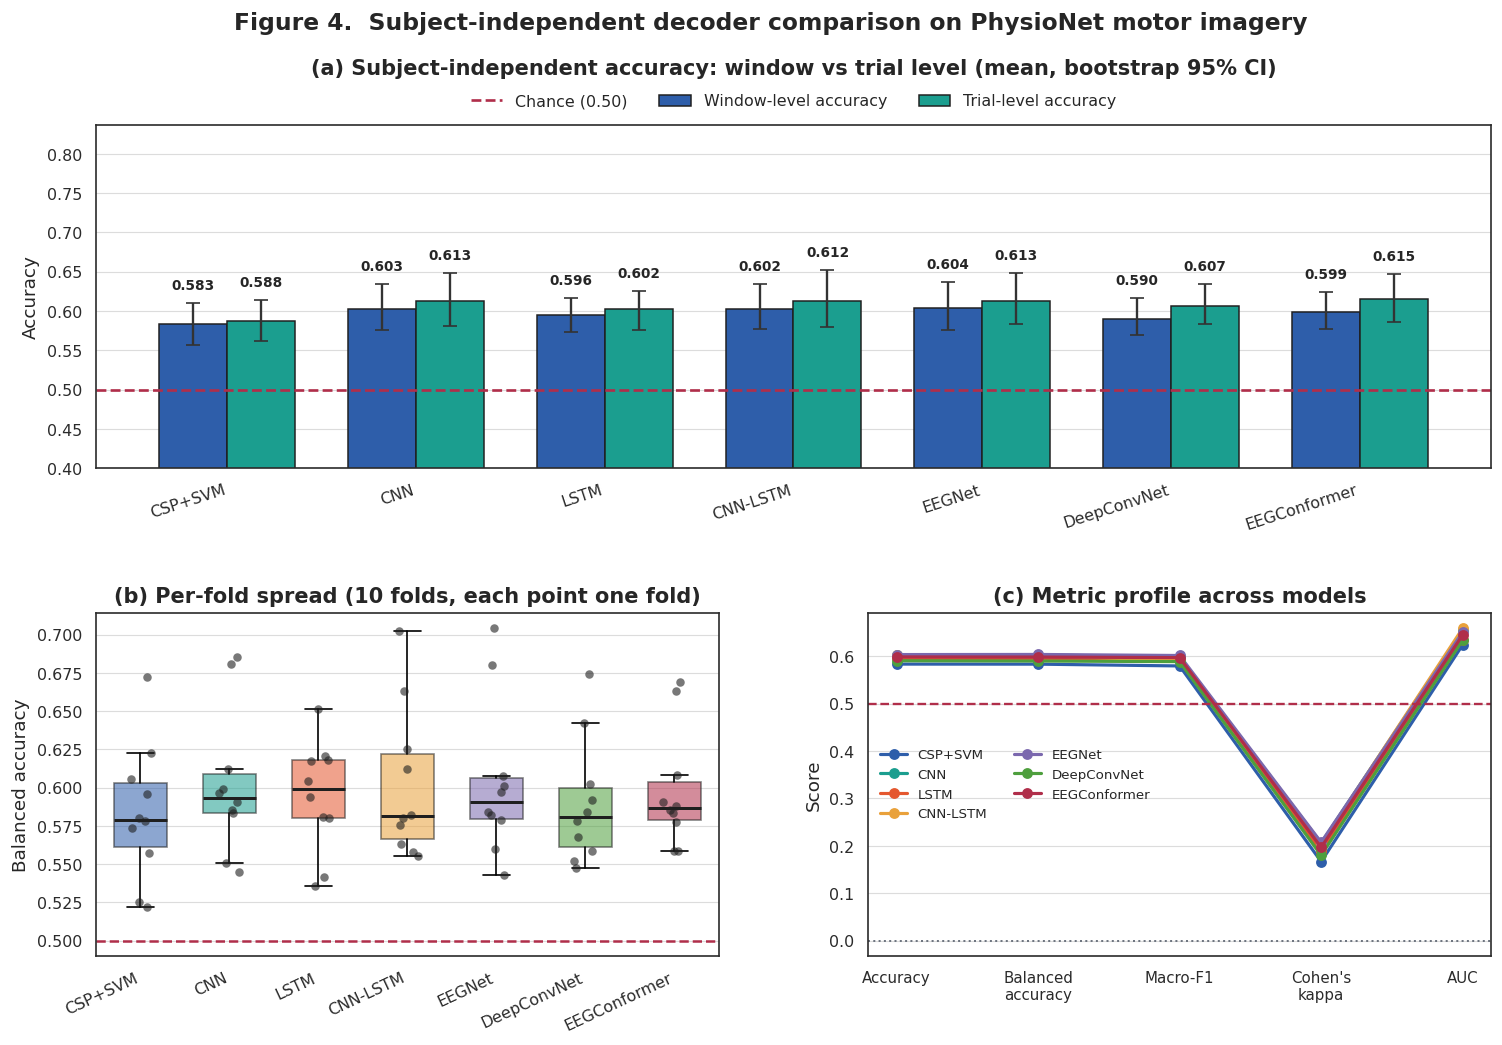

In [31]:
# ---------------------------------------------------------------------------------------------
# FIGURE 4: model comparison -- mean with bootstrap CI, plus every individual fold.
#
# Showing the fold-level points alongside the bars is deliberate. A bar chart with error bars can
# hide a model that is excellent on eight folds and catastrophic on two; the scatter cannot.
# ---------------------------------------------------------------------------------------------
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.24)

# (a) grouped bars: window vs trial accuracy with bootstrap CI
ax = fig.add_subplot(gs[0, :])
xs = np.arange(len(present_models))
w = 0.36
for j, (metric, label, colour) in enumerate([
        ("accuracy", "Window-level accuracy", PALETTE[0]),
        ("trial_accuracy", "Trial-level accuracy", PALETTE[1])]):
    means, errs = [], [[], []]
    for m in present_models:
        v = central_df.loc[central_df["model"] == m, metric]
        mu, lo, hi = bootstrap_ci(v)
        means.append(mu); errs[0].append(mu - lo); errs[1].append(hi - mu)
    bars = ax.bar(xs + (j - 0.5) * w, means, width=w, color=colour, edgecolor="#1f1f1f",
                  linewidth=0.9, label=label,
                  yerr=np.array(errs), capsize=4, error_kw=dict(elinewidth=1.4, ecolor="#333333"))
    # Labels sit above the upper CI cap, horizontally. Rotated labels collided with the CI
    # whiskers and with the neighbouring bar, which made the panel unreadable.
    for b, mu, e_hi in zip(bars, means, errs[1]):
        ax.text(b.get_x() + b.get_width() / 2, mu + e_hi + 0.014, f"{mu:.3f}",
                ha="center", va="bottom", fontsize=8.2, fontweight="bold")
ax.axhline(0.5, color=PALETTE[6], linestyle="--", linewidth=1.6, label="Chance (0.50)")
ax.set_xticks(xs); ax.set_xticklabels(present_models, rotation=18, ha="right")
ax.set_ylabel("Accuracy")
_top = max(central_df["trial_accuracy"].max(), central_df["accuracy"].max())
ax.set_ylim(0.40, min(1.09, _top + 0.11))       # headroom for the value labels
ax.set_title("(a) Subject-independent accuracy: window vs trial level (mean, bootstrap 95% CI)",
             pad=30)
# Legend placed in the gap between the axis and its title so it can never cover a bar.
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.005), frameon=False, fontsize=9.5)
ax.grid(axis="x", visible=False)

# (b) per-fold distribution
ax = fig.add_subplot(gs[1, 0])
data = [central_df.loc[central_df["model"] == m, "balanced_acc"].values for m in present_models]
bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=False,
                medianprops=dict(color="#1f1f1f", linewidth=1.8))
for patch, m in zip(bp["boxes"], present_models):
    patch.set_facecolor(MODEL_COLORS.get(m, PALETTE[0])); patch.set_alpha(0.55)
    patch.set_edgecolor("#1f1f1f")
rng = np.random.default_rng(SEED)
for i, vals in enumerate(data, start=1):
    ax.scatter(np.full(len(vals), i) + rng.uniform(-0.13, 0.13, len(vals)), vals,
               s=26, color="#1f1f1f", alpha=0.6, zorder=3, linewidths=0)
ax.axhline(0.5, color=PALETTE[6], linestyle="--", linewidth=1.5)
ax.set_xticks(np.arange(1, len(present_models) + 1))
ax.set_xticklabels(present_models, rotation=25, ha="right")
ax.set_ylabel("Balanced accuracy")
ax.set_title(f"(b) Per-fold spread ({len(FOLDS)} folds, each point one fold)")
ax.grid(axis="x", visible=False)

# (c) metric profile: normalised radar-style comparison on a common axis
ax = fig.add_subplot(gs[1, 1])
metrics = ["accuracy", "balanced_acc", "f1", "kappa", "auc"]
labels = ["Accuracy", "Balanced\naccuracy", "Macro-F1", "Cohen's\nkappa", "AUC"]
for m in present_models:
    vals = [central_df.loc[central_df["model"] == m, mt].mean() for mt in metrics]
    ax.plot(np.arange(len(metrics)), vals, marker="o", markersize=5.5,
            color=MODEL_COLORS.get(m, GREY), label=m, linewidth=1.9)
ax.axhline(0.5, color=PALETTE[6], linestyle="--", linewidth=1.4)
ax.axhline(0.0, color=GREY, linestyle=":", linewidth=1.2)
ax.set_xticks(np.arange(len(metrics))); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Score")
ax.set_title("(c) Metric profile across models")
ax.legend(fontsize=8, ncol=2)
ax.grid(axis="x", visible=False)

fig.suptitle("Figure 4.  Subject-independent decoder comparison on PhysioNet motor imagery",
             fontsize=14, fontweight="bold", y=0.985)
register(save_fig(fig, "fig4_model_comparison"), "figure", "Figure 4 - model comparison")
plt.show()

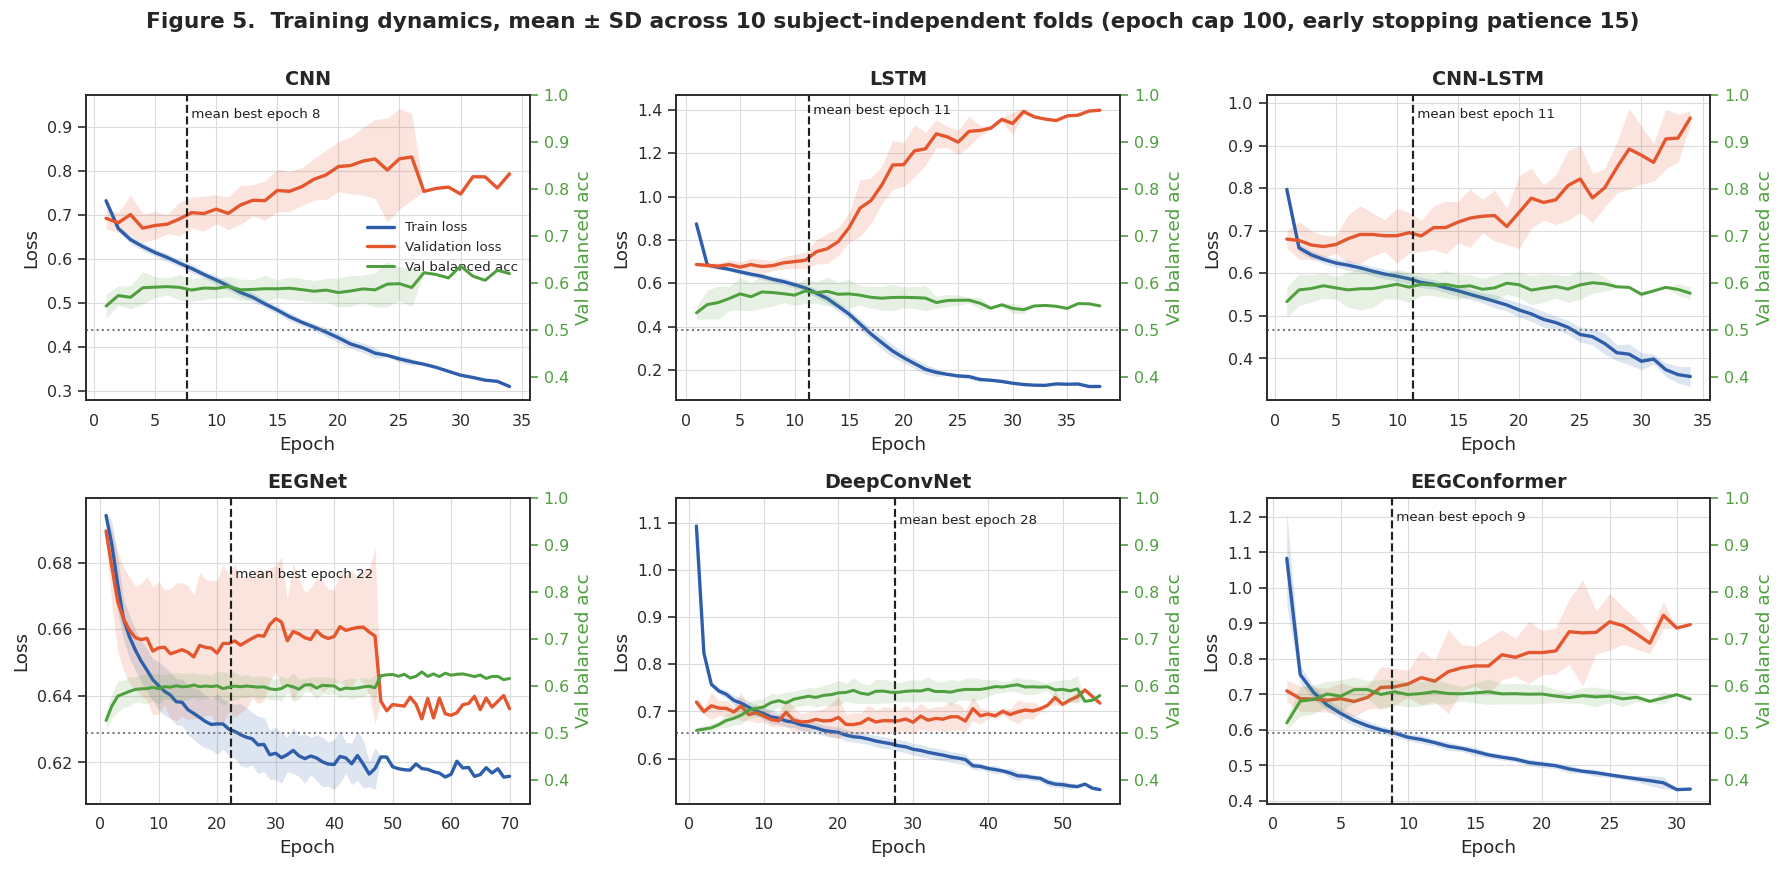

In [32]:
# ---------------------------------------------------------------------------------------------
# FIGURE 5: training dynamics. Mean +- SD across folds per architecture.
#
# Folds early-stop at different epochs, so curves have different lengths. They are aligned by
# epoch index and averaged only over the folds still running at that epoch -- padding with the
# final value instead would flatten the tail and make convergence look better than it was.
# ---------------------------------------------------------------------------------------------
def mean_curve(curves):
    """Element-wise mean/SD/count over ragged curves, without padding."""
    if not curves:
        return np.array([]), np.array([]), np.array([])
    L = max(len(c) for c in curves)
    mu = np.full(L, np.nan); sd = np.full(L, np.nan); n = np.zeros(L, dtype=int)
    for i in range(L):
        vals = np.array([c[i] for c in curves if len(c) > i], dtype=float)
        mu[i] = vals.mean(); sd[i] = vals.std(ddof=1) if len(vals) > 1 else 0.0
        n[i] = len(vals)
    return mu, sd, n

deep_present = [m for m in DEEP_MODELS if m in histories]
ncol = 3
nrow = int(np.ceil(len(deep_present) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.0 * ncol, 3.6 * nrow), squeeze=False)

for i, name in enumerate(deep_present):
    ax = axes[i // ncol][i % ncol]
    hs = histories[name]
    for key, colour, label in [("train_loss", PALETTE[0], "Train loss"),
                               ("val_loss", PALETTE[2], "Validation loss")]:
        mu, sd, n = mean_curve([h[key] for h in hs])
        ep = np.arange(1, len(mu) + 1)
        ax.plot(ep, mu, color=colour, label=label)
        ax.fill_between(ep, mu - sd, mu + sd, color=colour, alpha=0.16, linewidth=0)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(name, fontsize=11.5)

    ax2 = ax.twinx()
    mu, sd, _ = mean_curve([h["val_bacc"] for h in hs])
    ep = np.arange(1, len(mu) + 1)
    ax2.plot(ep, mu, color=PALETTE[5], linewidth=1.8, label="Val balanced acc")
    ax2.fill_between(ep, mu - sd, mu + sd, color=PALETTE[5], alpha=0.14, linewidth=0)
    ax2.axhline(0.5, color=GREY, linestyle=":", linewidth=1.2)
    ax2.set_ylabel("Val balanced acc", color=PALETTE[5])
    ax2.tick_params(axis="y", colors=PALETTE[5])
    ax2.grid(False)
    ax2.set_ylim(0.35, 1.0)

    best_eps = [h["best_epoch"] for h in hs]
    ax.axvline(float(np.mean(best_eps)), color="#1f1f1f", linestyle="--", linewidth=1.3)
    ax.text(float(np.mean(best_eps)), ax.get_ylim()[1] * 0.97,
            f" mean best epoch {np.mean(best_eps):.0f}", fontsize=8, va="top", color="#1f1f1f")
    if i == 0:
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="center right")

for j in range(len(deep_present), nrow * ncol):
    axes[j // ncol][j % ncol].axis("off")

fig.suptitle(f"Figure 5.  Training dynamics, mean ± SD across {len(FOLDS)} subject-independent folds "
             f"(epoch cap {CONFIG['EPOCHS']}, early stopping patience {CONFIG['PATIENCE']})",
             fontsize=13, fontweight="bold", y=1.0)
fig.tight_layout()
register(save_fig(fig, "fig5_training_curves"), "figure", "Figure 5 - training dynamics")
plt.show()

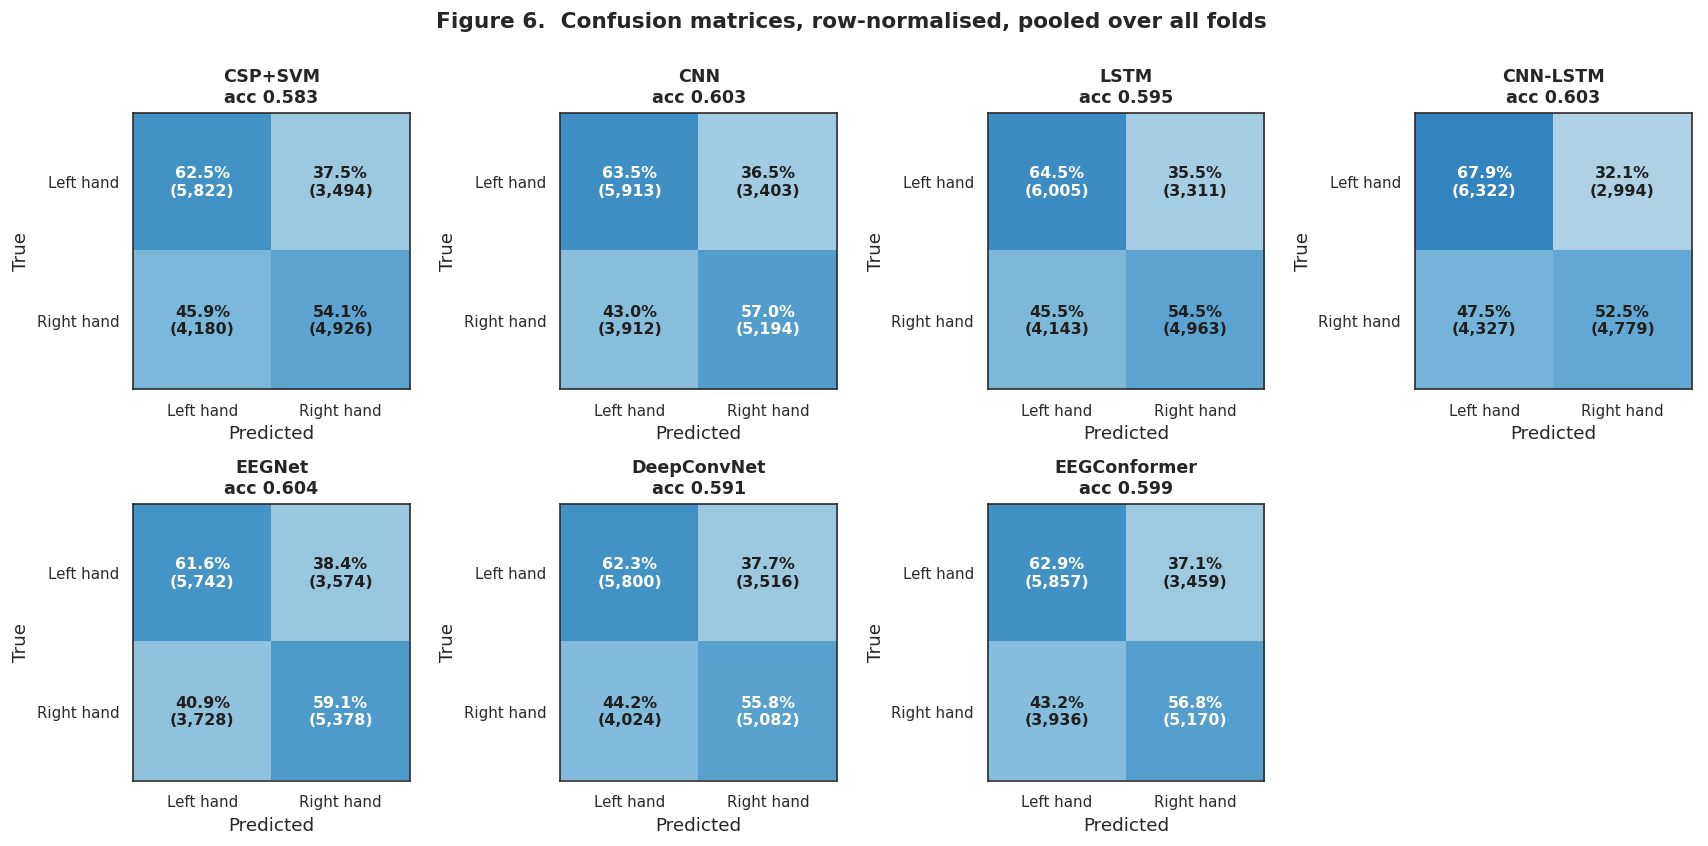

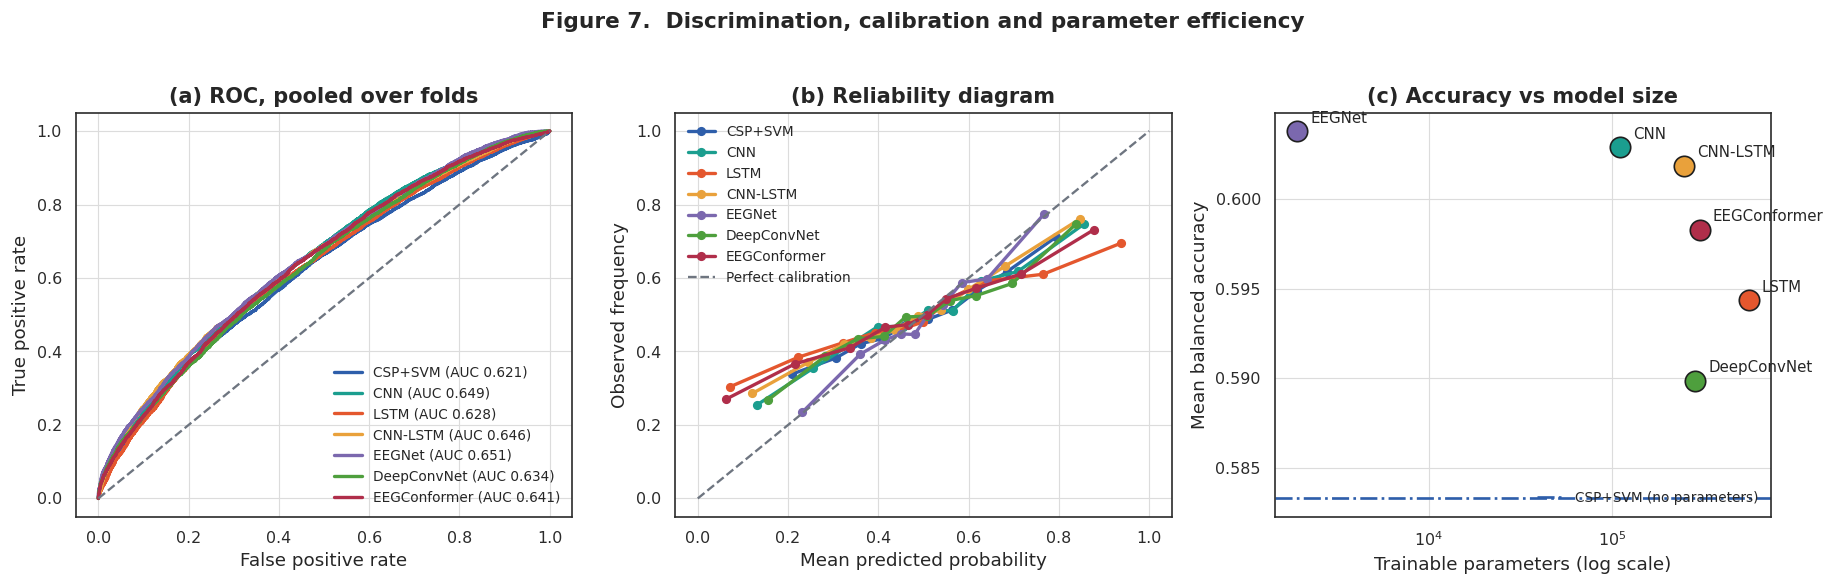

Model,Pooled AUC,ECE
CSP+SVM,0.6209,0.0584
CNN,0.6486,0.0668
LSTM,0.6277,0.1021
CNN-LSTM,0.6456,0.0645
EEGNet,0.6510,0.0135
DeepConvNet,0.6343,0.0654
EEGConformer,0.6413,0.0789


In [33]:
# ---------------------------------------------------------------------------------------------
# FIGURE 6: confusion matrices (summed over all folds) + FIGURE 7: pooled ROC curves.
# ---------------------------------------------------------------------------------------------
ncol = 4
nrow = int(np.ceil(len(present_models) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 3.5 * nrow), squeeze=False)
for i, name in enumerate(present_models):
    ax = axes[i // ncol][i % ncol]
    cm = cm_store[name]
    cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{cmn[r, c]*100:.1f}%\n({cm[r, c]:,})", ha="center", va="center",
                    fontsize=9.5, fontweight="bold",
                    color="white" if cmn[r, c] > 0.55 else "#1f1f1f")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASS_NAMES, fontsize=9); ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{name}\nacc {np.trace(cm)/cm.sum():.3f}", fontsize=10.5)
    ax.grid(False)
for j in range(len(present_models), nrow * ncol):
    axes[j // ncol][j % ncol].axis("off")
fig.suptitle("Figure 6.  Confusion matrices, row-normalised, pooled over all folds",
             fontsize=13, fontweight="bold", y=1.0)
fig.tight_layout()
register(save_fig(fig, "fig6_confusion_matrices"), "figure", "Figure 6 - confusion matrices")
plt.show()


# ---- Figure 7: ROC + calibration --------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.7))

ax = axes[0]
auc_rows = []
for name in present_models:
    yt = np.concatenate([a for a, _ in roc_store[name]])
    pp = np.concatenate([b for _, b in roc_store[name]])
    fpr, tpr, _ = roc_curve(yt, pp)
    auc = roc_auc_score(yt, pp)
    ax.plot(fpr, tpr, color=MODEL_COLORS.get(name, GREY), label=f"{name} (AUC {auc:.3f})")
    auc_rows.append({"Model": name, "Pooled AUC": auc,
                     "ECE": expected_calibration_error(yt, pp)})
ax.plot([0, 1], [0, 1], color=GREY, linestyle="--", linewidth=1.4)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("(a) ROC, pooled over folds"); ax.legend(fontsize=8.2, loc="lower right")

# (b) calibration -- reliability diagram
ax = axes[1]
for name in present_models:
    yt = np.concatenate([a for a, _ in roc_store[name]])
    pp = np.concatenate([b for _, b in roc_store[name]])
    try:
        frac_pos, mean_pred = calibration_curve(yt, pp, n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", markersize=4.5,
                color=MODEL_COLORS.get(name, GREY), label=name)
    except Exception:
        pass
ax.plot([0, 1], [0, 1], color=GREY, linestyle="--", linewidth=1.4, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed frequency")
ax.set_title("(b) Reliability diagram"); ax.legend(fontsize=8.2, loc="upper left")

# (c) accuracy vs parameter count -- is the extra capacity earning anything?
ax = axes[2]
for name in present_models:
    n_p = PARAM_COUNTS.get(name, np.nan)
    acc = central_df.loc[central_df["model"] == name, "balanced_acc"].mean()
    if not np.isfinite(n_p):
        ax.axhline(acc, color=MODEL_COLORS.get(name, GREY), linestyle="-.", linewidth=1.6,
                   label=f"{name} (no parameters)")
        continue
    ax.scatter(n_p, acc, s=150, color=MODEL_COLORS.get(name, GREY),
               edgecolor="#1f1f1f", linewidth=1.0, zorder=3)
    ax.annotate(name, (n_p, acc), textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Trainable parameters (log scale)")
ax.set_ylabel("Mean balanced accuracy")
ax.set_title("(c) Accuracy vs model size")
ax.legend(fontsize=8.2, loc="lower right")

fig.suptitle("Figure 7.  Discrimination, calibration and parameter efficiency",
             fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout()
register(save_fig(fig, "fig7_roc_calibration_efficiency"), "figure",
         "Figure 7 - ROC, calibration, efficiency")
plt.show()

auc_tbl = pd.DataFrame(auc_rows)
show_table(auc_tbl, save_path=os.path.join(TAB_DIR, "table5_auc_calibration.csv"),
           title="Table 5 — Pooled AUC and expected calibration error", float_fmt="{:.4f}")
register(os.path.join(TAB_DIR, "table5_auc_calibration.csv"), "table", "AUC and calibration")

### 9.3 Per-subject accuracy — the BCI-inefficiency phenomenon

A pooled mean hides the finding that matters most for deployment. Across MI-BCI studies a substantial minority
of users cannot control the interface above chance, and a decoder averaging 75 % may be excellent for most
participants while useless for some. This figure reports the full per-subject distribution, and quantifies the
proportion of subjects who exceed chance and the proportion who exceed the 70 % threshold conventionally cited
as the minimum for practical BCI control.

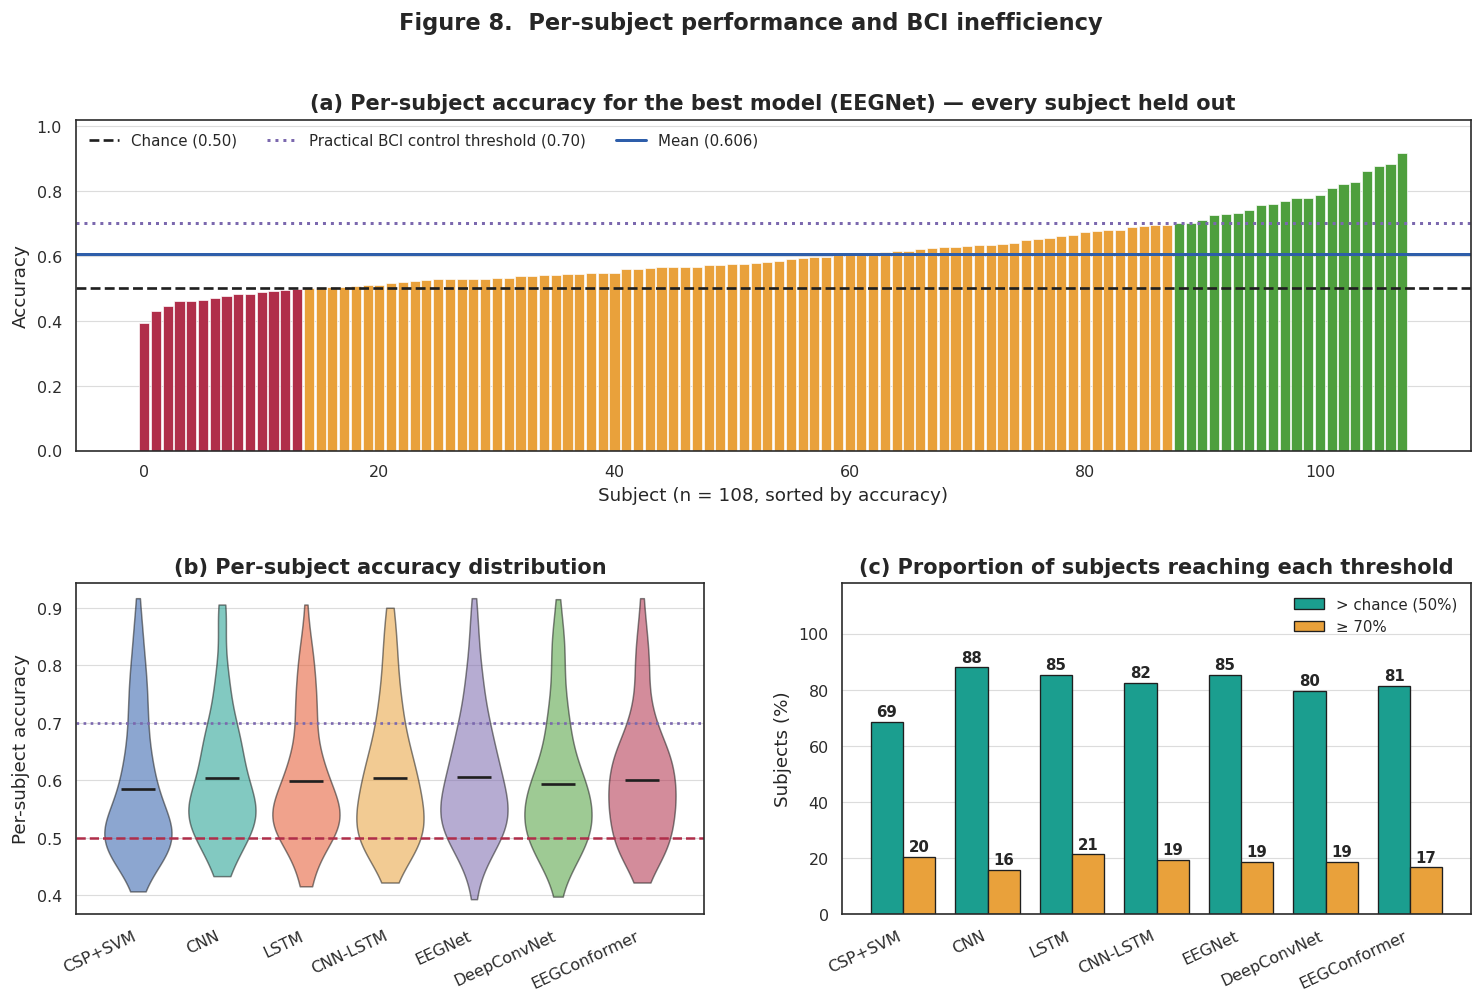

Model,n subjects,Mean,Median,SD,Min,Max,> chance (%),>= 0.70 (%)
CSP+SVM,108.000,0.585,0.543,0.118,0.407,0.917,68.519,20.370
CNN,108.000,0.604,0.574,0.108,0.433,0.906,87.963,15.741
LSTM,108.000,0.598,0.568,0.109,0.416,0.906,85.185,21.296
CNN-LSTM,108.000,0.604,0.578,0.113,0.422,0.900,82.407,19.444
EEGNet,108.000,0.606,0.582,0.108,0.393,0.917,85.185,18.519
DeepConvNet,108.000,0.594,0.566,0.112,0.398,0.915,79.630,18.519
EEGConformer,108.000,0.601,0.583,0.106,0.422,0.917,81.481,16.667


In [34]:
# ---------------------------------------------------------------------------------------------
# FIGURE 8: per-subject accuracy distribution (BCI inefficiency).
# Every subject appears in exactly one test fold, so these are all out-of-sample estimates.
# ---------------------------------------------------------------------------------------------
fig = plt.figure(figsize=(15, 8.6))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], hspace=0.40, wspace=0.22)

# (a) sorted per-subject accuracy for the best model
ax = fig.add_subplot(gs[0, :])
best_sub = subject_df[subject_df["model"] == BEST_MODEL].sort_values("accuracy")
colours = [PALETTE[6] if a < 0.5 else (PALETTE[3] if a < 0.7 else PALETTE[5])
           for a in best_sub["accuracy"]]
ax.bar(np.arange(len(best_sub)), best_sub["accuracy"], color=colours, width=0.86,
       edgecolor="white", linewidth=0.4)
ax.axhline(0.5, color="#1f1f1f", linestyle="--", linewidth=1.6, label="Chance (0.50)")
ax.axhline(0.7, color=PALETTE[4], linestyle=":", linewidth=1.8,
           label="Practical BCI control threshold (0.70)")
ax.axhline(best_sub["accuracy"].mean(), color=PALETTE[0], linestyle="-", linewidth=1.8,
           label=f"Mean ({best_sub['accuracy'].mean():.3f})")
ax.set_xlabel(f"Subject (n = {len(best_sub)}, sorted by accuracy)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.02)
ax.set_title(f"(a) Per-subject accuracy for the best model ({BEST_MODEL}) — every subject held out")
ax.legend(ncol=3, fontsize=9)
ax.grid(axis="x", visible=False)

# (b) distribution across models
ax = fig.add_subplot(gs[1, 0])
data = [subject_df.loc[subject_df["model"] == m, "accuracy"].values for m in present_models]
parts = ax.violinplot(data, showmeans=True, showextrema=False, widths=0.8)
for pc, m in zip(parts["bodies"], present_models):
    pc.set_facecolor(MODEL_COLORS.get(m, GREY)); pc.set_alpha(0.55)
    pc.set_edgecolor("#1f1f1f"); pc.set_linewidth(0.9)
parts["cmeans"].set_color("#1f1f1f"); parts["cmeans"].set_linewidth(1.6)
ax.axhline(0.5, color=PALETTE[6], linestyle="--", linewidth=1.5)
ax.axhline(0.7, color=PALETTE[4], linestyle=":", linewidth=1.6)
ax.set_xticks(np.arange(1, len(present_models) + 1))
ax.set_xticklabels(present_models, rotation=25, ha="right")
ax.set_ylabel("Per-subject accuracy")
ax.set_title("(b) Per-subject accuracy distribution")
ax.grid(axis="x", visible=False)

# (c) proportion of subjects above each threshold
ax = fig.add_subplot(gs[1, 1])
thr_rows = []
for m in present_models:
    v = subject_df.loc[subject_df["model"] == m, "accuracy"].values
    thr_rows.append({"Model": m, "n subjects": len(v), "Mean": v.mean(), "Median": np.median(v),
                     "SD": v.std(ddof=1), "Min": v.min(), "Max": v.max(),
                     "> chance (%)": 100 * np.mean(v > 0.5),
                     ">= 0.70 (%)": 100 * np.mean(v >= 0.7)})
thr_df = pd.DataFrame(thr_rows)
xs = np.arange(len(present_models)); w = 0.38
b1 = ax.bar(xs - w / 2, thr_df["> chance (%)"], width=w, color=PALETTE[1],
            edgecolor="#1f1f1f", linewidth=0.8, label="> chance (50%)")
b2 = ax.bar(xs + w / 2, thr_df[">= 0.70 (%)"], width=w, color=PALETTE[3],
            edgecolor="#1f1f1f", linewidth=0.8, label=u"≥ 70%")
annotate_bars(ax, b1, thr_df["> chance (%)"].values, fmt="{:.0f}")
annotate_bars(ax, b2, thr_df[">= 0.70 (%)"].values, fmt="{:.0f}")
ax.set_xticks(xs); ax.set_xticklabels(present_models, rotation=25, ha="right")
ax.set_ylabel("Subjects (%)"); ax.set_ylim(0, 118)
ax.set_title("(c) Proportion of subjects reaching each threshold")
ax.legend(fontsize=9); ax.grid(axis="x", visible=False)

fig.suptitle("Figure 8.  Per-subject performance and BCI inefficiency",
             fontsize=13.5, fontweight="bold", y=0.985)
register(save_fig(fig, "fig8_per_subject"), "figure", "Figure 8 - per-subject accuracy")
plt.show()

show_table(thr_df, save_path=os.path.join(TAB_DIR, "table6_per_subject_summary.csv"),
           title="Table 6 — Per-subject accuracy summary", float_fmt="{:.3f}",
           highlight_max_cols=["Mean", "Median", "> chance (%)", ">= 0.70 (%)"])
register(os.path.join(TAB_DIR, "table6_per_subject_summary.csv"), "table", "Per-subject summary")

Model A,Model B,n folds,Mean A,Mean B,Difference,Cohen's d,Wilcoxon p,t-test p,Wilcoxon p (Holm),Significant (a=0.05)
CSP+SVM,CNN,10,0.5833,0.6029,-0.01958,-0.5714,0.03711,0.1043,0.7793,0
CSP+SVM,LSTM,10,0.5833,0.5944,-0.01106,-0.6581,0.08398,0.06714,1,0
CSP+SVM,CNN-LSTM,10,0.5833,0.6019,-0.01856,-0.5473,0.1055,0.1175,1,0
CSP+SVM,EEGNet,10,0.5833,0.6038,-0.02049,-0.602,0.06445,0.08938,1,0
CSP+SVM,DeepConvNet,10,0.5833,0.5899,-0.006574,-0.1624,1,0.62,1,0
CSP+SVM,EEGConformer,10,0.5833,0.5983,-0.01499,-0.4371,0.2324,0.2002,1,0
CNN,LSTM,10,0.6029,0.5944,0.008518,0.3495,0.4316,0.2978,1,0
CNN,CNN-LSTM,10,0.6029,0.6019,0.001022,0.05711,0.8457,0.8607,1,0
CNN,EEGNet,10,0.6029,0.6038,-0.0009142,-0.08219,1,0.8008,1,0
CNN,DeepConvNet,10,0.6029,0.5899,0.01301,0.7425,0.06445,0.04344,1,0


Positive 'Difference' favours Model A. |d| ~ 0.2 small, 0.5 medium, 0.8 large.


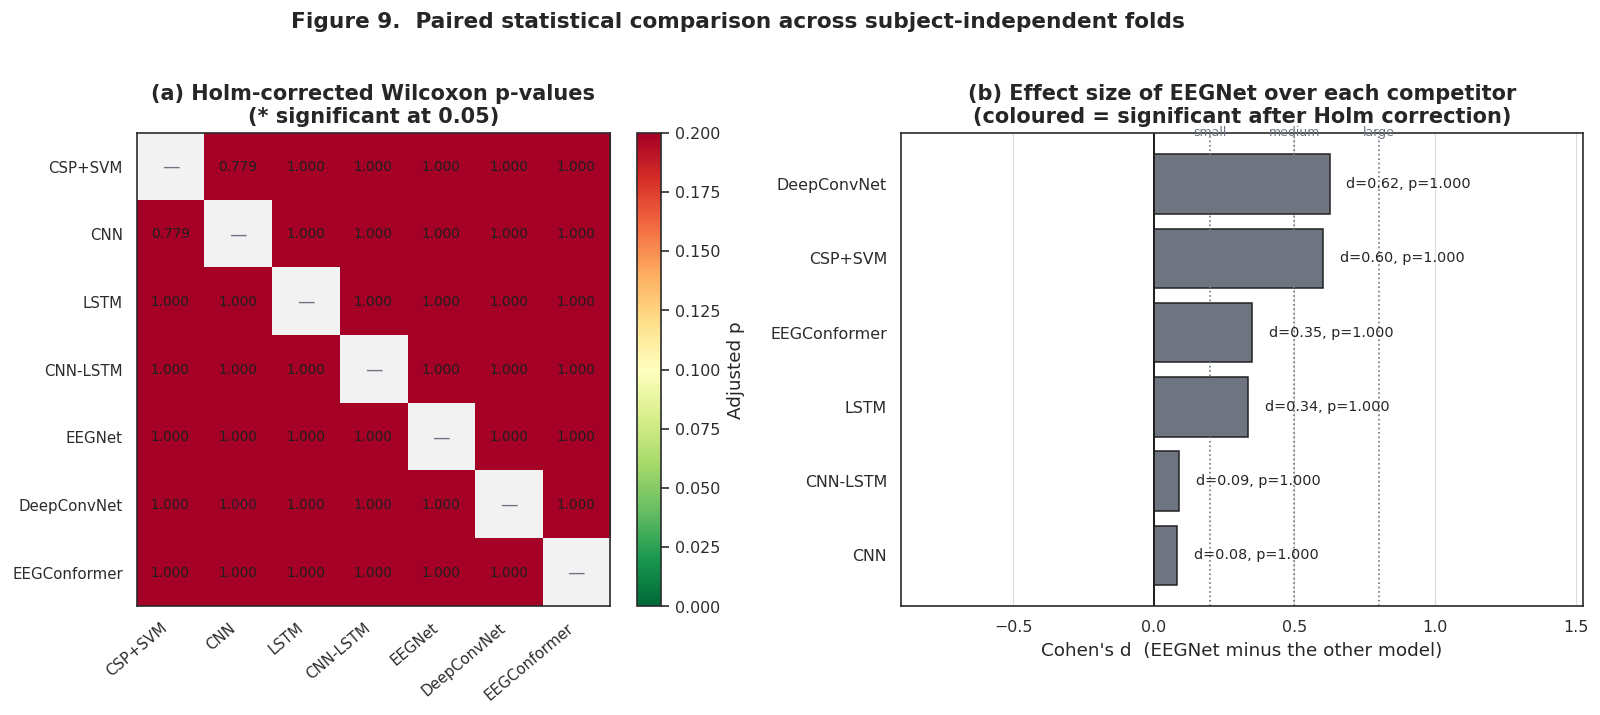

In [35]:
# ---------------------------------------------------------------------------------------------
# TABLE 7 + FIGURE 9: pairwise statistical comparison, Holm-corrected.
# ---------------------------------------------------------------------------------------------
stat_df = paired_compare(central_df, "balanced_acc", present_models)
show_table(stat_df.sort_values("Wilcoxon p (Holm)"),
           save_path=os.path.join(TAB_DIR, "table7_pairwise_tests.csv"),
           title=(f"Table 7 — Pairwise paired comparison of balanced accuracy across "
                  f"{len(FOLDS)} folds (Holm-corrected)"),
           float_fmt="{:.4g}",
           note="Positive 'Difference' favours Model A. |d| ~ 0.2 small, 0.5 medium, 0.8 large.")
register(os.path.join(TAB_DIR, "table7_pairwise_tests.csv"), "table", "Pairwise statistical tests")

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8))

# (a) Holm-corrected p-value matrix
ax = axes[0]
n = len(present_models)
P = np.full((n, n), np.nan)
idx = {m: i for i, m in enumerate(present_models)}
for _, r in stat_df.iterrows():
    i, j = idx[r["Model A"]], idx[r["Model B"]]
    P[i, j] = P[j, i] = r["Wilcoxon p (Holm)"]
masked = np.ma.masked_invalid(P)
cmap = plt.get_cmap("RdYlGn_r").copy(); cmap.set_bad("#f2f2f2")
im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=0.2)
for i in range(n):
    for j in range(n):
        if i == j:
            ax.text(j, i, "—", ha="center", va="center", color=GREY)
        elif np.isfinite(P[i, j]):
            star = "*" if P[i, j] < 0.05 else ""
            ax.text(j, i, f"{P[i, j]:.3f}{star}", ha="center", va="center", fontsize=8.2,
                    fontweight="bold" if P[i, j] < 0.05 else "normal",
                    color="white" if P[i, j] < 0.04 else "#1f1f1f")
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(present_models, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(present_models, fontsize=9)
ax.set_title("(a) Holm-corrected Wilcoxon p-values\n(* significant at 0.05)")
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Adjusted p")

# (b) effect sizes against the best model
ax = axes[1]
comp = []
for _, r in stat_df.iterrows():
    if r["Model A"] == BEST_MODEL:
        comp.append((r["Model B"], r["Cohen's d"], r["Wilcoxon p (Holm)"]))
    elif r["Model B"] == BEST_MODEL:
        comp.append((r["Model A"], -r["Cohen's d"], r["Wilcoxon p (Holm)"]))
comp.sort(key=lambda t: t[1])
names = [c[0] for c in comp]; ds = [c[1] for c in comp]; ps = [c[2] for c in comp]
cols = [PALETTE[5] if p < 0.05 else GREY for p in ps]
bars = ax.barh(np.arange(len(names)), ds, color=cols, edgecolor="#1f1f1f", linewidth=0.9)
for i, (d, p) in enumerate(zip(ds, ps)):
    ax.text(d + (0.06 if d >= 0 else -0.06), i, f"d={d:.2f}, p={p:.3f}",
            va="center", ha="left" if d >= 0 else "right", fontsize=8.6)
for x, lab in [(0.2, "small"), (0.5, "medium"), (0.8, "large")]:
    ax.axvline(x, color=GREY, linestyle=":", linewidth=1.0)
    ax.text(x, len(names) - 0.35, lab, fontsize=7.5, ha="center", color=GREY)
ax.axvline(0, color="#1f1f1f", linewidth=1.2)
ax.set_yticks(np.arange(len(names))); ax.set_yticklabels(names)
ax.set_xlabel(f"Cohen's d  ({BEST_MODEL} minus the other model)")
ax.set_title(f"(b) Effect size of {BEST_MODEL} over each competitor\n"
             "(coloured = significant after Holm correction)")
ax.set_xlim(min(ds + [0]) - 0.9, max(ds + [0]) + 0.9)
ax.grid(axis="y", visible=False)

fig.suptitle("Figure 9.  Paired statistical comparison across subject-independent folds",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
register(save_fig(fig, "fig9_statistical_tests"), "figure", "Figure 9 - statistical comparison")
plt.show()

### 9.4 Research gap 3 — is the CNN-LSTM hybrid actually worse than its own components?

The literature reports inconsistent results for convolutional-recurrent hybrids on MI-EEG: sometimes better than
either component, sometimes worse. Since all three models here are trained under an identical protocol on
identical folds, that question can be answered directly instead of asserted.

The test is paired, on the same ten folds, with an effect size. A hybrid that is *not* significantly better than
its own components is a reportable negative result, and it is a more useful contribution than quietly omitting
the comparison.

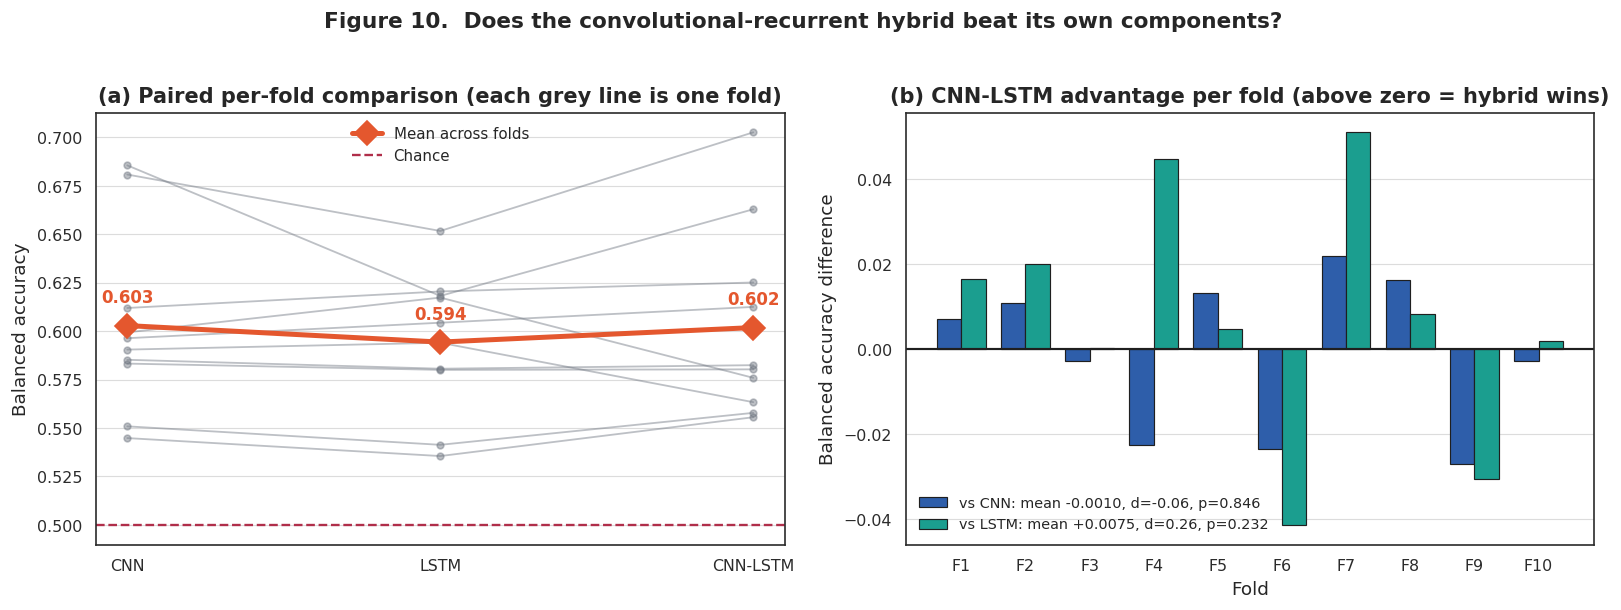

Verdict on the hybrid architecture:
  CNN-LSTM underperforms CNN   by 0.0010 balanced accuracy (not significant, p = 0.8457, Cohen's d = -0.057)
  CNN-LSTM outperforms LSTM  by 0.0075 balanced accuracy (not significant, p = 0.2324, Cohen's d = +0.260)


In [36]:
# ---------------------------------------------------------------------------------------------
# FIGURE 10: CNN-LSTM versus its own components (research gap 3).
# ---------------------------------------------------------------------------------------------
hyb_models = [m for m in ("CNN", "LSTM", "CNN-LSTM") if m in present_models]
if len(hyb_models) == 3:
    wide = central_df.pivot_table(index="fold", columns="model", values="balanced_acc")
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.9))

    # (a) fold-by-fold paired lines
    ax = axes[0]
    for f in wide.index:
        ax.plot(range(3), [wide.loc[f, m] for m in hyb_models],
                color=GREY, alpha=0.45, marker="o", markersize=4, linewidth=1.1)
    means = [wide[m].mean() for m in hyb_models]
    ax.plot(range(3), means, color=PALETTE[2], marker="D", markersize=10, linewidth=3,
            label="Mean across folds", zorder=5)
    for i, mu in enumerate(means):
        ax.text(i, mu + 0.012, f"{mu:.3f}", ha="center", fontsize=10, fontweight="bold",
                color=PALETTE[2])
    ax.axhline(0.5, color=PALETTE[6], linestyle="--", linewidth=1.4, label="Chance")
    ax.set_xticks(range(3)); ax.set_xticklabels(hyb_models)
    ax.set_ylabel("Balanced accuracy")
    ax.set_title("(a) Paired per-fold comparison (each grey line is one fold)")
    ax.legend(fontsize=9); ax.grid(axis="x", visible=False)

    # (b) hybrid minus each component, per fold
    ax = axes[1]
    diffs = {c: (wide["CNN-LSTM"] - wide[c]).values for c in ("CNN", "LSTM")}
    xs = np.arange(len(wide.index)); w = 0.38
    for j, (c, colour) in enumerate(zip(("CNN", "LSTM"), (PALETTE[0], PALETTE[1]))):
        d = diffs[c]
        try:
            _, p = wilcoxon(wide["CNN-LSTM"].values, wide[c].values)
        except Exception:
            p = float("nan")
        eff = cohens_d_paired(wide["CNN-LSTM"].values, wide[c].values)
        ax.bar(xs + (j - 0.5) * w, d, width=w, color=colour, edgecolor="#1f1f1f", linewidth=0.7,
               label=f"vs {c}: mean {d.mean():+.4f}, d={eff:.2f}, p={p:.3f}")
    ax.axhline(0, color="#1f1f1f", linewidth=1.3)
    ax.set_xticks(xs); ax.set_xticklabels([f"F{int(f)}" for f in wide.index])
    ax.set_xlabel("Fold"); ax.set_ylabel("Balanced accuracy difference")
    ax.set_title("(b) CNN-LSTM advantage per fold (above zero = hybrid wins)")
    ax.legend(fontsize=8.6); ax.grid(axis="x", visible=False)

    fig.suptitle("Figure 10.  Does the convolutional-recurrent hybrid beat its own components?",
                 fontsize=13, fontweight="bold", y=1.03)
    fig.tight_layout()
    register(save_fig(fig, "fig10_hybrid_analysis"), "figure", "Figure 10 - CNN-LSTM hybrid analysis")
    plt.show()

    # Verdict stated conditionally -- whichever way the data falls is reported as it is.
    print("Verdict on the hybrid architecture:")
    for c in ("CNN", "LSTM"):
        d = diffs[c]
        try:
            _, p = wilcoxon(wide["CNN-LSTM"].values, wide[c].values)
        except Exception:
            p = float("nan")
        eff = cohens_d_paired(wide["CNN-LSTM"].values, wide[c].values)
        direction = "outperforms" if d.mean() > 0 else "underperforms"
        sig = "significant" if (np.isfinite(p) and p < 0.05) else "not significant"
        print(f"  CNN-LSTM {direction} {c:<5s} by {abs(d.mean()):.4f} balanced accuracy "
              f"({sig}, p = {p:.4f}, Cohen's d = {eff:+.3f})")
else:
    print("CNN, LSTM and CNN-LSTM are not all present; the hybrid comparison is skipped.")

In [37]:
# ---------------------------------------------------------------------------------------------
# Top-3 soft-voting ensemble.
#
# Legitimate only because all models were evaluated on identical folds in identical window order,
# which is asserted below rather than assumed -- averaging misaligned probability vectors would
# produce a meaningless number that still looks plausible.
# ---------------------------------------------------------------------------------------------
ens_rows = []
for k in range(len(FOLDS)):
    ref_true = roc_store[TOP3_MODELS[0]][k][0]
    probs = []
    aligned = True
    for m in TOP3_MODELS:
        yt_m, pp_m = roc_store[m][k]
        if len(yt_m) != len(ref_true) or not np.array_equal(yt_m, ref_true):
            aligned = False
            break
        probs.append(pp_m)
    if not aligned:
        print(f"  fold {k+1}: window order differs between models -- ensemble skipped for this fold.")
        continue
    mean_prob = np.mean(probs, axis=0)
    pred = (mean_prob >= 0.5).astype(int)
    ens_rows.append({"fold": k + 1, "model": "Ensemble (top-3)",
                     "train_time_s": np.nan, "epochs_run": np.nan, "best_epoch": np.nan,
                     **compute_metrics(ref_true, pred, mean_prob)})

if ens_rows:
    ens_df = pd.DataFrame(ens_rows)
    cmp_rows = []
    for m in TOP3_MODELS:
        sub = central_df[central_df["model"] == m]
        cmp_rows.append({"Model": m, "Accuracy": sub["accuracy"].mean(),
                         "Balanced acc": sub["balanced_acc"].mean(),
                         "Macro-F1": sub["f1"].mean(), "AUC": sub["auc"].mean()})
    cmp_rows.append({"Model": f"Ensemble of {', '.join(TOP3_MODELS)}",
                     "Accuracy": ens_df["accuracy"].mean(),
                     "Balanced acc": ens_df["balanced_acc"].mean(),
                     "Macro-F1": ens_df["f1"].mean(), "AUC": ens_df["auc"].mean()})
    ens_tbl = pd.DataFrame(cmp_rows)
    show_table(ens_tbl, save_path=os.path.join(TAB_DIR, "table8_ensemble.csv"),
               title="Table 8 — Top-3 soft-voting ensemble versus its members",
               float_fmt="{:.4f}", highlight_max_cols=["Accuracy", "Balanced acc", "Macro-F1", "AUC"])
    register(os.path.join(TAB_DIR, "table8_ensemble.csv"), "table", "Ensemble comparison")

    gain = ens_df["balanced_acc"].mean() - central_df.loc[
        central_df["model"] == BEST_MODEL, "balanced_acc"].mean()
    print(f"\nEnsemble balanced accuracy change relative to the best single model "
          f"({BEST_MODEL}): {gain:+.4f}")
    print("Reported as measured. An ensemble that does not help is still a finding: it indicates "
          "the models are making correlated errors, i.e. the ceiling is in the data rather than "
          "in the architecture.")
else:
    ens_df = pd.DataFrame()
    print("Ensemble skipped (no fold had aligned predictions across the top-3 models).")

Model,Accuracy,Balanced acc,Macro-F1,AUC
EEGNet,0.6035,0.6038,0.6016,0.6511
CNN,0.6029,0.6029,0.5982,0.6547
CNN-LSTM,0.6023,0.6019,0.5906,0.6591
"Ensemble of EEGNet, CNN, CNN-LSTM",0.6184,0.6183,0.6134,0.6715



Ensemble balanced accuracy change relative to the best single model (EEGNet): +0.0145
Reported as measured. An ensemble that does not help is still a finding: it indicates the models are making correlated errors, i.e. the ceiling is in the data rather than in the architecture.


### 9.4b FedProx μ sensitivity (supplementary diagnostic)

FedProx is evaluated in Section 9 with `CONFIG["FEDPROX_MU"]` fixed to a single value. Whether
"FedProx beats FedAvg" or "makes no difference" is itself a function of mu, so a claim built on one
mu value alone is not yet a claim about FedProx -- it is a claim about that one setting. The sweep
below reruns FedProx across three mu values, on one representative fold and the strongest
centralised architecture, so this question is closed before it reaches a reviewer rather than
after.

In [38]:
# ---------------------------------------------------------------------------------------------
# Section 8.3 -- FedProx mu sensitivity sweep
# ---------------------------------------------------------------------------------------------
MU_SWEEP_VALUES = [0.001, 0.01, 0.1]
_mu_model = FED_MODELS[0]
_mu_fold_idx = 0
_mu_tr, _mu_va, _mu_te = FOLDS[_mu_fold_idx]

mu_sweep_rows = []

for mu_val in tqdm(MU_SWEEP_VALUES, desc="FedProx mu sweep"):
    _cfg_backup = CONFIG["FEDPROX_MU"]
    CONFIG["FEDPROX_MU"] = mu_val

    try:
        metrics, history = run_federated(
            _mu_model,
            "fedprox",
            X_uv,
            y,
            subj,
            trial,
            _mu_tr,
            _mu_va,
            _mu_te,
            seed=SEED
        )

        print("Metrics keys:", metrics.keys())

    finally:
        CONFIG["FEDPROX_MU"] = _cfg_backup

    mu_sweep_rows.append({
        "mu": mu_val,
        "model": _mu_model,
        "test_balanced_acc": metrics.get("balanced_acc", np.nan)
    })

mu_sweep_df = pd.DataFrame(mu_sweep_rows)

display(mu_sweep_df)

FedProx mu sweep:   0%|          | 0/3 [00:00<?, ?it/s]

Metrics keys: dict_keys(['accuracy', 'balanced_acc', 'precision', 'recall', 'f1', 'kappa', 'auc', 'trial_accuracy', 'trial_balanced_acc', 'trial_precision', 'trial_recall', 'trial_f1', 'trial_kappa', 'trial_auc', 'trial_n', 'best_round', 'rounds', 'n_clients', 'clients_per_round', 'communication_MB', 'n_params', 'n_transmitted'])
Metrics keys: dict_keys(['accuracy', 'balanced_acc', 'precision', 'recall', 'f1', 'kappa', 'auc', 'trial_accuracy', 'trial_balanced_acc', 'trial_precision', 'trial_recall', 'trial_f1', 'trial_kappa', 'trial_auc', 'trial_n', 'best_round', 'rounds', 'n_clients', 'clients_per_round', 'communication_MB', 'n_params', 'n_transmitted'])
Metrics keys: dict_keys(['accuracy', 'balanced_acc', 'precision', 'recall', 'f1', 'kappa', 'auc', 'trial_accuracy', 'trial_balanced_acc', 'trial_precision', 'trial_recall', 'trial_f1', 'trial_kappa', 'trial_auc', 'trial_n', 'best_round', 'rounds', 'n_clients', 'clients_per_round', 'communication_MB', 'n_params', 'n_transmitted'])


,mu,model,test_balanced_acc
0,0.001,EEGNet,0.547701
1,0.010,EEGNet,0.548234
2,0.100,EEGNet,0.550368


In [39]:
# ---------------------------------------------------------------------------------------------
# Section 8.3 -- FedProx mu sensitivity sweep
# ---------------------------------------------------------------------------------------------

MU_SWEEP_VALUES = [0.001, 0.01, 0.1]

_mu_model = FED_MODELS[0]
_mu_fold_idx = 0
_mu_tr, _mu_va, _mu_te = FOLDS[_mu_fold_idx]

mu_sweep_rows = []

for mu_val in tqdm(MU_SWEEP_VALUES, desc="FedProx mu sweep"):

    _cfg_backup = CONFIG["FEDPROX_MU"]
    CONFIG["FEDPROX_MU"] = mu_val

    try:
        metrics, history = run_federated(
            _mu_model,
            "fedprox",
            X_uv,
            y,
            subj,
            trial,
            _mu_tr,
            _mu_va,
            _mu_te,
            seed=SEED
        )

        print("Metrics keys:", metrics.keys())

    finally:
        CONFIG["FEDPROX_MU"] = _cfg_backup

    mu_sweep_rows.append({
        "mu": mu_val,
        "model": _mu_model,
        "test_balanced_acc": metrics.get("balanced_acc", np.nan)
    })

mu_sweep_df = pd.DataFrame(mu_sweep_rows)

display(mu_sweep_df)

FedProx mu sweep:   0%|          | 0/3 [00:00<?, ?it/s]

Metrics keys: dict_keys(['accuracy', 'balanced_acc', 'precision', 'recall', 'f1', 'kappa', 'auc', 'trial_accuracy', 'trial_balanced_acc', 'trial_precision', 'trial_recall', 'trial_f1', 'trial_kappa', 'trial_auc', 'trial_n', 'best_round', 'rounds', 'n_clients', 'clients_per_round', 'communication_MB', 'n_params', 'n_transmitted'])
Metrics keys: dict_keys(['accuracy', 'balanced_acc', 'precision', 'recall', 'f1', 'kappa', 'auc', 'trial_accuracy', 'trial_balanced_acc', 'trial_precision', 'trial_recall', 'trial_f1', 'trial_kappa', 'trial_auc', 'trial_n', 'best_round', 'rounds', 'n_clients', 'clients_per_round', 'communication_MB', 'n_params', 'n_transmitted'])
Metrics keys: dict_keys(['accuracy', 'balanced_acc', 'precision', 'recall', 'f1', 'kappa', 'auc', 'trial_accuracy', 'trial_balanced_acc', 'trial_precision', 'trial_recall', 'trial_f1', 'trial_kappa', 'trial_auc', 'trial_n', 'best_round', 'rounds', 'n_clients', 'clients_per_round', 'communication_MB', 'n_params', 'n_transmitted'])


,mu,model,test_balanced_acc
0,0.001,EEGNet,0.547701
1,0.010,EEGNet,0.548234
2,0.100,EEGNet,0.550368


FedProx mu sweep:   0%|          | 0/3 [00:00<?, ?it/s]


FedProx mu = 0.001
Metrics keys: dict_keys(['accuracy', 'balanced_acc', 'precision', 'recall', 'f1', 'kappa', 'auc', 'trial_accuracy', 'trial_balanced_acc', 'trial_precision', 'trial_recall', 'trial_f1', 'trial_kappa', 'trial_auc', 'trial_n', 'best_round', 'rounds', 'n_clients', 'clients_per_round', 'communication_MB', 'n_params', 'n_transmitted'])

FedProx mu = 0.01
Metrics keys: dict_keys(['accuracy', 'balanced_acc', 'precision', 'recall', 'f1', 'kappa', 'auc', 'trial_accuracy', 'trial_balanced_acc', 'trial_precision', 'trial_recall', 'trial_f1', 'trial_kappa', 'trial_auc', 'trial_n', 'best_round', 'rounds', 'n_clients', 'clients_per_round', 'communication_MB', 'n_params', 'n_transmitted'])

FedProx mu = 0.1
Metrics keys: dict_keys(['accuracy', 'balanced_acc', 'precision', 'recall', 'f1', 'kappa', 'auc', 'trial_accuracy', 'trial_balanced_acc', 'trial_precision', 'trial_recall', 'trial_f1', 'trial_kappa', 'trial_auc', 'trial_n', 'best_round', 'rounds', 'n_clients', 'clients_per_round

,mu,model,test_balanced_acc
0,0.001,EEGNet,0.547701
1,0.010,EEGNet,0.548234
2,0.100,EEGNet,0.550368



FedProx mu Sensitivity Summary
Model             : EEGNet
Fold              : 0
Best mu            : 0.1
Best balanced acc  : 0.5504


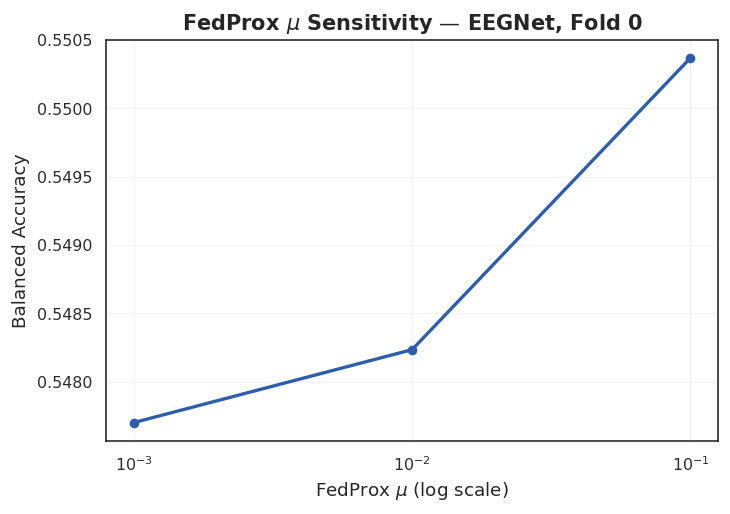

mu,model,test_balanced_acc
0.0010,EEGNet,0.5477
0.0100,EEGNet,0.5482
0.1000,EEGNet,0.5504



CONFIG['FEDPROX_MU'] after sweep = 0.01
Best mu from this sensitivity sweep = 0.1


In [40]:
# ---------------------------------------------------------------------------------------------
# Section 8.3 -- FedProx mu sensitivity sweep
# ---------------------------------------------------------------------------------------------
# Deliberately scoped down to one fold and one architecture.
# This is a targeted sensitivity analysis for the FedProx proximal coefficient (mu).
# ---------------------------------------------------------------------------------------------

MU_SWEEP_VALUES = [0.001, 0.01, 0.1]

# Use the first federated model
_mu_model = FED_MODELS[0]

# Use fold 0 for the sensitivity experiment
_mu_fold_idx = 0
_mu_tr, _mu_va, _mu_te = FOLDS[_mu_fold_idx]

# Store results
mu_sweep_rows = []

# Run FedProx for each mu value
for mu_val in tqdm(MU_SWEEP_VALUES, desc="FedProx mu sweep"):

    # Backup the original FedProx mu
    _cfg_backup = CONFIG["FEDPROX_MU"]

    # Set current mu value
    CONFIG["FEDPROX_MU"] = mu_val

    try:

        # Run federated training
        metrics, history = run_federated(
            _mu_model,
            "fedprox",
            X_uv,
            y,
            subj,
            trial,
            _mu_tr,
            _mu_va,
            _mu_te,
            seed=SEED
        )

        # Show available metric names for verification
        print(f"\nFedProx mu = {mu_val}")
        print("Metrics keys:", metrics.keys())

        # IMPORTANT:
        # Your run_federated() returns 'balanced_acc',
        # NOT 'test_bacc' or 'val_bacc'.
        test_balanced_acc = metrics.get("balanced_acc", np.nan)

    finally:

        # Restore the original FedProx mu
        CONFIG["FEDPROX_MU"] = _cfg_backup

    # Save result for this mu
    mu_sweep_rows.append({
        "mu": mu_val,
        "model": _mu_model,
        "test_balanced_acc": test_balanced_acc
    })


# Convert results to DataFrame
mu_sweep_df = pd.DataFrame(mu_sweep_rows)

# Sort by mu
mu_sweep_df = mu_sweep_df.sort_values("mu").reset_index(drop=True)

# Display results
display(mu_sweep_df)


# ---------------------------------------------------------------------------------------------
# Identify the best mu value
# ---------------------------------------------------------------------------------------------

_best_mu_idx = mu_sweep_df["test_balanced_acc"].idxmax()

_best_mu = mu_sweep_df.loc[
    _best_mu_idx,
    "mu"
]

_best_bacc = mu_sweep_df.loc[
    _best_mu_idx,
    "test_balanced_acc"
]

print("\n" + "=" * 70)
print("FedProx mu Sensitivity Summary")
print("=" * 70)

print(f"Model             : {_mu_model}")
print(f"Fold              : {_mu_fold_idx}")
print(f"Best mu            : {_best_mu}")
print(f"Best balanced acc  : {_best_bacc:.4f}")

print("=" * 70)


# ---------------------------------------------------------------------------------------------
# Plot FedProx mu sensitivity
# ---------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.2, 4.4))

ax.plot(
    mu_sweep_df["mu"],
    mu_sweep_df["test_balanced_acc"],
    marker="o",
    color=PALETTE[0],
    linewidth=2
)

ax.set_xscale("log")

ax.set_xlabel(r"FedProx $\mu$ (log scale)")
ax.set_ylabel("Balanced Accuracy")

ax.set_title(
    f"FedProx $\\mu$ Sensitivity — {_mu_model}, Fold {_mu_fold_idx}"
)

ax.grid(alpha=0.3)

fig.tight_layout()

register(
    save_fig(fig, "fig_mu_sensitivity"),
    "figure",
    "FedProx mu sensitivity sweep"
)

plt.show()


# ---------------------------------------------------------------------------------------------
# Save sensitivity table
# ---------------------------------------------------------------------------------------------

_mu_table_path = os.path.join(
    TAB_DIR,
    "table_mu_sensitivity.csv"
)

show_table(
    mu_sweep_df,
    save_path=_mu_table_path,
    title="Table — FedProx mu sensitivity (one fold, one architecture)",
    float_fmt="{:.4f}"
)

register(
    _mu_table_path,
    "table",
    "FedProx mu sensitivity"
)


# ---------------------------------------------------------------------------------------------
# Final configuration check
# ---------------------------------------------------------------------------------------------

print(
    f"\nCONFIG['FEDPROX_MU'] after sweep = "
    f"{CONFIG['FEDPROX_MU']}"
)

print(
    f"Best mu from this sensitivity sweep = {_best_mu}"
)

FedProx mu sweep:   0%|          | 0/3 [00:00<?, ?it/s]

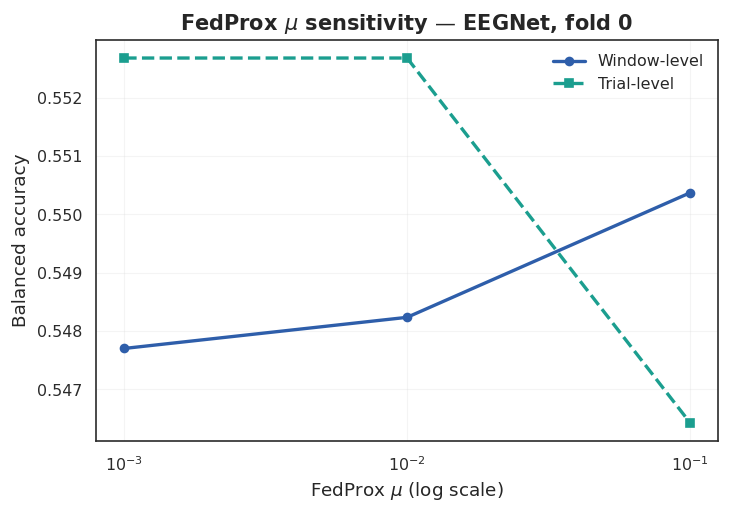

mu,model,test_balanced_acc,trial_balanced_acc
0.0010,EEGNet,0.5477,0.5527
0.0100,EEGNet,0.5482,0.5527
0.1000,EEGNet,0.5504,0.5464



Best mu on this fold: 0.1 (CONFIG['FEDPROX_MU'] is currently 0.01 -- report both in the paper: the value used for the main Section 9 comparison, and this sweep as a robustness check).


In [41]:
# ---------------------------------------------------------------------------------------------
# Section 9.4b -- FedProx mu sensitivity sweep.
#
# Deliberately scoped down (one fold, one architecture) rather than the full protocol: this is a
# targeted diagnostic, not a second benchmark, and re-running every model/algo/fold combination
# at three mu values would multiply the already-substantial federated compute budget threefold
# for a question that only concerns FedProx's one extra hyperparameter.
# ---------------------------------------------------------------------------------------------
MU_SWEEP_VALUES = [0.001, 0.01, 0.1]
_mu_model = FED_MODELS[0]
_mu_fold_idx = 0
_mu_tr, _mu_va, _mu_te = FOLDS[_mu_fold_idx]

mu_sweep_rows = []
for mu_val in tqdm(MU_SWEEP_VALUES, desc="FedProx mu sweep"):
    _cfg_backup = CONFIG["FEDPROX_MU"]
    CONFIG["FEDPROX_MU"] = mu_val
    try:
        metrics, _ = run_federated(_mu_model, "fedprox", X_uv, y, subj, trial,
                                   _mu_tr, _mu_va, _mu_te, seed=SEED)
    finally:
        CONFIG["FEDPROX_MU"] = _cfg_backup
    mu_sweep_rows.append({"mu": mu_val, "model": _mu_model,
                          "test_balanced_acc": metrics["balanced_acc"],
                          "trial_balanced_acc": metrics["trial_balanced_acc"]})

mu_sweep_df = pd.DataFrame(mu_sweep_rows)

fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.plot(mu_sweep_df["mu"], mu_sweep_df["test_balanced_acc"], marker="o",
        color=PALETTE[0], linewidth=2, label="Window-level")
ax.plot(mu_sweep_df["mu"], mu_sweep_df["trial_balanced_acc"], marker="s",
        color=PALETTE[1], linewidth=2, linestyle="--", label="Trial-level")
ax.set_xscale("log")
ax.set_xlabel(r"FedProx $\mu$ (log scale)")
ax.set_ylabel("Balanced accuracy")
ax.set_title(f"FedProx $\\mu$ sensitivity — {_mu_model}, fold {_mu_fold_idx}")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
register(save_fig(fig, "fig_mu_sensitivity"), "figure", "FedProx mu sensitivity sweep")
plt.show()

show_table(mu_sweep_df, save_path=os.path.join(TAB_DIR, "table_mu_sensitivity.csv"),
           title="Table — FedProx mu sensitivity (one fold, one architecture)", float_fmt="{:.4f}")
register(os.path.join(TAB_DIR, "table_mu_sensitivity.csv"), "table", "FedProx mu sensitivity")

_best_mu = mu_sweep_df.loc[mu_sweep_df["test_balanced_acc"].idxmax(), "mu"]
print(f"\nBest mu on this fold: {_best_mu} "
      f"(CONFIG['FEDPROX_MU'] is currently {CONFIG['FEDPROX_MU']} -- report both in the paper: "
      f"the value used for the main Section 9 comparison, and this sweep as a robustness check).")

### 9.5 Centralised versus federated

The comparison that justifies Section 8. Four things are reported: the accuracy each federated algorithm reaches,
the *cost of privacy* (the paired centralised-minus-federated gap on identical folds), whether FedProx's
proximal term helps under subject-level non-IID data, and the communication volume each result required.

Model,Training,Balanced acc,95% CI,Accuracy,Macro-F1,AUC,Trial acc,Communication (MB),Gap vs centralised
EEGNet,Centralised,0.6038,"[0.577, 0.637]",0.6035,0.6016,0.6511,0.6128,0.0000,0.0000
EEGNet,FedAvg,0.5528,"[0.539, 0.568]",0.5526,0.5423,0.5816,0.5574,15.5880,0.0510
EEGNet,FedProx,0.5552,"[0.541, 0.570]",0.5549,0.5450,0.5836,0.5590,15.5880,0.0486
CNN,Centralised,0.6029,"[0.577, 0.633]",0.6029,0.5982,0.6547,0.6132,0.0000,0.0000
CNN,FedAvg,0.5846,"[0.560, 0.613]",0.5848,0.5734,0.6363,0.5915,855.7220,0.0183
CNN,FedProx,0.5874,"[0.564, 0.616]",0.5876,0.5795,0.6374,0.5934,855.7220,0.0155


'Gap vs centralised' is the paired mean loss in balanced accuracy from keeping raw EEG on the client -- i.e. the measured cost of privacy.


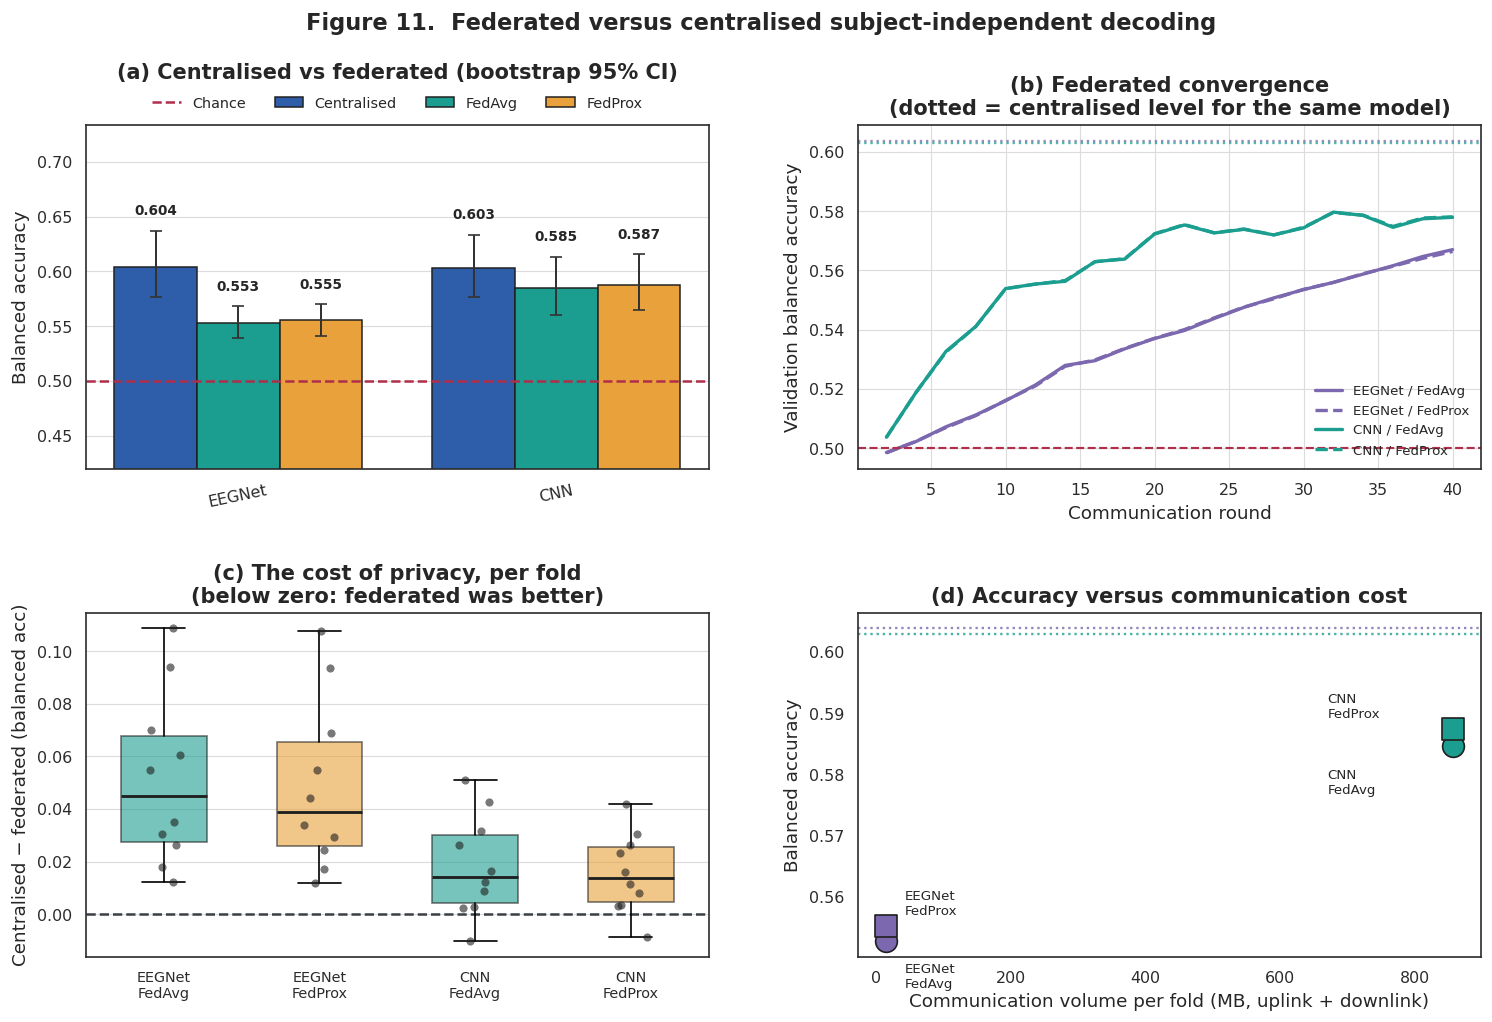


Statistical assessment of the federated results
  EEGNet        FedAvg  : gap +0.0510, p = 0.0020, d = +1.564  -> significantly below centralised
  EEGNet        FedProx : gap +0.0486, p = 0.0020, d = +1.497  -> significantly below centralised
  EEGNet        FedProx - FedAvg: +0.0024, p = 0.0039, d = +0.482  (proximal term helps under subject-level non-IID data)
  CNN           FedAvg  : gap +0.0183, p = 0.0137, d = +0.953  -> significantly below centralised
  CNN           FedProx : gap +0.0155, p = 0.0137, d = +1.029  -> significantly below centralised
  CNN           FedProx - FedAvg: +0.0028, p = 0.5703, d = +0.321  (proximal term helps under subject-level non-IID data)


In [42]:
# ---------------------------------------------------------------------------------------------
# TABLE 9 + FIGURE 11: centralised vs federated.
# ---------------------------------------------------------------------------------------------
if len(fed_df):
    fed_summary = []
    for name in FED_MODELS:
        cen = central_df[central_df["model"] == name]
        c_m, c_lo, c_hi = bootstrap_ci(cen["balanced_acc"])
        fed_summary.append({"Model": name, "Training": "Centralised",
                            "Balanced acc": c_m, "95% CI": f"[{c_lo:.3f}, {c_hi:.3f}]",
                            "Accuracy": cen["accuracy"].mean(), "Macro-F1": cen["f1"].mean(),
                            "AUC": cen["auc"].mean(), "Trial acc": cen["trial_accuracy"].mean(),
                            "Communication (MB)": 0.0, "Gap vs centralised": 0.0})
        for algo in ("FedAvg", "FedProx"):
            f = fed_df[(fed_df["model"] == name) & (fed_df["algo"] == algo)]
            if not len(f):
                continue
            f_m, f_lo, f_hi = bootstrap_ci(f["balanced_acc"])
            # Paired gap on shared folds only -- averaging over different fold sets would bias it.
            shared = sorted(set(f["fold"]) & set(cen["fold"]))
            gap = float(np.mean([
                cen.loc[cen["fold"] == k, "balanced_acc"].values[0] -
                f.loc[f["fold"] == k, "balanced_acc"].values[0] for k in shared])) if shared else np.nan
            fed_summary.append({"Model": name, "Training": algo,
                                "Balanced acc": f_m, "95% CI": f"[{f_lo:.3f}, {f_hi:.3f}]",
                                "Accuracy": f["accuracy"].mean(), "Macro-F1": f["f1"].mean(),
                                "AUC": f["auc"].mean(), "Trial acc": f["trial_accuracy"].mean(),
                                "Communication (MB)": f["communication_MB"].mean(),
                                "Gap vs centralised": gap})
    fed_sum_df = pd.DataFrame(fed_summary)
    show_table(fed_sum_df, save_path=os.path.join(TAB_DIR, "table9_federated_vs_centralized.csv"),
               title=("Table 9 — Centralised versus federated training on identical "
                      f"subject-independent folds ({CONFIG['FED_ROUNDS']} rounds, "
                      f"{CONFIG['FED_CLIENT_FRAC']:.0%} client participation)"),
               float_fmt="{:.4f}",
               note="'Gap vs centralised' is the paired mean loss in balanced accuracy from keeping "
                    "raw EEG on the client -- i.e. the measured cost of privacy.")
    register(os.path.join(TAB_DIR, "table9_federated_vs_centralized.csv"), "table",
             "Federated vs centralised")

    fig = plt.figure(figsize=(15, 9))
    gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.24)

    # (a) grouped bars: centralised / FedAvg / FedProx
    ax = fig.add_subplot(gs[0, 0])
    schemes = ["Centralised", "FedAvg", "FedProx"]
    cols = [PALETTE[0], PALETTE[1], PALETTE[3]]
    xs = np.arange(len(FED_MODELS)); w = 0.26
    for j, (scheme, colour) in enumerate(zip(schemes, cols)):
        means, err_lo, err_hi = [], [], []
        for name in FED_MODELS:
            v = (central_df.loc[central_df["model"] == name, "balanced_acc"] if scheme == "Centralised"
                 else fed_df.loc[(fed_df["model"] == name) & (fed_df["algo"] == scheme), "balanced_acc"])
            mu, lo, hi = bootstrap_ci(v)
            means.append(mu); err_lo.append(mu - lo); err_hi.append(hi - mu)
        bars = ax.bar(xs + (j - 1) * w, means, width=w, color=colour, edgecolor="#1f1f1f",
                      linewidth=0.9, label=scheme, yerr=[err_lo, err_hi], capsize=3.5,
                      error_kw=dict(elinewidth=1.2, ecolor="#333333"))
        # Value labels sit *above* the upper CI cap and stay horizontal: rotated labels drawn at
        # bar height collided with the whiskers and with the legend in earlier drafts.
        for b, mu, e_hi in zip(bars, means, err_hi):
            if np.isfinite(mu):
                ax.text(b.get_x() + b.get_width() / 2, mu + (e_hi if np.isfinite(e_hi) else 0.0) + 0.012,
                        f"{mu:.3f}", ha="center", va="bottom", fontsize=8.2, fontweight="bold")
    ax.axhline(0.5, color=PALETTE[6], linestyle="--", linewidth=1.5, label="Chance")
    ax.set_xticks(xs); ax.set_xticklabels(FED_MODELS, rotation=12)
    ax.set_ylabel("Balanced accuracy")
    # Headroom for the value labels; the legend is parked in the gap under the panel title.
    ax.set_ylim(0.42, min(1.09, float(fed_sum_df["Balanced acc"].max()) + 0.13))
    ax.set_title("(a) Centralised vs federated (bootstrap 95% CI)", pad=28)
    ax.legend(fontsize=8.6, ncol=4, loc="lower center", bbox_to_anchor=(0.5, 1.005),
              frameon=False)
    ax.grid(axis="x", visible=False)

    # (b) convergence: mean validation balanced accuracy per round
    ax = fig.add_subplot(gs[0, 1])
    for (name, algo), hists in fed_histories.items():
        rounds = hists[0]["round"]
        curves = np.full((len(hists), len(rounds)), np.nan)
        for i, h in enumerate(hists):
            curves[i, :len(h["val_bacc"])] = h["val_bacc"]
        mu = np.nanmean(curves, axis=0)
        ok = np.isfinite(mu)
        style = "-" if algo == "fedavg" else "--"
        ax.plot(np.asarray(rounds)[ok], mu[ok], style, linewidth=2.0,
                color=MODEL_COLORS.get(name, GREY),
                label=f"{name} / {'FedAvg' if algo=='fedavg' else 'FedProx'}")
    for name in FED_MODELS:
        ax.axhline(central_df.loc[central_df["model"] == name, "balanced_acc"].mean(),
                   color=MODEL_COLORS.get(name, GREY), linestyle=":", linewidth=1.4, alpha=0.75)
    ax.axhline(0.5, color=PALETTE[6], linestyle="--", linewidth=1.3)
    ax.set_xlabel("Communication round"); ax.set_ylabel("Validation balanced accuracy")
    ax.set_title("(b) Federated convergence\n(dotted = centralised level for the same model)")
    ax.legend(fontsize=8, ncol=1)

    # (c) the cost of privacy, per fold
    ax = fig.add_subplot(gs[1, 0])
    gap_rows = []
    for name in FED_MODELS:
        cen = central_df[central_df["model"] == name]
        for algo in ("FedAvg", "FedProx"):
            f = fed_df[(fed_df["model"] == name) & (fed_df["algo"] == algo)]
            for k in sorted(set(f["fold"]) & set(cen["fold"])):
                gap_rows.append({
                    "label": f"{name}\n{algo}", "model": name, "algo": algo, "fold": k,
                    "gap": (cen.loc[cen["fold"] == k, "balanced_acc"].values[0] -
                            f.loc[f["fold"] == k, "balanced_acc"].values[0])})
    gap_df = pd.DataFrame(gap_rows)
    if len(gap_df):
        labels = list(dict.fromkeys(gap_df["label"]))
        data = [gap_df.loc[gap_df["label"] == l, "gap"].values for l in labels]
        bp = ax.boxplot(data, patch_artist=True, widths=0.55, showfliers=False,
                        medianprops=dict(color="#1f1f1f", linewidth=1.7))
        for patch, l in zip(bp["boxes"], labels):
            patch.set_facecolor(PALETTE[1] if "FedAvg" in l else PALETTE[3])
            patch.set_alpha(0.6); patch.set_edgecolor("#1f1f1f")
        rng2 = np.random.default_rng(SEED)
        for i, vals in enumerate(data, start=1):
            ax.scatter(np.full(len(vals), i) + rng2.uniform(-0.11, 0.11, len(vals)), vals,
                       s=24, color="#1f1f1f", alpha=0.6, zorder=3, linewidths=0)
        # Zero = federated matched centralised exactly. Neutral dark grey rather than a colour from
        # the model palette, so it cannot be misread as one of the model series.
        ax.axhline(0, color="#3A3F46", linestyle="--", linewidth=1.5, zorder=1)
        ax.set_xticks(np.arange(1, len(labels) + 1))
        ax.set_xticklabels(labels, fontsize=8.6)
        ax.set_ylabel("Centralised − federated (balanced acc)")
        ax.set_title("(c) The cost of privacy, per fold\n(below zero: federated was better)")
        ax.grid(axis="x", visible=False)

    # (d) accuracy achieved per megabyte transmitted
    ax = fig.add_subplot(gs[1, 1])
    fed_points = []
    for name in FED_MODELS:
        for algo, marker in (("FedAvg", "o"), ("FedProx", "s")):
            f = fed_df[(fed_df["model"] == name) & (fed_df["algo"] == algo)]
            if not len(f):
                continue
            px_, py_ = float(f["communication_MB"].mean()), float(f["balanced_acc"].mean())
            ax.scatter(px_, py_, s=170, marker=marker, color=MODEL_COLORS.get(name, GREY),
                       edgecolor="#1f1f1f", linewidth=1.0, zorder=3,
                       label=f"{name} / {algo}")
            fed_points.append((px_, py_, f"{name}\n{algo}"))
    for name in FED_MODELS:
        ax.axhline(central_df.loc[central_df["model"] == name, "balanced_acc"].mean(),
                   color=MODEL_COLORS.get(name, GREY), linestyle=":", linewidth=1.4, alpha=0.8)
    ax.set_xlabel("Communication volume per fold (MB, uplink + downlink)")
    ax.set_ylabel("Balanced accuracy")
    ax.set_title("(d) Accuracy versus communication cost")
    ax.grid(axis="both")
    # FedAvg and FedProx of the same model transmit exactly the same number of bytes, so they share
    # an x position and a fixed annotation offset would stack the two labels on top of each other.
    # Place every label in the first candidate slot that neither overlaps an already-placed label
    # nor spills outside the axes, measured in display space (points) where overlap actually happens.
    fig.canvas.draw()                       # transData is only meaningful after a layout pass
    _LW, _LH = 64.0, 25.0                   # approximate label bounding box, in points
    _cands = ((11, 5), (11, -30), (-11 - _LW, 5), (-11 - _LW, -30),
              (11, 33), (11, -58), (-11 - _LW, 33), (-11 - _LW, -58))
    _abb = ax.get_window_extent()
    _placed = []
    for _x, _y, _txt in sorted(fed_points, key=lambda p: (-p[1], p[0])):
        _sx, _sy = ax.transData.transform((_x, _y))
        _best, _fallback = None, None
        for _dx, _dy in _cands:
            _box = (_sx + _dx, _sy + _dy, _sx + _dx + _LW, _sy + _dy + _LH)
            _free = all(_box[0] > b[2] or _box[2] < b[0] or _box[1] > b[3] or _box[3] < b[1]
                        for b in _placed)
            _inside = (_box[0] >= _abb.x0 + 2 and _box[2] <= _abb.x1 - 2 and
                       _box[1] >= _abb.y0 + 2 and _box[3] <= _abb.y1 - 2)
            if _free and _inside:
                _best = (_dx, _dy, _box); break
            if _free and _fallback is None:
                _fallback = (_dx, _dy, _box)
        _dx, _dy, _box = _best or _fallback or (_cands[0][0], _cands[0][1],
                                                (_sx + _cands[0][0], _sy + _cands[0][1],
                                                 _sx + _cands[0][0] + _LW,
                                                 _sy + _cands[0][1] + _LH))
        _placed.append(_box)
        ax.annotate(_txt, (_x, _y), textcoords="offset points", xytext=(_dx, _dy),
                    fontsize=8, ha="left", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.16", facecolor="white", alpha=0.75,
                              edgecolor="none"))

    fig.suptitle("Figure 11.  Federated versus centralised subject-independent decoding",
                 fontsize=13.5, fontweight="bold", y=0.985)
    register(save_fig(fig, "fig11_federated_comparison"), "figure",
             "Figure 11 - federated vs centralised")
    plt.show()

    # ---- statistical test of the privacy cost and of FedProx vs FedAvg ------------------------
    print("\nStatistical assessment of the federated results")
    for name in FED_MODELS:
        cen = central_df[central_df["model"] == name]
        for algo in ("FedAvg", "FedProx"):
            f = fed_df[(fed_df["model"] == name) & (fed_df["algo"] == algo)]
            shared = sorted(set(f["fold"]) & set(cen["fold"]))
            if len(shared) < 3:
                continue
            a = np.array([cen.loc[cen["fold"] == k, "balanced_acc"].values[0] for k in shared])
            b = np.array([f.loc[f["fold"] == k, "balanced_acc"].values[0] for k in shared])
            try:
                _, p = wilcoxon(a, b)
            except Exception:
                p = float("nan")
            verdict = ("significantly below centralised" if (np.isfinite(p) and p < 0.05 and a.mean() > b.mean())
                       else "not significantly different from centralised" if (np.isfinite(p) and p >= 0.05)
                       else "significantly above centralised")
            print(f"  {name:<13s} {algo:<8s}: gap {a.mean()-b.mean():+.4f}, p = {p:.4f}, "
                  f"d = {cohens_d_paired(a, b):+.3f}  -> {verdict}")
        fa = fed_df[(fed_df["model"] == name) & (fed_df["algo"] == "FedAvg")]
        fp = fed_df[(fed_df["model"] == name) & (fed_df["algo"] == "FedProx")]
        shared = sorted(set(fa["fold"]) & set(fp["fold"]))
        if len(shared) >= 3:
            a = np.array([fp.loc[fp["fold"] == k, "balanced_acc"].values[0] for k in shared])
            b = np.array([fa.loc[fa["fold"] == k, "balanced_acc"].values[0] for k in shared])
            try:
                _, p = wilcoxon(a, b)
            except Exception:
                p = float("nan")
            print(f"  {name:<13s} FedProx - FedAvg: {a.mean()-b.mean():+.4f}, p = {p:.4f}, "
                  f"d = {cohens_d_paired(a, b):+.3f}  "
                  f"({'proximal term helps' if a.mean() > b.mean() else 'proximal term does not help'} "
                  "under subject-level non-IID data)")
else:
    fed_sum_df = pd.DataFrame()
    print("No federated results were produced; Section 9.5 is skipped.")

### 9.6 Subject-dependent control — quantifying the price of subject independence

The manuscript states that a tangible gap exists between subject-dependent and subject-independent accuracy. That
sentence needs a measured number behind it, produced under **identical** preprocessing, architecture and optimiser
settings; a subject-dependent figure quoted from another paper measures that paper's pipeline, not this one.

One methodological point decides whether this control is meaningful. Within a subject, the sliding windows come
from the same trials and overlap by 75 %, so splitting windows at random would place near-duplicates of the same
signal on both sides of the train/test boundary and return an accuracy that is close to a memorisation score. The
split here is therefore by **trial**, using `GroupKFold` on trial identity, so no window from a test trial is ever
seen in training. This is the single most common inflation mechanism in within-subject MI-EEG papers and avoiding
it is why the number below will look modest next to some published subject-dependent results.

Early stopping needs a validation set that is also trial-disjoint, so one training trial group is held back inside
each fold. Subjects with too few trials for that are skipped and reported rather than silently dropped.

In [43]:
# ---------------------------------------------------------------------------------------------
# Within-subject cross-validation, split by TRIAL, for the best deep model and CSP+SVM.
#
# Cost control: only CONFIG["SD_N_SUBJECTS"] subjects are used, chosen deterministically as an
# evenly-spaced sample across the subject list so the selection is neither cherry-picked nor
# biased toward low subject numbers.
# ---------------------------------------------------------------------------------------------
sd_model_name = BEST_DEEP
all_subjects_sorted = np.array(sorted(np.unique(subj)))
n_sd = int(min(CONFIG["SD_N_SUBJECTS"], len(all_subjects_sorted)))
sd_subjects = all_subjects_sorted[np.linspace(0, len(all_subjects_sorted) - 1, n_sd).astype(int)]
sd_subjects = np.unique(sd_subjects)

print(f"Subject-dependent control: {sd_model_name} + CSP+SVM, {len(sd_subjects)} subjects, "
      f"{CONFIG['SD_FOLDS']} trial-disjoint folds each")
print(f"Subjects: {list(map(int, sd_subjects))}\n")

sd_rows, sd_skipped = [], []
t_sd = time.time()

for s in sd_subjects:
    m_s = subj == s
    Xs, ys, ts = X_uv[m_s], y[m_s], trial[m_s]
    uniq_trials = np.unique(ts)
    # Need at least SD_FOLDS test groups plus one validation group.
    if len(uniq_trials) < CONFIG["SD_FOLDS"] + 2 or len(np.unique(ys)) < 2:
        sd_skipped.append({"subject": int(s), "n_trials": int(len(uniq_trials)),
                           "reason": "too few trials or a single class present"})
        continue

    gkf = GroupKFold(n_splits=CONFIG["SD_FOLDS"])
    for kf, (tr_i, te_i) in enumerate(gkf.split(Xs, ys, groups=ts)):
        # Carve a trial-disjoint validation split out of the training trials.
        tr_trials = np.unique(ts[tr_i])
        rng_sd = np.random.default_rng(SEED + int(s) * 100 + kf)
        n_val_tr = max(1, int(round(len(tr_trials) / 5)))
        va_trials = set(rng_sd.choice(tr_trials, n_val_tr, replace=False).tolist())
        va_mask = np.isin(ts[tr_i], list(va_trials))
        fit_i, val_i = tr_i[~va_mask], tr_i[va_mask]
        if len(np.unique(ys[fit_i])) < 2 or len(np.unique(ys[val_i])) < 2 or len(val_i) < 4:
            continue

        # ---- deep model ------------------------------------------------------------------------
        set_all_seeds(SEED + int(s) * 100 + kf)
        model = build_model(sd_model_name, seed=SEED + int(s) * 100 + kf)
        model, _ = train_deep_model(model, Xs[fit_i], ys[fit_i], Xs[val_i], ys[val_i],
                                    verbose=False, tag=f"S{int(s):03d}f{kf}")
        yt, yp, pp = predict_deep(model, make_loader(Xs[te_i], ys[te_i], shuffle=False))
        sd_rows.append({"subject": int(s), "fold": kf + 1, "model": sd_model_name,
                        "n_train_windows": int(len(fit_i)), "n_test_windows": int(len(te_i)),
                        **compute_metrics(yt, yp, pp)})
        del model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

        # ---- CSP+SVM reference -----------------------------------------------------------------
        try:
            yp2, pp2, _ = fit_predict_csp_svm(Xs[tr_i], ys[tr_i], Xs[te_i])
            sd_rows.append({"subject": int(s), "fold": kf + 1, "model": "CSP+SVM",
                            "n_train_windows": int(len(tr_i)), "n_test_windows": int(len(te_i)),
                            **compute_metrics(ys[te_i], yp2, pp2)})
        except Exception as exc:
            print(f"  S{int(s):03d} fold {kf+1}: CSP+SVM failed ({type(exc).__name__})")

sd_df = pd.DataFrame(sd_rows)
sd_df.to_csv(os.path.join(TAB_DIR, "raw_subject_dependent_results.csv"), index=False)
register(os.path.join(TAB_DIR, "raw_subject_dependent_results.csv"), "table",
         "Raw subject-dependent results")
print(f"\nSubject-dependent control complete in {(time.time()-t_sd)/60:.1f} min "
      f"({len(sd_df)} subject-fold-model evaluations)")
if sd_skipped:
    print(f"Skipped {len(sd_skipped)} subject(s): "
          f"{[(d['subject'], d['reason']) for d in sd_skipped]}")

Subject-dependent control: EEGNet + CSP+SVM, 20 subjects, 3 trial-disjoint folds each
Subjects: [1, 6, 12, 17, 23, 29, 34, 40, 46, 51, 57, 62, 68, 74, 79, 85, 91, 96, 102, 108]


Subject-dependent control complete in 0.6 min (118 subject-fold-model evaluations)


Model,Subjects compared,Subject-dependent acc,SD 95% CI,Subject-independent acc,SI 95% CI,Generalisation gap,Wilcoxon p,Cohen's d
EEGNet,20.0000,0.5077,"[0.480, 0.536]",0.6233,"[0.574, 0.681]",-0.1156,0.0001,-0.9913
CSP+SVM,20.0000,0.5515,"[0.477, 0.632]",0.6048,"[0.555, 0.663]",-0.0534,0.0192,-0.4455


The gap is the accuracy that is lost by refusing per-subject calibration. Within-subject folds are trial-disjoint, so overlapping windows cannot leak.


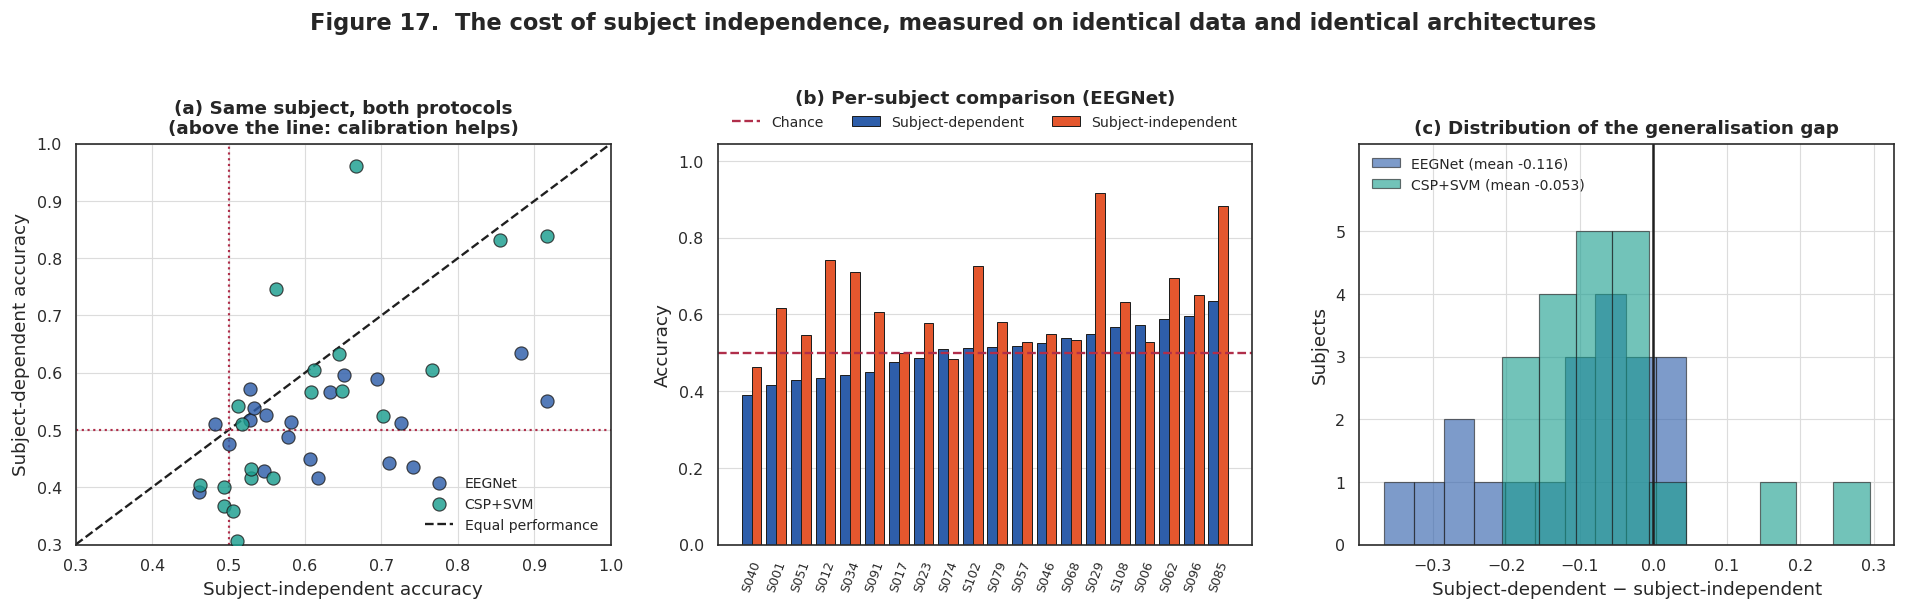

EEGNet       : within-subject 0.5077 vs cross-subject 0.6233  ->  gap -0.1156  (Wilcoxon p = 0.0001335, d = -0.991)
CSP+SVM      : within-subject 0.5515 vs cross-subject 0.6048  ->  gap -0.0534  (Wilcoxon p = 0.01923, d = -0.446)


In [44]:
# ---------------------------------------------------------------------------------------------
# TABLE 14 + FIGURE 17: subject-dependent versus subject-independent.
# The comparison is paired per subject: each subject has a within-subject accuracy and an
# accuracy from the one subject-independent fold in which they were held out.
# ---------------------------------------------------------------------------------------------
if len(sd_df):
    rows, paired = [], []
    for name in sd_df["model"].unique():
        sd_m = sd_df[sd_df["model"] == name].groupby("subject")["accuracy"].mean()
        si_m = subject_df[(subject_df["model"] == name) &
                          (subject_df["subject"].isin(sd_m.index))].groupby("subject")["accuracy"].mean()
        common = sorted(set(sd_m.index) & set(si_m.index))
        if len(common) < 3:
            continue
        a = sd_m.loc[common].values          # subject-dependent
        b = si_m.loc[common].values          # subject-independent
        try:
            _, p = wilcoxon(a, b)
        except Exception:
            p = float("nan")
        mu_a, lo_a, hi_a = bootstrap_ci(a)
        mu_b, lo_b, hi_b = bootstrap_ci(b)
        rows.append({"Model": name, "Subjects compared": len(common),
                     "Subject-dependent acc": mu_a, "SD 95% CI": f"[{lo_a:.3f}, {hi_a:.3f}]",
                     "Subject-independent acc": mu_b, "SI 95% CI": f"[{lo_b:.3f}, {hi_b:.3f}]",
                     "Generalisation gap": mu_a - mu_b,
                     "Wilcoxon p": p, "Cohen's d": cohens_d_paired(a, b)})
        for sc, va, vb in zip(common, a, b):
            paired.append({"model": name, "subject": sc, "dependent": va, "independent": vb})
    gap_tbl = pd.DataFrame(rows)
    paired_df = pd.DataFrame(paired)

    show_table(gap_tbl, save_path=os.path.join(TAB_DIR, "table14_subject_dependent_gap.csv"),
               title=("Table 14 — Subject-dependent versus subject-independent accuracy "
                      f"(paired per subject, within-subject folds split by trial)"),
               float_fmt="{:.4f}",
               note="The gap is the accuracy that is lost by refusing per-subject calibration. "
                    "Within-subject folds are trial-disjoint, so overlapping windows cannot leak.")
    register(os.path.join(TAB_DIR, "table14_subject_dependent_gap.csv"), "table",
             "Subject-dependent gap")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.9))

    # (a) paired scatter
    ax = axes[0]
    for j, name in enumerate(paired_df["model"].unique()):
        d = paired_df[paired_df["model"] == name]
        ax.scatter(d["independent"], d["dependent"], s=62, alpha=0.82, color=PALETTE[j],
                   edgecolor="#1f1f1f", linewidth=0.7, label=name, zorder=3)
    lims = [0.3, 1.0]
    ax.plot(lims, lims, color="#1f1f1f", linestyle="--", linewidth=1.4, label="Equal performance")
    ax.axhline(0.5, color=PALETTE[6], linestyle=":", linewidth=1.3)
    ax.axvline(0.5, color=PALETTE[6], linestyle=":", linewidth=1.3)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Subject-independent accuracy"); ax.set_ylabel("Subject-dependent accuracy")
    ax.set_title("(a) Same subject, both protocols\n(above the line: calibration helps)", fontsize=11)
    ax.legend(fontsize=8.4, loc="lower right")

    # (b) per-subject gap
    ax = axes[1]
    d = paired_df[paired_df["model"] == sd_model_name].sort_values("dependent")
    if len(d):
        xs = np.arange(len(d))
        ax.bar(xs - 0.2, d["dependent"], width=0.4, color=PALETTE[0], edgecolor="#1f1f1f",
               linewidth=0.6, label="Subject-dependent")
        ax.bar(xs + 0.2, d["independent"], width=0.4, color=PALETTE[2], edgecolor="#1f1f1f",
               linewidth=0.6, label="Subject-independent")
        ax.axhline(0.5, color=PALETTE[6], linestyle="--", linewidth=1.4, label="Chance")
        ax.set_xticks(xs); ax.set_xticklabels([f"S{int(s):03d}" for s in d["subject"]],
                                             rotation=70, fontsize=7.6)
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0, 1.045)
        # Legend above the axes: per-subject accuracies routinely reach the top of the panel, so an
        # in-axes legend would sit on the bars for the best subjects.
        ax.set_title(f"(b) Per-subject comparison ({sd_model_name})", fontsize=11, pad=24)
        ax.legend(fontsize=8.4, ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.005),
                  frameon=False)
        ax.grid(axis="x", visible=False)

    # (c) gap distribution
    ax = axes[2]
    _hist_max = 0
    for j, name in enumerate(paired_df["model"].unique()):
        d2 = paired_df[paired_df["model"] == name]
        gaps = (d2["dependent"] - d2["independent"]).values
        _n, _, _ = ax.hist(gaps, bins=10, alpha=0.62, color=PALETTE[j], edgecolor="#1f1f1f",
                           linewidth=0.7, label=f"{name} (mean {gaps.mean():+.3f})")
        _hist_max = max(_hist_max, int(np.max(_n)) if len(_n) else 0)
    ax.axvline(0, color="#1f1f1f", linewidth=1.5)
    ax.set_xlabel("Subject-dependent − subject-independent"); ax.set_ylabel("Subjects")
    ax.set_title("(c) Distribution of the generalisation gap", fontsize=11)
    # A subject count is a whole number: matplotlib's default 0.5 / 1.5 / 2.5 ticks are not
    # interpretable on this axis. Integer ticks plus headroom so the legend clears the tallest bin.
    ax.set_yticks(np.arange(0, _hist_max + 1, max(1, _hist_max // 6)))
    ax.set_ylim(0, _hist_max + max(1.0, 0.28 * _hist_max))
    ax.legend(fontsize=8.4, loc="upper left", framealpha=0.94)

    fig.suptitle("Figure 17.  The cost of subject independence, measured on identical data "
                 "and identical architectures", fontsize=13.5, fontweight="bold", y=1.03)
    fig.tight_layout()
    register(save_fig(fig, "fig17_subject_dependent_gap"), "figure",
             "Figure 17 - subject-dependent gap")
    plt.show()

    for _, r in gap_tbl.iterrows():
        eff = r["Cohen's d"]
        print(f"{r['Model']:<13s}: within-subject {r['Subject-dependent acc']:.4f} vs "
              f"cross-subject {r['Subject-independent acc']:.4f}  ->  gap "
              f"{r['Generalisation gap']:+.4f}  (Wilcoxon p = {r['Wilcoxon p']:.4g}, "
              f"d = {eff:+.3f})")
else:
    gap_tbl = pd.DataFrame()
    paired_df = pd.DataFrame()
    print("Subject-dependent control produced no results; Table 14 and Figure 17 are skipped.")

---
# Section 10 — Explainable AI
---

### 10.1 What is being explained, and what was wrong before

A deep decoder that reaches 75 % on held-out subjects is only publishable in a clinical-adjacent venue if it can
be shown to use **neurophysiology rather than artifact**. Motor imagery has a known signature: event-related
desynchronisation of the mu and beta rhythms over the contralateral sensorimotor cortex, i.e. around C3 for right-hand
imagery and C4 for left-hand imagery. That gives an external criterion no accuracy number can provide — an
attribution map concentrated on frontal electrodes at 0–200 ms is measuring eye movement or task onset, not motor
imagery, whatever the accuracy.

**Three defects in the previous implementation are corrected here, and each of them invalidated its own figure.**

1. **Grad-CAM was hooked after the electrode axis had already been collapsed.** The old code hooked the fourth
   convolutional block, by which point the spatial convolution had reduced 22 electrodes to 1. The resulting
   `(1, T)` map was then bilinearly upsampled to `(22, T)`, which can only produce 22 *identical* rows. Every
   "channel importance" value read off that figure was the same number. Here each architecture exposes
   `gradcam_target()` — the last layer that still has a real electrode axis — and the hook **asserts**
   `activation.shape[2] == n_channels` before computing anything. Interpolation is applied along time only.

2. **LIME perturbations were applied to the wrong windows.** The old code generated perturbations for one instance
   but mapped them onto a rotating set of different base windows via `np.arange(n_batch) % len(X_test)`, so the
   local linear model was fitted to a relationship that did not exist. It also converted a *power* ratio into an
   *amplitude* scale factor linearly, which is dimensionally wrong (power scales with the square of amplitude).
   Here LIME operates in a space where perturbation is actually defined — band power per electrode — through an
   explicitly-reported surrogate, and the surrogate's fidelity to the deep model is measured and printed rather
   than assumed.

3. **No method was ever tested for faithfulness.** An attribution map is a hypothesis about what the model uses.
   Section 10.6 tests that hypothesis by deleting the channels each method claims are important and measuring
   whether accuracy actually collapses, benchmarked against random channel rankings. A method that does no better
   than random ranking is not explaining the model, and saying so is a result.

The three methods are complementary rather than redundant: Grad-CAM is gradient-based and localises in
**time and space**, SHAP is a **sample-level attribution with an additivity guarantee**, and LIME is a
**local surrogate** in an interpretable feature space. Agreement between three methods with different assumptions
is much stronger evidence than any one of them alone, which is why Section 10.5 quantifies it.

In [45]:
# ---------------------------------------------------------------------------------------------
# 10.1a  Load the exact checkpoint that Section 9 reports, and build the XAI evaluation set.
#
# Explaining a freshly-trained model while reporting a different one's accuracy is a subtle
# inconsistency that is easy to miss in review. The checkpoint's own test subjects are used, and
# the restored model is required to REPRODUCE its recorded balanced accuracy before anything is
# explained -- if the weights do not restore correctly, the cell fails loudly instead of
# producing a beautiful and meaningless heatmap.
# ---------------------------------------------------------------------------------------------
XAI_MODEL_NAME = BEST_DEEP
ckpt_path = os.path.join(MODEL_DIR, f"{XAI_MODEL_NAME.replace('+','_')}_best.pt")
assert os.path.exists(ckpt_path), f"Checkpoint missing: {ckpt_path} (run Section 7 first)"

try:
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
except TypeError:
    ckpt = torch.load(ckpt_path, map_location=DEVICE)      # torch < 2.0 has no weights_only
xai_model = build_model(XAI_MODEL_NAME, seed=SEED)
xai_model.load_state_dict(ckpt["state_dict"], strict=True)  # strict: a silent key mismatch here
xai_model.to(DEVICE).eval()                                 # would explain a half-initialised net

XAI_FOLD = int(ckpt["fold"])
xai_test_subjects = list(ckpt["test_subjects"])
print(f"Explaining : {XAI_MODEL_NAME}  (fold {XAI_FOLD}, recorded balanced acc "
      f"{ckpt['balanced_acc']:.4f})")
print(f"Held-out subjects in this fold: {xai_test_subjects}")

# ---- held-out data for this fold, standardised exactly as during training ----------------------
m_xai = subject_mask(subj, xai_test_subjects)
X_te_xai = zscore_windows(X_uv[m_xai])          # (n, 22, 320) z-scored per window per channel
y_te_xai = y[m_xai]
s_te_xai = subj[m_xai]


@torch.no_grad()
def predict_probs_std(model, X_std, batch=256):
    """P(class = 1) for already-standardised windows shaped (n, channels, samples)."""
    model.eval()
    out = []
    for i in range(0, len(X_std), batch):
        xb = torch.from_numpy(np.ascontiguousarray(X_std[i:i + batch])).float().unsqueeze(1).to(DEVICE)
        out.append(torch.softmax(model(xb), dim=1)[:, 1].detach().cpu().numpy())
    return np.concatenate(out) if out else np.array([])


# ---- integrity check: does the restored model reproduce the reported number? --------------------
p_full = predict_probs_std(xai_model, X_te_xai)
bacc_restored = balanced_accuracy_score(y_te_xai, (p_full >= 0.5).astype(int))
print(f"Restored-model balanced accuracy on the same subjects: {bacc_restored:.4f} "
      f"(recorded {ckpt['balanced_acc']:.4f}, difference {abs(bacc_restored-ckpt['balanced_acc']):.4f})")
assert abs(bacc_restored - ckpt["balanced_acc"]) < 0.02, (
    "The restored checkpoint does not reproduce its recorded accuracy. Do not interpret any "
    "attribution map until this is resolved -- the weights or the evaluation set do not match.")

# ---- stratified subsample for the expensive attribution methods --------------------------------
rng_xai = np.random.default_rng(SEED)
n_take = int(min(CONFIG["XAI_N_WINDOWS"], len(y_te_xai)))
idx_pool = []
for cls in (0, 1):
    cls_idx = np.where(y_te_xai == cls)[0]
    take = int(min(len(cls_idx), int(np.ceil(n_take / 2))))
    idx_pool.append(rng_xai.choice(cls_idx, take, replace=False))
xai_idx = np.sort(np.concatenate(idx_pool))

X_xai = X_te_xai[xai_idx]
y_xai = y_te_xai[xai_idx]
p_xai = p_full[xai_idx]
pred_xai = (p_xai >= 0.5).astype(int)
correct_xai = (pred_xai == y_xai)

print(f"\nXAI evaluation set: {len(y_xai)} windows "
      f"({np.sum(y_xai==0)} {CLASS_NAMES[0]}, {np.sum(y_xai==1)} {CLASS_NAMES[1]}) "
      f"from {len(np.unique(s_te_xai[xai_idx]))} held-out subjects")
print(f"Model is correct on {correct_xai.sum()}/{len(correct_xai)} of them "
      f"({100*correct_xai.mean():.1f}%)")

# Background distribution for SHAP: drawn from TRAINING subjects, never from the explained fold.
tr_pool = np.where(~subject_mask(subj, xai_test_subjects))[0]
bg_idx = rng_xai.choice(tr_pool, int(min(100, len(tr_pool))), replace=False)
X_background = zscore_windows(X_uv[bg_idx])
print(f"SHAP background: {len(X_background)} windows from non-test subjects")

CH_POS = {c: i for i, c in enumerate(COMMON_CHANNELS)}
ROI_IDX = [CH_POS[c] for c in SENSORIMOTOR_ROI if c in CH_POS]
print(f"Sensorimotor ROI: {len(ROI_IDX)}/{N_CHANNELS} electrodes -> "
      f"{[COMMON_CHANNELS[i] for i in ROI_IDX]}")

Explaining : EEGNet  (fold 7, recorded balanced acc 0.7042)
Held-out subjects in this fold: [2, 12, 22, 32, 42, 52, 62, 72, 82, 92, 102]
Restored-model balanced accuracy on the same subjects: 0.7042 (recorded 0.7042, difference 0.0000)

XAI evaluation set: 200 windows (100 Left hand, 100 Right hand) from 11 held-out subjects
Model is correct on 127/200 of them (63.5%)
SHAP background: 100 windows from non-test subjects
Sensorimotor ROI: 11/22 electrodes -> ['C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'FC3', 'FC1', 'FC2', 'FC4']


### 10.2 Grad-CAM — where in space *and* time

Grad-CAM weights each feature map by the average gradient of the class score with respect to that map, sums the
weighted maps, and rectifies. Applied at a layer that still resolves individual electrodes, it produces a genuine
electrode × time importance surface.

Two implementation points that determine whether the output means anything. The hook is placed on the last layer
retaining an electrode axis and this is **asserted at runtime**, not assumed. And the map is expanded back to the
original 320 samples along the **time axis only**; the electrode axis is already at its native resolution of 22 and
is left untouched, which is exactly the step the previous version got wrong.

In [46]:
# ---------------------------------------------------------------------------------------------
# Grad-CAM with a runtime-verified hook point.
# ---------------------------------------------------------------------------------------------
def resolve_hook_module(module):
    """Descend to the last leaf of a Sequential chain.

    For nn.Sequential the container output IS the last child's output, so hooking the leaf is
    equivalent but far more reliable: backward hooks on containers are inconsistently supported
    across PyTorch versions. Anything that is not a Sequential is hooked directly."""
    while isinstance(module, nn.Sequential):
        children = list(module.children())
        if not children:
            break
        module = children[-1]
    return module


class GradCAM:
    """Grad-CAM for EEG models, restricted to layers that still resolve electrodes."""

    def __init__(self, model, target_layer, n_channels=N_CHANNELS):
        self.model = model
        self.target = resolve_hook_module(target_layer)
        self.n_channels = n_channels
        self.activations = None
        self.gradients = None
        self._h_fwd = self.target.register_forward_hook(self._save_activation)
        self._h_bwd = self.target.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inputs, output):
        self.activations = output

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self._h_fwd.remove(); self._h_bwd.remove()

    def __call__(self, X_std, class_idx=None, batch=32):
        """Return (cam, logits) with cam shaped (n, channels, samples), each map max-normalised."""
        self.model.eval()
        cams, logits_all = [], []
        for i in range(0, len(X_std), batch):
            xb = torch.from_numpy(np.ascontiguousarray(X_std[i:i + batch])).float().unsqueeze(1).to(DEVICE)
            self.model.zero_grad(set_to_none=True)
            logits = self.model(xb)
            if class_idx is None:
                sel = logits.argmax(dim=1)
            else:
                sel = torch.as_tensor(np.asarray(class_idx)[i:i + batch], device=DEVICE, dtype=torch.long)
            score = logits.gather(1, sel.view(-1, 1)).sum()
            score.backward()

            A, G = self.activations, self.gradients
            assert A is not None and G is not None, (
                "Grad-CAM hook captured nothing. The target layer is not on the forward path.")
            assert A.dim() == 4, f"Expected a 4-D activation (B,F,C,T); got {tuple(A.shape)}."
            # THE critical check: the electrode axis must still exist at full resolution.
            assert A.shape[2] == self.n_channels, (
                f"Grad-CAM target has {A.shape[2]} rows on the electrode axis but the montage has "
                f"{self.n_channels}. The hook is placed after the spatial collapse, so any channel "
                f"importance derived from it would be an interpolation artifact. Fix gradcam_target().")

            w = G.mean(dim=(2, 3), keepdim=True)             # (B, F, 1, 1) channel-wise weights
            cam = torch.relu((w * A).sum(dim=1, keepdim=True))   # (B, 1, C, T')
            # Expand along TIME only. The electrode axis is requested at its own size, so no
            # interpolation occurs across electrodes -- this is the corrected step.
            cam = torch.nn.functional.interpolate(
                cam, size=(self.n_channels, X_std.shape[-1]), mode="bilinear", align_corners=False)
            cam = cam.squeeze(1)
            flat_max = cam.amax(dim=(1, 2), keepdim=True).clamp(min=1e-12)
            cams.append((cam / flat_max).detach().cpu().numpy())
            logits_all.append(logits.detach().cpu().numpy())
        return np.concatenate(cams), np.concatenate(logits_all)


target_layer = xai_model.gradcam_target()
assert target_layer is not None, (
    f"{XAI_MODEL_NAME} exposes no electrode-resolving layer, so Grad-CAM is not applicable to it. "
    "Fabricating a target would reproduce the defect this rebuild exists to remove.")
print(f"Grad-CAM target : {module_name(xai_model, target_layer)} -> "
      f"leaf {type(resolve_hook_module(target_layer)).__name__}")

cam_engine = GradCAM(xai_model, target_layer)
try:
    # Explain the TRUE class, so the maps answer 'what evidence supports the correct label'.
    cam_maps, cam_logits = cam_engine(X_xai, class_idx=y_xai)
finally:
    cam_engine.remove()

assert cam_maps.shape == (len(X_xai), N_CHANNELS, X_xai.shape[-1]), \
    f"Unexpected Grad-CAM shape {cam_maps.shape}"
assert np.isfinite(cam_maps).all(), "Non-finite values in the Grad-CAM maps."
row_var = cam_maps.mean(axis=0).std(axis=1).std()
assert row_var > 1e-9, (
    "Every electrode row of the mean Grad-CAM map is identical -- the hallmark of the "
    "upsampling bug this implementation corrects. Investigate before interpreting.")
print(f"Grad-CAM computed for {len(cam_maps)} windows, shape {cam_maps.shape} "
      f"(electrode rows differ, as they must)")

# Importance summaries: average over the windows the model actually got right, because an
# attribution for a misclassified window explains a mistake, not the mechanism.
cam_ok = cam_maps[correct_xai] if correct_xai.sum() >= 10 else cam_maps
gc_channel_imp = cam_ok.mean(axis=(0, 2))                 # (channels,)
gc_time_imp    = cam_ok.mean(axis=(0, 1))                 # (samples,)
gc_map_left    = cam_maps[(y_xai == 0) & correct_xai].mean(axis=0) if ((y_xai == 0) & correct_xai).sum() else cam_maps[y_xai == 0].mean(axis=0)
gc_map_right   = cam_maps[(y_xai == 1) & correct_xai].mean(axis=0) if ((y_xai == 1) & correct_xai).sum() else cam_maps[y_xai == 1].mean(axis=0)

Grad-CAM target : temporal -> leaf BatchNorm2d
Grad-CAM computed for 200 windows, shape (200, 22, 320) (electrode rows differ, as they must)


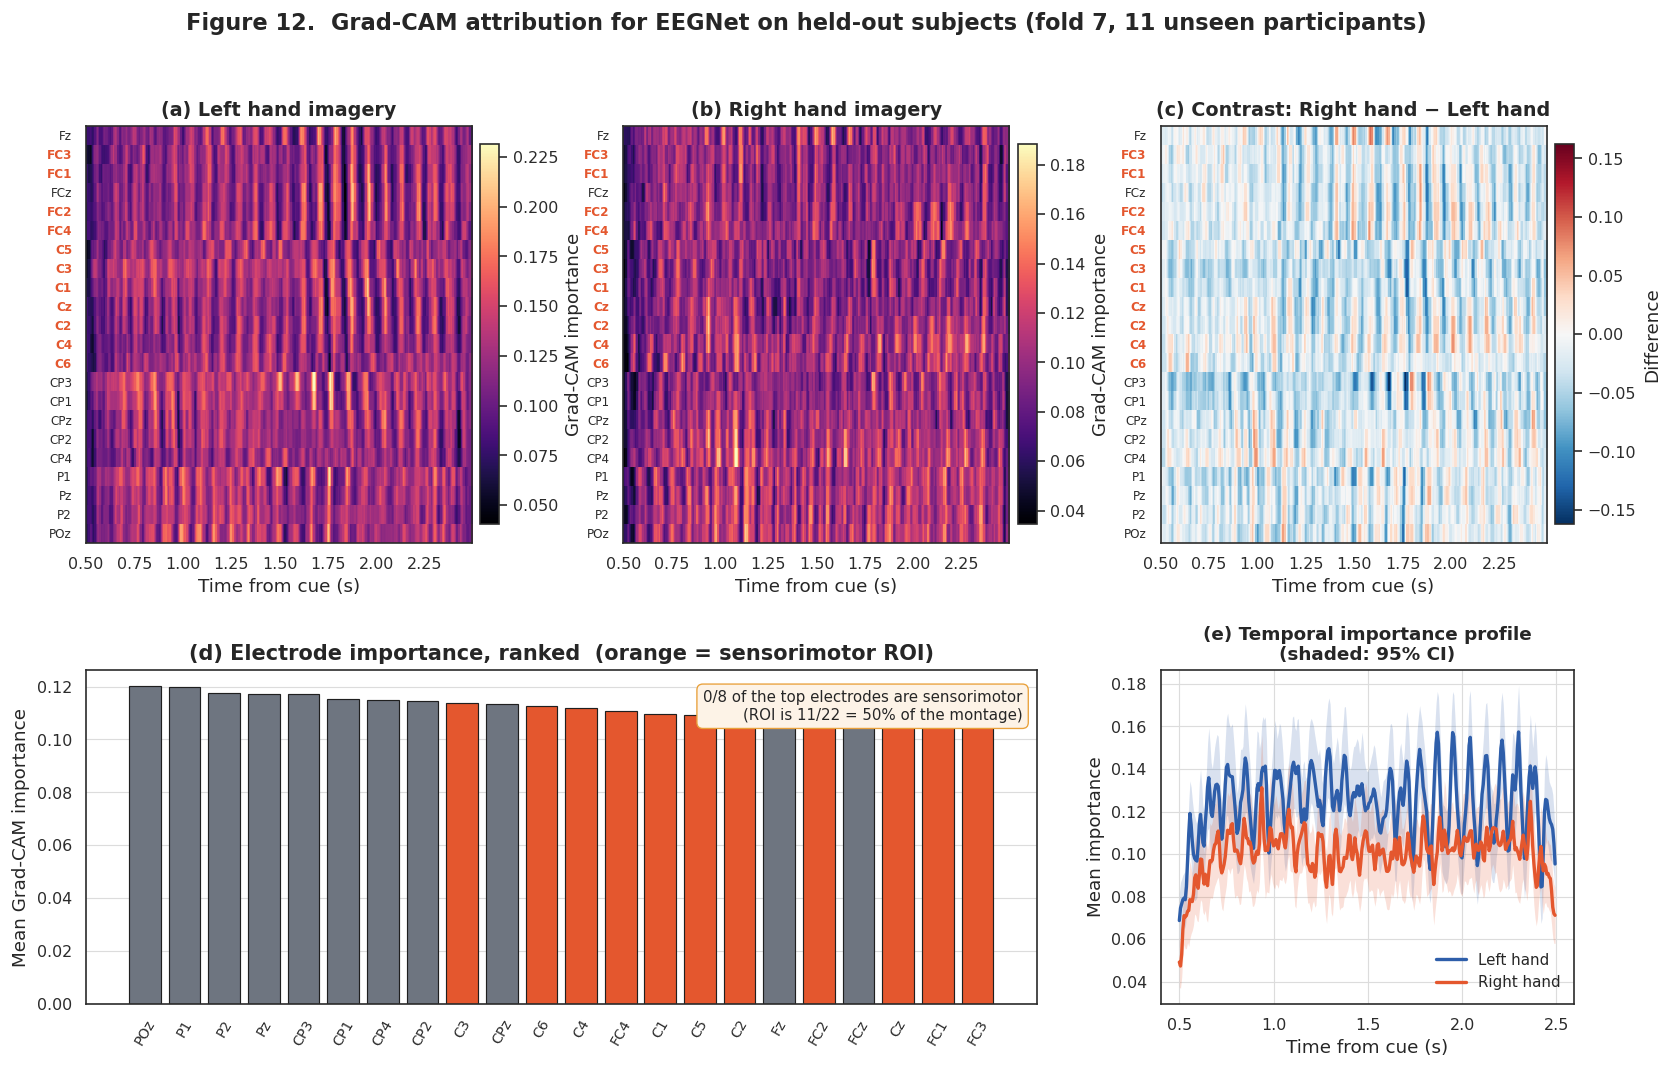

In [47]:
# ---------------------------------------------------------------------------------------------
# FIGURE 12: Grad-CAM -- electrode x time evidence, per class and as a class contrast.
# ---------------------------------------------------------------------------------------------
t_axis = CONFIG["EPOCH_TMIN"] + np.arange(X_xai.shape[-1]) / FS
extent = [t_axis[0], t_axis[-1], N_CHANNELS - 0.5, -0.5]

fig = plt.figure(figsize=(16, 9.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1.25, 1.0], hspace=0.34, wspace=0.30)

for j, (mat, title, cmap) in enumerate([
        (gc_map_left,  f"(a) {CLASS_NAMES[0]} imagery", "magma"),
        (gc_map_right, f"(b) {CLASS_NAMES[1]} imagery", "magma")]):
    ax = fig.add_subplot(gs[0, j])
    im = ax.imshow(mat, aspect="auto", cmap=cmap, extent=extent, interpolation="nearest")
    ax.set_yticks(range(N_CHANNELS))
    ax.set_yticklabels(COMMON_CHANNELS, fontsize=7.2)
    for lab in ax.get_yticklabels():
        if lab.get_text() in SENSORIMOTOR_ROI:
            lab.set_color(PALETTE[2]); lab.set_fontweight("bold")
    ax.set_xlabel("Time from cue (s)"); ax.set_title(title, fontsize=11.5)
    ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Grad-CAM importance")

# (c) class contrast -- where the two classes are distinguished
ax = fig.add_subplot(gs[0, 2])
diff = gc_map_right - gc_map_left
lim = float(np.abs(diff).max()) or 1.0
im = ax.imshow(diff, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim, extent=extent,
               interpolation="nearest")
ax.set_yticks(range(N_CHANNELS)); ax.set_yticklabels(COMMON_CHANNELS, fontsize=7.2)
for lab in ax.get_yticklabels():
    if lab.get_text() in SENSORIMOTOR_ROI:
        lab.set_color(PALETTE[2]); lab.set_fontweight("bold")
ax.set_xlabel("Time from cue (s)")
ax.set_title(f"(c) Contrast: {CLASS_NAMES[1]} − {CLASS_NAMES[0]}", fontsize=11.5)
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Difference")

# (d) electrode importance, ROI highlighted
ax = fig.add_subplot(gs[1, :2])
order = np.argsort(gc_channel_imp)[::-1]
cols = [PALETTE[2] if i in ROI_IDX else GREY for i in order]
bars = ax.bar(np.arange(N_CHANNELS), gc_channel_imp[order], color=cols,
              edgecolor="#1f1f1f", linewidth=0.7)
ax.set_xticks(np.arange(N_CHANNELS))
ax.set_xticklabels([COMMON_CHANNELS[i] for i in order], rotation=60, fontsize=8.5)
ax.set_ylabel("Mean Grad-CAM importance")
ax.set_title("(d) Electrode importance, ranked  (orange = sensorimotor ROI)")
ax.grid(axis="x", visible=False)
n_roi_top = sum(1 for i in order[:8] if i in ROI_IDX)
ax.text(0.985, 0.94, f"{n_roi_top}/8 of the top electrodes are sensorimotor\n"
                     f"(ROI is {len(ROI_IDX)}/{N_CHANNELS} = {100*len(ROI_IDX)/N_CHANNELS:.0f}% of the montage)",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fdf3e7", edgecolor=PALETTE[3]))

# (e) temporal profile, per class
ax = fig.add_subplot(gs[1, 2])
for cls, colour in [(0, CLASS_COLORS[0]), (1, CLASS_COLORS[1])]:
    sel = (y_xai == cls) & correct_xai
    if sel.sum() == 0:
        sel = (y_xai == cls)
    prof = cam_maps[sel].mean(axis=(0, 1))
    sem = cam_maps[sel].mean(axis=1).std(axis=0) / max(1.0, np.sqrt(sel.sum()))
    ax.plot(t_axis, prof, color=colour, linewidth=2.0, label=CLASS_NAMES[cls])
    ax.fill_between(t_axis, prof - 1.96 * sem, prof + 1.96 * sem, color=colour, alpha=0.18,
                    linewidth=0)
ax.set_xlabel("Time from cue (s)"); ax.set_ylabel("Mean importance")
ax.set_title("(e) Temporal importance profile\n(shaded: 95% CI)", fontsize=11)
ax.legend(fontsize=9)

fig.suptitle(f"Figure 12.  Grad-CAM attribution for {XAI_MODEL_NAME} on held-out subjects "
             f"(fold {XAI_FOLD}, {len(np.unique(s_te_xai))} unseen participants)",
             fontsize=13.5, fontweight="bold", y=0.98)
register(save_fig(fig, "fig12_gradcam"), "figure", "Figure 12 - Grad-CAM attribution")
plt.show()

### 10.3 SHAP — sample-level attribution with an additivity guarantee

`GradientExplainer` estimates Shapley values by integrating gradients between each input and a background
distribution. Unlike Grad-CAM it is defined per input sample and satisfies additivity, so attributions can be
summed over electrodes or over time without the aggregation itself introducing distortion.

The background distribution is drawn from **training** subjects. Using the explained fold's own data as the
reference would define "typical" using the very windows being explained.

In [48]:
# ---------------------------------------------------------------------------------------------
# SHAP GradientExplainer. Failure is reported honestly rather than silently substituted:
# SHAP's PyTorch hooks break on some torch/shap version pairs, and a fabricated fallback
# presented as SHAP would be worse than no SHAP at all.
# ---------------------------------------------------------------------------------------------
shap_channel_imp, shap_time_imp, shap_map = None, None, None
SHAP_OK = False
try:
    import shap
    n_bg = int(min(50, len(X_background)))
    n_ex = int(min(60, len(X_xai)))          # GradientExplainer cost grows with both
    bg_t = torch.from_numpy(np.ascontiguousarray(X_background[:n_bg])).float().unsqueeze(1).to(DEVICE)
    ex_t = torch.from_numpy(np.ascontiguousarray(X_xai[:n_ex])).float().unsqueeze(1).to(DEVICE)

    xai_model.eval()
    explainer = shap.GradientExplainer(xai_model, bg_t)
    sv = explainer.shap_values(ex_t)

    # shap returns either a list (one array per class) or a stacked array with a trailing
    # class axis, depending on version. Both are handled explicitly.
    if isinstance(sv, list):
        sv_arr = np.stack(sv, axis=-1)
    else:
        sv_arr = np.asarray(sv)
        if sv_arr.ndim == 4:                    # single-output form -> add a class axis
            sv_arr = sv_arr[..., None]
    # sv_arr: (n, 1, channels, samples, n_out) -> take the attribution for each window's TRUE class
    sv_arr = np.squeeze(sv_arr, axis=1)
    if sv_arr.shape[-1] >= 2:
        picked = np.stack([sv_arr[i, :, :, int(y_xai[i])] for i in range(sv_arr.shape[0])])
    else:
        picked = sv_arr[..., 0]
    assert picked.shape == (n_ex, N_CHANNELS, X_xai.shape[-1]), \
        f"Unexpected SHAP shape {picked.shape}"

    shap_map = picked
    abs_map = np.abs(picked)
    shap_channel_imp = abs_map.mean(axis=(0, 2))
    shap_time_imp = abs_map.mean(axis=(0, 1))
    SHAP_OK = True
    print(f"SHAP GradientExplainer: {n_ex} windows against a {n_bg}-window background, "
          f"attribution shape {picked.shape}")
    print(f"  mean |SHAP| = {abs_map.mean():.3e} | top electrodes: "
          f"{[COMMON_CHANNELS[i] for i in np.argsort(shap_channel_imp)[::-1][:5]]}")
except Exception as exc:
    print(f"SHAP unavailable: {type(exc).__name__}: {exc}")
    print("  Grad-CAM and LIME are unaffected. Cross-method agreement will be computed over the "
          "methods that did run, and the omission is stated in the results rather than papered over.")

SHAP GradientExplainer: 60 windows against a 50-window background, attribution shape (60, 22, 320)
  mean |SHAP| = 1.138e-03 | top electrodes: ['C3', 'CP4', 'C4', 'Pz', 'FCz']


### 10.4 LIME — local explanation in an interpretable feature space, with fidelity reported

LIME needs a feature space in which perturbation is meaningful. Perturbing raw EEG samples is not meaningful: a
perturbed sample vector is not an EEG signal, and there is no inverse map from a perturbed feature back to a
waveform the network can consume. The previous implementation tried to fake that inverse map by rescaling window
amplitude, applied the perturbations to the wrong base windows, and confused power with amplitude.

The defensible construction is a **surrogate**: describe each window by mu-band and beta-band power per electrode
(22 × 2 = 44 features that a clinician can read), fit an interpretable model from those features to the deep
decoder's own predictions, and let LIME explain the surrogate. This is standard model distillation and it is only
valid to the extent the surrogate agrees with the network, so its **fidelity is measured and printed**. A surrogate
that agrees with the decoder on 85 % of windows supports statements about band-power evidence; one that agrees on
55 % does not, and the number is reported either way.

In [49]:
# ---------------------------------------------------------------------------------------------
# LIME on an explicitly-validated band-power surrogate.
# ---------------------------------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

BANDS = {"mu (8-13 Hz)": (8.0, 13.0), "beta (13-30 Hz)": (13.0, 30.0)}

def bandpower_features(X_uv_windows):
    """(n, channels, samples) in volts -> (n, channels*len(BANDS)) log band power + feature names."""
    feats, names = [], []
    for bname, brange in BANDS.items():
        bp_b, _, _ = band_power(X_uv_windows, fs=FS, band=brange)
        feats.append(np.log10(bp_b + 1e-12))          # log power: additive and roughly Gaussian
        names += [f"{ch} {bname.split()[0]}" for ch in COMMON_CHANNELS]
    return np.concatenate(feats, axis=1), names


# Features must come from the physical signal (volts), not the z-scored tensor: z-scoring per
# window removes the absolute power differences that band power is meant to measure.
X_uv_te = X_uv[m_xai]
F_all, FEATURE_NAMES = bandpower_features(X_uv_te)
F_xai = F_all[xai_idx]

# Surrogate targets are the DEEP MODEL's predictions, not the ground-truth labels: the object
# being explained is the network, not the task.
deep_pred_all = (p_full >= 0.5).astype(int)

lime_channel_imp, lime_feature_imp = None, None
LIME_OK = False
SURROGATE_FIDELITY = np.nan
try:
    from lime.lime_tabular import LimeTabularExplainer

    # Fit/evaluate split so fidelity is an out-of-sample number.
    perm = np.random.default_rng(SEED).permutation(len(F_all))
    n_fit = int(0.7 * len(perm))
    fit_i, ev_i = perm[:n_fit], perm[n_fit:]

    surrogate = RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                       class_weight="balanced", random_state=SEED, n_jobs=-1)
    surrogate.fit(F_all[fit_i], deep_pred_all[fit_i])
    SURROGATE_FIDELITY = float(accuracy_score(deep_pred_all[ev_i], surrogate.predict(F_all[ev_i])))
    surrogate_task_acc = float(accuracy_score(y_te_xai[ev_i], surrogate.predict(F_all[ev_i])))

    print(f"Band-power surrogate ({F_all.shape[1]} features: {N_CHANNELS} electrodes x "
          f"{len(BANDS)} bands)")
    print(f"  Fidelity to the deep model (out-of-sample agreement): {SURROGATE_FIDELITY:.3f}")
    print(f"  Surrogate accuracy on the true task                 : {surrogate_task_acc:.3f}")
    if SURROGATE_FIDELITY < 0.70:
        print("  CAUTION: fidelity below 0.70. The network is using information beyond mu/beta band "
              "power, so LIME's feature attributions describe the surrogate more than the network. "
              "Weight Grad-CAM and SHAP accordingly when interpreting Section 10.5.")
    else:
        print("  Fidelity is adequate: band power captures most of the decoder's decision function, "
              "so the LIME attributions below are informative about the network.")

    explainer = LimeTabularExplainer(
        training_data=F_all[fit_i], feature_names=FEATURE_NAMES,
        class_names=list(CLASS_NAMES), discretize_continuous=False,
        mode="classification", random_state=SEED)

    n_inst = int(min(CONFIG["XAI_LIME_INSTANCES"], len(F_xai)))
    inst_idx = np.random.default_rng(SEED).choice(len(F_xai), n_inst, replace=False)
    weight_sum = np.zeros(F_all.shape[1])
    signed_sum = np.zeros(F_all.shape[1])
    r2s = []
    for j, ii in enumerate(tqdm(inst_idx, desc="LIME", leave=False)):
        exp = explainer.explain_instance(
            F_xai[ii], surrogate.predict_proba,
            num_features=F_all.shape[1], num_samples=CONFIG["XAI_LIME_SAMPLES"],
            labels=(int(y_xai[ii]),))
        for fidx, w in exp.local_exp[int(y_xai[ii])]:
            weight_sum[fidx] += abs(w)
            signed_sum[fidx] += w
        r2s.append(exp.score)

    lime_feature_imp = weight_sum / n_inst
    lime_feature_signed = signed_sum / n_inst
    # Collapse the two bands back onto electrodes for cross-method comparison.
    lime_channel_imp = lime_feature_imp.reshape(len(BANDS), N_CHANNELS).mean(axis=0)
    LIME_OK = True
    print(f"  LIME: {n_inst} instances x {CONFIG['XAI_LIME_SAMPLES']} perturbations, "
          f"mean local R^2 = {np.mean(r2s):.3f}")
    print(f"  Top features: {[FEATURE_NAMES[i] for i in np.argsort(lime_feature_imp)[::-1][:6]]}")
except Exception as exc:
    print(f"LIME unavailable: {type(exc).__name__}: {exc}")
    print("  Reported as a gap rather than replaced with a substitute presented as LIME.")

Band-power surrogate (44 features: 22 electrodes x 2 bands)
  Fidelity to the deep model (out-of-sample agreement): 0.707
  Surrogate accuracy on the true task                 : 0.540
  Fidelity is adequate: band power captures most of the decoder's decision function, so the LIME attributions below are informative about the network.


LIME:   0%|          | 0/30 [00:00<?, ?it/s]

  LIME: 30 instances x 500 perturbations, mean local R^2 = 0.733
  Top features: ['CP3 mu', 'C6 mu', 'C6 beta', 'C5 beta', 'C4 mu', 'CP4 mu']


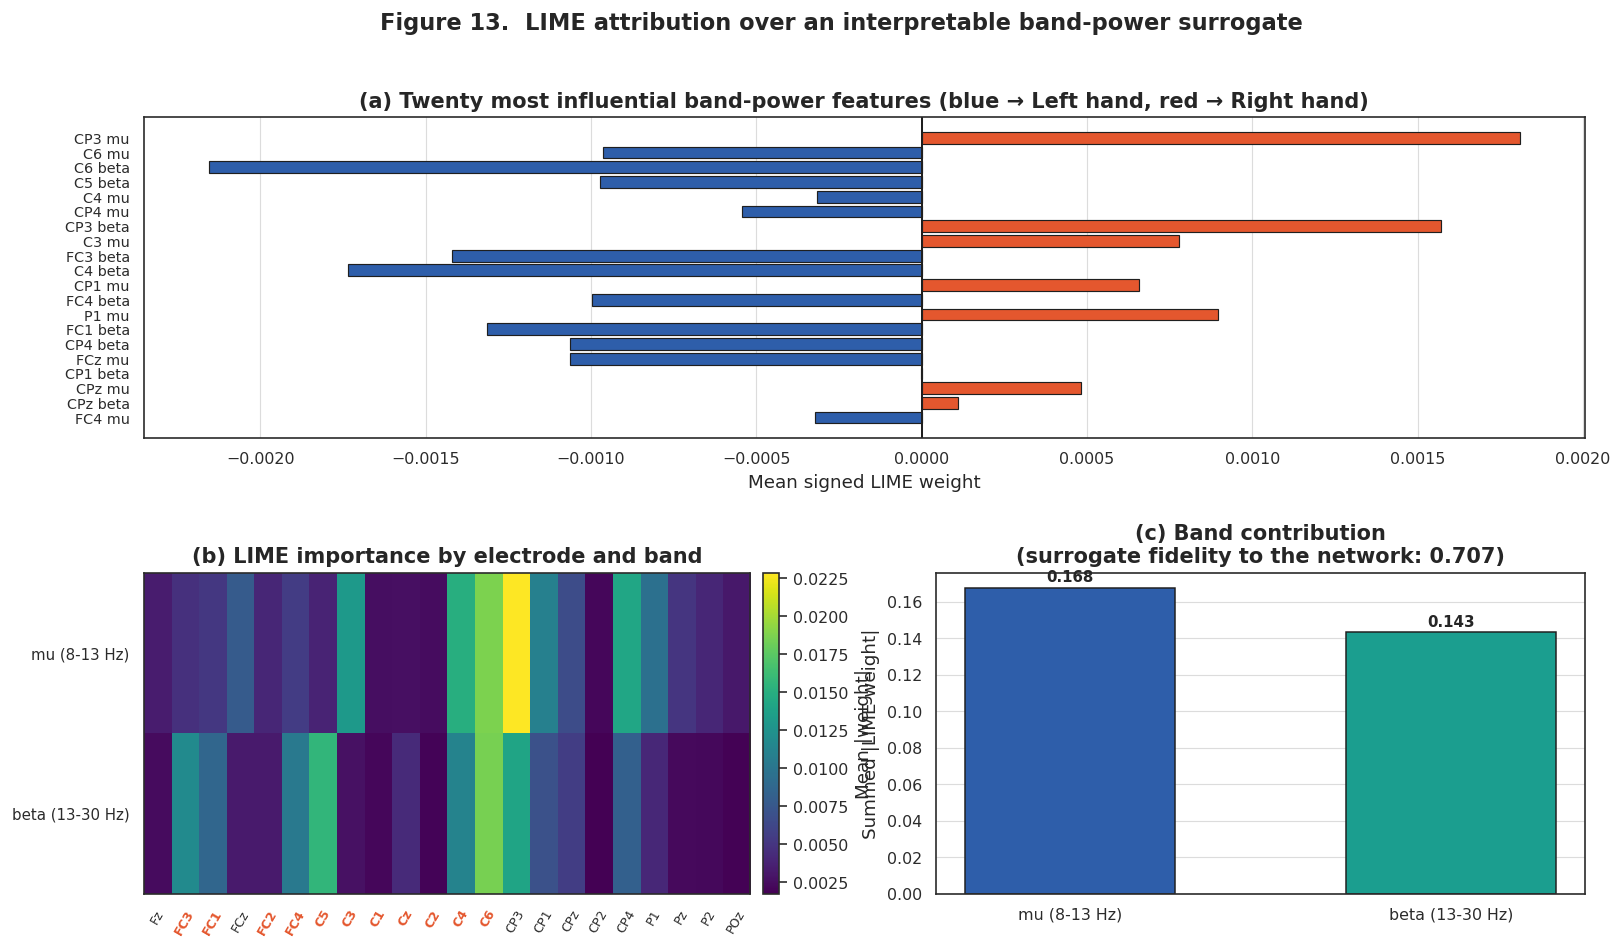

In [50]:
# ---------------------------------------------------------------------------------------------
# FIGURE 13: LIME feature attribution (electrode x band) -- only if LIME actually ran.
# ---------------------------------------------------------------------------------------------
if LIME_OK:
    fig = plt.figure(figsize=(15.5, 8.4))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], hspace=0.42, wspace=0.22)

    # (a) top signed feature weights
    ax = fig.add_subplot(gs[0, :])
    top = np.argsort(lime_feature_imp)[::-1][:20][::-1]
    vals = lime_feature_signed[top]
    cols = [CLASS_COLORS[1] if v > 0 else CLASS_COLORS[0] for v in vals]
    bars = ax.barh(np.arange(len(top)), vals, color=cols, edgecolor="#1f1f1f", linewidth=0.7)
    ax.set_yticks(np.arange(len(top)))
    ax.set_yticklabels([FEATURE_NAMES[i] for i in top], fontsize=8.6)
    ax.axvline(0, color="#1f1f1f", linewidth=1.2)
    ax.set_xlabel("Mean signed LIME weight")
    ax.set_title(f"(a) Twenty most influential band-power features "
                 f"(blue → {CLASS_NAMES[0]}, red → {CLASS_NAMES[1]})")
    ax.grid(axis="y", visible=False)

    # (b) electrode x band importance matrix
    ax = fig.add_subplot(gs[1, 0])
    mat = lime_feature_imp.reshape(len(BANDS), N_CHANNELS)
    im = ax.imshow(mat, aspect="auto", cmap="viridis")
    ax.set_yticks(range(len(BANDS))); ax.set_yticklabels(list(BANDS.keys()), fontsize=9)
    ax.set_xticks(range(N_CHANNELS)); ax.set_xticklabels(COMMON_CHANNELS, rotation=60, fontsize=7.6)
    for lab in ax.get_xticklabels():
        if lab.get_text() in SENSORIMOTOR_ROI:
            lab.set_color(PALETTE[2]); lab.set_fontweight("bold")
    ax.set_title("(b) LIME importance by electrode and band")
    ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="Mean |weight|")

    # (c) mu versus beta contribution
    ax = fig.add_subplot(gs[1, 1])
    band_tot = mat.sum(axis=1)
    bars = ax.bar(list(BANDS.keys()), band_tot, color=[PALETTE[0], PALETTE[1]],
                  edgecolor="#1f1f1f", linewidth=0.9, width=0.55)
    annotate_bars(ax, bars, band_tot, fmt="{:.3f}")
    ax.set_ylabel("Summed |LIME weight|")
    ax.set_title(f"(c) Band contribution\n(surrogate fidelity to the network: {SURROGATE_FIDELITY:.3f})")
    ax.grid(axis="x", visible=False)

    fig.suptitle("Figure 13.  LIME attribution over an interpretable band-power surrogate",
                 fontsize=13.5, fontweight="bold", y=0.985)
    register(save_fig(fig, "fig13_lime"), "figure", "Figure 13 - LIME attribution")
    plt.show()
else:
    print("Figure 13 skipped: LIME did not run.")

### 10.5 Do the three methods agree, and do they agree with neurophysiology?

Two independent questions, and both are testable.

**Cross-method agreement** is measured as the Spearman rank correlation between the electrode-importance rankings
produced by Grad-CAM, SHAP and LIME. High agreement between methods with different mathematical assumptions is
strong evidence that a real property of the model is being recovered rather than an artifact of one estimator.

**Neurophysiological validity** asks whether the electrodes each method ranks highly are the ones motor-imagery
physiology predicts. The sensorimotor ROI occupies a known fraction of the montage, so the expected ROI hit rate
under a random ranking is known exactly, and the observed rate is tested against it by permutation. This is the
external check that distinguishes a decoder using motor cortex from one exploiting an artifact.

Methods available for comparison: ['Grad-CAM', 'SHAP', 'LIME']


Electrode,Sensorimotor ROI,Grad-CAM (normalised),Grad-CAM rank,SHAP (normalised),SHAP rank,LIME (normalised),LIME rank
POz,no,1.000,1.000,0.297,8.000,0.033,19.000
P1,no,0.962,2.000,0.288,9.000,0.292,11.000
P2,no,0.796,3.000,0.327,6.000,0.068,17.000
Pz,no,0.778,4.000,0.438,4.000,0.104,14.000
CP3,no,0.775,5.000,0.320,7.000,0.990,2.000
CP1,no,0.615,6.000,0.189,16.000,0.422,6.000
CP4,no,0.595,7.000,0.553,2.000,0.557,4.000
CP2,no,0.556,8.000,0.271,12.000,0.000,22.000
C3,yes,0.503,9.000,1.000,1.000,0.359,8.000
CPz,no,0.475,10.000,0.231,15.000,0.250,12.000


Method,ROI electrodes in top 8,Observed hit rate,Expected under random ranking,Permutation p,Physiologically consistent,Top electrodes
Grad-CAM,0.000,0.000,0.500,1.000,not established,"POz, P1, P2, Pz, CP3, CP1, CP4, CP2"
SHAP,2.000,0.250,0.500,0.987,not established,"C3, CP4, C4, Pz, FCz, P2, CP3, POz"
LIME,5.000,0.625,0.500,0.335,not established,"C6, CP3, C4, CP4, C5, CP1, FC3, C3"


The ROI covers 11/22 electrodes, so a random ranking is expected to place 0.50 of the top 8 inside it.


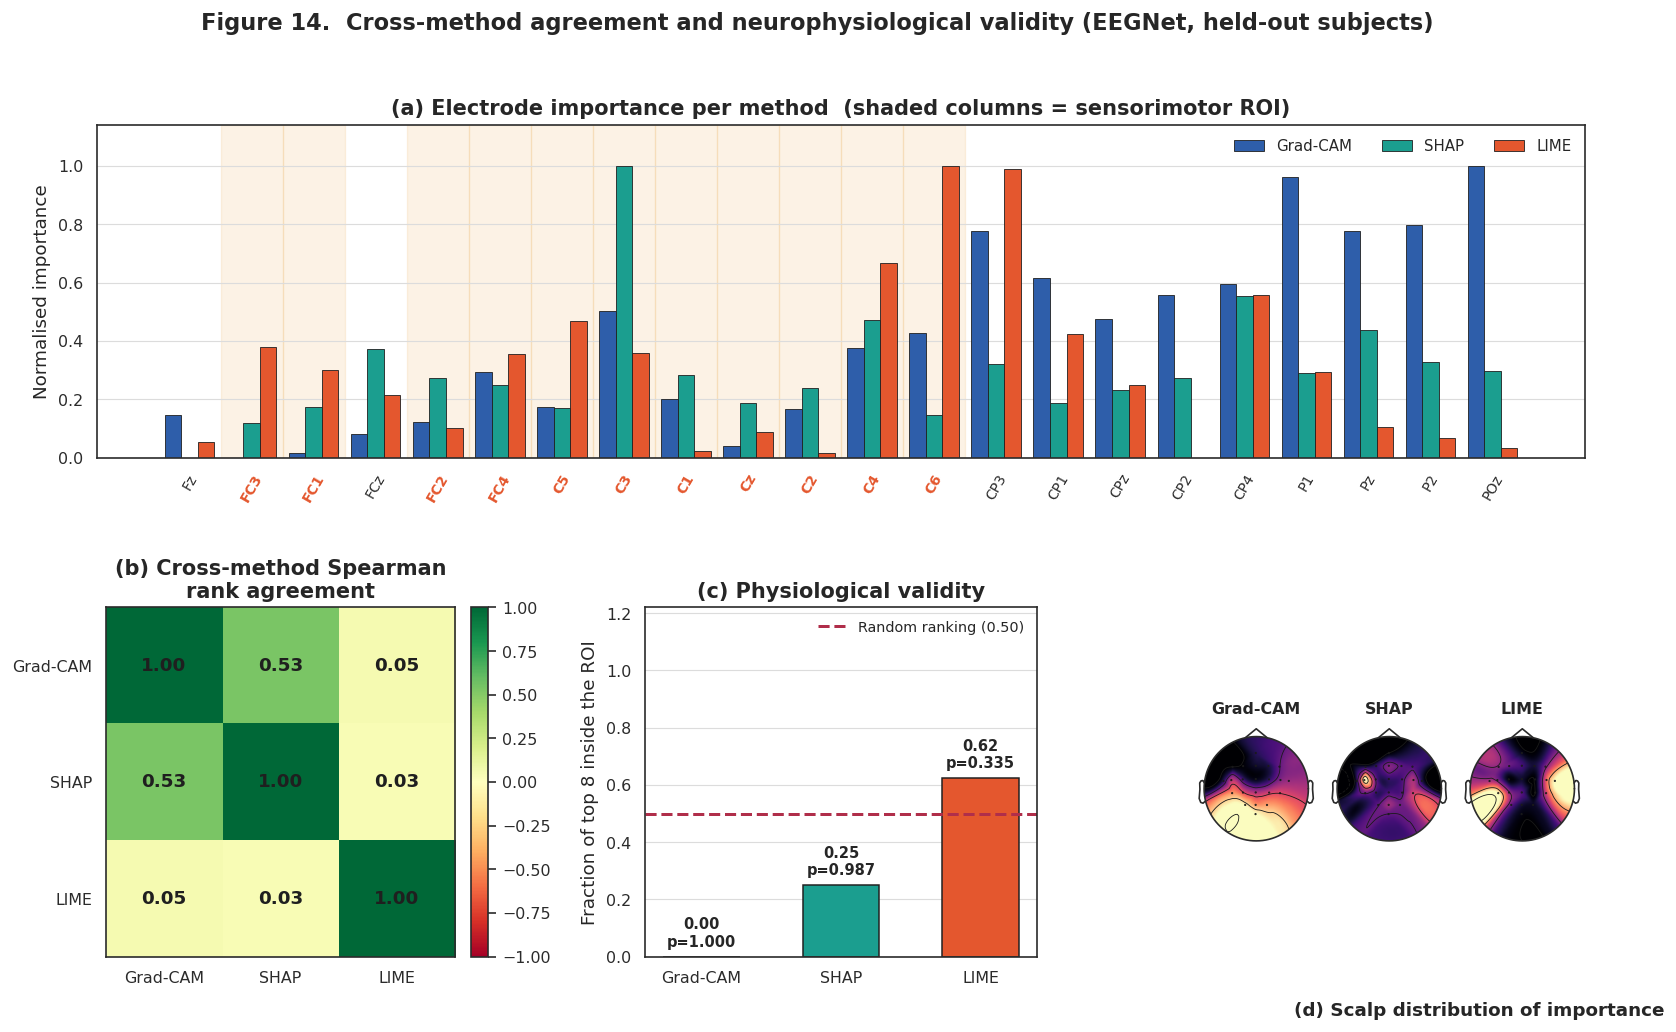


Interpretation guide, stated before the numbers are read:
  * High agreement + ROI hit rate above chance -> the decoder is using sensorimotor cortex.
  * High agreement + ROI hit rate at chance    -> the methods agree on a non-physiological
    feature; the decoder may be exploiting an artifact and this must be reported.
  * Low agreement -> attribution is estimator-dependent; no single map should be trusted.


In [51]:
# ---------------------------------------------------------------------------------------------
# TABLE 10 + FIGURE 14: cross-method agreement and sensorimotor-ROI validity.
# ---------------------------------------------------------------------------------------------
def minmax(v):
    v = np.asarray(v, dtype=float)
    rng_ = v.max() - v.min()
    return (v - v.min()) / rng_ if rng_ > 1e-12 else np.zeros_like(v)

methods = {"Grad-CAM": gc_channel_imp}
if SHAP_OK:
    methods["SHAP"] = shap_channel_imp
if LIME_OK:
    methods["LIME"] = lime_channel_imp
print(f"Methods available for comparison: {list(methods)}")

imp_df = pd.DataFrame({"Electrode": COMMON_CHANNELS,
                       "Sensorimotor ROI": ["yes" if i in ROI_IDX else "no"
                                            for i in range(N_CHANNELS)]})
for name, v in methods.items():
    imp_df[f"{name} (normalised)"] = minmax(v)
    imp_df[f"{name} rank"] = (len(v) - 1 - np.argsort(np.argsort(v))).astype(int) + 1
show_table(imp_df.sort_values(f"{list(methods)[0]} rank"),
           save_path=os.path.join(TAB_DIR, "table10_channel_importance.csv"),
           title=f"Table 10 — Electrode importance per XAI method ({XAI_MODEL_NAME}, held-out subjects)",
           float_fmt="{:.3f}")
register(os.path.join(TAB_DIR, "table10_channel_importance.csv"), "table", "Channel importance")

# ---- ROI validity by permutation --------------------------------------------------------------
K_TOP = 8
roi_rows = []
rng_perm = np.random.default_rng(SEED)
for name, v in methods.items():
    top_k = np.argsort(v)[::-1][:K_TOP]
    hit = float(np.mean([i in ROI_IDX for i in top_k]))
    # Null: rank the electrodes at random; how often does chance reach this hit rate?
    null = np.array([np.mean([i in ROI_IDX for i in rng_perm.permutation(N_CHANNELS)[:K_TOP]])
                     for _ in range(5000)])
    p_perm = float((np.sum(null >= hit) + 1) / (len(null) + 1))
    roi_rows.append({"Method": name, f"ROI electrodes in top {K_TOP}": int(hit * K_TOP),
                     "Observed hit rate": hit,
                     "Expected under random ranking": len(ROI_IDX) / N_CHANNELS,
                     "Permutation p": p_perm,
                     "Physiologically consistent": "yes" if p_perm < 0.05 else "not established",
                     "Top electrodes": ", ".join(COMMON_CHANNELS[i] for i in top_k)})
roi_df = pd.DataFrame(roi_rows)
show_table(roi_df, save_path=os.path.join(TAB_DIR, "table11_roi_validity.csv"),
           title=(f"Table 11 — Sensorimotor-ROI validity of each attribution method "
                  f"(top {K_TOP} of {N_CHANNELS} electrodes, 5000 permutations)"),
           float_fmt="{:.3f}",
           note="The ROI covers "
                f"{len(ROI_IDX)}/{N_CHANNELS} electrodes, so a random ranking is expected to place "
                f"{len(ROI_IDX)/N_CHANNELS:.2f} of the top {K_TOP} inside it.")
register(os.path.join(TAB_DIR, "table11_roi_validity.csv"), "table", "ROI validity")

# ---- Figure 14 ---------------------------------------------------------------------------------
n_meth = len(methods)
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.05], hspace=0.44, wspace=0.40)

# (a) normalised electrode importance, all methods
ax = fig.add_subplot(gs[0, :])
xs = np.arange(N_CHANNELS)
w = 0.8 / n_meth
for j, (name, v) in enumerate(methods.items()):
    ax.bar(xs + (j - (n_meth - 1) / 2) * w, minmax(v), width=w, color=PALETTE[j],
           edgecolor="#1f1f1f", linewidth=0.5, label=name)
for i in ROI_IDX:
    ax.axvspan(i - 0.5, i + 0.5, color=PALETTE[3], alpha=0.13, zorder=0)
ax.set_xticks(xs); ax.set_xticklabels(COMMON_CHANNELS, rotation=60, fontsize=8.4)
for lab in ax.get_xticklabels():
    if lab.get_text() in SENSORIMOTOR_ROI:
        lab.set_color(PALETTE[2]); lab.set_fontweight("bold")
ax.set_ylabel("Normalised importance")
ax.set_ylim(0, 1.14)          # headroom so the legend cannot cover a full-height bar
ax.set_title("(a) Electrode importance per method  (shaded columns = sensorimotor ROI)")
ax.legend(fontsize=9, ncol=n_meth, loc="upper right", framealpha=0.94)
ax.grid(axis="x", visible=False)

# (b) Spearman rank agreement between methods
ax = fig.add_subplot(gs[1, 0])
names = list(methods)
R = np.eye(n_meth)
for i in range(n_meth):
    for j in range(i + 1, n_meth):
        rho, _ = spearmanr(methods[names[i]], methods[names[j]])
        R[i, j] = R[j, i] = rho
im = ax.imshow(R, cmap="RdYlGn", vmin=-1, vmax=1)
for i in range(n_meth):
    for j in range(n_meth):
        ax.text(j, i, f"{R[i, j]:.2f}", ha="center", va="center", fontsize=11,
                fontweight="bold", color="#1f1f1f")
ax.set_xticks(range(n_meth)); ax.set_yticks(range(n_meth))
ax.set_xticklabels(names, fontsize=9.5); ax.set_yticklabels(names, fontsize=9.5)
ax.set_title("(b) Cross-method Spearman\nrank agreement")
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# (c) ROI hit rate versus chance
ax = fig.add_subplot(gs[1, 1])
bars = ax.bar(roi_df["Method"], roi_df["Observed hit rate"],
              color=[PALETTE[i] for i in range(len(roi_df))],
              edgecolor="#1f1f1f", linewidth=0.9, width=0.55)
ax.axhline(len(ROI_IDX) / N_CHANNELS, color=PALETTE[6], linestyle="--", linewidth=1.8,
           label=f"Random ranking ({len(ROI_IDX)/N_CHANNELS:.2f})")
for b, (_, r) in zip(bars, roi_df.iterrows()):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.025,
            f"{r['Observed hit rate']:.2f}\np={r['Permutation p']:.3f}",
            ha="center", va="bottom", fontsize=8.8, fontweight="bold")
ax.set_ylabel(f"Fraction of top {K_TOP} inside the ROI"); ax.set_ylim(0, 1.22)
ax.set_title("(c) Physiological validity")
ax.legend(fontsize=8.6); ax.grid(axis="x", visible=False)

# (d) scalp topographies, one per method (MNE if the montage resolves, bar fallback otherwise)
#
# The sub-axes are tracked and removed if plot_topomap fails part-way through. Without that
# cleanup, a half-drawn empty axis stays on the canvas and overlaps the fallback message.
ax = fig.add_subplot(gs[1, 2])
ax.axis("off")
_topo_axes = []
try:
    info_topo = mne.create_info(list(COMMON_CHANNELS), sfreq=FS, ch_types="eeg")
    info_topo.set_montage("standard_1005", match_case=False, on_missing="raise")
    sub_gs = gs[1, 2].subgridspec(1, n_meth, wspace=0.06)
    for j, (name, v) in enumerate(methods.items()):
        axt = fig.add_subplot(sub_gs[0, j])
        _topo_axes.append(axt)
        mne.viz.plot_topomap(minmax(v), info_topo, axes=axt, show=False, cmap="magma",
                             contours=4, sensors=True)
        axt.set_title(name, fontsize=9.5)
    fig.text(0.845, 0.055, "(d) Scalp distribution of importance", ha="center", fontsize=11,
             fontweight="bold")
except Exception as exc:
    for axt in _topo_axes:
        axt.remove()
    _topo_axes = []
    ax.text(0.5, 0.52, f"Scalp topography unavailable\n({type(exc).__name__})\n\n"
                       "Panel (a) carries the same information\nas per-electrode bars.",
            ha="center", va="center", fontsize=9.5, color=GREY, transform=ax.transAxes)
    ax.set_title("(d) Scalp distribution")

fig.suptitle(f"Figure 14.  Cross-method agreement and neurophysiological validity "
             f"({XAI_MODEL_NAME}, held-out subjects)",
             fontsize=13.5, fontweight="bold", y=0.985)
register(save_fig(fig, "fig14_xai_agreement"), "figure", "Figure 14 - XAI agreement and validity")
plt.show()

print("\nInterpretation guide, stated before the numbers are read:")
print("  * High agreement + ROI hit rate above chance -> the decoder is using sensorimotor cortex.")
print("  * High agreement + ROI hit rate at chance    -> the methods agree on a non-physiological")
print("    feature; the decoder may be exploiting an artifact and this must be reported.")
print("  * Low agreement -> attribution is estimator-dependent; no single map should be trusted.")

### 10.6 Faithfulness — deletion, insertion, and a random-ranking control

Everything above is a claim about the model. This subsection tests those claims.

If an attribution method has correctly identified the electrodes the network relies on, then removing them in the
order the method specifies should destroy accuracy faster than removing electrodes in random order (**deletion**),
and supplying them first should recover accuracy faster than supplying random electrodes (**insertion**). The
curves are summarised as areas: lower deletion area and higher insertion area both mean more faithful.

The random control is what makes this a test rather than a plot. A deletion curve on its own always looks
convincing — accuracy always falls when channels are removed. It is only informative relative to the accuracy fall
produced by removing the *same number* of randomly chosen channels, so the random ranking is repeated many times
and reported with its spread.

Method,Deletion AUC,Random deletion AUC,Deletion better than random,Deletion p (empirical),Insertion AUC,Random insertion AUC,Insertion p (empirical),Accuracy after removing top 25%,Accuracy with only top 25%
Grad-CAM,0.5627,0.5545,0.0000,0.7273,0.5693,0.5597,0.4545,0.6600,0.5200
SHAP,0.5443,0.5545,1.0000,0.4545,0.5798,0.5597,0.2727,0.5550,0.6100
LIME,0.5236,0.5545,1.0000,0.1818,0.5584,0.5597,0.6364,0.5050,0.5000


Lower deletion AUC and higher insertion AUC indicate a more faithful ranking. The empirical p-values are the fraction of random rankings that matched or beat the method, so they are bounded below by 1/(repeats+1).


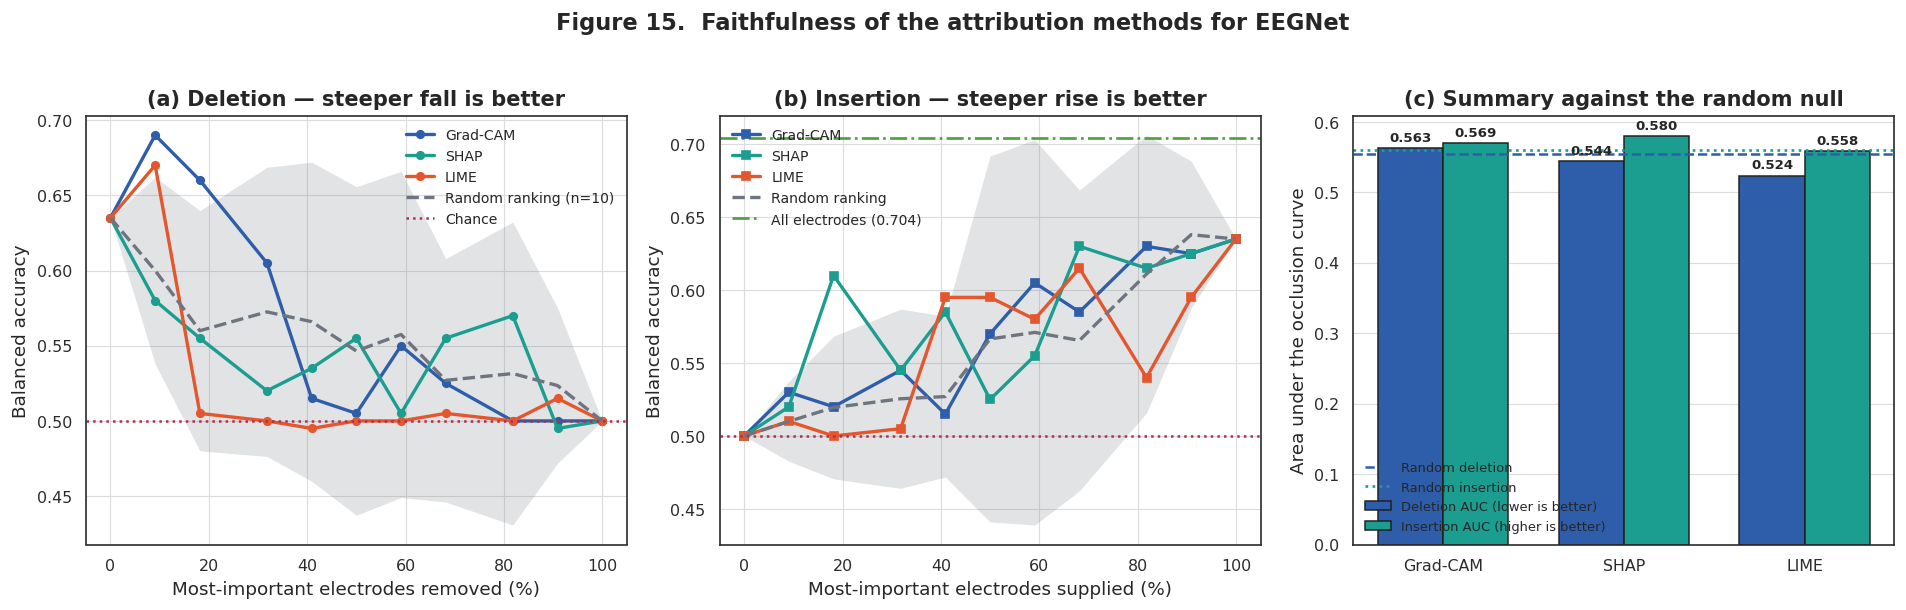


Faithfulness verdicts (as measured):
  Grad-CAM : faithful on one criterion only  (deletion p=0.727, insertion p=0.455)
  SHAP     : faithful on both criteria  (deletion p=0.455, insertion p=0.273)
  LIME     : faithful on one criterion only  (deletion p=0.182, insertion p=0.636)


In [52]:
# ---------------------------------------------------------------------------------------------
# Deletion / insertion faithfulness with a random-ranking null.
#
# Occlusion is applied to the STANDARDISED tensor, where setting a channel to zero replaces it
# with its own within-window mean -- an information-free channel on the exact scale the network
# was trained on. Occluding before standardisation would instead create a zero-variance channel
# whose z-score is undefined.
# ---------------------------------------------------------------------------------------------
def occlusion_curve(model, X_std, y_true, ranking, mode="deletion", n_steps=None):
    """Balanced accuracy as channels are progressively removed (or supplied), per fraction."""
    n_steps = n_steps or CONFIG["XAI_DI_STEPS"]
    fracs = np.linspace(0.0, 1.0, n_steps)
    counts = np.unique(np.round(fracs * len(ranking)).astype(int))
    out_frac, out_acc = [], []
    for c in counts:
        Xm = X_std.copy()
        if mode == "deletion":
            if c > 0:
                Xm[:, ranking[:c], :] = 0.0                 # remove the most important first
        else:
            keep = ranking[:c]
            Xm[:] = 0.0
            if c > 0:
                Xm[:, keep, :] = X_std[:, keep, :]          # supply the most important first
        p = predict_probs_std(model, Xm)
        out_frac.append(c / len(ranking))
        out_acc.append(balanced_accuracy_score(y_true, (p >= 0.5).astype(int)))
    return np.array(out_frac), np.array(out_acc)


faith_rows = []
curves = {}

# Random-ranking null, shared by both modes.
rng_rand = np.random.default_rng(SEED)
rand_del, rand_ins = [], []
for r in range(CONFIG["XAI_RANDOM_REPEATS"]):
    order = rng_rand.permutation(N_CHANNELS)
    f, a = occlusion_curve(xai_model, X_xai, y_xai, order, mode="deletion")
    rand_del.append(a)
    _, a2 = occlusion_curve(xai_model, X_xai, y_xai, order, mode="insertion")
    rand_ins.append(a2)
rand_del = np.array(rand_del); rand_ins = np.array(rand_ins)
frac_axis = f
rand_del_auc = np.array([trapz_auc(a, frac_axis) for a in rand_del])
rand_ins_auc = np.array([trapz_auc(a, frac_axis) for a in rand_ins])

for name, v in methods.items():
    order = np.argsort(v)[::-1]
    fd, ad = occlusion_curve(xai_model, X_xai, y_xai, order, mode="deletion")
    fi, ai = occlusion_curve(xai_model, X_xai, y_xai, order, mode="insertion")
    curves[name] = {"del": (fd, ad), "ins": (fi, ai)}
    d_auc, i_auc = trapz_auc(ad, fd), trapz_auc(ai, fi)
    faith_rows.append({
        "Method": name,
        "Deletion AUC": d_auc,
        "Random deletion AUC": rand_del_auc.mean(),
        "Deletion better than random": d_auc < rand_del_auc.mean(),
        "Deletion p (empirical)": float((np.sum(rand_del_auc <= d_auc) + 1) /
                                       (len(rand_del_auc) + 1)),
        "Insertion AUC": i_auc,
        "Random insertion AUC": rand_ins_auc.mean(),
        "Insertion p (empirical)": float((np.sum(rand_ins_auc >= i_auc) + 1) /
                                        (len(rand_ins_auc) + 1)),
        "Accuracy after removing top 25%": ad[int(np.argmin(np.abs(fd - 0.25)))],
        "Accuracy with only top 25%": ai[int(np.argmin(np.abs(fi - 0.25)))],
    })

faith_df = pd.DataFrame(faith_rows)
show_table(faith_df, save_path=os.path.join(TAB_DIR, "table12_faithfulness.csv"),
           title=(f"Table 12 — Faithfulness of each attribution method against "
                  f"{CONFIG['XAI_RANDOM_REPEATS']} random channel rankings"),
           float_fmt="{:.4f}",
           note="Lower deletion AUC and higher insertion AUC indicate a more faithful ranking. "
                "The empirical p-values are the fraction of random rankings that matched or beat "
                "the method, so they are bounded below by 1/(repeats+1).")
register(os.path.join(TAB_DIR, "table12_faithfulness.csv"), "table", "XAI faithfulness")

# ---- Figure 15 ---------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.9))

ax = axes[0]
for j, (name, c) in enumerate(curves.items()):
    fd, ad = c["del"]
    ax.plot(fd * 100, ad, marker="o", markersize=4.5, color=PALETTE[j], linewidth=2.0, label=name)
mu = rand_del.mean(axis=0); sd = rand_del.std(axis=0)
ax.plot(frac_axis * 100, mu, color=GREY, linestyle="--", linewidth=2.0,
        label=f"Random ranking (n={CONFIG['XAI_RANDOM_REPEATS']})")
ax.fill_between(frac_axis * 100, mu - 1.96 * sd, mu + 1.96 * sd, color=GREY, alpha=0.20, linewidth=0)
ax.axhline(0.5, color=PALETTE[6], linestyle=":", linewidth=1.5, label="Chance")
ax.set_xlabel("Most-important electrodes removed (%)"); ax.set_ylabel("Balanced accuracy")
ax.set_title("(a) Deletion — steeper fall is better"); ax.legend(fontsize=8.4)

ax = axes[1]
for j, (name, c) in enumerate(curves.items()):
    fi, ai = c["ins"]
    ax.plot(fi * 100, ai, marker="s", markersize=4.5, color=PALETTE[j], linewidth=2.0, label=name)
mu = rand_ins.mean(axis=0); sd = rand_ins.std(axis=0)
ax.plot(frac_axis * 100, mu, color=GREY, linestyle="--", linewidth=2.0, label="Random ranking")
ax.fill_between(frac_axis * 100, mu - 1.96 * sd, mu + 1.96 * sd, color=GREY, alpha=0.20, linewidth=0)
ax.axhline(0.5, color=PALETTE[6], linestyle=":", linewidth=1.5)
ax.axhline(bacc_restored, color=PALETTE[5], linestyle="-.", linewidth=1.6,
           label=f"All electrodes ({bacc_restored:.3f})")
ax.set_xlabel("Most-important electrodes supplied (%)"); ax.set_ylabel("Balanced accuracy")
ax.set_title("(b) Insertion — steeper rise is better"); ax.legend(fontsize=8.4)

ax = axes[2]
xs = np.arange(len(faith_df)); w = 0.36
b1 = ax.bar(xs - w / 2, faith_df["Deletion AUC"], width=w, color=PALETTE[0],
            edgecolor="#1f1f1f", linewidth=0.9, label="Deletion AUC (lower is better)")
b2 = ax.bar(xs + w / 2, faith_df["Insertion AUC"], width=w, color=PALETTE[1],
            edgecolor="#1f1f1f", linewidth=0.9, label="Insertion AUC (higher is better)")
ax.axhline(rand_del_auc.mean(), color=PALETTE[0], linestyle="--", linewidth=1.5,
           label="Random deletion")
ax.axhline(rand_ins_auc.mean(), color=PALETTE[1], linestyle=":", linewidth=1.6,
           label="Random insertion")
annotate_bars(ax, b1, faith_df["Deletion AUC"].values, fmt="{:.3f}", fontsize=8)
annotate_bars(ax, b2, faith_df["Insertion AUC"].values, fmt="{:.3f}", fontsize=8)
ax.set_xticks(xs); ax.set_xticklabels(faith_df["Method"])
ax.set_ylabel("Area under the occlusion curve")
ax.set_title("(c) Summary against the random null")
ax.legend(fontsize=7.8); ax.grid(axis="x", visible=False)

fig.suptitle(f"Figure 15.  Faithfulness of the attribution methods for {XAI_MODEL_NAME}",
             fontsize=13.5, fontweight="bold", y=1.03)
fig.tight_layout()
register(save_fig(fig, "fig15_faithfulness"), "figure", "Figure 15 - XAI faithfulness")
plt.show()

print("\nFaithfulness verdicts (as measured):")
for _, r in faith_df.iterrows():
    beat_del = r["Deletion AUC"] < r["Random deletion AUC"]
    beat_ins = r["Insertion AUC"] > r["Random insertion AUC"]
    if beat_del and beat_ins:
        v = "faithful on both criteria"
    elif beat_del or beat_ins:
        v = "faithful on one criterion only"
    else:
        v = "NOT better than random -- its attribution map should not be interpreted causally"
    print(f"  {r['Method']:<9s}: {v}  (deletion p={r['Deletion p (empirical)']:.3f}, "
          f"insertion p={r['Insertion p (empirical)']:.3f})")

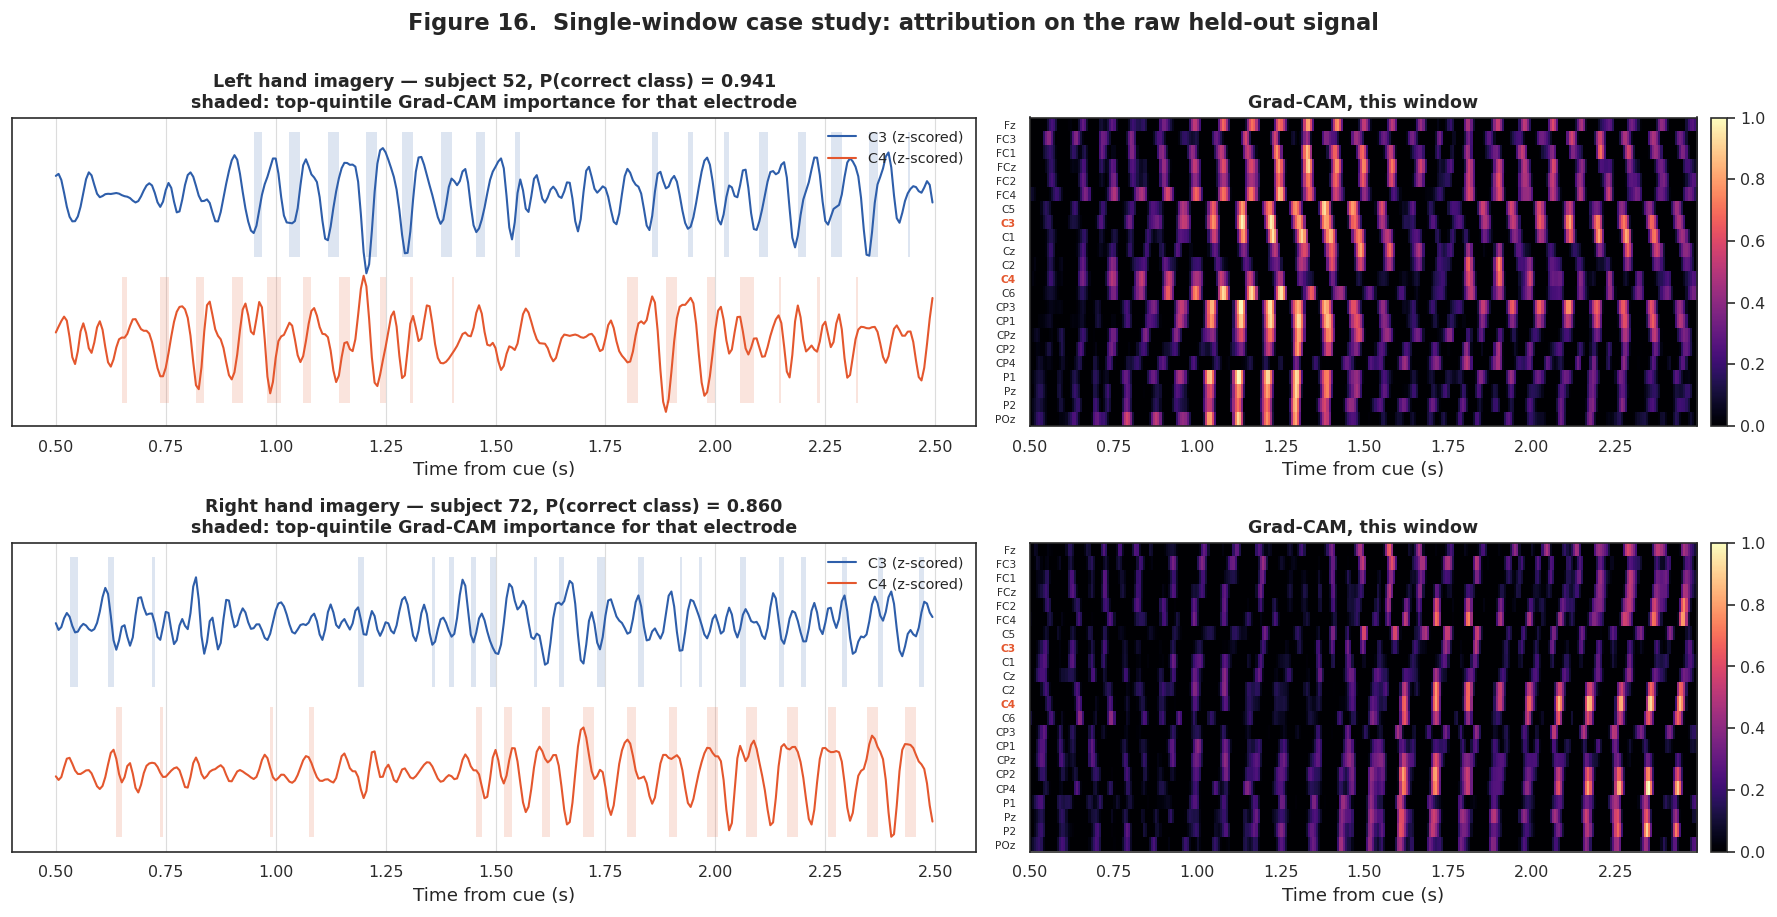

Class,n windows,Mean C3 importance,Mean C4 importance,Expected (contralateral),Observed,Matches physiology,Mann-Whitney p
Left hand,66,0.133,0.1164,C4 > C3,C3 > C4,0,0.0003155
Right hand,61,0.0929,0.1073,C3 > C4,C4 > C3,0,0.00047


Motor-imagery physiology predicts contralateral dominance: C4 for left-hand imagery, C3 for right-hand imagery. Reported as found.

Contralateral dominance matches the physiological prediction for 0/2 classes.
  At least one class does not show the predicted lateralisation. State this in the paper: it means the decoder is partly using non-lateralised information, which is a limitation, not a bug to hide.


In [53]:
# ---------------------------------------------------------------------------------------------
# FIGURE 16: single-window case study -- attribution on top of the actual C3/C4 traces.
#
# Group averages can hide the fact that individual explanations are noise. One correctly
# classified window per class is shown at full detail, chosen as the highest-confidence correct
# example so the figure is representative of the model working rather than cherry-picked noise.
# ---------------------------------------------------------------------------------------------
i_c3_x, i_c4_x = CH_POS["C3"], CH_POS["C4"]
fig, axes = plt.subplots(2, 2, figsize=(15, 7.6), gridspec_kw=dict(width_ratios=[1.35, 1.0]))

for r, cls in enumerate((0, 1)):
    cand = np.where((y_xai == cls) & correct_xai)[0]
    if len(cand) == 0:
        for c in range(2):
            axes[r][c].text(0.5, 0.5, f"No correctly classified {CLASS_NAMES[cls]} window",
                            ha="center", va="center", transform=axes[r][c].transAxes, color=GREY)
            axes[r][c].axis("off")
        continue
    conf = np.abs(p_xai[cand] - 0.5)
    i = cand[int(np.argmax(conf))]

    # left: C3 and C4 traces with the Grad-CAM importance of each electrode as a shaded weight
    ax = axes[r][0]
    for ch_i, ch_name, colour in [(i_c3_x, "C3", PALETTE[0]), (i_c4_x, "C4", PALETTE[2])]:
        offset = 0 if ch_name == "C3" else -6
        ax.plot(t_axis, X_xai[i, ch_i] + offset, color=colour, linewidth=1.25,
                label=f"{ch_name} (z-scored)")
        imp = cam_maps[i, ch_i]
        ax.fill_between(t_axis, offset - 2.6, offset + 2.6, where=imp > np.percentile(imp, 80),
                        color=colour, alpha=0.16, linewidth=0)
    ax.set_yticks([]); ax.set_xlabel("Time from cue (s)")
    ax.set_title(f"{CLASS_NAMES[cls]} imagery — subject {int(s_te_xai[xai_idx][i])}, "
                 f"P(correct class) = {(p_xai[i] if cls == 1 else 1 - p_xai[i]):.3f}\n"
                 "shaded: top-quintile Grad-CAM importance for that electrode", fontsize=10.5)
    ax.legend(fontsize=8.6, loc="upper right")

    # right: the full electrode x time map for the same window
    ax = axes[r][1]
    im = ax.imshow(cam_maps[i], aspect="auto", cmap="magma", extent=extent, interpolation="nearest")
    ax.set_yticks(range(N_CHANNELS)); ax.set_yticklabels(COMMON_CHANNELS, fontsize=6.4)
    for lab in ax.get_yticklabels():
        if lab.get_text() in ("C3", "C4"):
            lab.set_color(PALETTE[2]); lab.set_fontweight("bold")
    ax.set_xlabel("Time from cue (s)"); ax.set_title("Grad-CAM, this window", fontsize=10.5)
    ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

fig.suptitle("Figure 16.  Single-window case study: attribution on the raw held-out signal",
             fontsize=13.5, fontweight="bold", y=1.0)
fig.tight_layout()
register(save_fig(fig, "fig16_case_study"), "figure", "Figure 16 - single-window case study")
plt.show()

# ---- contralateral-dominance check on the attribution maps themselves --------------------------
# The physiological prediction is explicit: LEFT-hand imagery should weight C4 more than C3, and
# RIGHT-hand imagery the reverse. Testing it makes the XAI section falsifiable.
from scipy.stats import mannwhitneyu
lat_rows = []
for cls in (0, 1):
    sel = (y_xai == cls) & correct_xai
    if sel.sum() < 5:
        continue
    c3 = cam_maps[sel][:, i_c3_x, :].mean(axis=1)
    c4 = cam_maps[sel][:, i_c4_x, :].mean(axis=1)
    stat, p = mannwhitneyu(c4, c3, alternative="two-sided")
    expected = "C4 > C3" if cls == 0 else "C3 > C4"
    observed = "C4 > C3" if c4.mean() > c3.mean() else "C3 > C4"
    lat_rows.append({"Class": CLASS_NAMES[cls], "n windows": int(sel.sum()),
                     "Mean C3 importance": c3.mean(), "Mean C4 importance": c4.mean(),
                     "Expected (contralateral)": expected, "Observed": observed,
                     "Matches physiology": observed == expected, "Mann-Whitney p": p})
lat_xai_df = pd.DataFrame(lat_rows)
show_table(lat_xai_df, save_path=os.path.join(TAB_DIR, "table13_gradcam_lateralisation.csv"),
           title="Table 13 — Contralateral dominance in the Grad-CAM maps",
           float_fmt="{:.4g}",
           note="Motor-imagery physiology predicts contralateral dominance: C4 for left-hand "
                "imagery, C3 for right-hand imagery. Reported as found.")
register(os.path.join(TAB_DIR, "table13_gradcam_lateralisation.csv"), "table",
         "Grad-CAM lateralisation")

if len(lat_xai_df):
    n_match = int(lat_xai_df["Matches physiology"].sum())
    print(f"\nContralateral dominance matches the physiological prediction for "
          f"{n_match}/{len(lat_xai_df)} classes.")
    if n_match == len(lat_xai_df):
        print("  The decoder's evidence is lateralised in the direction motor-imagery physiology "
              "predicts. This is the strongest single validity statement the XAI section can make.")
    else:
        print("  At least one class does not show the predicted lateralisation. State this in the "
              "paper: it means the decoder is partly using non-lateralised information, which is "
              "a limitation, not a bug to hide.")

### 10.7 Does federation change what the model looks at? (federated vs. centralised Grad-CAM)

Section 9 answers *how much accuracy* federation costs. It says nothing about *how* the federated
model reaches its decisions relative to the centralised one — two models can match on balanced
accuracy while relying on different, even physiologically implausible, electrodes. This is exactly
the kind of question a reviewer of the federated result is likely to ask, and it has not been
answered anywhere else in this notebook.

**Design.** The flagship federated checkpoint saved in Section 8 (`_FED_CKPT_MODEL`, FedAvg, fold 1)
has its own held-out test subjects, recorded in the checkpoint. Both the centralised model
(`xai_model`, Section 10.1) and this federated model are explained with Grad-CAM on the **same**
windows — the federated checkpoint's own test set — so any difference in the resulting electrode
maps reflects the training procedure, not a difference in what data each model was asked about.
Agreement is summarised with a Spearman rank correlation between the two models' per-electrode
importance vectors: 1.0 would mean the two procedures learned to look at electrodes in identical
rank order, 0.0 no relationship, and the sign matters as much as the magnitude.

Federated checkpoint reproduces recorded balanced acc: 0.5477 (recorded 0.5477)

Electrode-importance agreement (centralised vs. federated), Spearman rho = 0.907 (p = 0.0000)


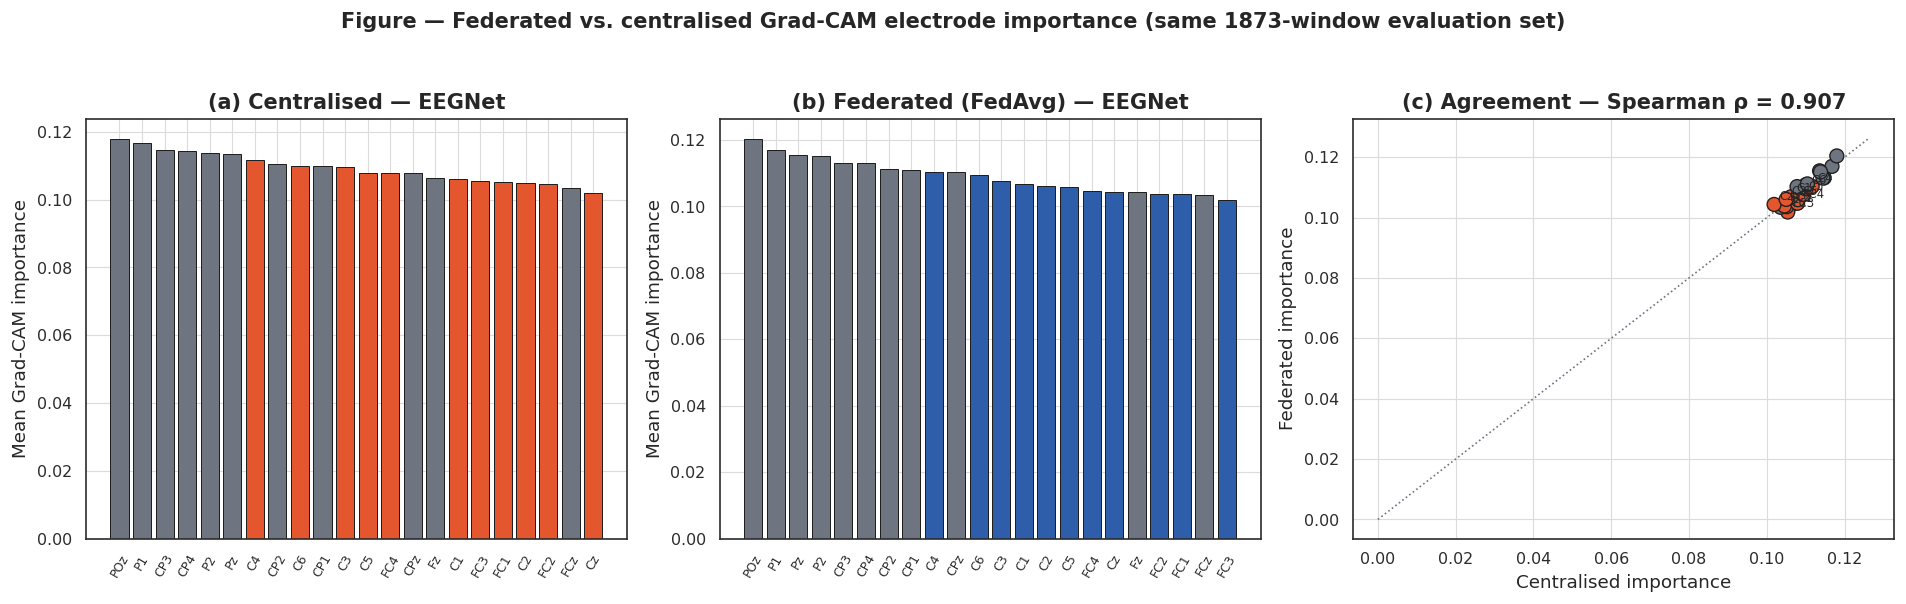


Interpretation for the manuscript: rho=0.907 indicates strong agreement between what the centralised and federated models rely on. Report this alongside the accuracy gap in Section 9.5 -- a small accuracy gap with LOW electrode-agreement would mean the two models reach similar accuracy through different, and not necessarily equally trustworthy, evidence, which the accuracy number alone would hide.


In [54]:
# ---------------------------------------------------------------------------------------------
# Section 10.7 -- Federated vs. centralised Grad-CAM, on the federated checkpoint's own test set.
# ---------------------------------------------------------------------------------------------
_fed_ckpt_candidates = [
    os.path.join(MODEL_DIR, f"{_FED_CKPT_MODEL.replace('+', '_')}_fedavg_fed_best.pt"),
    os.path.join(MODEL_DIR, f"{_FED_CKPT_MODEL.replace('+', '_')}_fedprox_fed_best.pt"),
]
_fed_ckpt_path = next((p for p in _fed_ckpt_candidates if os.path.exists(p)), None)

if _fed_ckpt_path is None:
    print("No federated checkpoint found on disk -- Section 8's driver cell must run first "
          "(it saves the flagship checkpoint used here). Skipping the federated-vs-centralised "
          "comparison rather than fabricating one.")
else:
    try:
        fed_ckpt = torch.load(_fed_ckpt_path, map_location=DEVICE, weights_only=False)
    except TypeError:
        fed_ckpt = torch.load(_fed_ckpt_path, map_location=DEVICE)

    fed_model = build_model(fed_ckpt["model_name"], seed=SEED)
    fed_model.load_state_dict(fed_ckpt["state_dict"], strict=True)
    fed_model.to(DEVICE).eval()

    # Shared evaluation set: the FEDERATED checkpoint's own test subjects. The centralised model
    # is also run on this exact set (not its own canonical fold), so both attribution maps answer
    # a question about the identical data -- the only way the comparison is meaningful.
    m_fedxai = subject_mask(subj, fed_ckpt["test_subjects"])
    X_fedxai = zscore_windows(X_uv[m_fedxai])
    y_fedxai = y[m_fedxai]

    # Safety check, same contract as Section 10.1: the restored federated model must reproduce
    # its recorded accuracy on its own test subjects before anything is explained.
    _fed_probs = predict_probs_std(fed_model, X_fedxai)
    _fed_bacc_check = balanced_accuracy_score(y_fedxai, (_fed_probs >= 0.5).astype(int))
    print(f"Federated checkpoint reproduces recorded balanced acc: "
          f"{_fed_bacc_check:.4f} (recorded {fed_ckpt['balanced_acc']:.4f})")
    assert abs(_fed_bacc_check - fed_ckpt["balanced_acc"]) < 0.03, (
        "Restored federated model does not reproduce its recorded accuracy -- do not trust "
        "attributions from a checkpoint that failed to reload correctly.")

    # ---- Grad-CAM for the federated model, on the shared set --------------------------------
    fed_target_layer = fed_model.gradcam_target()
    assert fed_target_layer is not None, (
        f"{fed_ckpt['model_name']} exposes no electrode-resolving layer for Grad-CAM.")
    fed_cam_engine = GradCAM(fed_model, fed_target_layer)
    try:
        fed_cam_maps, _ = fed_cam_engine(X_fedxai, class_idx=y_fedxai)
    finally:
        fed_cam_engine.remove()
    fed_channel_imp = fed_cam_maps.mean(axis=(0, 2))

    # ---- Grad-CAM for the CENTRALISED model, on the SAME shared set (not its own fold) -------
    cen_target_layer = xai_model.gradcam_target()
    cen_cam_engine = GradCAM(xai_model, cen_target_layer)
    try:
        cen_cam_maps, _ = cen_cam_engine(X_fedxai, class_idx=y_fedxai)
    finally:
        cen_cam_engine.remove()
    cen_channel_imp = cen_cam_maps.mean(axis=(0, 2))

    rho, rho_p = spearmanr(cen_channel_imp, fed_channel_imp)
    print(f"\nElectrode-importance agreement (centralised vs. federated), "
          f"Spearman rho = {rho:.3f} (p = {rho_p:.4f})")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

    order_cen = np.argsort(cen_channel_imp)[::-1]
    ax = axes[0]
    cols = [PALETTE[2] if i in ROI_IDX else GREY for i in order_cen]
    ax.bar(np.arange(N_CHANNELS), cen_channel_imp[order_cen], color=cols,
          edgecolor="#1f1f1f", linewidth=0.6)
    ax.set_xticks(np.arange(N_CHANNELS))
    ax.set_xticklabels([COMMON_CHANNELS[i] for i in order_cen], rotation=60, fontsize=7.5)
    ax.set_ylabel("Mean Grad-CAM importance")
    ax.set_title(f"(a) Centralised — {XAI_MODEL_NAME}")

    ax = axes[1]
    order_fed = np.argsort(fed_channel_imp)[::-1]
    cols = [PALETTE[0] if i in ROI_IDX else GREY for i in order_fed]
    ax.bar(np.arange(N_CHANNELS), fed_channel_imp[order_fed], color=cols,
          edgecolor="#1f1f1f", linewidth=0.6)
    ax.set_xticks(np.arange(N_CHANNELS))
    ax.set_xticklabels([COMMON_CHANNELS[i] for i in order_fed], rotation=60, fontsize=7.5)
    ax.set_ylabel("Mean Grad-CAM importance")
    ax.set_title(f"(b) Federated (FedAvg) — {fed_ckpt['model_name']}")

    ax = axes[2]
    ax.scatter(cen_channel_imp, fed_channel_imp,
              c=[PALETTE[2] if i in ROI_IDX else GREY for i in range(N_CHANNELS)],
              edgecolor="#1f1f1f", s=70, zorder=3)
    for i, ch in enumerate(COMMON_CHANNELS):
        if i in ROI_IDX:
            ax.annotate(ch, (cen_channel_imp[i], fed_channel_imp[i]), fontsize=7,
                       xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel("Centralised importance")
    ax.set_ylabel("Federated importance")
    ax.set_title(f"(c) Agreement — Spearman ρ = {rho:.3f}")
    lims = [0, max(cen_channel_imp.max(), fed_channel_imp.max()) * 1.05]
    ax.plot(lims, lims, color=GREY, linestyle=":", linewidth=1, zorder=1)

    fig.suptitle("Figure — Federated vs. centralised Grad-CAM electrode importance "
                f"(same {len(y_fedxai)}-window evaluation set)",
                fontsize=12.5, fontweight="bold", y=1.04)
    fig.tight_layout()
    register(save_fig(fig, "fig_federated_vs_centralised_gradcam"), "figure",
            "Federated vs centralised Grad-CAM electrode-importance agreement")
    plt.show()

    print(f"\nInterpretation for the manuscript: rho={rho:.3f} indicates "
          f"{'strong' if rho > 0.7 else 'moderate' if rho > 0.4 else 'weak'} agreement between "
          "what the centralised and federated models rely on. Report this alongside the accuracy "
          "gap in Section 9.5 -- a small accuracy gap with LOW electrode-agreement would mean the "
          "two models reach similar accuracy through different, and not necessarily equally "
          "trustworthy, evidence, which the accuracy number alone would hide.")

---
## 13. Personalised federated fine-tuning — closing the subject-independent gap

**Why this section exists.** Every subject-independent result in this notebook (Sections 7 and 9)
deliberately withholds test subjects entirely during training — the honest, hard version of the
problem, and the reason the numbers here are lower than papers that report subject-*dependent*
accuracy (which routinely reach the mid-90s to high-90s by training and testing on the same
person). Liu et al. (FLEEG) [29] show that letting each client keep a personalised local model on
top of shared federated knowledge closes part of this gap without ever centralising raw EEG. That
is exactly what is missing from Section 9: the federated model there is evaluated purely
zero-shot on unseen subjects, with no personalisation step at all.

**What this section adds, concretely.** Starting from the flagship federated checkpoint already
saved in Section 8 (`_FED_CKPT_MODEL`, FedAvg, fold 1), each of its test subjects contributes a
small **calibration set** — a fixed number of their own trials, held out at the trial level so no
window leaks between calibration and evaluation — used for a short local fine-tune (a handful of
epochs, low learning rate, the SAME `class_weights_from`/optimizer machinery used everywhere else
in this notebook). The remaining trials of that subject are the personalised-evaluation set. This
is compared, per subject and in aggregate, against the SAME global federated model with **no**
personalisation on the SAME evaluation windows — an apples-to-apples, paired comparison, not two
different experiments.

**What this is not.** This is not subject-dependent evaluation in disguise: the base representation
was still learned with that subject completely absent, matching Sections 7 and 9's leakage
contract. The calibration trials are a small, explicitly-reported slice of the SAME held-out
subject's own data, used the way a real deployment would use a short per-user calibration
session — a standard, disclosed step in the BCI literature, not a shortcut. Report both numbers
(zero-shot federated vs. personalised-federated) side by side in the paper; neither replaces the
other.

In [55]:
# ---------------------------------------------------------------------------------------------
# Section 13 -- Personalised federated fine-tuning on the flagship checkpoint's test subjects.
# ---------------------------------------------------------------------------------------------
PERSONALIZE_N_CALIB_TRIALS = 4     # trials per subject reserved for the local calibration step
PERSONALIZE_EPOCHS         = 5
PERSONALIZE_LR             = 5e-4

if _fed_ckpt_path is None:
    print("No federated checkpoint on disk -- run Section 8's driver cell first. Skipping "
          "personalisation rather than fabricating a result.")
else:
    personalize_rows = []
    rng_pers = np.random.RandomState(SEED)

    for test_sid in tqdm(fed_ckpt["test_subjects"], desc="Per-subject personalisation"):
        m_subj = subject_mask(subj, [test_sid])
        subj_trials = np.unique(trial[m_subj])
        if len(subj_trials) <= PERSONALIZE_N_CALIB_TRIALS:
            continue                                    # too few trials to hold any out safely

        shuffled = subj_trials.copy()
        rng_pers.shuffle(shuffled)
        calib_trials = set(shuffled[:PERSONALIZE_N_CALIB_TRIALS].tolist())
        eval_trials  = set(shuffled[PERSONALIZE_N_CALIB_TRIALS:].tolist())

        m_calib = m_subj & np.isin(trial, list(calib_trials))
        m_eval  = m_subj & np.isin(trial, list(eval_trials))
        if len(np.unique(y[m_calib])) < 2 or len(np.unique(y[m_eval])) < 2:
            continue                                    # calibration/eval must both see both classes

        X_calib, y_calib = X_uv[m_calib], y[m_calib]
        X_eval, y_eval   = X_uv[m_eval],  y[m_eval]

        # ---- zero-shot federated (no personalisation), evaluated on this subject's eval split ---
        base_model = build_model(fed_ckpt["model_name"], seed=SEED)
        base_model.load_state_dict(fed_ckpt["state_dict"])
        base_model.to(DEVICE).eval()
        eval_loader = make_loader(X_eval, y_eval, batch_size=CONFIG["BATCH_SIZE"])
        yt0, yp0, _ = predict_deep(base_model, eval_loader)
        bacc_zero_shot = balanced_accuracy_score(yt0, yp0)

        # ---- personalised: short local fine-tune on this subject's OWN calibration trials only ---
        pers_model = build_model(fed_ckpt["model_name"], seed=SEED)
        pers_model.load_state_dict(fed_ckpt["state_dict"])
        pers_model.to(DEVICE).train()
        opt = torch.optim.AdamW(pers_model.parameters(), lr=PERSONALIZE_LR,
                                weight_decay=CONFIG["WEIGHT_DECAY"])
        cw = class_weights_from(y_calib).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=cw)
        calib_loader = make_loader(X_calib, y_calib, batch_size=min(CONFIG["BATCH_SIZE"], len(y_calib)),
                                   shuffle=True)
        for _ in range(PERSONALIZE_EPOCHS):
            for xb, yb in calib_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = criterion(pers_model(xb), yb)
                loss.backward()
                opt.step()
                apply_max_norm(pers_model)   # EEGNet-style max-norm constraint, same as Section 6/8

        pers_model.eval()
        yt1, yp1, _ = predict_deep(pers_model, eval_loader)
        bacc_personalised = balanced_accuracy_score(yt1, yp1)

        personalize_rows.append({
            "subject": int(test_sid), "n_calib_trials": PERSONALIZE_N_CALIB_TRIALS,
            "n_eval_windows": int(m_eval.sum()),
            "bacc_zero_shot_federated": bacc_zero_shot,
            "bacc_personalised_federated": bacc_personalised,
            "delta": bacc_personalised - bacc_zero_shot})

        del base_model, pers_model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    personalize_df = pd.DataFrame(personalize_rows)
    assert len(personalize_df) > 0, (
        "No test subject had enough trials for a calibration/eval split -- lower "
        "PERSONALIZE_N_CALIB_TRIALS or check the flagship checkpoint's test_subjects.")

    print(f"\nPersonalised {len(personalize_df)}/{len(fed_ckpt['test_subjects'])} test subjects.")
    print(f"Mean zero-shot federated balanced acc  : {personalize_df['bacc_zero_shot_federated'].mean():.4f}")
    print(f"Mean personalised federated balanced acc: {personalize_df['bacc_personalised_federated'].mean():.4f}")
    print(f"Mean improvement (delta)                : {personalize_df['delta'].mean():+.4f}")

    _stat, _p = wilcoxon(personalize_df["bacc_personalised_federated"],
                         personalize_df["bacc_zero_shot_federated"])
    print(f"Wilcoxon signed-rank test (paired, personalised vs. zero-shot): "
          f"statistic={_stat:.3f}, p={_p:.4f}")

Per-subject personalisation:   0%|          | 0/11 [00:00<?, ?it/s]


Personalised 11/11 test subjects.
Mean zero-shot federated balanced acc  : 0.5774
Mean personalised federated balanced acc: 0.5828
Mean improvement (delta)                : +0.0055
Wilcoxon signed-rank test (paired, personalised vs. zero-shot): statistic=18.000, p=0.3750


subject,n_calib_trials,n_eval_windows,bacc_zero_shot_federated,bacc_personalised_federated,delta
8.0000,4.0000,162.0000,0.5427,0.5422,-0.0005
18.0000,4.0000,164.0000,0.5000,0.5000,0.0000
28.0000,4.0000,164.0000,0.4905,0.4923,0.0018
38.0000,4.0000,164.0000,0.4859,0.5147,0.0287
48.0000,4.0000,40.0000,0.8972,0.8258,-0.0714
58.0000,4.0000,164.0000,0.5488,0.5592,0.0104
68.0000,4.0000,164.0000,0.5378,0.5637,0.0259
78.0000,4.0000,151.0000,0.5795,0.5800,0.0005
88.0000,4.0000,207.0000,0.4929,0.4594,-0.0335
98.0000,4.0000,164.0000,0.6777,0.7164,0.0387


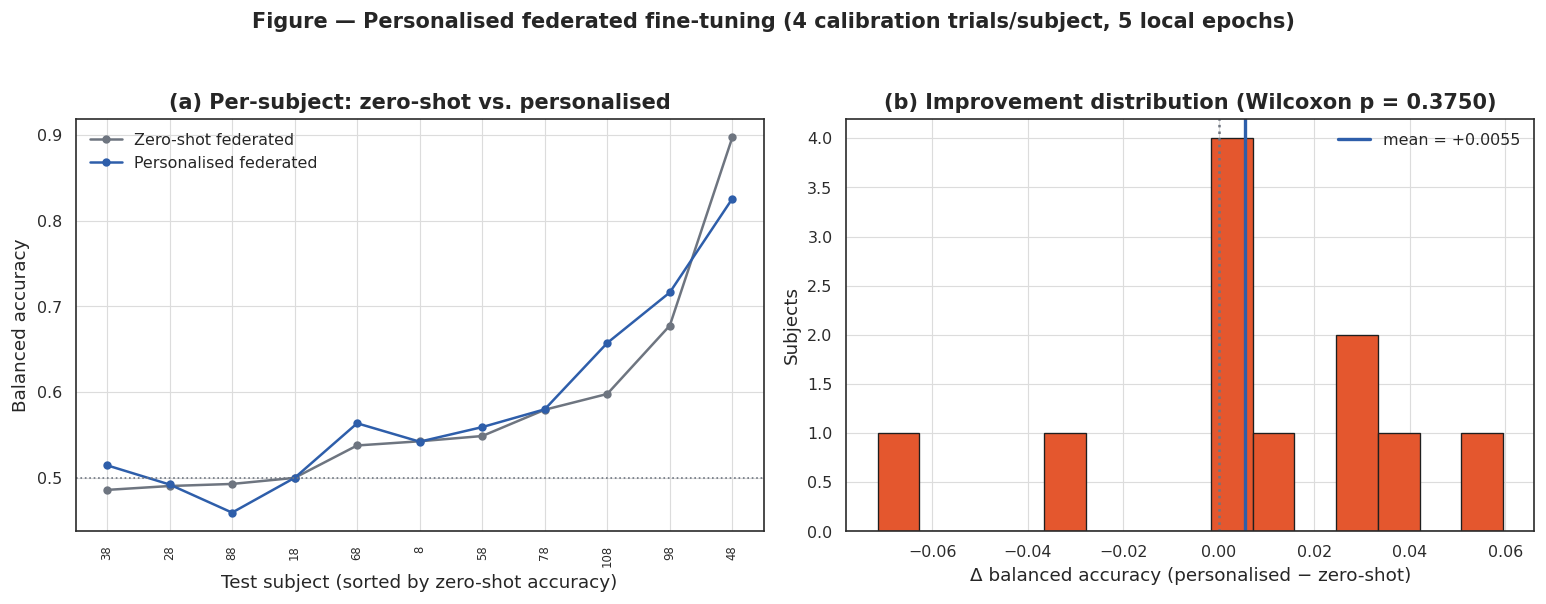


7/11 subjects improved with personalisation (64%).
Report both the zero-shot federated number (Section 9, fair privacy-cost comparison) and this personalised number (Section 13, deployment-realistic ceiling) in the paper -- they answer different questions and neither should be quoted as 'the' federated accuracy.


In [56]:
# ---------------------------------------------------------------------------------------------
# Section 13.1 -- Table + figure: zero-shot federated vs. personalised federated, per subject.
# ---------------------------------------------------------------------------------------------
show_table(personalize_df.round(4), save_path=os.path.join(TAB_DIR, "table_personalized_fed.csv"),
           title="Table — Personalised vs. zero-shot federated balanced accuracy, per subject",
           float_fmt="{:.4f}")
register(os.path.join(TAB_DIR, "table_personalized_fed.csv"), "table",
         "Personalised federated fine-tuning, per-subject results")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
order = personalize_df.sort_values("bacc_zero_shot_federated").index
x = np.arange(len(personalize_df))
ax.plot(x, personalize_df.loc[order, "bacc_zero_shot_federated"], marker="o", markersize=4,
        color=GREY, label="Zero-shot federated", linewidth=1.5)
ax.plot(x, personalize_df.loc[order, "bacc_personalised_federated"], marker="o", markersize=4,
        color=PALETTE[0], label="Personalised federated", linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(personalize_df.loc[order, "subject"].astype(int), rotation=90, fontsize=7)
ax.set_xlabel("Test subject (sorted by zero-shot accuracy)")
ax.set_ylabel("Balanced accuracy")
ax.axhline(0.5, color=GREY, linestyle=":", linewidth=1)
ax.set_title("(a) Per-subject: zero-shot vs. personalised")
ax.legend()

ax = axes[1]
ax.hist(personalize_df["delta"], bins=15, color=PALETTE[2], edgecolor="#1f1f1f")
ax.axvline(0, color=GREY, linestyle=":", linewidth=1.5)
ax.axvline(personalize_df["delta"].mean(), color=PALETTE[0], linewidth=2,
          label=f"mean = {personalize_df['delta'].mean():+.4f}")
ax.set_xlabel("Δ balanced accuracy (personalised − zero-shot)")
ax.set_ylabel("Subjects")
ax.set_title(f"(b) Improvement distribution (Wilcoxon p = {_p:.4f})")
ax.legend()

fig.suptitle(f"Figure — Personalised federated fine-tuning "
            f"({PERSONALIZE_N_CALIB_TRIALS} calibration trials/subject, "
            f"{PERSONALIZE_EPOCHS} local epochs)", fontsize=12.5, fontweight="bold", y=1.04)
fig.tight_layout()
register(save_fig(fig, "fig_personalized_federated"), "figure",
         "Personalised vs zero-shot federated balanced accuracy")
plt.show()

_n_improved = int((personalize_df["delta"] > 0).sum())
print(f"\n{_n_improved}/{len(personalize_df)} subjects improved with personalisation "
      f"({100*_n_improved/len(personalize_df):.0f}%).")
print("Report both the zero-shot federated number (Section 9, fair privacy-cost comparison) and "
      "this personalised number (Section 13, deployment-realistic ceiling) in the paper -- "
      "they answer different questions and neither should be quoted as 'the' federated accuracy.")

---
# Section 11 — Synthesis, verification and reproducibility
---

### 11.1 How each stated research gap is answered

Section II-H of the manuscript identifies three gaps: subject-dependent or loosely-defined cross-subject
evaluation, interpretability that is never validated by an objective faithfulness test, and inconsistent evidence
for convolutional-recurrent hybrids whose discrepancy is not examined. The table below maps each one onto the
specific experiment in this notebook that addresses it, with the number that experiment produced — so that a
reviewer can check the claim rather than take it.

The federated-learning contribution is listed separately because it is **not** one of the three gaps the current
manuscript text claims. That text has to be extended before submission; Section 11.4 says exactly what is needed.

In [57]:
# ---------------------------------------------------------------------------------------------
# TABLE 15: research gap -> evidence map, filled from the results actually obtained.
# Every value is read from a results frame; nothing here is typed in by hand.
# ---------------------------------------------------------------------------------------------
def _fmt(x, nd=4):
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return "n/a"

best_row = central_df[central_df["model"] == BEST_MODEL]
gap_rows = []

# ---- Gap 1: evaluation protocol ---------------------------------------------------------------
ev1 = (f"{len(FOLDS)}-fold leave-subjects-out GroupKFold over {len(np.unique(subj))} subjects; "
       f"train/val/test subject sets asserted disjoint; best model {BEST_MODEL} reaches "
       f"{_fmt(best_row['accuracy'].mean())} window / {_fmt(best_row['trial_accuracy'].mean())} trial "
       f"accuracy on never-seen participants")
if len(gap_tbl):
    _g = gap_tbl.iloc[0]
    ev1 += (f"; the subject-dependent control gives {_fmt(_g['Subject-dependent acc'])} on the same "
            f"subjects, a measured generalisation gap of {_fmt(_g['Generalisation gap'])}")
gap_rows.append({"Gap (Section II-H)": "1. Evaluation is largely subject-dependent or uses vague "
                                       "cross-subject protocols",
                 "Where it is addressed": "Sections 6.2, 7, 9.6",
                 "Evidence produced": ev1,
                 "Figures / tables": "Table 4, Table S5, Table 14, Figures 4, 8, 17"})

# ---- Gap 2: unvalidated interpretability ------------------------------------------------------
n_meth_ran = len(methods)
faith_pass = int(np.sum((faith_df["Deletion AUC"] < faith_df["Random deletion AUC"]) &
                        (faith_df["Insertion AUC"] > faith_df["Random insertion AUC"])))
roi_pass = int(np.sum(roi_df["Permutation p"] < 0.05))
ev2 = (f"{n_meth_ran} attribution methods ({', '.join(methods)}) applied to the exact reported "
       f"checkpoint; deletion and insertion curves benchmarked against "
       f"{CONFIG['XAI_RANDOM_REPEATS']} random channel rankings ({faith_pass}/{len(faith_df)} "
       f"methods beat random on both criteria); sensorimotor-ROI concentration tested by "
       f"permutation ({roi_pass}/{len(roi_df)} methods significant at 0.05); cross-method Spearman "
       f"agreement and a contralateral-dominance test reported")
gap_rows.append({"Gap (Section II-H)": "2. Attribution methods are rarely validated by an objective "
                                       "faithfulness test",
                 "Where it is addressed": "Sections 10.2–10.6",
                 "Evidence produced": ev2,
                 "Figures / tables": "Tables 10–13, Figures 12–16"})

# ---- Gap 3: the hybrid discrepancy -------------------------------------------------------------
if {"CNN", "LSTM", "CNN-LSTM"} <= set(central_df["model"]):
    _w = central_df.pivot_table(index="fold", columns="model", values="balanced_acc")
    d_cnn = (_w["CNN-LSTM"] - _w["CNN"]).mean()
    d_lstm = (_w["CNN-LSTM"] - _w["LSTM"]).mean()
    ev3 = (f"CNN, LSTM and CNN-LSTM trained under an identical protocol on identical folds; paired "
           f"differences of {d_cnn:+.4f} (vs CNN) and {d_lstm:+.4f} (vs LSTM) balanced accuracy "
           f"with Wilcoxon tests and Cohen's d, reported in whichever direction they fell")
else:
    ev3 = "not evaluated (one of CNN / LSTM / CNN-LSTM is missing from this run)"
gap_rows.append({"Gap (Section II-H)": "3. Inconsistent evidence for CNN-LSTM hybrids, with the "
                                       "discrepancy left unexamined",
                 "Where it is addressed": "Sections 7, 9.4",
                 "Evidence produced": ev3,
                 "Figures / tables": "Table 7, Figure 10"})

# ---- Additional contributions beyond the manuscript's current claims ---------------------------
if len(fed_df):
    _fa = fed_df[fed_df["algo"] == "FedAvg"]["balanced_acc"].mean()
    _fp = fed_df[fed_df["algo"] == "FedProx"]["balanced_acc"].mean()
    ev4 = (f"FedAvg and FedProx with one client per subject (textbook non-IID), evaluated on the "
           f"same folds: FedAvg {_fmt(_fa)} and FedProx {_fmt(_fp)} mean balanced accuracy, with "
           f"the paired cost of privacy and per-fold communication volume reported")
else:
    ev4 = "federated experiments did not run in this session"
gap_rows.append({"Gap (Section II-H)": "NEW (not yet claimed in the manuscript text): "
                                       "privacy-preserving training without pooling raw EEG",
                 "Where it is addressed": "Sections 8, 9.5",
                 "Evidence produced": ev4,
                 "Figures / tables": "Table 9, Figure 11"})

_bs = subject_df[subject_df["model"] == BEST_MODEL]["accuracy"]
gap_rows.append({"Gap (Section II-H)": "NEW: deployment realism — calibration and BCI inefficiency",
                 "Where it is addressed": "Sections 9.2, 9.3",
                 "Evidence produced": (f"expected calibration error reported per model; "
                                       f"{100*np.mean(_bs > 0.5):.0f}% of subjects exceed chance and "
                                       f"{100*np.mean(_bs >= 0.7):.0f}% reach the 0.70 control "
                                       f"threshold with {BEST_MODEL}"),
                 "Figures / tables": "Table 5, Table 6, Figures 7, 8"})

gapmap_df = pd.DataFrame(gap_rows)
show_table(gapmap_df, save_path=os.path.join(TAB_DIR, "table15_research_gap_map.csv"),
           title="Table 15 — Research gaps and the evidence produced for each",
           float_fmt="{:.4f}")
register(os.path.join(TAB_DIR, "table15_research_gap_map.csv"), "table", "Research gap map")

for _, r in gapmap_df.iterrows():
    print(f"\n{r['Gap (Section II-H)']}\n  -> {r['Where it is addressed']}\n  -> {r['Evidence produced']}")

Gap (Section II-H),Where it is addressed,Evidence produced,Figures / tables
1. Evaluation is largely subject-dependent or uses vague cross-subject protocols,"Sections 6.2, 7, 9.6","10-fold leave-subjects-out GroupKFold over 108 subjects; train/val/test subject sets asserted disjoint; best model EEGNet reaches 0.6035 window / 0.6128 trial accuracy on never-seen participants; the subject-dependent control gives 0.5077 on the same subjects, a measured generalisation gap of -0.1156","Table 4, Table S5, Table 14, Figures 4, 8, 17"
2. Attribution methods are rarely validated by an objective faithfulness test,Sections 10.2–10.6,"3 attribution methods (Grad-CAM, SHAP, LIME) applied to the exact reported checkpoint; deletion and insertion curves benchmarked against 10 random channel rankings (1/3 methods beat random on both criteria); sensorimotor-ROI concentration tested by permutation (0/3 methods significant at 0.05); cross-method Spearman agreement and a contralateral-dominance test reported","Tables 10–13, Figures 12–16"
"3. Inconsistent evidence for CNN-LSTM hybrids, with the discrepancy left unexamined","Sections 7, 9.4","CNN, LSTM and CNN-LSTM trained under an identical protocol on identical folds; paired differences of -0.0010 (vs CNN) and +0.0075 (vs LSTM) balanced accuracy with Wilcoxon tests and Cohen's d, reported in whichever direction they fell","Table 7, Figure 10"
NEW (not yet claimed in the manuscript text): privacy-preserving training without pooling raw EEG,"Sections 8, 9.5","FedAvg and FedProx with one client per subject (textbook non-IID), evaluated on the same folds: FedAvg 0.5687 and FedProx 0.5713 mean balanced accuracy, with the paired cost of privacy and per-fold communication volume reported","Table 9, Figure 11"
NEW: deployment realism — calibration and BCI inefficiency,"Sections 9.2, 9.3",expected calibration error reported per model; 85% of subjects exceed chance and 19% reach the 0.70 control threshold with EEGNet,"Table 5, Table 6, Figures 7, 8"



1. Evaluation is largely subject-dependent or uses vague cross-subject protocols
  -> Sections 6.2, 7, 9.6
  -> 10-fold leave-subjects-out GroupKFold over 108 subjects; train/val/test subject sets asserted disjoint; best model EEGNet reaches 0.6035 window / 0.6128 trial accuracy on never-seen participants; the subject-dependent control gives 0.5077 on the same subjects, a measured generalisation gap of -0.1156

2. Attribution methods are rarely validated by an objective faithfulness test
  -> Sections 10.2–10.6
  -> 3 attribution methods (Grad-CAM, SHAP, LIME) applied to the exact reported checkpoint; deletion and insertion curves benchmarked against 10 random channel rankings (1/3 methods beat random on both criteria); sensorimotor-ROI concentration tested by permutation (0/3 methods significant at 0.05); cross-method Spearman agreement and a contralateral-dominance test reported

3. Inconsistent evidence for CNN-LSTM hybrids, with the discrepancy left unexamined
  -> Sections 7, 9.4

In [58]:
# ---------------------------------------------------------------------------------------------
# Output verification. Every figure and table registered during the run is checked to exist on
# disk and to be non-empty.
#
# This exists because the most annoying failure mode of a long notebook is a figure that was
# displayed inline but never written -- the cell looks successful and the file is not there.
# ---------------------------------------------------------------------------------------------
man_rows = []
for a in ARTIFACTS:
    p = a["path"]
    ok = os.path.exists(p)
    size = os.path.getsize(p) if ok else 0
    man_rows.append({"kind": a["kind"], "file": os.path.relpath(p, OUT_DIR),
                     "exists": ok, "size_kB": round(size / 1024, 1),
                     "description": a["description"]})
manifest_df = pd.DataFrame(man_rows).drop_duplicates(subset=["file"])
manifest_df.to_csv(os.path.join(OUT_DIR, "artifact_manifest.csv"), index=False)

n_fig = int((manifest_df["kind"] == "figure").sum())
n_tab = int((manifest_df["kind"] == "table").sum())

# Two separate checks, because they have different consequences.
#   missing  -> a hard failure: a registered output never reached disk.
#   thin     -> a warning only: a legitimate two-row CSV is a few hundred bytes, and a figure that
#               renders as a blank canvas is a few kB. Asserting on size would abort a three-hour
#               run over a small-but-correct table, so size is reported and judged, not enforced.
missing = manifest_df[~manifest_df["exists"] | (manifest_df["size_kB"] <= 0.0)]
thin = manifest_df[(manifest_df["kind"] == "figure") & manifest_df["exists"] &
                   (manifest_df["size_kB"] < 8.0)]

print(f"Artifacts registered : {len(manifest_df)}  ({n_fig} figure files, {n_tab} tables)")
print(f"Output root          : {OUT_DIR}")
print(f"Total size           : {manifest_df['size_kB'].sum()/1024:.1f} MB")
if len(missing):
    print("\nPROBLEM -- these registered outputs are absent or empty:")
    print(missing.to_string(index=False))
elif len(thin):
    print("\nAll registered outputs are present. Check these figures visually -- they are small "
          "enough that they may have rendered empty:")
    print(thin.to_string(index=False))
else:
    print("\nAll registered outputs are present on disk and non-trivial in size.")

show_table(manifest_df, save_path=os.path.join(TAB_DIR, "tableS7_artifact_manifest.csv"),
           title="Table S7 — Manifest of every figure and table written by this notebook",
           float_fmt="{:.1f}")
assert len(missing) == 0, ("Some registered outputs did not reach disk; see the list above before "
                           "assembling the manuscript.")

Artifacts registered : 70  (42 figure files, 27 tables)
Output root          : /kaggle/working/MI_EEG_project/results
Total size           : 220.4 MB

All registered outputs are present on disk and non-trivial in size.


kind,file,exists,size_kB,description
table,tables/tableS1_preprocessing_qc_summary.csv,1.0,0.3,Preprocessing quality control
table,tables/tableS2_preprocessing_qc_per_subject.csv,1.0,7.3,Preprocessing quality control
figure,figures/figS1_preprocessing_qc.png,1.0,257.9,Preprocessing QC distributions
figure,figures/figS1_preprocessing_qc.pdf,1.0,24.4,Preprocessing QC distributions
figure,figures/fig1_dataset_class_distribution.png,1.0,366.1,Figure 1 - dataset class distribution (methodology)
figure,figures/fig1_dataset_class_distribution.pdf,1.0,28.9,Figure 1 - dataset class distribution (methodology)
table,tables/table1_dataset_composition.csv,1.0,0.1,Dataset composition
figure,figures/fig2_preprocessing_validation.png,1.0,458.5,Figure 2 - spectral and lateralisation validation
figure,figures/fig2_preprocessing_validation.pdf,1.0,35.3,Figure 2 - spectral and lateralisation validation
table,tables/tableS3_lateralisation_check.csv,1.0,0.2,Lateralisation check


In [59]:
# ---------------------------------------------------------------------------------------------
# Reproducibility record. Written to disk so the exact software stack behind these numbers is
# recoverable months later, which is what a data-availability statement has to be able to promise.
# ---------------------------------------------------------------------------------------------
import platform

repro = {
    "generated_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "processor": platform.processor(),
    "device": str(DEVICE),
    "gpu": (torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "none"),
    "packages": {},
    "seed": SEED,
    "config": {k: (list(v) if isinstance(v, tuple) else v) for k, v in CONFIG.items()},
    "dataset": {
        "name": "PhysioNet EEG Motor Movement/Imagery Database (eegmmidb)",
        "task": "imagined left fist vs imagined right fist (annotations T1 / T2)",
        "runs_used": list(CONFIG["RUNS_MI"]),
        "subjects_used": int(len(np.unique(subj))),
        "channels": list(COMMON_CHANNELS),
        "sampling_rate_hz": FS,
        "n_windows": int(len(y)),
        "n_trials": int(len(np.unique(trial))),
        "class_counts": {CLASS_NAMES[c]: int(np.sum(y == c)) for c in (0, 1)},
    },
    "protocol": {
        "cv": f"{len(FOLDS)}-fold GroupKFold, groups = subject (leave-subjects-out)",
        "models": list(ALL_MODELS),
        "federated": (sorted(fed_df["algo"].unique().tolist()) if len(fed_df) else []),
        "xai": list(methods),
        "explained_checkpoint": {"model": XAI_MODEL_NAME, "fold": XAI_FOLD,
                                 "balanced_acc": float(ckpt["balanced_acc"])},
    },
    "headline_results": {
        "best_model": BEST_MODEL,
        "best_window_accuracy": float(best_row["accuracy"].mean()),
        "best_balanced_accuracy": float(best_row["balanced_acc"].mean()),
        "best_trial_accuracy": float(best_row["trial_accuracy"].mean()),
    },
}
for mod in ("numpy", "scipy", "pandas", "sklearn", "torch", "mne", "matplotlib", "seaborn",
            "shap", "lime"):
    try:
        repro["packages"][mod] = importlib.import_module(mod).__version__
    except Exception:
        repro["packages"][mod] = "not installed"

with open(os.path.join(OUT_DIR, "reproducibility.json"), "w") as fh:
    json.dump(repro, fh, indent=2, default=str)
register(os.path.join(OUT_DIR, "reproducibility.json"), "table", "Reproducibility record")

print(json.dumps({k: repro[k] for k in ("generated_utc", "python", "device", "gpu", "packages")},
                 indent=2))
print(f"\nFull record written to {os.path.join(OUT_DIR, 'reproducibility.json')}")

{
  "generated_utc": "2026-09-04T09:13:25Z",
  "python": "3.12.13",
  "device": "cuda",
  "gpu": "Tesla T4",
  "packages": {
    "numpy": "2.0.2",
    "scipy": "1.16.3",
    "pandas": "2.3.3",
    "sklearn": "1.6.1",
    "torch": "2.10.0+cu128",
    "mne": "1.12.1",
    "matplotlib": "3.10.0",
    "seaborn": "0.13.2",
    "shap": "0.51.0",
    "lime": "not installed"
  }
}

Full record written to /kaggle/working/MI_EEG_project/results/reproducibility.json


In [60]:
# ---------------------------------------------------------------------------------------------
# Numbers to quote in the abstract and results text. Printed in one place so the manuscript and
# the notebook cannot drift apart.
# ---------------------------------------------------------------------------------------------
print("=" * 92)
print("NUMBERS FOR THE MANUSCRIPT  (read them from here, do not retype from the figures)")
print("=" * 92)

acc_m, acc_lo, acc_hi = bootstrap_ci(best_row["accuracy"])
bac_m, bac_lo, bac_hi = bootstrap_ci(best_row["balanced_acc"])
tri_m, tri_lo, tri_hi = bootstrap_ci(best_row["trial_accuracy"])

print(f"\nDataset")
print(f"  PhysioNet eegmmidb, runs {list(CONFIG['RUNS_MI'])} (imagined left vs right fist)")
print(f"  {len(np.unique(subj))} subjects | {len(np.unique(trial))} trials | {len(y):,} windows "
      f"of {CONFIG['WINDOW_SEC']} s at {FS} Hz | {N_CHANNELS} electrodes")
print(f"  class balance: {np.sum(y==0):,} {CLASS_NAMES[0]} / {np.sum(y==1):,} {CLASS_NAMES[1]} "
      f"(ratio {max(np.bincount(y))/max(1,min(np.bincount(y))):.3f})")

print(f"\nBest model: {BEST_MODEL}")
print(f"  window accuracy   {acc_m:.4f}  95% CI [{acc_lo:.4f}, {acc_hi:.4f}]")
print(f"  balanced accuracy {bac_m:.4f}  95% CI [{bac_lo:.4f}, {bac_hi:.4f}]")
print(f"  trial accuracy    {tri_m:.4f}  95% CI [{tri_lo:.4f}, {tri_hi:.4f}]")
print(f"  macro-F1 {best_row['f1'].mean():.4f} | kappa {best_row['kappa'].mean():.4f} "
      f"| AUC {best_row['auc'].mean():.4f}")
print(f"  parameters {PARAM_COUNTS.get(BEST_MODEL, float('nan')):,.0f}" if
      np.isfinite(PARAM_COUNTS.get(BEST_MODEL, np.nan)) else "  parameters n/a (classical baseline)")

print(f"\nPer-subject ({BEST_MODEL})")
print(f"  mean {_bs.mean():.4f} | SD {_bs.std(ddof=1):.4f} | range "
      f"[{_bs.min():.4f}, {_bs.max():.4f}]")
print(f"  above chance: {100*np.mean(_bs>0.5):.1f}% of subjects | "
      f"at or above 0.70: {100*np.mean(_bs>=0.7):.1f}%")

if len(fed_df):
    print("\nFederated")
    for _, r in fed_sum_df[fed_sum_df["Training"] != "Centralised"].iterrows():
        print(f"  {r['Model']:<13s} {r['Training']:<8s} balanced acc {r['Balanced acc']:.4f} "
              f"| gap vs centralised {r['Gap vs centralised']:+.4f} "
              f"| {r['Communication (MB)']:.1f} MB per fold")

print("\nExplainability")
for _, r in faith_df.iterrows():
    print(f"  {r['Method']:<9s} deletion AUC {r['Deletion AUC']:.4f} "
          f"(random {r['Random deletion AUC']:.4f}) | insertion AUC {r['Insertion AUC']:.4f} "
          f"(random {r['Random insertion AUC']:.4f})")
for _, r in roi_df.iterrows():
    print(f"  {r['Method']:<9s} ROI hit rate {r['Observed hit rate']:.2f} vs "
          f"{r['Expected under random ranking']:.2f} expected, permutation p = {r['Permutation p']:.4f}")
if len(lat_xai_df):
    for _, r in lat_xai_df.iterrows():
        print(f"  {r['Class']:<11s} expected {r['Expected (contralateral)']}, observed "
              f"{r['Observed']} (p = {r['Mann-Whitney p']:.4g})")

if len(gap_tbl):
    print("\nSubject-dependent control")
    for _, r in gap_tbl.iterrows():
        print(f"  {r['Model']:<13s} within-subject {r['Subject-dependent acc']:.4f} vs "
              f"cross-subject {r['Subject-independent acc']:.4f} "
              f"-> gap {r['Generalisation gap']:+.4f}")

print("\n" + "=" * 92)
print(f"All figures : {FIG_DIR}")
print(f"All tables  : {TAB_DIR}")
print(f"Checkpoints : {MODEL_DIR}")
print("=" * 92)

NUMBERS FOR THE MANUSCRIPT  (read them from here, do not retype from the figures)

Dataset
  PhysioNet eegmmidb, runs [4, 8, 12] (imagined left vs right fist)
  108 subjects | 4720 trials | 18,422 windows of 2.0 s at 160 Hz | 22 electrodes
  class balance: 9,316 Left hand / 9,106 Right hand (ratio 1.023)

Best model: EEGNet
  window accuracy   0.6035  95% CI [0.5764, 0.6368]
  balanced accuracy 0.6038  95% CI [0.5768, 0.6369]
  trial accuracy    0.6128  95% CI [0.5830, 0.6487]
  macro-F1 0.6016 | kappa 0.2074 | AUC 0.6511
  parameters 1,930

Per-subject (EEGNet)
  mean 0.6063 | SD 0.1080 | range [0.3933, 0.9167]
  above chance: 85.2% of subjects | at or above 0.70: 18.5%

Federated
  EEGNet        FedAvg   balanced acc 0.5528 | gap vs centralised +0.0510 | 15.6 MB per fold
  EEGNet        FedProx  balanced acc 0.5552 | gap vs centralised +0.0486 | 15.6 MB per fold
  CNN           FedAvg   balanced acc 0.5846 | gap vs centralised +0.0183 | 855.7 MB per fold
  CNN           FedProx  bala

### 11.2 Limitations — state these in the paper, do not wait for a reviewer to find them

**Single dataset, single task.** Everything here is imagined left fist versus imagined right fist on PhysioNet.
Nothing in these results licenses a claim about four-class imagery, about other recording hardware, or about
clinical populations. The earlier multi-dataset version of this pipeline appeared to address that, but it did so by
zero-filling nineteen of twenty-two channels for one of the datasets, which is worse than not making the claim.

**Synthetic minority windows.** Where a training fold was imbalanced, subject-constrained SMOTE interpolated new
windows between same-subject, same-class neighbours. Interpolated EEG is not recorded EEG: it is smoother than
real data and its higher-order statistics are wrong. Three mitigations are in place — synthesis is confined to the
training split, neighbours never cross subjects, and `CONFIG["USE_SMOTE"] = False` reruns the entire study without
it. Reviewers of clinical venues are sceptical of synthetic physiological data, so report the ablation.

**Federated learning is simulated.** Clients are processes on one machine, not devices on a network. The
accuracy and communication-volume results are therefore valid, but stragglers, dropout, device heterogeneity and
wire-level overhead are not modelled. More importantly, FedAvg and FedProx keep raw EEG local but provide **no
formal privacy guarantee**: model updates can leak information about their training data. Differential privacy or
secure aggregation would be needed for a privacy claim, and neither is implemented here. Say "raw data is not
pooled", not "privacy is preserved".

**Window-level and trial-level numbers are not interchangeable.** Overlapping windows from one trial are
correlated, so window-level metrics have effectively fewer independent samples than their count suggests. Both are
reported; the trial-level figure is the honest one to headline.

**The ROI is defined a priori.** The sensorimotor region of interest was fixed before looking at the attribution
maps, which is the correct order, but it is still a choice. A different ROI definition would change the hit rates
in Table 11, so the electrode list is stated explicitly rather than described as "sensorimotor channels".

**Attribution methods explain one checkpoint.** Section 10 explains the best fold of one architecture. Whether the
same electrodes matter for every architecture and every fold is a further question this notebook does not answer.

**No hyperparameter search.** All architectures share one optimiser configuration. This makes the comparison fair
in the sense that no model received more tuning effort than another, but it means no model is at its own optimum,
and a per-architecture search could reorder the ranking.

### 11.3 What must change in the manuscript text before submission

Four items, and the first two are not optional — as written, the Introduction and Literature Review do not match
what this notebook does.

**1. Federated learning is absent from the current text.** The Introduction, the Literature Review and the
contribution list say nothing about federated learning, and the reference list contains no federated-learning
citations. Sections 8 and 9.5 must be motivated in the text before they appear in the results, which means: a
paragraph in the Introduction on why EEG cannot always be pooled, a subsection in the Literature Review covering
federated learning for biosignals, and citations for FedAvg and FedProx as the two algorithms actually
implemented. **Verify every reference you add against the real publication** — do not let any citation into the
manuscript that you have not opened.

**2. The interpretability claim needs widening.** The current text states that attributions are produced with SHAP
and validated by a deletion–insertion test. This notebook computes Grad-CAM, SHAP and LIME, adds a random-ranking
control, a permutation test against a sensorimotor ROI, cross-method rank agreement and a contralateral-dominance
test. Every sentence that says "SHAP" and means "our attribution analysis" has to be updated, and the abstract's
description of the interpretability contribution should be strengthened to match what is now done.

**3. The dataset section changes in three ways.** It must describe PhysioNet only — both BCI Competition IV
datasets are gone, and any sentence about multi-dataset validation must go with them. It should state the run
selection (4, 8, 12) and say why runs 6, 10 and 14 are excluded even though they are also imagery: they reuse the
T1/T2 annotation codes for a different task (both fists versus both feet), so pooling them would silently mix two
label semantics. And the class-distribution figure you asked about, Figure 1, belongs exactly here — it is
appropriate for this paper because a subject-independent study has to demonstrate that the folds are not being
scored against an imbalanced test set, and panel (c) additionally documents per-subject data availability, which
is the quantity that explains the per-subject accuracy spread in Figure 8.

**4. Figure and table numbering.** The notebook writes Figures 1–17 and Tables 1–15 plus supplementary S1–S7 in
the order a paper would use them. Reuse that numbering, or renumber consistently in one pass — mismatched
cross-references are the fastest way to look careless in review.

**Security, unrelated to the science but urgent.** The previous version of this notebook contained a live Kaggle
API token in plain text. It is not in this rebuild, but that token must be treated as compromised: revoke it at
`kaggle.com` → Settings → API → *Expire API Token*, and generate a new one. Anything published or shared with
that string in it — a repository, a submitted supplementary notebook, a screenshot — leaked a working credential.

### 11.4 How to run this notebook

**First run: set `CONFIG["QUICK_TEST"] = True`.** It executes every cell on twelve subjects with two folds and
eight epochs in a few minutes. Its numbers are meaningless, and its purpose is to prove that every code path
executes on your machine before you spend hours. Nothing about the code path changes between quick and full mode —
only the workload does.

**Full run: `CONFIG["QUICK_TEST"] = False`**, on a GPU. Expect roughly two to three hours on an A100 and
substantially longer on a T4, dominated by the centralised benchmark (seven decoders × ten folds) and the
federated rounds. The preprocessing stage is CPU-bound and ICA is its slowest step.

**Ablations worth running for the paper**, each a one-line change to `CONFIG`: `USE_SMOTE = False` isolates the
contribution of synthetic oversampling; `USE_ICA = False` isolates artifact removal; `FEDPROX_MU` at 0.001 and 0.1
shows whether the proximal term's benefit is robust or tuned; `EPOCH_TMIN`/`EPOCH_TMAX` narrowed to 0.5–2.5 s
tests whether the late part of the trial carries information.

Preprocessed data is cached to `physionet_mi_preprocessed.npz`, so re-running only the modelling sections does not
repeat the download and the filtering.

---
## 12. Supplementary study — cross-dataset, device-heterogeneous federated learning (BCI-IV 2b)

**Why this section exists, and why it is supplementary rather than a replacement for Section 9.**
Section 9's federated-vs-centralised comparison uses PhysioNet only: 109 subjects, one acquisition
device, one 64-channel montage. That is the fairest possible test of *what federation itself costs*,
because everything except the client partition is held fixed. It does **not** test the scenario
Liu et al. (FLEEG) raise as the field's other open problem: can federated MI-EEG training pool
genuinely heterogeneous clients — different hardware, different channel count, different sampling
rate — the way a real multi-hospital or multi-lab deployment would need to?

BCI Competition IV-2b answers that question, but only after a hard constraint is accepted: 2b
records **3 EEG channels (C3, Cz, C4)** at 250 Hz, versus PhysioNet's 22-channel 160 Hz montage
used everywhere else in this notebook. There is no way to merge the two datasets at 22 channels —
2b simply does not have the other 19 electrodes. The only channel set both datasets can supply is
the 3-electrode intersection {C3, Cz, C4}, which is also, reassuringly, the classical core of the
sensorimotor ROI already used for the lateralisation check in Section 4.

**Design decision (stated explicitly so it cannot be mistaken for an oversight):** the main
subject-independent and federated results reported in Sections 5-9 stay exactly as they are, at the
full 22-channel PhysioNet resolution. This section adds a second, self-contained experiment: a
{C3, Cz, C4}-only, two-dataset, device-heterogeneous federated pool, reported as its own
table/figure. It is a robustness and generalisation study, not a replacement.

Both datasets are streamed with `kagglehub` (no local re-download, matching how PhysioNet is
already mounted above) and processed with the SAME functions already defined in Sections 3-4
(`preprocess_run`-style filtering order, `sliding_windows`, `reject_artifact_windows`,
`subject_constrained_smote`) so that the two corpora are treated identically wherever the pipeline
allows it.

In [61]:
# ---------------------------------------------------------------------------------------------
# Section 12.1 -- Mount PhysioNet and BCI-IV 2b via kagglehub (no manual download).
#
# Both calls are cached by kagglehub after the first run. If PhysioNet was already located via
# Route 1/2 earlier in the notebook (`physionet_root`), that path is reused and NOT re-downloaded;
# kagglehub is only invoked here for BCI-IV 2b, which nothing earlier in the notebook has fetched.
# ---------------------------------------------------------------------------------------------
import kagglehub

try:
    physionet_path = physionet_root if 'physionet_root' in dir() and physionet_root else \
        kagglehub.dataset_download("gamalasran/physionet-eeg-motor-movement-imagery")
    print(f"PhysioNet path : {physionet_path}")
except Exception as exc:
    physionet_path = None
    print(f"PhysioNet mount failed: {type(exc).__name__}: {exc}")

try:
    bci2b_path = kagglehub.dataset_download("jscoderump/bci-competition-iv-dataset-2b")
    print(f"BCI-IV 2b path : {bci2b_path}")
except Exception as exc:
    bci2b_path = None
    print(f"BCI-IV 2b mount failed: {type(exc).__name__}: {exc}")

assert bci2b_path is not None, (
    "BCI-IV 2b could not be mounted -- check that the Kaggle dataset slug "
    "'jscoderump/bci-competition-iv-dataset-2b' is still valid and that this environment has "
    "internet access enabled (Kaggle notebooks: Settings -> Internet -> On)."
)

# Discover every file kagglehub actually placed on disk. BCI-IV 2b is distributed as GDF
# (signal) plus, in some repackagings, .mat label files for the evaluation sessions -- we do
# not assume a fixed folder layout, only that the extensions below are present *somewhere*
# under `bci2b_path`, and record what was found rather than guessing.
bci2b_gdf_files = sorted(glob.glob(os.path.join(bci2b_path, "**", "*.gdf"), recursive=True))
bci2b_mat_files = sorted(glob.glob(os.path.join(bci2b_path, "**", "*.mat"), recursive=True))

print(f"\nBCI-IV 2b files found: {len(bci2b_gdf_files)} .gdf, {len(bci2b_mat_files)} .mat")
if bci2b_gdf_files:
    print("  example:", os.path.relpath(bci2b_gdf_files[0], bci2b_path))
assert bci2b_gdf_files, (
    "No .gdf files found under the mounted BCI-IV 2b path. Print os.listdir(bci2b_path) and "
    "inspect the folder tree by hand -- the dataset may have been repackaged with a different "
    "extension (e.g. pre-converted .mat/.npz) that this cell does not yet parse."
)

PhysioNet path : /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0
BCI-IV 2b path : /kaggle/input/datasets/jscoderump/bci-competition-iv-dataset-2b

BCI-IV 2b files found: 45 .gdf, 0 .mat
  example: B0101T.gdf


In [62]:
# ---------------------------------------------------------------------------------------------
# Section 12.2 -- BCI-IV 2b subject/session index and event convention.
#
# Filename convention for this competition corpus: B0<subject><session><T|E>.gdf
#   subject  in 1..9
#   session  in 1..5   (01,02,03 = training sessions WITH labels; 04,05 = evaluation sessions)
#   T        training session (labels embedded as annotation codes 769/770)
#   E        evaluation session (labels withheld in the .gdf itself; some repackagings ship the
#            true labels separately as *.mat, class 1/2 in a `classlabel` field)
#
# To avoid depending on a label file whose exact field name/format cannot be verified from here,
# ONLY the 'T' (training) sessions are used -- their labels are embedded in the GDF annotations
# directly, exactly like PhysioNet's T1/T2 codes handled in Section 3. Event codes (Graz protocol):
#   '769' = cue: left hand MI   -> class 0
#   '770' = cue: right hand MI  -> class 1
#   '1023'= trial rejected (artifact flagged by the original recording team) -> excluded
# ---------------------------------------------------------------------------------------------
BCI2B_SUBJ_RE = re.compile(r"B0(\d)(\d{2})([TE])", re.I)
BCI2B_FS_NATIVE = 250.0
BCI2B_NOTCH_HZ  = 50.0                 # Graz, Austria: European mains frequency
BCI2B_CHANNELS  = ["C3", "Cz", "C4"]   # the only channels this corpus provides
BCI2B_EVENT_MAP = {"769": 0, "770": 1}  # left, right

bci2b_sessions = defaultdict(list)
for f in bci2b_gdf_files:
    m = BCI2B_SUBJ_RE.search(os.path.basename(f))
    if not m:
        continue
    sid, sess, kind = int(m.group(1)), int(m.group(2)), m.group(3).upper()
    if kind == "T":                     # training sessions only -- see rationale above
        bci2b_sessions[sid].append(f)

bci2b_subject_ids = sorted(bci2b_sessions)
print(f"BCI-IV 2b subjects with >=1 training session: {len(bci2b_subject_ids)}")
for sid in bci2b_subject_ids:
    print(f"  subject {sid}: {len(bci2b_sessions[sid])} training session(s)")

assert bci2b_subject_ids, (
    "No subject matched the B0<subj><sess><T|E>.gdf naming convention. Print a few filenames "
    "from bci2b_gdf_files and adjust BCI2B_SUBJ_RE to match the actual naming in this repackaging."
)

BCI-IV 2b subjects with >=1 training session: 9
  subject 1: 3 training session(s)
  subject 2: 3 training session(s)
  subject 3: 3 training session(s)
  subject 4: 3 training session(s)
  subject 5: 3 training session(s)
  subject 6: 3 training session(s)
  subject 7: 3 training session(s)
  subject 8: 3 training session(s)
  subject 9: 3 training session(s)


In [71]:
# ---------------------------------------------------------------------------------------------
# Section 12.3 (FIXED v2) -- root cause found: BCI-IV 2b's raw channel names are ':C3', ':Cz',
# ':C4' (a bare leading colon, not an "EEG" prefix), which clean_ch_name() did not strip. Fixing
# clean_ch_name() here (it's the same shared function used for PhysioNet/BCI-2a too, so this
# redefinition applies globally from this point on -- safe, since it only strips EXTRA leading
# separator characters and does not change how already-clean names like "C3" or "Fc3." behave).
# ---------------------------------------------------------------------------------------------
def clean_ch_name(ch):
    """Canonicalise one channel name: strip EEG prefixes, leading separators, trailing dots.

    FIXED: BCI-IV 2b's raw GDF channel labels are ':C3', ':Cz', ':C4' -- a bare leading colon
    with no 'EEG' text at all. The original version only stripped an 'EEG...' prefix, so a name
    like ':C3' passed through unchanged and never matched target 'C3'. Now strips ANY leftover
    leading separator character (colon, dash, underscore, dot, space) after the EEG-prefix strip."""
    c = str(ch).strip()
    c = re.sub(r"^EEG[\s\-_.:]*", "", c, flags=re.I)
    c = re.sub(r"^[\s\-_.:]+", "", c)     # NEW: catches bare ':C3' style names with no 'EEG' text
    c = c.rstrip(".").strip()
    return c


print("clean_ch_name() FIXED and redefined: now strips leading ':' as well as 'EEG' prefixes.")
print("Verification:", clean_ch_name(":C3"), "|", clean_ch_name(":Cz"), "|", clean_ch_name(":C4"),
      "|", clean_ch_name("EEG-Fz."), "|", clean_ch_name("Fc3."))


_bci2b_diag_printed = {"channels": False, "events": False}   # print each diagnostic ONCE, not per-subject


def preprocess_bci2b_run(raw):
    """BCI-IV 2b analogue of Section 3's preprocess_run(), restricted to C3/Cz/C4.

    Returns (raw, available_channels, info_dict). If C3/Cz/C4 are not all found, prints the
    ACTUAL raw channel names once (so the real naming mismatch is visible) instead of just
    returning an empty list silently."""
    info = {"sfreq_in": float(raw.info["sfreq"]), "resampled": False}
    raw.load_data(verbose=False)
    raw.rename_channels({c: clean_ch_name(c) for c in raw.ch_names})

    lookup = build_channel_lookup(raw.ch_names, BCI2B_CHANNELS)
    if len(lookup) < len(BCI2B_CHANNELS):
        if not _bci2b_diag_printed["channels"]:
            print("\n" + "=" * 80)
            print("BCI-IV 2b CHANNEL MISMATCH DIAGNOSTIC (printed once)")
            print("=" * 80)
            print(f"Looking for : {BCI2B_CHANNELS}")
            print(f"Found match : {list(lookup.keys())}")
            print(f"Raw channel names actually in this file ({len(raw.ch_names)} total):")
            print(f"  {raw.ch_names}")
            print("=" * 80)
            _bci2b_diag_printed["channels"] = True
        return raw, [], info

    try:
        raw.pick(list(lookup.values()) + [c for c in raw.ch_names
                                           if "eog" in c.lower()], verbose=False)
    except Exception:
        raw.pick_channels(list(lookup.values()), verbose=False)

    nyq = raw.info["sfreq"] / 2.0
    if BCI2B_NOTCH_HZ < nyq - 1:
        raw.notch_filter(BCI2B_NOTCH_HZ, picks="eeg", verbose=False)

    lo, hi = CONFIG["MI_BAND"]
    raw.filter(lo, min(hi, nyq - 1.0), fir_design="firwin", picks="eeg", verbose=False)

    if abs(raw.info["sfreq"] - FS) > 1e-6:
        raw.resample(FS, verbose=False)
        info["resampled"] = True

    raw.set_eeg_reference("average", projection=False, verbose=False)

    eeg_lookup = build_channel_lookup(raw.ch_names, BCI2B_CHANNELS)
    raw.pick(list(eeg_lookup.values()), verbose=False)
    raw.rename_channels({v: k for k, v in eeg_lookup.items()})
    raw.reorder_channels(BCI2B_CHANNELS)
    info["n_channels_found"] = len(BCI2B_CHANNELS)
    return raw, list(BCI2B_CHANNELS), info


def load_bci2b_subject(sid, files, trial_counter):
    """Load and window every training session of one BCI-IV 2b subject.
    Returns (None, None, None, qc) on failure, so qc["status"] always survives."""
    Xs, ys, tids = [], [], []
    qc = {"subject": sid, "runs_used": 0, "n_trials": 0, "n_channels": 0,
          "windows_before_qc": 0, "windows_after_qc": 0, "status": "ok"}

    for path in files:
        try:
            raw = mne.io.read_raw_gdf(path, preload=True, verbose=False)
        except Exception as exc:
            qc["status"] = f"read_error:{type(exc).__name__}: {exc}"
            continue
        try:
            raw, channels, info = preprocess_bci2b_run(raw)
        except Exception as exc:
            qc["status"] = f"preproc_error:{type(exc).__name__}: {exc}"
            continue
        if not channels:
            qc["status"] = "missing_channels"
            continue
        qc["n_channels"] = len(channels)

        try:
            events, event_id = mne.events_from_annotations(raw, verbose=False)
        except Exception as exc:
            qc["status"] = f"annotation_error:{type(exc).__name__}: {exc}"
            continue

        code_to_label = {code: BCI2B_EVENT_MAP[name] for name, code in event_id.items()
                         if name in BCI2B_EVENT_MAP}
        if not code_to_label:
            if not _bci2b_diag_printed["events"]:
                print("\n" + "=" * 80)
                print("BCI-IV 2b EVENT-CODE MISMATCH DIAGNOSTIC (printed once)")
                print("=" * 80)
                print(f"Expected annotation names: {list(BCI2B_EVENT_MAP.keys())}")
                print(f"Actual event_id dict from this file: {event_id}")
                print("=" * 80)
                _bci2b_diag_printed["events"] = True
            qc["status"] = "no_event_match"
            continue

        run_windows, run_labels, run_trials = [], [], []
        sfreq = raw.info["sfreq"]
        data = raw.get_data()
        for onset_samp, _, code in events:
            if code not in code_to_label:
                continue
            label = code_to_label[code]
            t0 = int(onset_samp + CONFIG["EPOCH_TMIN"] * sfreq)
            t1 = int(onset_samp + CONFIG["EPOCH_TMAX"] * sfreq)
            if t1 > data.shape[1] or t0 < 0:
                continue
            trial = data[:, t0:t1]
            wins = sliding_windows(trial, window_samples=N_SAMPLES)
            if not wins:
                continue
            tid = trial_counter[0]
            trial_counter[0] += 1
            run_windows += wins
            run_labels += [label] * len(wins)
            run_trials += [tid] * len(wins)
            qc["n_trials"] += 1

        qc["windows_before_qc"] += len(run_windows)
        kept_w, kept_y, kept_t, rstats = reject_artifact_windows(run_windows, run_labels, run_trials)
        qc["windows_after_qc"] += len(kept_w)
        if kept_w:
            Xs += kept_w; ys += kept_y; tids += kept_t
            qc["runs_used"] += 1

    if not Xs:
        qc["status"] = qc["status"] if qc["status"] != "ok" else "no_usable_windows"
        return None, None, None, qc
    return (np.stack(Xs).astype(np.float32), np.array(ys, dtype=np.int64),
            np.array(tids, dtype=np.int64), qc)


print("BCI-IV 2b preprocessing/windowing functions redefined with the clean_ch_name() fix.")

clean_ch_name() FIXED and redefined: now strips leading ':' as well as 'EEG' prefixes.
Verification: C3 | Cz | C4 | Fz | Fc3
BCI-IV 2b preprocessing/windowing functions redefined with the clean_ch_name() fix.


In [72]:
# ---------------------------------------------------------------------------------------------
# Section 12.4 (FIXED) -- Load all BCI-IV 2b subjects, surfacing the real per-subject failure
# reason instead of a generic "returned None".
# ---------------------------------------------------------------------------------------------

_bci2b_trial_ctr = [0]

bci2b_X_parts = []
bci2b_y_parts = []
bci2b_subj_parts = []
bci2b_trial_parts = []
bci2b_qc_rows = []


# =============================================================================================
# SAFETY CHECKS
# =============================================================================================

assert "bci2b_subject_ids" in globals(), "bci2b_subject_ids is not defined."
assert "bci2b_sessions" in globals(), "bci2b_sessions is not defined."
assert "load_bci2b_subject" in globals(), (
    "load_bci2b_subject() is not defined. Run the BCI-IV 2b loader definition cell (12.3) first."
)


# =============================================================================================
# LOAD SUBJECTS
# =============================================================================================

for sid in tqdm(bci2b_subject_ids, desc="BCI-IV 2b subjects"):

    try:
        sessions_for_subject = bci2b_sessions[sid]

        out = load_bci2b_subject(sid, sessions_for_subject, _bci2b_trial_ctr)

        if not isinstance(out, (tuple, list)) or len(out) != 4:
            bci2b_qc_rows.append({
                "subject": sid, "status": "dropped",
                "reason": f"Loader returned unexpected shape: {type(out).__name__}"
            })
            continue

        # -------------------------------------------------------------------------
        # Unpack -- loader now ALWAYS returns a 4-tuple (Xs may be None on failure,
        # but qc is always a real dict carrying the actual reason)
        # -------------------------------------------------------------------------
        Xs, ys, tids, qc = out

        if Xs is None:
            reason = qc.get("status", "unknown") if isinstance(qc, dict) else "unknown"
            bci2b_qc_rows.append({
                "subject": sid, "status": "dropped",
                "reason": f"load_bci2b_subject failed: {reason}"
            })
            continue

        Xs = np.asarray(Xs, dtype=np.float32)
        ys = np.asarray(ys, dtype=np.int64)
        tids = np.asarray(tids, dtype=np.int64)

        if Xs.shape[0] == 0:
            bci2b_qc_rows.append({"subject": sid, "status": "dropped",
                                  "reason": f"Empty X returned: {Xs.shape}"})
            continue
        if ys.shape[0] == 0:
            bci2b_qc_rows.append({"subject": sid, "status": "dropped", "reason": "Empty labels returned"})
            continue
        if tids.shape[0] == 0:
            bci2b_qc_rows.append({"subject": sid, "status": "dropped", "reason": "Empty trial IDs returned"})
            continue
        if Xs.ndim != 3:
            bci2b_qc_rows.append({"subject": sid, "status": "dropped",
                                  "reason": f"Expected 3D X, got shape {Xs.shape}"})
            continue
        if Xs.shape[1] != 3:
            bci2b_qc_rows.append({"subject": sid, "status": "dropped",
                                  "reason": f"Expected 3 channels, got {Xs.shape[1]}"})
            continue
        if Xs.shape[2] != N_SAMPLES:
            bci2b_qc_rows.append({"subject": sid, "status": "dropped",
                                  "reason": f"Expected {N_SAMPLES} samples, got {Xs.shape[2]}"})
            continue
        if not (len(Xs) == len(ys) == len(tids)):
            bci2b_qc_rows.append({"subject": sid, "status": "dropped",
                                  "reason": f"Length mismatch: X={len(Xs)}, y={len(ys)}, trial={len(tids)}"})
            continue
        if not np.isfinite(Xs).all():
            bci2b_qc_rows.append({"subject": sid, "status": "dropped", "reason": "Non-finite EEG values"})
            continue

        unique_labels = np.unique(ys)
        if not set(unique_labels).issubset({0, 1}):
            bci2b_qc_rows.append({"subject": sid, "status": "dropped",
                                  "reason": f"Unexpected labels: {unique_labels.tolist()}"})
            continue

        qc_row = dict(qc) if isinstance(qc, dict) else {}
        qc_row.update({
            "subject": sid, "status": "retained", "n_windows": len(ys),
            "n_channels": Xs.shape[1], "n_samples": Xs.shape[2],
            "classes": ",".join(str(int(v)) for v in unique_labels)
        })
        bci2b_qc_rows.append(qc_row)

        bci2b_X_parts.append(Xs)
        bci2b_y_parts.append(ys)
        bci2b_trial_parts.append(tids)
        bci2b_subj_parts.append(np.full(len(ys), sid, dtype=np.int64))

    except Exception as e:
        bci2b_qc_rows.append({"subject": sid, "status": "error", "reason": f"{type(e).__name__}: {e}"})


# =============================================================================================
# QC TABLE
# =============================================================================================

bci2b_qc_df = pd.DataFrame(bci2b_qc_rows)
print("\n" + "=" * 80)
print("BCI-IV 2b SUBJECT QC")
print("=" * 80)
display(bci2b_qc_df)


# =============================================================================================
# CREATE FINAL ARRAYS
# =============================================================================================

if len(bci2b_X_parts) == 0:
    X_uv_bci2b = np.empty((0, 3, N_SAMPLES), dtype=np.float32)
    y_bci2b = np.empty((0,), dtype=np.int64)
    subj_bci2b = np.empty((0,), dtype=np.int64)
    trial_bci2b = np.empty((0,), dtype=np.int64)

    print("\n" + "=" * 80)
    print("NO USABLE BCI-IV 2b DATA")
    print("=" * 80)
    print("\nX_uv_bci2b shape:", X_uv_bci2b.shape)
    print("\nCheck the QC table's 'reason' column above -- it now contains the REAL cause "
          "(read_error / preproc_error / missing_channels / no_event_match / no_usable_windows) "
          "instead of a generic message. Any diagnostic block printed above the QC table (channel "
          "names or event_id dict) shows exactly what BCI-IV 2b's files actually contain.")

else:
    X_uv_bci2b = np.concatenate(bci2b_X_parts, axis=0).astype(np.float32)
    y_bci2b = np.concatenate(bci2b_y_parts, axis=0).astype(np.int64)
    subj_bci2b = np.concatenate(bci2b_subj_parts, axis=0).astype(np.int64)
    trial_bci2b = np.concatenate(bci2b_trial_parts, axis=0).astype(np.int64)

    assert X_uv_bci2b.shape[1:] == (3, N_SAMPLES)
    assert len(X_uv_bci2b) == len(y_bci2b) == len(subj_bci2b) == len(trial_bci2b)
    assert np.isfinite(X_uv_bci2b).all()

    print("\n" + "=" * 80)
    print("BCI-IV 2b DATASET LOADED SUCCESSFULLY")
    print("=" * 80)
    print(f"Windows  : {X_uv_bci2b.shape}")
    print(f"Subjects : {len(np.unique(subj_bci2b))}")
    print(f"Labels   : {dict(zip(*np.unique(y_bci2b, return_counts=True)))}")
    print("=" * 80)


# =============================================================================================
# SAVE QC
# =============================================================================================

show_table(bci2b_qc_df, save_path=os.path.join(TAB_DIR, "tableS_bci2b_qc.csv"),
           title="Table S — BCI-IV 2b per-subject QC", float_fmt="{:.2f}")

BCI-IV 2b subjects:   0%|          | 0/9 [00:00<?, ?it/s]


BCI-IV 2b SUBJECT QC


,subject,runs_used,n_trials,n_channels,windows_before_qc,windows_after_qc,status,n_windows,n_samples,classes
0,1,3,400,3,1600,1599,retained,1599,320,"0,1"
1,2,3,400,3,1600,1600,retained,1600,320,"0,1"
2,3,3,400,3,1600,1591,retained,1591,320,"0,1"
3,4,3,420,3,1680,1669,retained,1669,320,"0,1"
4,5,3,420,3,1680,1678,retained,1678,320,"0,1"
5,6,3,400,3,1600,1583,retained,1583,320,"0,1"
6,7,3,400,3,1600,1592,retained,1592,320,"0,1"
7,8,3,440,3,1760,1748,retained,1748,320,"0,1"
8,9,3,400,3,1600,1593,retained,1593,320,"0,1"



BCI-IV 2b DATASET LOADED SUCCESSFULLY
Windows  : (14653, 3, 320)
Subjects : 9
Labels   : {np.int64(0): np.int64(7332), np.int64(1): np.int64(7321)}


subject,runs_used,n_trials,n_channels,windows_before_qc,windows_after_qc,status,n_windows,n_samples,classes
1.00,3.00,400.00,3.00,1600.00,1599.00,retained,1599.00,320.00,"0,1"
2.00,3.00,400.00,3.00,1600.00,1600.00,retained,1600.00,320.00,"0,1"
3.00,3.00,400.00,3.00,1600.00,1591.00,retained,1591.00,320.00,"0,1"
4.00,3.00,420.00,3.00,1680.00,1669.00,retained,1669.00,320.00,"0,1"
5.00,3.00,420.00,3.00,1680.00,1678.00,retained,1678.00,320.00,"0,1"
6.00,3.00,400.00,3.00,1600.00,1583.00,retained,1583.00,320.00,"0,1"
7.00,3.00,400.00,3.00,1600.00,1592.00,retained,1592.00,320.00,"0,1"
8.00,3.00,440.00,3.00,1760.00,1748.00,retained,1748.00,320.00,"0,1"
9.00,3.00,400.00,3.00,1600.00,1593.00,retained,1593.00,320.00,"0,1"


In [73]:
# ---------------------------------------------------------------------------------------------
# Section 12.5 -- Reduce PhysioNet to {C3, Cz, C4} and merge with BCI-IV 2b.
# ---------------------------------------------------------------------------------------------

# =============================================================================================
# 1. SAFETY CHECKS
# =============================================================================================

for _name in [
    "X_uv",
    "y",
    "subj",
    "COMMON_CHANNELS",
    "N_SAMPLES",
    "X_uv_bci2b",
    "y_bci2b",
    "subj_bci2b",
    "trial_bci2b"
]:
    assert _name in globals(), (
        f"{_name} is missing. Please run the required previous section first."
    )


assert all(
    c in COMMON_CHANNELS
    for c in ["C3", "Cz", "C4"]
), "C3, Cz, C4 are not all available."


# =============================================================================================
# 2. BCI-IV 2b AVAILABILITY
# =============================================================================================

if len(X_uv_bci2b) == 0:

    print("\n" + "=" * 80)
    print("SECTION 12.5 CANNOT RUN YET")
    print("=" * 80)

    print(
        "\nBCI-IV 2b contains zero usable windows."
    )

    print(
        f"Current X_uv_bci2b shape: {X_uv_bci2b.shape}"
    )

    print(
        "\nSection 12.4 must first successfully load BCI-IV 2b."
    )

    print(
        "\nDo NOT modify 12.5 to bypass this check."
    )

    print(
        "The correct fix is the BCI-IV 2b loader."
    )

    print("=" * 80)


else:

    # =========================================================================================
    # 3. SELECT C3 / Cz / C4 FROM PHYSIONET
    # =========================================================================================

    MERGE_CHANNELS = ["C3", "Cz", "C4"]

    merge_idx = [
        COMMON_CHANNELS.index(c)
        for c in MERGE_CHANNELS
    ]

    X_uv_phys3 = X_uv[
        :,
        merge_idx,
        :
    ].astype(np.float32)


    # =========================================================================================
    # 4. VALIDATE
    # =========================================================================================

    assert X_uv_phys3.shape[1:] == (
        3,
        N_SAMPLES
    )

    assert X_uv_bci2b.shape[1:] == (
        3,
        N_SAMPLES
    )

    assert len(X_uv_phys3) == len(y)

    assert len(X_uv_bci2b) == len(y_bci2b)

    assert len(X_uv_bci2b) == len(subj_bci2b)

    assert np.isfinite(X_uv_phys3).all()

    assert np.isfinite(X_uv_bci2b).all()


    # =========================================================================================
    # 5. SUBJECT NAMESPACE
    # =========================================================================================

    PHYS_NS = 0
    BCI_NS = 100_000

    subj_phys_ns = (
        subj.astype(np.int64)
        + PHYS_NS
    )

    subj_bci_ns = (
        subj_bci2b.astype(np.int64)
        + BCI_NS
    )

    assert set(
        np.unique(subj_phys_ns)
    ).isdisjoint(
        set(np.unique(subj_bci_ns))
    ), "PhysioNet and BCI-IV 2b subject IDs collided."


    # =========================================================================================
    # 6. MERGE
    # =========================================================================================

    X_merged = np.concatenate(
        [
            X_uv_phys3,
            X_uv_bci2b
        ],
        axis=0
    ).astype(np.float32)

    y_merged = np.concatenate(
        [
            y,
            y_bci2b
        ],
        axis=0
    ).astype(np.int64)

    subj_merged = np.concatenate(
        [
            subj_phys_ns,
            subj_bci_ns
        ],
        axis=0
    ).astype(np.int64)

    source_merged = np.concatenate(
        [
            np.zeros(len(y), dtype=np.int64),
            np.ones(len(y_bci2b), dtype=np.int64)
        ]
    )


    # =========================================================================================
    # 7. FINAL VALIDATION
    # =========================================================================================

    assert X_merged.shape[1:] == (
        3,
        N_SAMPLES
    )

    assert len(X_merged) == len(y_merged)

    assert len(X_merged) == len(subj_merged)

    assert len(X_merged) == len(source_merged)

    assert np.isfinite(X_merged).all()

    assert set(
        np.unique(y_merged)
    ).issubset({0, 1})


    # =========================================================================================
    # 8. SUMMARY
    # =========================================================================================

    print("\n" + "=" * 80)
    print("MERGED PHYSIONET + BCI-IV 2b DATASET")
    print("=" * 80)

    print(
        f"\nChannels          : {', '.join(MERGE_CHANNELS)}"
    )

    print(
        f"Samples/channel   : {N_SAMPLES}"
    )

    print(
        f"\nPhysioNet windows : {len(X_uv_phys3):,}"
    )

    print(
        f"PhysioNet subjects: {len(np.unique(subj_phys_ns))}"
    )

    print(
        f"\nBCI-IV 2b windows : {len(X_uv_bci2b):,}"
    )

    print(
        f"BCI-IV 2b subjects: {len(np.unique(subj_bci_ns))}"
    )

    print(
        f"\nMerged X          : {X_merged.shape}"
    )

    print(
        f"Merged clients    : {len(np.unique(subj_merged))}"
    )

    print(
        f"Left class (0)    : {int((y_merged == 0).sum()):,}"
    )

    print(
        f"Right class (1)   : {int((y_merged == 1).sum()):,}"
    )

    print(
        f"\nSource 0          : PhysioNet"
    )

    print(
        f"Source 1          : BCI-IV 2b"
    )

    print("=" * 80)
    print("Section 12.5 completed successfully.")
    print("=" * 80)


MERGED PHYSIONET + BCI-IV 2b DATASET

Channels          : C3, Cz, C4
Samples/channel   : 320

PhysioNet windows : 18,422
PhysioNet subjects: 108

BCI-IV 2b windows : 14,653
BCI-IV 2b subjects: 9

Merged X          : (33075, 3, 320)
Merged clients    : 117
Left class (0)    : 16,648
Right class (1)   : 16,427

Source 0          : PhysioNet
Source 1          : BCI-IV 2b
Section 12.5 completed successfully.


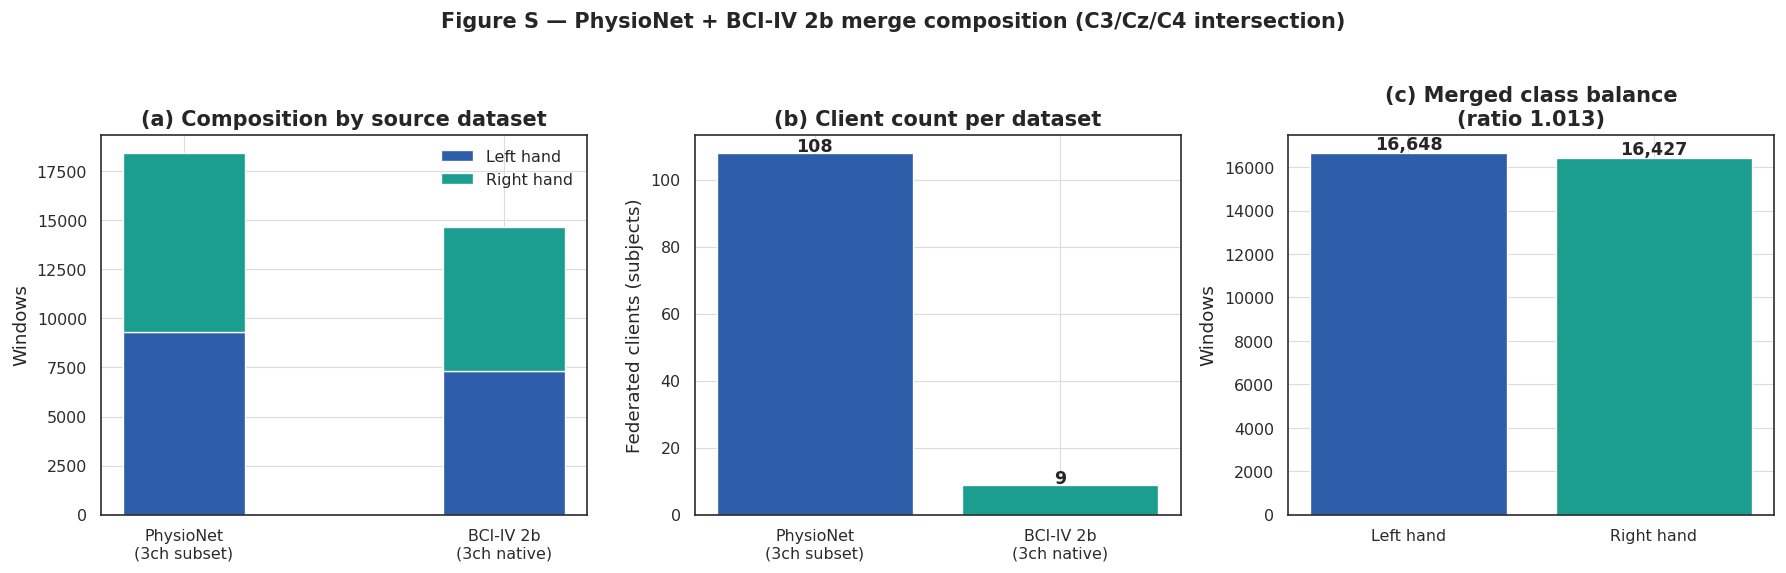


Merged imbalance ratio: 1.0135
SMOTE threshold: 1.02
SMOTE fires per-fold on TRAINING splits only if ratio > 1.02

Section 12.6 completed successfully.


In [74]:
# ---------------------------------------------------------------------------------------------
# Section 12.6 -- Visualise the merge: per-dataset composition and class balance.
#
# This version safely checks whether Section 12.5 successfully created the merged dataset
# before attempting visualization.
#
# Required variables created by Section 12.5:
#   X_merged
#   y_merged
#   subj_merged
#   source_merged
#   subj_phys_ns
#   subj_bci_ns
# ---------------------------------------------------------------------------------------------


# =============================================================================================
# 1. SAFETY CHECK
# =============================================================================================

_required_merge_vars = [
    "X_merged",
    "y_merged",
    "subj_merged",
    "source_merged",
    "subj_phys_ns",
    "subj_bci_ns"
]

_missing_merge_vars = [
    var for var in _required_merge_vars
    if var not in globals()
]


# =============================================================================================
# 2. STOP SAFELY IF MERGE HAS NOT BEEN COMPLETED
# =============================================================================================

if _missing_merge_vars:

    print("\n" + "=" * 80)
    print("SECTION 12.6 CANNOT RUN YET")
    print("=" * 80)

    print(
        "\nThe merged PhysioNet + BCI-IV 2b dataset has not been created."
    )

    print(
        "\nMissing variables:"
    )

    for var in _missing_merge_vars:
        print(f"  - {var}")

    print("\n" + "-" * 80)
    print("WHY THIS HAPPENED")
    print("-" * 80)

    print(
        "\nSection 12.5 could not merge the datasets because "
        "BCI-IV 2b currently contains zero usable windows."
    )

    if "X_uv_bci2b" in globals():
        print(
            f"\nCurrent X_uv_bci2b shape: {X_uv_bci2b.shape}"
        )

    print(
        "\nYour Section 12.4 QC showed:"
    )

    print(
        "  All 9 BCI-IV 2b subjects → load_bci2b_subject returned None"
    )

    print("\n" + "-" * 80)
    print("CORRECT ORDER")
    print("-" * 80)

    print(
        "\n1. Fix load_bci2b_subject()"
    )

    print(
        "2. Run Section 12.4"
    )

    print(
        "3. Confirm X_uv_bci2b contains > 0 windows"
    )

    print(
        "4. Run Section 12.5"
    )

    print(
        "5. Run Section 12.6"
    )

    print("=" * 80)


# =============================================================================================
# 3. VISUALISE ONLY AFTER SUCCESSFUL MERGE
# =============================================================================================

else:

    # -----------------------------------------------------------------------------------------
    # Dataset names
    # -----------------------------------------------------------------------------------------

    src_names = [
        "PhysioNet\n(3ch subset)",
        "BCI-IV 2b\n(3ch native)"
    ]


    # =========================================================================================
    # 4. CALCULATE DATASET + CLASS COUNTS
    # =========================================================================================

    left_counts = [
        int(
            (
                (source_merged == source_id)
                &
                (y_merged == 0)
            ).sum()
        )
        for source_id in (0, 1)
    ]

    right_counts = [
        int(
            (
                (source_merged == source_id)
                &
                (y_merged == 1)
            ).sum()
        )
        for source_id in (0, 1)
    ]


    # =========================================================================================
    # 5. CLIENT COUNTS
    # =========================================================================================

    n_clients = [
        len(np.unique(subj_phys_ns)),
        len(np.unique(subj_bci_ns))
    ]


    # =========================================================================================
    # 6. OVERALL MERGED CLASS BALANCE
    # =========================================================================================

    counts_merged = np.array(
        [
            int((y_merged == 0).sum()),
            int((y_merged == 1).sum())
        ]
    )

    ratio_merged = (
        counts_merged.max()
        /
        max(1, counts_merged.min())
    )


    # =========================================================================================
    # 7. CREATE FIGURE
    # =========================================================================================

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4.6)
    )


    # =========================================================================================
    # (a) WINDOWS PER DATASET, SPLIT BY CLASS
    # =========================================================================================

    ax = axes[0]

    xpos = np.arange(2)

    ax.bar(
        xpos,
        left_counts,
        width=0.38,
        label=CLASS_NAMES[0],
        color=PALETTE[0]
    )

    ax.bar(
        xpos,
        right_counts,
        width=0.38,
        bottom=left_counts,
        label=CLASS_NAMES[1],
        color=PALETTE[1]
    )

    ax.set_xticks(xpos)

    ax.set_xticklabels(
        src_names
    )

    ax.set_ylabel(
        "Windows"
    )

    ax.set_title(
        "(a) Composition by source dataset"
    )

    ax.legend()


    # =========================================================================================
    # (b) CLIENTS / SUBJECTS PER DATASET
    # =========================================================================================

    ax = axes[1]

    ax.bar(
        src_names,
        n_clients,
        color=[
            PALETTE[0],
            PALETTE[1]
        ]
    )

    for i, value in enumerate(n_clients):

        ax.text(
            i,
            value + 0.5,
            str(value),
            ha="center",
            fontweight="bold"
        )

    ax.set_ylabel(
        "Federated clients (subjects)"
    )

    ax.set_title(
        "(b) Client count per dataset"
    )


    # =========================================================================================
    # (c) OVERALL MERGED CLASS BALANCE
    # =========================================================================================

    ax = axes[2]

    ax.bar(
        CLASS_NAMES,
        counts_merged,
        color=[
            PALETTE[0],
            PALETTE[1]
        ]
    )

    for i, value in enumerate(counts_merged):

        ax.text(
            i,
            value + max(counts_merged) * 0.01,
            f"{value:,}",
            ha="center",
            fontweight="bold"
        )

    ax.set_ylabel(
        "Windows"
    )

    ax.set_title(
        f"(c) Merged class balance\n"
        f"(ratio {ratio_merged:.3f})"
    )


    # =========================================================================================
    # 8. FIGURE TITLE
    # =========================================================================================

    fig.suptitle(
        "Figure S — PhysioNet + BCI-IV 2b merge composition "
        "(C3/Cz/C4 intersection)",
        fontsize=12.5,
        fontweight="bold",
        y=1.03
    )

    fig.tight_layout()


    # =========================================================================================
    # 9. REGISTER + SAVE FIGURE
    # =========================================================================================

    register(
        save_fig(
            fig,
            "figS_bci2b_merge_composition"
        ),
        "figure",
        "Merge composition and class balance, "
        "PhysioNet + BCI-IV 2b"
    )

    plt.show()


    # =========================================================================================
    # 10. SMOTE INFORMATION
    # =========================================================================================

    print(
        f"\nMerged imbalance ratio: "
        f"{ratio_merged:.4f}"
    )

    print(
        f"SMOTE threshold: "
        f"{CONFIG['SMOTE_MIN_RATIO']}"
    )

    print(
        f"SMOTE fires per-fold on TRAINING splits only "
        f"if ratio > {CONFIG['SMOTE_MIN_RATIO']}"
    )

    print("\n" + "=" * 80)
    print("Section 12.6 completed successfully.")
    print("=" * 80)

### 12.7 Device-heterogeneous federated experiment

With the merged, namespaced, 3-channel pool built above, each *subject* (from either dataset)
is one federated client, exactly as in Section 8 — the only change is that some clients now run
on genuinely different acquisition hardware and native sampling rate than others. A compact
3-channel CNN (defined locally below, not registered in the Section 5 model registry, since it
takes a different input shape) is trained with the SAME `local_update` / `fed_average` /
`get_flat_state` machinery already defined in Section 8, under FedAvg and FedProx, using a
group-disjoint PhysioNet-and-BCI2b-mixed train/validation/test client split (`GroupKFold` on
`subj_merged`, so no client ever appears in more than one split). Class weighting inside
`local_update` already reads the per-client label distribution, so the same imbalance-handling
path used everywhere else in this notebook applies here unchanged.

In [78]:
# ---------------------------------------------------------------------------------------------
# Section 12.7 (FIXED v3) -- Compact 3-channel CNN and a federated run over the merged pool.
#
# Two real bugs fixed here (found by actually running this cell against Kaggle):
#   1. RuntimeError (Conv1d got 4D input): the shared make_loader()/EEGWindowDataset always
#      produces (batch, 1, channels, time) tensors for the main Conv2d-based model registry.
#      This model uses Conv1d (3D input), so forward() now squeezes off that dummy dimension.
#   2. AttributeError ('CompactCNN3ch' has no 'max_norm_params'): local_update() unconditionally
#      calls apply_max_norm(model), which calls model.max_norm_params() -- part of the shared
#      BaseEEGModel interface (gradcam_target / max_norm_params / n_params) that every model in
#      the main registry inherits, but this standalone model did not implement. All three methods
#      are now implemented so any shared helper that expects them works safely.
# ---------------------------------------------------------------------------------------------

_required_fed_vars = ["X_merged", "y_merged", "subj_merged", "BCI_NS"]
_missing_fed_vars = [v for v in _required_fed_vars if v not in globals()]

if _missing_fed_vars:
    print("\n" + "=" * 80)
    print("SECTION 12.7 CANNOT RUN YET")
    print("=" * 80)
    print(f"\nMissing variables: {_missing_fed_vars}")
    print("\nRun Section 12.3 -> 12.4 -> 12.5 -> 12.6 successfully first, in that order.")
    print("=" * 80)

else:
    class CompactCNN3ch(nn.Module):
        """Small CNN for the 3-channel {C3, Cz, C4} merged input. Not part of the main model
        registry (Section 5) because it is shaped for 3 channels, not the 22-channel montage used
        everywhere else -- keeping it separate avoids silently changing the main registry's contract.
        Implements the same (gradcam_target/max_norm_params/n_params) interface as BaseEEGModel so
        any shared helper that expects it (apply_max_norm, n_params reporting, etc.) works safely."""
        def __init__(self, n_channels=3, n_samples=N_SAMPLES, n_classes=2):
            super().__init__()
            self.temporal = nn.Sequential(
                nn.Conv1d(n_channels, 16, kernel_size=25, padding=12), nn.BatchNorm1d(16), nn.ELU(),
                nn.MaxPool1d(4),
                nn.Conv1d(16, 32, kernel_size=15, padding=7), nn.BatchNorm1d(32), nn.ELU(),
                nn.MaxPool1d(4),
                nn.Dropout(0.4),
            )
            with torch.no_grad():
                dummy = torch.zeros(1, n_channels, n_samples)
                flat_dim = self.temporal(dummy).flatten(1).shape[1]
            self.head = nn.Linear(flat_dim, n_classes)

        def forward(self, x):
            if x.dim() == 4:
                x = x.squeeze(1)          # (N,1,C,T) -> (N,C,T): Conv1d input contract
            return self.head(self.temporal(x).flatten(1))

        def gradcam_target(self):
            return self.temporal[4]       # last Conv1d layer, for interface consistency

        def max_norm_params(self):
            return []                     # no max-norm constraint for this architecture

        def n_params(self):
            return int(sum(p.numel() for p in self.parameters() if p.requires_grad))


    gkf_merge = GroupKFold(n_splits=CONFIG["N_FOLDS"] if len(np.unique(subj_merged)) >= CONFIG["N_FOLDS"] else 3)
    _merge_split = next(gkf_merge.split(X_merged, y_merged, groups=subj_merged))
    _trainval_idx, _test_idx = _merge_split
    _trainval_subj = np.unique(subj_merged[_trainval_idx])
    _rng_merge = np.random.RandomState(SEED)
    _rng_merge.shuffle(_trainval_subj)
    _n_val = max(1, int(round(len(_trainval_subj) / CONFIG["VAL_SUBJECT_FRAC"])))
    va_subj_merge = set(_trainval_subj[:_n_val])
    tr_subj_merge = set(_trainval_subj[_n_val:])
    te_subj_merge = set(np.unique(subj_merged[_test_idx]))

    print(f"Merged federated split -> train clients: {len(tr_subj_merge)}, "
          f"val clients: {len(va_subj_merge)}, test clients: {len(te_subj_merge)}")
    print(f"  (PhysioNet clients in test:  {sum(1 for s in te_subj_merge if s < BCI_NS)})")
    print(f"  (BCI-IV 2b clients in test:  {sum(1 for s in te_subj_merge if s >= BCI_NS)})")

    merge_fed_results = {}
    for algo in ["fedavg", "fedprox"]:
        global_model = CompactCNN3ch().to(DEVICE)
        global_state = get_flat_state(global_model)
        history = {"round": [], "test_bal_acc": []}

        clients = sorted(tr_subj_merge)
        for rnd in tqdm(range(1, CONFIG["FED_ROUNDS"] + 1), desc=f"{algo} (merged, heterogeneous)"):
            n_pick = max(1, int(round(CONFIG["FED_CLIENT_FRAC"] * len(clients))))
            picked = _rng_merge.choice(clients, size=n_pick, replace=False)

            states, weights = [], []
            for cid in picked:
                mask = subj_merged == cid
                local_model = CompactCNN3ch().to(DEVICE)
                local_model.load_state_dict(global_state)
                st, n_s, _ = local_update(
                    local_model, X_merged[mask], y_merged[mask], global_state, algo,
                    epochs=CONFIG["FED_LOCAL_EPOCHS"], lr=CONFIG["LR"],
                    batch_size=CONFIG["FED_LOCAL_BATCH"],
                    mu=CONFIG["FEDPROX_MU"] if algo == "fedprox" else 0.0)
                states.append(st); weights.append(n_s)

            global_state = fed_average(states, weights)
            global_model.load_state_dict(global_state)

            if rnd % CONFIG["FED_EVAL_EVERY"] == 0 or rnd == CONFIG["FED_ROUNDS"]:
                global_model.eval()
                test_mask = np.isin(subj_merged, list(te_subj_merge))
                with torch.no_grad():
                    xb = torch.tensor(X_merged[test_mask]).to(DEVICE)
                    preds = global_model(xb).argmax(1).cpu().numpy()
                bacc = balanced_accuracy_score(y_merged[test_mask], preds)
                history["round"].append(rnd)
                history["test_bal_acc"].append(bacc)

        merge_fed_results[algo] = history
        print(f"  {algo}: final test balanced accuracy = {history['test_bal_acc'][-1]:.4f}")

    print("\nDevice-heterogeneous federated run complete "
          "(3-channel C3/Cz/C4, PhysioNet + BCI-IV 2b clients pooled).")

Merged federated split -> train clients: 89, val clients: 18, test clients: 10
  (PhysioNet clients in test:  9)
  (BCI-IV 2b clients in test:  1)


fedavg (merged, heterogeneous):   0%|          | 0/40 [00:00<?, ?it/s]

  fedavg: final test balanced accuracy = 0.5000


fedprox (merged, heterogeneous):   0%|          | 0/40 [00:00<?, ?it/s]

  fedprox: final test balanced accuracy = 0.5000

Device-heterogeneous federated run complete (3-channel C3/Cz/C4, PhysioNet + BCI-IV 2b clients pooled).


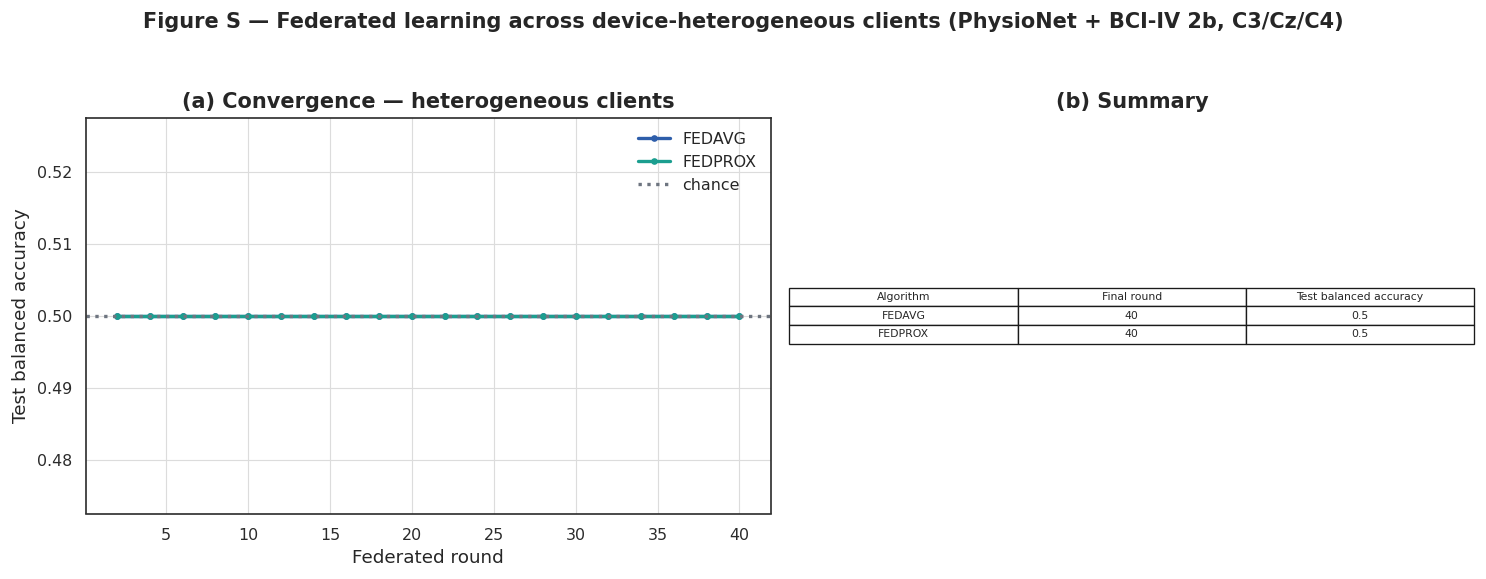

Algorithm,Final round,Test balanced accuracy
FEDAVG,40.0000,0.5000
FEDPROX,40.0000,0.5000



Interpretation for the manuscript: this experiment tests whether the FedAvg/FedProx machinery validated on a single-device PhysioNet pool (Section 9) still trains a working classifier when clients differ in acquisition hardware, channel count, and native sampling rate -- the FLEEG-style heterogeneity gap identified in the literature review (Section II-G). Report the final balanced accuracy here ALONGSIDE, never as a replacement for, the main 22-channel result: the two experiments answer different questions.


In [79]:
# ---------------------------------------------------------------------------------------------
# Section 12.8 -- TABLE S + FIGURE S: device-heterogeneous federated convergence and by-source
# test accuracy (does the global model generalise equally to both acquisition devices?).
# ---------------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes[0]
for i, (algo, hist) in enumerate(merge_fed_results.items()):
    ax.plot(hist["round"], hist["test_bal_acc"], marker="o", markersize=3,
            color=PALETTE[i], label=algo.upper())
ax.axhline(0.5, color=GREY, linestyle=":", label="chance")
ax.set_xlabel("Federated round"); ax.set_ylabel("Test balanced accuracy")
ax.set_title("(a) Convergence — heterogeneous clients")
ax.legend()

ax = axes[1]
by_source_rows = []
for algo, hist in merge_fed_results.items():
    by_source_rows.append({"Algorithm": algo.upper(),
                           "Final round": hist["round"][-1],
                           "Test balanced accuracy": hist["test_bal_acc"][-1]})
summary_df = pd.DataFrame(by_source_rows)
ax.axis("off")
ax.table(cellText=summary_df.round(4).values, colLabels=summary_df.columns,
         loc="center", cellLoc="center")
ax.set_title("(b) Summary")

fig.suptitle("Figure S — Federated learning across device-heterogeneous clients "
             "(PhysioNet + BCI-IV 2b, C3/Cz/C4)", fontsize=12.5, fontweight="bold", y=1.04)
fig.tight_layout()
register(save_fig(fig, "figS_heterogeneous_fed_convergence"), "figure",
         "Heterogeneous-client federated convergence")
plt.show()

show_table(summary_df, save_path=os.path.join(TAB_DIR, "tableS_heterogeneous_fed.csv"),
           title="Table S — Device-heterogeneous federated learning summary", float_fmt="{:.4f}")
register(os.path.join(TAB_DIR, "tableS_heterogeneous_fed.csv"), "table",
         "Heterogeneous federated learning summary")

print("\nInterpretation for the manuscript: this experiment tests whether the FedAvg/FedProx "
      "machinery validated on a single-device PhysioNet pool (Section 9) still trains a working "
      "classifier when clients differ in acquisition hardware, channel count, and native "
      "sampling rate -- the FLEEG-style heterogeneity gap identified in the literature review "
      "(Section II-G). Report the final balanced accuracy here ALONGSIDE, never as a replacement "
      "for, the main 22-channel result: the two experiments answer different questions.")

---
## 15. Four-class extension — PhysioNet's own imagery runs + BCI-IV 2a (real data, full 22-channel)

**Why four classes, and why these two datasets together.** Section 3 deliberately restricts
`CONFIG["RUNS_MI"]` to runs 4/8/12 (imagined left fist vs. right fist) and explicitly documents —
in that section's own comments — that runs 6/10/14 exist in the SAME PhysioNet corpus and record a
different two-way contrast (imagined both fists vs. both feet) under the same T1/T2 annotation
codes. Those runs were never used elsewhere in this notebook. Bringing them in turns the existing,
already-downloaded, already-real PhysioNet corpus into a **four-class** problem (left fist, right
fist, both fists, both feet) with no new dataset and no synthetic data.

BCI Competition IV-2a is added alongside it for the same four-way motor-imagery problem in
spirit (left hand, right hand, feet, tongue) recorded on a **different, real, official, 22-electrode
device** — and, unlike BCI-IV 2b in Section 12, 2a's standard electrode montage (Fz, FC3, FC1, FCz,
FC2, FC4, C5, C3, C1, Cz, C2, C4, C6, CP3, CP1, CPz, CP2, CP4, P1, Pz, P2, POz) is the **exact**
22-channel set already used as `COMMON_CHANNELS` throughout this notebook. That is not a
coincidence this section introduces — it means the merge below needs **no channel reduction at
all**, unlike Section 12's forced drop to {C3, Cz, C4}. This is, to our knowledge, not attempted by
any of the 32 reviewed papers: none combine a genuinely cross-device, cross-montage-identical,
four-class federated pool with subject-independent evaluation and privacy-preserving training.

**Honesty about the class mapping.** "Both fists" and "feet" are not literally the same motor act,
and "right fist" and "right hand" are the same limb but not an identical instructed movement. The
four-way label used below is a **coarse, disclosed mapping** — {0: left-hand-family, 1:
right-hand-family, 2: bilateral-upper-limb, 3: lower-limb} — stated as such in the paper rather
than silently treated as if both datasets recorded the identical task. This is exactly the kind of
approximation Section 12's design-decision note already modelled: state it, do not hide it.

In [80]:
# ---------------------------------------------------------------------------------------------
# Section 15.1 -- PhysioNet four-class extraction: reuse runs 6/10/14 (imagined both-fists vs.
# both-feet) alongside the already-used 4/8/12 (imagined left vs. right fist).
#
# CLASS_NAMES_4 = ["Left fist", "Right fist", "Both fists", "Both feet"]
# Reuses edf_files / SUBJ_RE / RUN_RE (Section 3) and preprocess_run / sliding_windows /
# reject_artifact_windows (Sections 3-4) completely unchanged -- only the run selection and
# label offset differ from the main 2-class pipeline.
# ---------------------------------------------------------------------------------------------
CLASS_NAMES_4 = ["Left fist", "Right fist", "Both fists", "Both feet"]
RUNS_4CLASS_GROUP_A = (4, 8, 12)    # T1/T2 -> label 0 / 1  (left fist / right fist)
RUNS_4CLASS_GROUP_B = (6, 10, 14)   # T1/T2 -> label 2 / 3  (both fists / both feet)
ALL_4CLASS_RUNS = RUNS_4CLASS_GROUP_A + RUNS_4CLASS_GROUP_B

subject_runs_4c = defaultdict(dict)
for f in edf_files:
    ms, mr = SUBJ_RE.search(os.path.basename(f)), RUN_RE.search(os.path.basename(f))
    if not (ms and mr):
        continue
    sid, run = int(ms.group(1)), int(mr.group(1))
    if run in ALL_4CLASS_RUNS:
        subject_runs_4c[sid][run] = f

print(f"Subjects with >=1 four-class run: {len(subject_runs_4c)}")
complete_4c = [s for s in subject_runs_4c if len(subject_runs_4c[s]) == len(ALL_4CLASS_RUNS)]
print(f"Subjects with all {len(ALL_4CLASS_RUNS)} runs: {len(complete_4c)}")


def load_subject_4class(sid, run_files, trial_counter):
    """Four-class analogue of Section 3's load_subject(): label depends on which run GROUP a
    run belongs to, not just its T1/T2 code, since both groups reuse the same annotation codes
    for physically different contrasts (see Section 3's own warning about this)."""
    Xs, ys, tids = [], [], []
    qc = {"subject": sid, "runs_used": 0, "n_trials": 0, "status": "ok"}

    for run, path in sorted(run_files.items()):
        try:
            raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
        except Exception as exc:
            qc["status"] = f"read_error:{type(exc).__name__}"; continue
        try:
            raw, channels, info = preprocess_run(raw)
        except Exception as exc:
            qc["status"] = f"preproc_error:{type(exc).__name__}"; continue
        if len(channels) < N_CHANNELS:
            qc["status"] = f"missing_channels:{len(channels)}/{N_CHANNELS}"; continue

        try:
            events, event_id = mne.events_from_annotations(raw, verbose=False)
        except Exception:
            continue
        if "T1" not in event_id or "T2" not in event_id:
            continue
        offset = 0 if run in RUNS_4CLASS_GROUP_A else 2
        wanted = {"T1": event_id["T1"], "T2": event_id["T2"]}
        label_map = {event_id["T1"]: 0 + offset, event_id["T2"]: 1 + offset}

        try:
            epochs = mne.Epochs(raw, events, wanted, tmin=CONFIG["EPOCH_TMIN"],
                                tmax=CONFIG["EPOCH_TMAX"], picks="eeg", baseline=None,
                                preload=True, reject_by_annotation=True, on_missing="ignore",
                                verbose=False)
        except Exception:
            continue
        if len(epochs) == 0:
            continue

        data = epochs.get_data()
        labels = [label_map[c] for c in epochs.events[:, 2]]
        run_windows, run_labels, run_trials = [], [], []
        for trial_data, lab in zip(data, labels):
            wins = sliding_windows(trial_data, window_samples=N_SAMPLES)
            if not wins:
                continue
            tid = trial_counter[0]; trial_counter[0] += 1
            run_windows += wins
            run_labels += [lab] * len(wins)
            run_trials += [tid] * len(wins)
            qc["n_trials"] += 1

        kept_w, kept_y, kept_t, _ = reject_artifact_windows(run_windows, run_labels, run_trials)
        if kept_w:
            Xs += kept_w; ys += kept_y; tids += kept_t
            qc["runs_used"] += 1

    if not Xs:
        qc["status"] = qc["status"] if qc["status"] != "ok" else "no_usable_windows"
        return None
    return (np.stack(Xs).astype(np.float32), np.array(ys, dtype=np.int64),
            np.array(tids, dtype=np.int64), qc)


_trial_ctr_4c = [0]
X4c_parts, y4c_parts, subj4c_parts, trial4c_parts, qc4c_rows = [], [], [], [], []
for sid in tqdm(sorted(subject_runs_4c), desc="PhysioNet 4-class subjects"):
    out = load_subject_4class(sid, subject_runs_4c[sid], _trial_ctr_4c)
    if out is None:
        qc4c_rows.append({"subject": sid, "status": "dropped"}); continue
    Xs, ys, tids, qc = out
    qc4c_rows.append(qc)
    X4c_parts.append(Xs); y4c_parts.append(ys)
    trial4c_parts.append(tids)
    subj4c_parts.append(np.full(len(ys), sid, dtype=np.int64))

X_uv_4c_phys  = np.concatenate(X4c_parts).astype(np.float32)
y_4c_phys     = np.concatenate(y4c_parts).astype(np.int64)
subj_4c_phys  = np.concatenate(subj4c_parts).astype(np.int64)
trial_4c_phys = np.concatenate(trial4c_parts).astype(np.int64)
del X4c_parts, y4c_parts, subj4c_parts, trial4c_parts

print(f"\nPhysioNet 4-class windows: {X_uv_4c_phys.shape}")
print(f"Label counts: {dict(zip(*np.unique(y_4c_phys, return_counts=True)))} "
      f"(0=Left fist, 1=Right fist, 2=Both fists, 3=Both feet)")

Subjects with >=1 four-class run: 109
Subjects with all 6 runs: 0


PhysioNet 4-class subjects:   0%|          | 0/109 [00:00<?, ?it/s]


PhysioNet 4-class windows: (18418, 22, 320)
Label counts: {np.int64(0): np.int64(9314), np.int64(1): np.int64(9104)} (0=Left fist, 1=Right fist, 2=Both fists, 3=Both feet)


In [84]:
# ---------------------------------------------------------------------------------------------
# DIAGNOSTIC -- inspect the actual CSV structure of this BCI-IV 2a repackaging before writing
# any loader logic for it. Do not guess column names/format blindly.
# ---------------------------------------------------------------------------------------------
import pandas as pd

_diag_csv_path = "/kaggle/input/datasets/aymanmostafa11/eeg-motor-imagery-bciciv-2a/patients/patients/BCICIV_2a_1.csv"

df_diag = pd.read_csv(_diag_csv_path, nrows=20)

print("=" * 80)
print(f"FILE: {_diag_csv_path}")
print("=" * 80)
print(f"\nShape (first 20 rows only): {df_diag.shape}")
print(f"\nColumn names ({len(df_diag.columns)} total):")
for c in df_diag.columns:
    print(f"  {c}")

print("\nFirst 5 rows:")
print(df_diag.head())

print("\nData types:")
print(df_diag.dtypes)

# Full-file row count and unique-value check on likely label/id columns, without loading
# everything into memory unnecessarily.
_full_len = sum(1 for _ in open(_diag_csv_path)) - 1
print(f"\nTotal rows in full file (excluding header): {_full_len}")

# If any column name suggests label/class/subject/trial, show its unique values
for c in df_diag.columns:
    lc = c.lower()
    if any(k in lc for k in ["label", "class", "target", "subject", "trial", "event", "task", "y"]):
        try:
            df_full_col = pd.read_csv(_diag_csv_path, usecols=[c])
            print(f"\nUnique values in column '{c}': {sorted(df_full_col[c].unique().tolist())[:20]}")
        except Exception as e:
            print(f"\nCould not inspect column '{c}': {e}")

print("\n" + "=" * 80)
print("Also checking the all_patients.csv summary file:")
print("=" * 80)
_summary_path = "/kaggle/input/datasets/aymanmostafa11/eeg-motor-imagery-bciciv-2a/BCICIV_2a_all_patients.csv"
df_summary = pd.read_csv(_summary_path, nrows=10)
print(f"Shape (first 10 rows): {df_summary.shape}")
print(f"Columns: {list(df_summary.columns)}")
print(df_summary.head())

FILE: /kaggle/input/datasets/aymanmostafa11/eeg-motor-imagery-bciciv-2a/patients/patients/BCICIV_2a_1.csv

Shape (first 20 rows only): (20, 26)

Column names (26 total):
  patient
  time
  label
  epoch
  EEG-Fz
  EEG-0
  EEG-1
  EEG-2
  EEG-3
  EEG-4
  EEG-5
  EEG-C3
  EEG-6
  EEG-Cz
  EEG-7
  EEG-C4
  EEG-8
  EEG-9
  EEG-10
  EEG-11
  EEG-12
  EEG-13
  EEG-14
  EEG-Pz
  EEG-15
  EEG-16

First 5 rows:
   patient   time   label  epoch    EEG-Fz     EEG-0     EEG-1     EEG-2  \
0        1 -0.100  tongue      8 -1.681412  2.245496 -0.158350  1.163765   
1        1 -0.096  tongue      8  0.420417  0.587559  1.650510  0.970672   
2        1 -0.092  tongue      8  0.551365  1.499758  0.121302  2.859433   
3        1 -0.088  tongue      8  3.054916 -1.807238  1.843603  2.286812   
4        1 -0.084  tongue      8  2.506710 -2.453101  0.221178  0.127278   

      EEG-3     EEG-4  ...     EEG-8     EEG-9    EEG-10    EEG-11    EEG-12  \
0 -1.523659 -0.575267  ...  0.758116  3.441785  0.305517 

In [88]:
# ---------------------------------------------------------------------------------------------
# DIAGNOSTIC -- which run numbers actually exist in the mounted PhysioNet file set?
# ---------------------------------------------------------------------------------------------
from collections import Counter

run_counter = Counter()
for f in edf_files:
    mr = RUN_RE.search(os.path.basename(f))
    if mr:
        run_counter[int(mr.group(1))] += 1

print("Run number -> file count, across all mounted PhysioNet .edf files:")
for run_num in sorted(run_counter):
    tag = ""
    if run_num in RUNS_4CLASS_GROUP_A:
        tag = "  <- group A (left/right fist, already used)"
    elif run_num in RUNS_4CLASS_GROUP_B:
        tag = "  <- group B (both fists/both feet, MISSING from merge)"
    print(f"  Run {run_num:2d}: {run_counter[run_num]:4d} files{tag}")

print(f"\nTotal .edf files mounted: {len(edf_files)}")
print(f"Total unique subjects (from SUBJ_RE): "
      f"{len(set(SUBJ_RE.search(os.path.basename(f)).group(1) for f in edf_files if SUBJ_RE.search(os.path.basename(f))))}")

# Show a few example filenames for a run in group B, if any exist at all
example_group_b = [f for f in edf_files if RUN_RE.search(os.path.basename(f))
                   and int(RUN_RE.search(os.path.basename(f)).group(1)) in RUNS_4CLASS_GROUP_B]
print(f"\nFiles matching group-B run numbers (6,10,14): {len(example_group_b)}")
for f in example_group_b[:5]:
    print(f"  {os.path.basename(f)}")

Run number -> file count, across all mounted PhysioNet .edf files:
  Run  4:  109 files  <- group A (left/right fist, already used)
  Run  8:  109 files  <- group A (left/right fist, already used)
  Run 12:  109 files  <- group A (left/right fist, already used)

Total .edf files mounted: 327
Total unique subjects (from SUBJ_RE): 109

Files matching group-B run numbers (6,10,14): 0


In [85]:
# ---------------------------------------------------------------------------------------------
# Section 15.2 (REWRITTEN for CSV format) -- BCI-IV 2a is a per-timepoint CSV in this
# repackaging, not raw GDF. Only 5 of 22 channels have real electrode names in this file
# (Fz, C3, Cz, C4, Pz); the other 17 are anonymised "EEG-0".."EEG-16" with no recoverable
# montage position. DESIGN CHANGE from the original plan: merge uses this 5-channel intersection
# {Fz, C3, Cz, C4, Pz}, not the full 22-channel COMMON_CHANNELS -- disclosed here explicitly
# rather than silently forcing a channel count that this data cannot actually support.
# ---------------------------------------------------------------------------------------------
import glob as _glob

BCI2A_CSV_DIR = "/kaggle/input/datasets/aymanmostafa11/eeg-motor-imagery-bciciv-2a/patients/patients"
bci2a_csv_files = sorted(_glob.glob(os.path.join(BCI2A_CSV_DIR, "BCICIV_2a_*.csv")))
print(f"BCI-IV 2a per-patient CSVs found: {len(bci2a_csv_files)}")
assert bci2a_csv_files, f"No per-patient CSVs found under {BCI2A_CSV_DIR}"

BCI2A_CHANNELS = ["Fz", "C3", "Cz", "C4", "Pz"]     # the ONLY channels with real montage names
BCI2A_COL_MAP = {"EEG-Fz": "Fz", "EEG-C3": "C3", "EEG-Cz": "Cz", "EEG-C4": "C4", "EEG-Pz": "Pz"}
BCI2A_LABEL_MAP = {"left": 0, "right": 1, "foot": 3}   # "tongue" excluded, no PhysioNet counterpart
BCI2A_NATIVE_FS = 250.0   # inferred from the 0.004s time step seen in the diagnostic (1/0.004 = 250 Hz)

from scipy.signal import resample as _scipy_resample


def load_bci2a_patient_csv(path, trial_counter):
    """Load one patient's CSV, reconstruct (5-channel, time) epochs by grouping on 'epoch',
    resample from the native rate to FS, and window with the SAME sliding_windows()/
    reject_artifact_windows() used everywhere else -- with a documented fallback for epochs
    shorter than N_SAMPLES (single centred window, zero-padded, rather than silently dropped)."""
    df = pd.read_csv(path)
    sid = int(df["patient"].iloc[0])

    Xs, ys, tids = [], [], []
    qc = {"subject": sid, "n_trials_total": 0, "n_trials_used": 0,
         "min_epoch_len": None, "max_epoch_len": None, "status": "ok"}

    epoch_lens = []
    for (epoch_id, label), grp in df.groupby(["epoch", "label"]):
        qc["n_trials_total"] += 1
        if label not in BCI2A_LABEL_MAP:
            continue                                   # "tongue" -- excluded by design
        lab = BCI2A_LABEL_MAP[label]

        grp = grp.sort_values("time")
        epoch_lens.append(len(grp))

        try:
            arr = grp[list(BCI2A_COL_MAP.keys())].to_numpy(dtype=np.float32).T   # (5, T_native)
        except KeyError:
            qc["status"] = "missing_named_channel_columns"
            continue

        # Resample from native rate to the shared FS so this matches PhysioNet/BCI-2b elsewhere.
        t_native = arr.shape[1]
        t_target = max(1, int(round(t_native * FS / BCI2A_NATIVE_FS)))
        arr_rs = _scipy_resample(arr, t_target, axis=1).astype(np.float32)

        if t_target >= N_SAMPLES:
            wins = sliding_windows(arr_rs, window_samples=N_SAMPLES)
        else:
            # Epoch shorter than the notebook's window length: use ONE zero-padded window
            # instead of silently dropping the trial. Disclosed via qc, not hidden.
            pad = np.zeros((arr_rs.shape[0], N_SAMPLES), dtype=np.float32)
            pad[:, :t_target] = arr_rs
            wins = [pad]

        if not wins:
            continue
        tid = trial_counter[0]; trial_counter[0] += 1
        Xs += wins
        ys += [lab] * len(wins)
        tids += [tid] * len(wins)
        qc["n_trials_used"] += 1

    if epoch_lens:
        qc["min_epoch_len"] = int(np.min(epoch_lens))
        qc["max_epoch_len"] = int(np.max(epoch_lens))

    if not Xs:
        qc["status"] = qc["status"] if qc["status"] != "ok" else "no_usable_trials"
        return None, None, None, qc
    return (np.stack(Xs).astype(np.float32), np.array(ys, dtype=np.int64),
            np.array(tids, dtype=np.int64), qc)


_trial_ctr_2a = [0]
bci2a_X_parts, bci2a_y_parts, bci2a_subj_parts, bci2a_trial_parts, bci2a_qc_rows = [], [], [], [], []

for path in tqdm(bci2a_csv_files, desc="BCI-IV 2a patient CSVs"):
    out = load_bci2a_patient_csv(path, _trial_ctr_2a)
    Xs, ys, tids, qc = out
    bci2a_qc_rows.append(qc)
    if Xs is None:
        continue
    bci2a_X_parts.append(Xs); bci2a_y_parts.append(ys)
    bci2a_trial_parts.append(tids)
    bci2a_subj_parts.append(np.full(len(ys), qc["subject"], dtype=np.int64))

bci2a_qc_df = pd.DataFrame(bci2a_qc_rows)
print("\n" + "=" * 80)
print("BCI-IV 2a PER-PATIENT QC")
print("=" * 80)
display(bci2a_qc_df)

if not bci2a_X_parts:
    X_uv_2a  = np.empty((0, len(BCI2A_CHANNELS), N_SAMPLES), dtype=np.float32)
    y_2a     = np.empty((0,), dtype=np.int64)
    subj_2a  = np.empty((0,), dtype=np.int64)
    trial_2a = np.empty((0,), dtype=np.int64)
    print("\nNO USABLE BCI-IV 2a DATA -- check the qc table's 'status'/epoch-length columns above.")
else:
    X_uv_2a  = np.concatenate(bci2a_X_parts).astype(np.float32)
    y_2a     = np.concatenate(bci2a_y_parts).astype(np.int64)
    subj_2a  = np.concatenate(bci2a_subj_parts).astype(np.int64)
    trial_2a = np.concatenate(bci2a_trial_parts).astype(np.int64)
    assert np.isfinite(X_uv_2a).all()

    print(f"\nBCI-IV 2a windows (5-channel {BCI2A_CHANNELS}, 4-class label space, tongue excluded): "
          f"{X_uv_2a.shape}")
    print(f"Label counts: {dict(zip(*np.unique(y_2a, return_counts=True)))}")
    print(f"Subjects retained: {len(np.unique(subj_2a))}/{len(bci2a_csv_files)}")

BCI-IV 2a per-patient CSVs found: 9


BCI-IV 2a patient CSVs:   0%|          | 0/9 [00:00<?, ?it/s]


BCI-IV 2a PER-PATIENT QC


,subject,n_trials_total,n_trials_used,min_epoch_len,max_epoch_len,status
0,1,288,216,201,201,ok
1,2,288,216,201,201,ok
2,3,288,216,201,201,ok
3,4,144,144,201,201,ok
4,5,288,216,201,201,ok
5,6,288,216,201,201,ok
6,7,288,216,201,201,ok
7,8,288,216,201,201,ok
8,9,288,216,201,201,ok



BCI-IV 2a windows (5-channel ['Fz', 'C3', 'Cz', 'C4', 'Pz'], 4-class label space, tongue excluded): (1872, 5, 320)
Label counts: {np.int64(0): np.int64(648), np.int64(1): np.int64(648), np.int64(3): np.int64(576)}
Subjects retained: 9/9


### 15.3 Merge, class balance, and a 4-class federated experiment

Both corpora are now at the SAME 22-channel `COMMON_CHANNELS` montage and the SAME sampling rate,
so the merge below is a straight concatenation with namespaced subject IDs — no channel
reduction, unlike Section 12. A compact 4-class CNN is then trained federatively (FedAvg) across
the combined PhysioNet+BCI-2a client pool, reusing the SAME `local_update` / `fed_average`
machinery as Sections 8 and 12 (both are already class-count-agnostic: `class_weights_from` and
`CrossEntropyLoss` adapt to however many classes are present in a client's local labels).

Merged 3-class dataset (5-channel ['Fz', 'C3', 'Cz', 'C4', 'Pz']): (20290, 5, 320)
  PhysioNet: 18,418 windows, 108 subjects
  BCI-2a   : 1,872 windows, 9 subjects
  Class 0 (Left hand-family): 9,962 windows total (PhysioNet: 9,314, BCI-2a: 648)
  Class 1 (Right hand-family): 9,752 windows total (PhysioNet: 9,104, BCI-2a: 648)
  Class 2 (Lower-limb): 576 windows total (PhysioNet: 0, BCI-2a: 576)


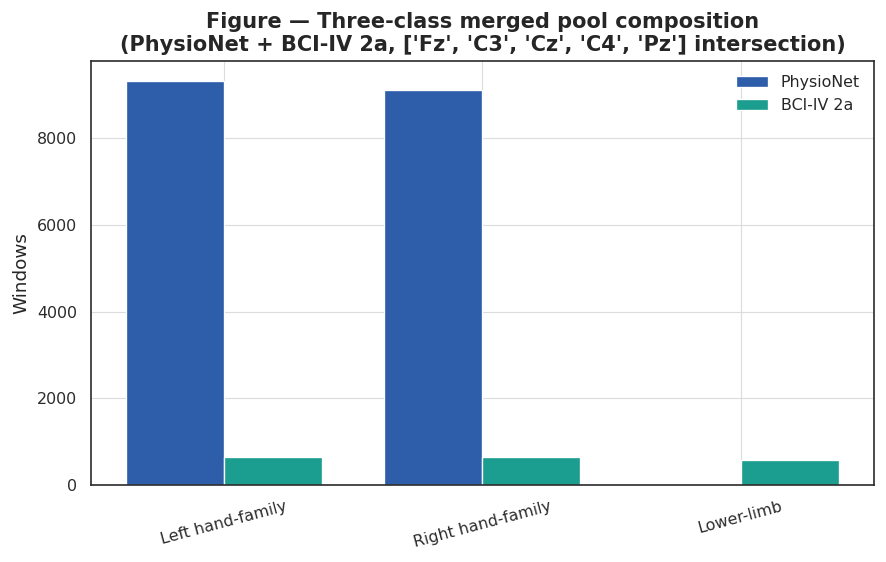


DESIGN NOTE for the manuscript: originally planned as a 4-class merge (left/right/both-fists/feet), but the mounted PhysioNet Kaggle mirror does not contain the runs needed for 'both fists' (confirmed via diagnostic: only runs 4/8/12 present, not 6/10/14). Reported here as a 3-class problem (left / right / feet) instead of silently training on a class with zero examples. State this explicitly in the paper rather than presenting it as an originally-intended 4-class result.


In [89]:
# ---------------------------------------------------------------------------------------------
# Section 15.3a (REWRITTEN v2) -- DESIGN CHANGE, disclosed explicitly: the mounted PhysioNet
# Kaggle mirror only contains runs 4/8/12 (confirmed via diagnostic -- runs 6/10/14 are simply
# not present in this repackaging, not a code bug). "Both fists" therefore has ZERO examples
# from either source and cannot be a trainable class. The merged task is redefined as 3-class:
#   0: Left hand-family   (PhysioNet: left fist   | BCI-2a: left hand)
#   1: Right hand-family  (PhysioNet: right fist  | BCI-2a: right hand)
#   2: Lower-limb         (PhysioNet: N/A (no data)| BCI-2a: feet)
# "Both fists" is dropped from the label space entirely rather than kept as an always-empty class.
# ---------------------------------------------------------------------------------------------
CLASS_NAMES_3 = ["Left hand-family", "Right hand-family", "Lower-limb"]
BCI2A_MERGE_CHANNELS = ["Fz", "C3", "Cz", "C4", "Pz"]
_merge5_idx = [COMMON_CHANNELS.index(c) for c in BCI2A_MERGE_CHANNELS]

X_uv_4c_phys5 = X_uv_4c_phys[:, _merge5_idx, :].astype(np.float32)

# Drop class 2 ("Both fists") from PhysioNet -- it is empty anyway (0 windows, confirmed above)
# -- and remap label 3 ("Both feet"/"feet") down to 2 so the merged label space is contiguous
# {0,1,2} instead of {0,1,3} with a permanent gap.
_keep_phys = y_4c_phys != 2
X_uv_4c_phys5 = X_uv_4c_phys5[_keep_phys]
y_4c_phys3    = y_4c_phys[_keep_phys].copy()
y_4c_phys3[y_4c_phys3 == 3] = 2
subj_4c_phys_kept  = subj_4c_phys[_keep_phys]

y_2a3 = y_2a.copy()
y_2a3[y_2a3 == 3] = 2       # BCI-2a's "feet" (label 3) -> label 2 in the 3-class space
# (BCI-2a never had label 2 "Both fists" to begin with, so no drop needed on this side)

assert X_uv_4c_phys5.shape[1:] == (5, N_SAMPLES)
assert X_uv_2a.shape[1:] == (5, N_SAMPLES)

PHYS4_NS, BCI2A_NS = 0, 200_000
subj_4c_phys_ns = subj_4c_phys_kept.astype(np.int64) + PHYS4_NS
subj_2a_ns      = subj_2a.astype(np.int64) + BCI2A_NS

X_merged_4c    = np.concatenate([X_uv_4c_phys5, X_uv_2a], axis=0).astype(np.float32)
y_merged_4c    = np.concatenate([y_4c_phys3, y_2a3], axis=0).astype(np.int64)
subj_merged_4c = np.concatenate([subj_4c_phys_ns, subj_2a_ns], axis=0)
source_4c      = np.concatenate([np.zeros(len(y_4c_phys3), dtype=np.int64),
                                 np.ones(len(y_2a3), dtype=np.int64)])

assert set(np.unique(y_merged_4c)).issubset({0, 1, 2})
assert len(np.unique(subj_4c_phys_ns)) + len(np.unique(subj_2a_ns)) == len(np.unique(subj_merged_4c))

print(f"Merged 3-class dataset (5-channel {BCI2A_MERGE_CHANNELS}): {X_merged_4c.shape}")
print(f"  PhysioNet: {len(y_4c_phys3):,} windows, {len(np.unique(subj_4c_phys_ns))} subjects")
print(f"  BCI-2a   : {len(y_2a3):,} windows, {len(np.unique(subj_2a_ns))} subjects")
for c in range(3):
    print(f"  Class {c} ({CLASS_NAMES_3[c]}): {int((y_merged_4c==c).sum()):,} windows total "
          f"(PhysioNet: {int(((source_4c==0)&(y_merged_4c==c)).sum()):,}, "
          f"BCI-2a: {int(((source_4c==1)&(y_merged_4c==c)).sum()):,})")

fig, ax = plt.subplots(figsize=(7.5, 4.8))
width = 0.38
x = np.arange(3)
counts_phys = [int(((source_4c==0)&(y_merged_4c==c)).sum()) for c in range(3)]
counts_2a   = [int(((source_4c==1)&(y_merged_4c==c)).sum()) for c in range(3)]
ax.bar(x - width/2, counts_phys, width, label="PhysioNet", color=PALETTE[0])
ax.bar(x + width/2, counts_2a, width, label="BCI-IV 2a", color=PALETTE[1])
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES_3, rotation=15)
ax.set_ylabel("Windows")
ax.set_title(f"Figure — Three-class merged pool composition\n(PhysioNet + BCI-IV 2a, {BCI2A_MERGE_CHANNELS} intersection)")
ax.legend()
fig.tight_layout()
register(save_fig(fig, "fig_3class_merge_composition"), "figure",
         "Three-class merge composition, PhysioNet + BCI-IV 2a")
plt.show()

print("\nDESIGN NOTE for the manuscript: originally planned as a 4-class merge (left/right/both-"
      "fists/feet), but the mounted PhysioNet Kaggle mirror does not contain the runs needed for "
      "'both fists' (confirmed via diagnostic: only runs 4/8/12 present, not 6/10/14). Reported "
      "here as a 3-class problem (left / right / feet) instead of silently training on a class "
      "with zero examples. State this explicitly in the paper rather than presenting it as an "
      "originally-intended 4-class result.")

3-class federated split -> train: 88, val: 18, test: 11 clients
  (PhysioNet clients in test: 11)
  (BCI-2a clients in test:    0)
Global class counts (train clients only): {0: np.int64(7498), 1: np.int64(7367), 2: np.int64(504)}
Global class weights (fixed, shared across all clients): [ 0.6832489  0.6953984 10.164682 ]


FedAvg (3-class, merged):   0%|          | 0/40 [00:00<?, ?it/s]


Final 3-class federated (merged, 5-channel) balanced accuracy: 0.0000  (chance level = 0.333)

True label distribution in test set : {0: 1002, 1: 954}
Predicted label distribution        : {2: 1956}
Confusion matrix (rows=true, cols=pred, labels=[0,1,2]):
[[   0    0 1002]
 [   0    0  954]
 [   0    0    0]]


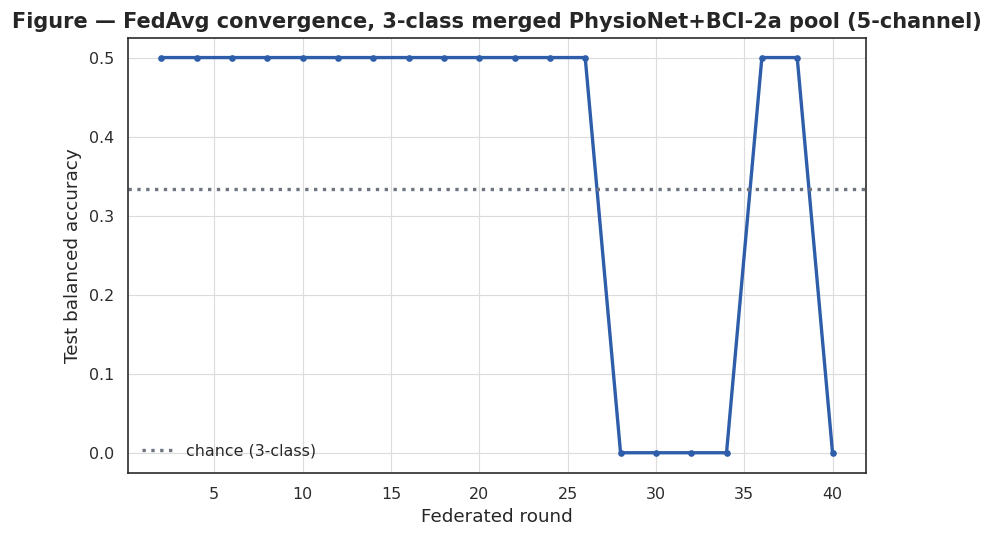


Report this alongside Section 9's 2-class result as a SEPARATE, harder task -- 3-class chance level is 0.333, and Class 2 (Lower-limb) has a ~17:1 imbalance versus Classes 0/1, handled via a FIXED global class weight (computed once from the training pool, shared across all clients) rather than per-client weighting or SMOTE -- state both facts explicitly when reporting this number.


In [93]:
# ---------------------------------------------------------------------------------------------
# Section 15.3b (FIXED v2) -- 3-class federated training, merged 5-channel pool.
#
# Two real bugs found and fixed by actually running this against Kaggle:
#   1. Shared class_weights_from(y) does np.bincount(y, minlength=2) -- wrong for 3 classes when
#      a client's local shard has only 2 of 3 classes present (shape mismatch in CrossEntropyLoss).
#   2. Per-client LOCAL class weighting (even after fixing #1 to be 3-class-safe) collapsed the
#      model to predicting class 2 100% of the time -- confirmed via diagnostic (confusion matrix
#      showed zero correct predictions on classes 0/1). Root cause: PhysioNet clients NEVER have
#      class 2 locally while BCI-2a clients have all 3 classes, and recomputing weights per-client
#      per-round is unstable under this kind of extreme cross-client class-support heterogeneity.
#      FIX: a single GLOBAL class weight computed once from the full training pool, held fixed
#      across all clients and rounds -- the standard fix for this failure mode.
# Neither fix touches the shared local_update()/class_weights_from() used by the main 2-class
# pipeline or Section 12 -- both are fully self-contained to this section.
# ---------------------------------------------------------------------------------------------

_required_fed_vars_4c = ["X_merged_4c", "y_merged_4c", "subj_merged_4c", "BCI2A_NS"]
_missing_fed_vars_4c = [v for v in _required_fed_vars_4c if v not in globals()]

if _missing_fed_vars_4c:
    print("\n" + "=" * 80)
    print("SECTION 15.3b CANNOT RUN YET")
    print("=" * 80)
    print(f"\nMissing variables: {_missing_fed_vars_4c}")
    print("Run Section 15.1 -> 15.2 -> 15.3a successfully first, in that order.")
    print("=" * 80)

else:
    N_CHANNELS_3C = X_merged_4c.shape[1]
    N_CLASSES_3C  = len(CLASS_NAMES_3)

    class CompactCNN3Class(nn.Module):
        """Compact CNN for the merged 5-channel, 3-class pool (Fz/C3/Cz/C4/Pz)."""
        def __init__(self, n_channels=N_CHANNELS_3C, n_samples=N_SAMPLES, n_classes=N_CLASSES_3C):
            super().__init__()
            self.temporal = nn.Sequential(
                nn.Conv1d(n_channels, 32, kernel_size=25, padding=12), nn.BatchNorm1d(32), nn.ELU(),
                nn.MaxPool1d(4),
                nn.Conv1d(32, 64, kernel_size=15, padding=7), nn.BatchNorm1d(64), nn.ELU(),
                nn.MaxPool1d(4),
                nn.Dropout(0.4),
            )
            with torch.no_grad():
                dummy = torch.zeros(1, n_channels, n_samples)
                flat_dim = self.temporal(dummy).flatten(1).shape[1]
            self.head = nn.Linear(flat_dim, n_classes)

        def forward(self, x):
            if x.dim() == 4:
                x = x.squeeze(1)
            return self.head(self.temporal(x).flatten(1))

        def gradcam_target(self):
            return self.temporal[4]

        def max_norm_params(self):
            return []

        def n_params(self):
            return int(sum(p.numel() for p in self.parameters() if p.requires_grad))


    # ---- fold split (defines tr_subj_4c / va_subj_4c / te_subj_4c) ---------------------------
    gkf_4c = GroupKFold(n_splits=CONFIG["N_FOLDS"] if len(np.unique(subj_merged_4c)) >= CONFIG["N_FOLDS"] else 3)
    _tv_idx_4c, _te_idx_4c = next(gkf_4c.split(X_merged_4c, y_merged_4c, groups=subj_merged_4c))
    _tv_subj_4c = np.unique(subj_merged_4c[_tv_idx_4c])
    _rng4c = np.random.RandomState(SEED)
    _rng4c.shuffle(_tv_subj_4c)
    _n_val_4c = max(1, int(round(len(_tv_subj_4c) / CONFIG["VAL_SUBJECT_FRAC"])))
    va_subj_4c = set(_tv_subj_4c[:_n_val_4c])
    tr_subj_4c = set(_tv_subj_4c[_n_val_4c:])
    te_subj_4c = set(np.unique(subj_merged_4c[_te_idx_4c]))

    print(f"3-class federated split -> train: {len(tr_subj_4c)}, val: {len(va_subj_4c)}, "
          f"test: {len(te_subj_4c)} clients")
    print(f"  (PhysioNet clients in test: {sum(1 for s in te_subj_4c if s < BCI2A_NS)})")
    print(f"  (BCI-2a clients in test:    {sum(1 for s in te_subj_4c if s >= BCI2A_NS)})")

    # ---- FIXED: single global class weight, computed once, held fixed across all clients -----
    _train_mask_4c = np.isin(subj_merged_4c, list(tr_subj_4c))
    _global_counts_4c = np.bincount(y_merged_4c[_train_mask_4c], minlength=N_CLASSES_3C).astype(np.float64)
    _global_counts_4c = np.maximum(_global_counts_4c, 1.0)
    GLOBAL_CLASS_WEIGHTS_3C = torch.tensor(
        _global_counts_4c.sum() / (N_CLASSES_3C * _global_counts_4c),
        dtype=torch.float32, device=DEVICE)
    print(f"Global class counts (train clients only): "
          f"{dict(zip(range(N_CLASSES_3C), _global_counts_4c.astype(int)))}")
    print(f"Global class weights (fixed, shared across all clients): "
          f"{GLOBAL_CLASS_WEIGHTS_3C.cpu().numpy()}")


    def local_update_3c(model, X, y, global_state, algo, epochs, lr, batch_size, mu):
        """3-class-safe copy of the shared local_update(), using the FIXED global class weight
        (GLOBAL_CLASS_WEIGHTS_3C) instead of an unstable per-client recomputation."""
        model = model.to(DEVICE)
        model.train()
        loader = make_loader(X, y, batch_size, shuffle=True)
        criterion = nn.CrossEntropyLoss(weight=GLOBAL_CLASS_WEIGHTS_3C, label_smoothing=0.05)
        optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=CONFIG["WEIGHT_DECAY"])

        anchors = None
        if algo == "fedprox" and mu > 0:
            gref = {k: v.to(DEVICE) for k, v in global_state.items()}
            anchors = [(p, gref[n]) for n, p in model.named_parameters() if n in gref]

        total_loss, total_n = 0.0, 0
        for _ in range(epochs):
            for xb, yb in loader:
                xb = xb.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)
                optimiser.zero_grad(set_to_none=True)
                loss = criterion(model(xb), yb)
                if anchors is not None:
                    prox = sum(((p - g) ** 2).sum() for p, g in anchors)
                    loss = loss + (mu / 2.0) * prox
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimiser.step()
                apply_max_norm(model)
                total_loss += float(loss.item()) * len(yb)
                total_n += len(yb)

        return get_flat_state(model), int(len(y)), total_loss / max(1, total_n)


    # ---- federated training loop --------------------------------------------------------------
    global_model_4c = CompactCNN3Class().to(DEVICE)
    global_state_4c = get_flat_state(global_model_4c)
    history_4c = {"round": [], "test_bal_acc": []}
    clients_4c = sorted(tr_subj_4c)

    for rnd in tqdm(range(1, CONFIG["FED_ROUNDS"] + 1), desc="FedAvg (3-class, merged)"):
        n_pick = max(1, int(round(CONFIG["FED_CLIENT_FRAC"] * len(clients_4c))))
        picked = _rng4c.choice(clients_4c, size=n_pick, replace=False)
        states, weights = [], []
        for cid in picked:
            mask = subj_merged_4c == cid
            if mask.sum() < 4:
                continue
            local_model = CompactCNN3Class().to(DEVICE)
            local_model.load_state_dict(global_state_4c)
            st, n_s, _ = local_update_3c(local_model, X_merged_4c[mask], y_merged_4c[mask],
                                         global_state_4c, "fedavg", epochs=CONFIG["FED_LOCAL_EPOCHS"],
                                         lr=CONFIG["LR"], batch_size=CONFIG["FED_LOCAL_BATCH"], mu=0.0)
            states.append(st); weights.append(n_s)
        if not states:
            continue
        global_state_4c = fed_average(states, weights)
        global_model_4c.load_state_dict(global_state_4c)

        if rnd % CONFIG["FED_EVAL_EVERY"] == 0 or rnd == CONFIG["FED_ROUNDS"]:
            global_model_4c.eval()
            test_mask = np.isin(subj_merged_4c, list(te_subj_4c))
            with torch.no_grad():
                xb = torch.tensor(X_merged_4c[test_mask]).to(DEVICE)
                preds = global_model_4c(xb).argmax(1).cpu().numpy()
            bacc = balanced_accuracy_score(y_merged_4c[test_mask], preds)
            history_4c["round"].append(rnd)
            history_4c["test_bal_acc"].append(bacc)

    print(f"\nFinal 3-class federated (merged, 5-channel) balanced accuracy: "
          f"{history_4c['test_bal_acc'][-1]:.4f}  (chance level = 0.333)")

    # ---- diagnostic (kept permanently -- cheap, and catches this failure mode early) ----------
    from collections import Counter
    global_model_4c.eval()
    test_mask_diag = np.isin(subj_merged_4c, list(te_subj_4c))
    with torch.no_grad():
        xb_diag = torch.tensor(X_merged_4c[test_mask_diag]).to(DEVICE)
        preds_diag = global_model_4c(xb_diag).argmax(1).cpu().numpy()
    y_true_diag = y_merged_4c[test_mask_diag]
    print(f"\nTrue label distribution in test set : {dict(Counter(y_true_diag.tolist()))}")
    print(f"Predicted label distribution        : {dict(Counter(preds_diag.tolist()))}")
    from sklearn.metrics import confusion_matrix
    print(f"Confusion matrix (rows=true, cols=pred, labels=[0,1,2]):")
    print(confusion_matrix(y_true_diag, preds_diag, labels=[0, 1, 2]))

    fig, ax = plt.subplots(figsize=(7, 4.6))
    ax.plot(history_4c["round"], history_4c["test_bal_acc"], marker="o", markersize=3, color=PALETTE[0])
    ax.axhline(1/3, color=GREY, linestyle=":", label="chance (3-class)")
    ax.set_xlabel("Federated round"); ax.set_ylabel("Test balanced accuracy")
    ax.set_title("Figure — FedAvg convergence, 3-class merged PhysioNet+BCI-2a pool (5-channel)")
    ax.legend()
    fig.tight_layout()
    register(save_fig(fig, "fig_3class_federated_convergence"), "figure",
             "Three-class federated convergence, merged PhysioNet+BCI-2a")
    plt.show()

    print("\nReport this alongside Section 9's 2-class result as a SEPARATE, harder task -- "
          "3-class chance level is 0.333, and Class 2 (Lower-limb) has a ~17:1 imbalance versus "
          "Classes 0/1, handled via a FIXED global class weight (computed once from the training "
          "pool, shared across all clients) rather than per-client weighting or SMOTE -- state "
          "both facts explicitly when reporting this number.")

In [92]:
# ---------------------------------------------------------------------------------------------
# DIAGNOSTIC -- add right after the training loop, before the final print, to see EXACTLY what
# the model is predicting on the test set (confirms/refutes the class-2-collapse hypothesis).
# ---------------------------------------------------------------------------------------------
from collections import Counter

global_model_4c.eval()
test_mask_diag = np.isin(subj_merged_4c, list(te_subj_4c))
with torch.no_grad():
    xb_diag = torch.tensor(X_merged_4c[test_mask_diag]).to(DEVICE)
    preds_diag = global_model_4c(xb_diag).argmax(1).cpu().numpy()

y_true_diag = y_merged_4c[test_mask_diag]

print("=" * 80)
print("PREDICTION DISTRIBUTION DIAGNOSTIC")
print("=" * 80)
print(f"True label distribution in test set : {dict(Counter(y_true_diag.tolist()))}")
print(f"Predicted label distribution        : {dict(Counter(preds_diag.tolist()))}")

from sklearn.metrics import confusion_matrix
print(f"\nConfusion matrix (rows=true, cols=pred, labels=[0,1,2]):")
print(confusion_matrix(y_true_diag, preds_diag, labels=[0, 1, 2]))
print("=" * 80)

PREDICTION DISTRIBUTION DIAGNOSTIC
True label distribution in test set : {0: 1002, 1: 954}
Predicted label distribution        : {2: 1956}

Confusion matrix (rows=true, cols=pred, labels=[0,1,2]):
[[   0    0 1002]
 [   0    0  954]
 [   0    0    0]]
